# DSA 2026 S2 Assignment

**Member ID:** [INSERT]

**Date:** [INSERT]

---

### How to use this template

The cells below are a skeleton, not an answer sheet. **Add as many cells as you need** — the headings are there so that the marker for each question can find your work, and so that the code cells give you somewhere to start. Nothing stops you splitting one into five, or working somewhere else entirely and pasting the result in.

Two things the brief asks for that this skeleton does not lay out for you:

- a **text cell above** each piece of code, explaining the step you are about to take; and
- a **text cell below** the output, saying what you make of it.

So expect to add text cells throughout — that commentary is a large part of what is being marked, and a notebook of bare code will not score well however good the code is. Keep each question's work under its own heading: different markers take different questions, and an answer that lives somewhere else will not be found.


## Setup

In [1]:
import os, sys, sqlite3, zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules


def open_database(name="ctgov.db", archive="ctgov.db.zip"):
    """Locate the database and return its path, extracting the zip if that is all there is.

    Behaves the same locally and on Colab. This runs before sqlite3.connect() on purpose:
    connect() silently creates an empty database when the file is missing, so a missing
    file would otherwise show up much later as 'no such table'.
    """
    places = [os.getcwd()]
    if IN_COLAB:
        places += ["/content", "/content/drive/MyDrive", "/content/drive/MyDrive/DSA"]

    for d in places:
        db = os.path.join(d, name)
        if os.path.isfile(db):
            return db
        archive_path = os.path.join(d, archive)
        if os.path.isfile(archive_path):
            # Unpack to the session disk rather than back into Drive: writing 146 MB to
            # Drive is slow and consumes your quota, and the session copy reads faster.
            target = "/content" if IN_COLAB and d.startswith("/content/drive") else d
            print("Extracting %s to %s ..." % (archive, target))
            try:
                with zipfile.ZipFile(archive_path) as z:
                    z.extractall(target)
            except zipfile.BadZipFile:
                raise RuntimeError(
                    "%s could not be opened. The most likely cause is an interrupted\n"
                    "download - the file should be about 40 MB. Delete it, download it\n"
                    "again, and re-run this cell." % archive_path)
            db = os.path.join(target, name)
            if os.path.isfile(db):
                return db

    looked = "\n  ".join(places)
    if IN_COLAB:
        raise FileNotFoundError(
            "%s not found. Looked in:\n  %s\n\n"
            "On Colab you need to bring the database into the session. Either upload it:\n"
            "    from google.colab import files; files.upload()\n"
            "or mount your Drive and keep it in MyDrive:\n"
            "    from google.colab import drive; drive.mount('/content/drive')\n\n"
            "Uploading is fine for a single sitting; Drive survives a disconnect." % (name, looked)
        )
    raise FileNotFoundError(
        "%s not found. Looked in:\n  %s\n\n"
        "Put %s (or %s) beside this notebook, or change directory to the folder holding it."
        % (name, looked, name, archive)
    )


if tuple(int(x) for x in matplotlib.__version__.split(".")[:2]) < (3, 9):
    print("Warning: matplotlib %s. This notebook needs 3.9 or newer (the box plot below uses\n"
          "tick_labels=). Run:  pip install -U 'matplotlib>=3.9'" % matplotlib.__version__)

DB_PATH = open_database()
conn = sqlite3.connect(DB_PATH)
print("Connected to %s (%.0f MB) - %s environment."
      % (os.path.basename(DB_PATH), os.path.getsize(DB_PATH) / 1e6,
         "Colab" if IN_COLAB else "local"))

# A part-downloaded database opens without complaint and then fails much later with
# something unhelpful like "no such table". Check it here instead, while the cause
# is still obvious.
_integrity = conn.execute("PRAGMA quick_check(1)").fetchone()[0]
_n_tables = conn.execute("SELECT COUNT(*) FROM sqlite_master WHERE type='table'").fetchone()[0]
if _integrity != "ok" or _n_tables != 12:
    print("\nThis database does not look complete: %s, %d tables, expected 12.\n"
          "Delete ctgov.db and ctgov.db.zip, download again, and re-run this cell."
          % (_integrity, _n_tables))
else:
    print("%d tables, integrity check ok." % _n_tables)
import seaborn as sns

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'", conn)
print("Tables in database: %s" % tables['name'].tolist())

def log_ai(prompt, response, qtag="general", topic="api-call"):
    """Record one AI API call made from your own code, in the format
    compile_ai_logs.py expects (see the AI-use guidance).

    Use this only when your code itself calls an AI model (e.g. an API
    call inside a pipeline). For chat/agent conversations, save the
    exported conversation file into ai_logs/ directly instead.

    qtag: one of "Q1".."Q4", "multiQ", or "general".
    """
    from pathlib import Path
    from datetime import datetime

    log_dir = Path("ai_logs")
    log_dir.mkdir(exist_ok=True)
    stamp = datetime.now().strftime("%Y-%m-%d_%H%M")
    path = log_dir / f"{stamp}_{qtag}_{topic}.md"
    with open(path, "a", encoding="utf-8") as f:
        f.write(f"## Prompt\n\n{prompt}\n\n## Response\n\n{response}\n\n---\n\n")
    return path
   

def word_count(text):
    """Count the words in a written answer.

    Q1d, Q2d and Q3d are capped at 500 words and Q4c at 300. The brief says
    markers do not read past the limit, so it is worth checking. Paste the
    answer between triple quotes:

        word_count('''My answer goes here.''')
    """
    return len(str(text).split())


def write_manual_note(qtag, topic, note, when=None, log_dir="ai_logs"):
    """Record a conversation you could not save, named like any other log.

    A work tool blocked the export, a temporary chat expired, history was
    cleared, or you simply forgot. None of that is a breach provided you
    record it honestly: say what the conversation covered and why it is
    missing. Falsifying a record, or denying use that occurred, is not the
    same thing at all.

    The same helper is demonstrated in the Getting Started notebook.

        write_manual_note("Q1", "chatgpt-export-blocked",
                          "Talked through the stratified sample for about 15 "
                          "minutes. My work account blocks copying transcripts "
                          "out, so the exchange could not be saved.")
    """
    import os
    from datetime import date

    os.makedirs(log_dir, exist_ok=True)
    stamp = when or date.today().isoformat()          # or pass when="2026-08-14"
    path = os.path.join(log_dir, "%s_%s_%s.md" % (stamp, qtag, topic))
    with open(path, "w", encoding="utf-8") as f:
        f.write("# Manual entry - %s\n\n*%s. Written by me because the conversation "
                "itself could not be saved.*\n\n%s\n"
                % (topic.replace("-", " "), stamp, note))
    print("Wrote", path)
    return path


Connected to ctgov.db (146 MB) - local environment.
12 tables, integrity check ok.
Tables in database: ['consensus_outcomes', 'event_study_results', 'fda_drug_match', 'event_fda_features', 'filing_summary', 'filing_text', 'study_event_link', 'stock_prices', 'studies', 'event_study_enriched', 'asclepius_readouts', 'asclepius_scenario_filings']


# Question 1: Validate and improve the dataset (21 marks)

Before the CFO can rely on this dataset for capital planning, two things have to be established: whether the LLM-generated outcome classifications can be trusted, and whether the data and its text fields can be put into a form the rest of the analysis can use without leaking information it should not have.

The work below runs in order and builds shared objects — the cleaned filing text, the document-type classifier, the flagging table and the analysis table — that Questions 2, 3 and 4 draw on.

## Q1a: Evaluate LLM classifications (7 marks)

The dataset's outcome labels were produced by the dual-prompt consensus pipeline described in §5 of the methodology document. Before the IR team uses them to estimate market reactions, two things need to be established: whether a label describes correctly what the filing says, and whether the label means what the downstream analysis assumes it means. These are not the same question, and the evaluation below separates them.

The brief asks for two analyses, and they answer different halves of that:

1. **A stratified sample read against the filings.** Five classifications from each of the six documented categories (n = 30), drawn with my member ID as the seed. Each is read against the sentences in the original 8-K that mention the classified drug, to judge whether the label is accurate and whether the boundaries between adjacent categories are drawn the same way from one filing to the next.
2. **Every directional label compared to the sign of the abnormal return.** Where the two disagree, the disagreement is investigated to establish whether it reflects a classification error, a market-expectations effect, or something else.

Throughout, findings are read back against the methodology document, because several of the patterns below trace directly to design choices recorded there.

Two things worth noting before starting, both visible in the cell above and neither described in the six-category documentation:

- **The table holds 13 distinct outcome values, not 6.** The 45 records the pipeline could not resolve are stored with composite labels such as `positive/negative` and `mixed-positive/mixed-negative`. Any code that assumes six categories will silently mishandle them. Rather than hardcode the six, the cell above derives them from `outcome_group` — which the data dictionary calls "the cleanest way to identify those rows" because it is null for exactly the composite ones — and then asserts that the derivation reproduces the stored column on every event row. `no_result` is the one value the column cannot supply, because those filings report nothing and so have no event study at all.
- **The `statistics` column is empty in all 4,539 rows, and `evidence` in all but those 45.** The methodology explains why: the extracted statistics shaped the classifications but were never written to the student database. The practical consequence is that the quote-first grounding that the prompts were built around cannot be audited from this database at all — every check below has to go back to `filing_text`.

In [2]:
# ---------------------------------------------------------------------------
# Q1 shared setup: load the tables Question 1 works with, and define the two
# text helpers (cleaning + filing-type classification) that Q1a, Q1b and Q1c
# all depend on. Everything downstream in Question 1 is built from these.
# ---------------------------------------------------------------------------
import re, json, textwrap
from IPython.display import display

MEMBER_ID = 40100          # used as the random seed throughout, per the brief

consensus  = pd.read_sql("SELECT * FROM consensus_outcomes", conn)
event_res  = pd.read_sql("SELECT * FROM event_study_results", conn)
filing_sum = pd.read_sql("SELECT * FROM filing_summary", conn)
filing_txt = pd.read_sql("SELECT accession, filing_text FROM filing_text", conn)

print("consensus_outcomes  %5d rows, %d filings, %d tickers"
      % (len(consensus), consensus.accession.nunique(), consensus.ticker.nunique()))
print("event_study_results %5d rows, %d filings" % (len(event_res), event_res.accession.nunique()))
print("filing_summary      %5d rows" % len(filing_sum))
print("filing_text         %5d filings" % len(filing_txt))

# ---------------------------------------------------------------------------
# The six documented categories are derived from the database, not hardcoded.
# consensus_outcomes holds 13 distinct outcome values. The data dictionary says
# outcome_group on event_study_results is "null for the rows whose underlying
# outcome is a compound value the consensus logic could not resolve - which
# makes this column the cleanest way to identify those rows". Reading the six
# off that column turns the six-category claim into something this notebook
# checks against the data rather than asserts in a literal list.
#
# outcome_group resolves 12 of the 13 values. no_result is the thirteenth and it
# has no outcome_group at all, because it never reaches event_study_results: a
# filing reporting no trial result has no event to study. That one value is
# added by name, and it is the single place the derivation needs help.
# ---------------------------------------------------------------------------
_og = event_res[["outcome", "outcome_group"]].drop_duplicates()
_og_map = _og.groupby("outcome").outcome_group.apply(lambda v: sorted(v.dropna().unique()))
assert all(len(g) <= 1 for g in _og_map), "an outcome value maps to more than one outcome_group"

GROUP_OF   = {o: g[0] for o, g in _og_map.items() if g}      # outcome -> direction
RESOLVED   = sorted(GROUP_OF)                                # outcome_group is not null
UNRESOLVED = sorted(o for o, g in _og_map.items() if not g)  # compound; outcome_group is null
NO_EVENT   = ["no_result"]                                   # never reaches the event study

# The derivation establishes *membership*; the order is the documentation's, and
# is kept deliberately. Analysis 1 draws five records per category by iterating
# this list, so sorting it alphabetically would silently renumber the sample -
# and the hand-reading in the READING table below is recorded against those row
# numbers. Deriving the set and asserting it against the documented order gives
# the check without moving the rows.
DOCUMENTED = ["positive", "negative", "mixed-positive", "mixed-negative",
              "inconclusive", "no_result"]
assert set(DOCUMENTED) == set(RESOLVED) | set(NO_EVENT), \
    "the categories derived from outcome_group are not the six documented ones"
SIX = DOCUMENTED

print("\nDeriving the documented categories from outcome_group:")
print("  distinct outcome values in consensus_outcomes     : %d" % consensus.outcome.nunique())
print("  values outcome_group resolves to a direction      : %d  %s" % (len(RESOLVED), RESOLVED))
print("  values whose outcome_group is NULL (compound)     : %d  %s" % (len(UNRESOLVED), UNRESOLVED))
print("  no event study, so no outcome_group; added by name: %s" % NO_EVENT)
print("  -> %d documented categories, %d directions %s"
      % (len(SIX), len(set(GROUP_OF.values())), sorted(set(GROUP_OF.values()))))

# A derivation is only worth having if it is checked, so it is.
assert len(SIX) == 6, SIX
assert not (set(UNRESOLVED) & set(SIX)), "a compound value leaked into the documented six"
assert set(consensus.outcome.unique()) == set(SIX) | set(UNRESOLVED), \
    "consensus_outcomes holds an outcome value this derivation does not account for"
assert (event_res.outcome.str.contains("/") == event_res.outcome_group.isna()).all(), \
    "outcome_group is not NULL for exactly the rows carrying a compound outcome"
assert (event_res.outcome.map(GROUP_OF).fillna("-") == event_res.outcome_group.fillna("-")).all(), \
    "the derived mapping does not reproduce the stored outcome_group"
print("  checks pass: outcome_group is NULL for exactly the %d compound values, the mapping\n"
      "  reproduces the stored column on all %d event rows, and the %d values in\n"
      "  consensus_outcomes are the 6 documented plus those %d."
      % (len(UNRESOLVED), len(event_res), consensus.outcome.nunique(), len(UNRESOLVED)))

# Carry the direction onto the classification table so the rest of Question 1 can
# group by it. This is a value-level map rather than a join, which matters:
# consensus_outcomes has 119 duplicated (accession, drug_name) keys, and joining
# on that key would both expand the 4,539-row table and, where a key mixes a
# compound row with a resolved one, attach a direction to a row that has none.
consensus["outcome_group"] = consensus.outcome.map(GROUP_OF)
print("\noutcome_group attached to consensus_outcomes: %d of %d rows carry a direction. The\n"
      "%d without one are %d no_result and %d compound - which is why membership of the six\n"
      "is tested with outcome.isin(SIX), never with outcome_group.notna()."
      % (consensus.outcome_group.notna().sum(), len(consensus),
         consensus.outcome_group.isna().sum(), (consensus.outcome == "no_result").sum(),
         consensus.outcome.isin(UNRESOLVED).sum()))

counts = consensus.outcome.value_counts()
print("\nOutcome values present in consensus_outcomes:")
display(counts.to_frame("n").assign(documented=lambda d: d.index.isin(SIX)))

# The evidence and statistics columns the methodology describes.
print("evidence blank in %d of %d rows; statistics blank in %d of %d rows"
      % ((consensus.evidence.fillna("").str.strip() == "").sum(), len(consensus),
         (consensus.statistics.fillna("").str.strip() == "").sum(), len(consensus)))
print("\nNon-blank evidence, first two rows:")
for _, r in consensus[consensus.evidence.fillna("").str.strip() != ""].head(2).iterrows():
    print("  %s  %-14s  outcome=%-30s evidence=%s"
          % (r.accession, r.ticker, r.outcome, r.evidence))

consensus_outcomes   4539 rows, 3795 filings, 408 tickers
event_study_results  2615 rows, 1905 filings
filing_summary       1905 rows
filing_text          3794 filings

Deriving the documented categories from outcome_group:
  distinct outcome values in consensus_outcomes     : 13
  values outcome_group resolves to a direction      : 5  ['inconclusive', 'mixed-negative', 'mixed-positive', 'negative', 'positive']
  values whose outcome_group is NULL (compound)     : 7  ['mixed-negative/mixed-positive', 'mixed-negative/positive', 'mixed-positive/mixed-negative', 'mixed-positive/negative', 'negative/mixed-positive', 'negative/positive', 'positive/negative']
  no event study, so no outcome_group; added by name: ['no_result']
  -> 6 documented categories, 3 directions ['Inconclusive', 'Negative', 'Positive']
  checks pass: outcome_group is NULL for exactly the 7 compound values, the mapping
  reproduces the stored column on all 2615 event rows, and the 13 values in
  consensus_outcomes are t

,n,documented
outcome,,
positive,1898,True
no_result,1694,True
negative,403,True
inconclusive,209,True
mixed-positive,205,True
mixed-negative,85,True
mixed-positive/mixed-negative,13,False
positive/negative,10,False
mixed-positive/negative,8,False


evidence blank in 4494 of 4539 rows; statistics blank in 4539 of 4539 rows

Non-blank evidence, first two rows:
  0000059478-13-000053  LLY             outcome=positive/negative              evidence={"b1a": "positive", "b3b": "negative"}
  0000059478-19-000171  LLY             outcome=mixed-positive/mixed-negative  evidence={"b1a": "mixed-positive", "b3b": "mixed-negative"}


In [3]:
# ---------------------------------------------------------------------------
# Two helpers used from here to the end of Question 1.
#
# clean_filing_text()  strips the material that is identical across filings and
#                      carries no information about the trial: the SEC cover
#                      page, the safe-harbour block, the exhibit index and the
#                      signature page. It also repairs the character-level
#                      damage left by the programmatic extraction (smart quotes,
#                      bullet glyphs, and the spaced hyphens that slide decks
#                      produce, e.g. "well - tolerated").
#
# classify_filing()    labels each filing by what kind of document it is, and
#                      counts how often it refers back to an earlier disclosure.
#                      This matters because an 8-K that *announces* a result and
#                      an 8-K that *recaps* one inside a quarterly report are
#                      very different events, even when the sentence describing
#                      the trial is word-for-word the same.
# ---------------------------------------------------------------------------
MOJIBAKE = {"’": "'", "‘": "'", "“": '"', "”": '"',
            "–": "-", "—": "-", "−": "-", "′": "'",
            "▪": " ", "●": " ", "•": " ", "·": " ",
            "Ÿ": " ", " ": " ", "�": " ",
            "☐": " ", "☒": " "}

RE_COVER = re.compile(r"^.{0,6000}?Check the appropriate box below.*?13e-4\(c\)\)", re.S | re.I)
RE_SAFE  = re.compile(
    r"(?:This (?:press release|communication|report|presentation)[^.]{0,200}(?:forward-looking)"
    r"|Forward[- ]Looking Statements?|Safe Harbor Statement|Private Securities Litigation Reform Act)"
    r".{0,12000}?(?=(?:Item \d|EX-|Exhibit \d|SIGNATURE|About [A-Z]|Contacts?:|###|$))", re.S | re.I)
RE_EXIDX = re.compile(r"Item 9\.01[^A-Za-z]{0,20}Financial Statements and Exhibits"
                      r".{0,2000}?(?=(?:SIGNATURE|EX-|Exhibit 99|$))", re.S | re.I)
# The signature block is boilerplate and comes out, but in an 8-K it sits
# *between* the body and the exhibits rather than at the end of the document.
# Where the filing attaches its press release or deck as Exhibit 99.1 - the
# common case - everything after the signature is the substance. Deleting to
# end-of-string therefore removed the exhibit itself: it fired on 1,458 filings
# and took more than half the document in 1,215 of them. The lookahead stops the
# deletion at the exhibit marker, keeping the "$" alternative for filings that
# genuinely do end at the signature.
RE_TAIL  = re.compile(r"SIGNATURES?\s+Pursuant to the requirements of the Securities Exchange Act"
                      r".{0,3000}?(?=(?:EX-|Exhibit\s?99|Item \d|$))", re.S | re.I)

def clean_filing_text(t):
    if not isinstance(t, str):
        return ""
    for k, v in MOJIBAKE.items():
        t = t.replace(k, v)
    t = RE_COVER.sub(" ", t, count=1)
    t = RE_SAFE.sub(" ", t)
    t = RE_EXIDX.sub(" ", t)
    t = RE_TAIL.sub(" ", t)
    t = re.sub(r"\b([A-Za-z]{2,})\s+-\s+([A-Za-z]{2,})\b", r"\1-\2", t)   # slide-deck hyphens
    t = re.sub(r"https?://\S+", " ", t)
    return re.sub(r"\s+", " ", t).strip()

# A financial-results headline, a trial-results headline, and a Reg FD deck.
RE_FIN = re.compile(
    r"(Reports?|Announces?)\b[^.]{0,90}\b(First|Second|Third|Fourth)[- ]Quarter"
    r"|(Reports?|Announces?)\b[^.]{0,70}\b(Financial|Fiscal|Full[- ]Year|Annual|Year[- ]End)\b[^.]{0,40}Results"
    r"|Quarterly (Report|Results)|Results of Operations and Financial Condition|Item 2\.02", re.I)
RE_RES = re.compile(
    r"\b(Announce[sd]?|Report(s|ed)?|Present(s|ed)?|Provide[sd]?)\b[^.]{0,150}"
    r"\b(top-?\s?line|primary endpoint|pivotal|Phase\s?[1-4I]|results? (from|of|in|for)|data (from|in|at))\b",
    re.I)
RE_DECK = re.compile(r"\b(corporate|company|investor|business)\s+(presentation|deck|update|overview)\b"
                     r"|Item 7\.01|Regulation FD Disclosure", re.I)
RE_PRIOR = re.compile(
    r"\b(previously (announced|reported|disclosed)|as (previously )?announced"
    r"|in (January|February|March|April|May|June|July|August|September|October|November|December)"
    r" 20\d\d,? (the Company |we |[A-Z][a-z]+ )?(announced|reported)|earlier this year)\b", re.I)

def classify_filing(clean_text, raw_text, head=1200, body=6000):
    """Label the document type, preferring the headline, and count restatement language.

    The headline is checked first, and a trial-results headline wins over a
    financial one, because a company announcing topline data will often mention
    a coming quarter in the same release. Falling back to the body only where
    the headline is silent stops guidance language ("we expect to report in the
    fourth quarter") from turning an announcement into a quarterly report - a
    real misclassification in an earlier version of this function, found by
    checking it against the filings read by hand for the sample below.
    """
    h, b = clean_text[:head], clean_text[:body]
    fin, res = bool(RE_FIN.search(h)), bool(RE_RES.search(h))
    if res and not fin:
        kind = "results announcement"
    elif fin or RE_FIN.search(b):
        kind = "periodic report"
    elif RE_DECK.search(b):
        kind = "deck / FD update"
    elif RE_RES.search(b):
        kind = "results announcement"
    else:
        kind = "other"
    return kind, len(RE_PRIOR.findall(raw_text))

filing_txt["clean"] = filing_txt.filing_text.map(clean_filing_text)
_kinds = [classify_filing(c, r) for c, r in zip(filing_txt.clean, filing_txt.filing_text)]
filing_txt["filing_kind"] = [k for k, _ in _kinds]
filing_txt["n_prior_refs"] = [n for _, n in _kinds]

print("Cleaning removed %.1f%% of all characters (median filing %d -> %d chars)"
      % (100 * (1 - filing_txt.clean.str.len().sum() / filing_txt.filing_text.str.len().sum()),
         filing_txt.filing_text.str.len().median(), filing_txt.clean.str.len().median()))
print()
display(filing_txt.filing_kind.value_counts().to_frame("filings"))

Cleaning removed 17.5% of all characters (median filing 19186 -> 13905 chars)



,filings
filing_kind,
periodic report,1697
results announcement,1078
deck / FD update,517
other,502


### Analysis 1: reading a stratified sample against the filings

Sampling is done within category rather than across the whole table because the categories are very unevenly sized — `positive` has 1,898 records and `mixed-negative` 85 — so a simple random sample of 30 would be unlikely to contain any `mixed-negative` or `inconclusive` cases at all. Five per category gives 30 records and guarantees coverage of all six documented categories, as the brief requires. The six are the list derived from `outcome_group` above, so the sample cannot silently miss a category, nor draw one of the 45 unresolved composite records into a stratum it does not belong to.

In [4]:
# ---------------------------------------------------------------------------
# Analysis 1 of 2: stratified sample of classifications, read against the filing.
# Five records from each of the six documented categories (n=30), drawn with the
# member ID as the seed. Sampling within stratum rather than overall guarantees
# the two rarest categories (mixed-negative, inconclusive) are represented.
# ---------------------------------------------------------------------------
# 112 (accession, drug_name) pairs carry more than one event-study row - the same
# drug reporting in more than one indication in one filing. They describe a single
# event, so car_3day should be identical within the key; the check below is what
# licenses the drop_duplicates, rather than an assumption that it is harmless.
_per_key = event_res.groupby(["accession", "drug_name"])
print("(filing, drug) keys with more than one event-study row: %d; of those, keys carrying "
      "more than one distinct car_3day: %d\n"
      % ((_per_key.size() > 1).sum(), (_per_key.car_3day.nunique() > 1).sum()))
car_by_row = event_res.drop_duplicates(["accession", "drug_name"])[
    ["accession", "drug_name", "car_3day"]]
cons_car = consensus.merge(car_by_row, on=["accession", "drug_name"], how="left")

sample = pd.concat([cons_car[cons_car.outcome == o].sample(n=5, random_state=MEMBER_ID)
                    for o in SIX]).reset_index(drop=True)
sample = sample.merge(filing_txt[["accession", "filing_kind", "n_prior_refs"]],
                      on="accession", how="left")

print("Stratified sample: %d records, %d categories, seed=%d\n"
      % (len(sample), sample.outcome.nunique(), MEMBER_ID))
display(sample[["accession", "ticker", "filing_date", "drug_name", "phase", "outcome",
                "consensus_type", "car_3day", "filing_kind", "n_prior_refs"]])

(filing, drug) keys with more than one event-study row: 112; of those, keys carrying more than one distinct car_3day: 0

Stratified sample: 30 records, 6 categories, seed=40100



,accession,ticker,filing_date,drug_name,phase,outcome,consensus_type,car_3day,filing_kind,n_prior_refs
0,0000950170-22-019151,AXSM,2022-10-03,Sunosi (solriamfetol),Phase 4 (post-approval investigator study),positive,agree,-0.020971,results announcement,0
1,0000078003-16-000091,PFE,2016-05-03,Xeljanz (tofacitinib citrate),Phase 3,positive,b1a_only,0.026447,periodic report,6
2,0000950144-08-005741,BCRX,2008-07-28,peramivir (intravenous),Phase 2,positive,agree,0.181194,results announcement,0
3,0001193125-25-280125,KOD,2025-11-13,tarcocimab,Phase 3,positive,agree,0.022352,periodic report,0
4,0001144204-16-125422,LPCN,2016-09-27,LPCN 1111,Phase 2b,positive,agree,0.152532,deck / FD update,0
5,0001193805-22-001141,IMUX,2022-08-04,vidofludimus calcium (IMU-838),Phase 2,negative,b3b_inconclusive_override,0.418185,periodic report,0
6,0001193125-23-297614,MIRM,2023-12-18,maralixibat (LIVMARLI),Phase 2b,negative,agree,-0.082182,results announcement,0
7,0001104659-21-108565,TBPH,2021-08-23,Izencitinib (TD-1473),Phase 2b,negative,agree,-0.300918,results announcement,0
8,0001532176-17-000033,REGN,2017-11-08,suptavumab,Phase 3,negative,agree,0.003910,periodic report,1
9,0000078003-24-000155,PFE,2024-07-30,fordadistrogene movaparvovec,Phase 3,negative,agree,-0.010942,periodic report,1


In [5]:
# ---------------------------------------------------------------------------
# Reading each sampled classification against its filing. The filings run to
# 20,000-90,000 characters, so rather than print them whole this pulls the
# sentences that mention the classified drug and describe a result, which is
# what the classification has to be judged against. Every judgement recorded in
# the table below was formed by reading this output for all 30 records; three
# representative cases are reproduced here.
# ---------------------------------------------------------------------------
RE_RESULT = re.compile(
    r"\b(primary endpoint|co-primary|secondary endpoint|statistically significant"
    r"|p\s?[=<>]\s?0?\.\d+|hazard ratio|odds ratio|response rate|overall survival"
    r"|progression-free|did not meet|failed to|met its|achieved|topline|top-line"
    r"|discontinu\w+|futility|terminat\w+|well[- ]tolerated|adverse events?|efficacy"
    r"|superiority|non-inferior\w*|interim analysis)\b", re.I)

def drug_tokens(name, keep_parenthetical=False):
    """Search tokens for a drug name.

    The parenthetical is dropped by default, because for sentence ranking the
    formulation ("cyclobenzaprine HCl sublingual tablets") matches far more
    loosely than the drug itself. For asking whether a drug is named in a filing
    at all it has to be kept: several names in this table are almost entirely
    parenthetical - "ALO-02 (oxycodone/naltrexone ER)", "SOF/VEL
    (sofosbuvir/velpatasvir)" - and stripping it leaves no token to search with,
    so the drug is reported absent without any search having been run.
    """
    inner = re.findall(r"\(([^)]*)\)", str(name)) if keep_parenthetical else []
    outer = re.sub(r"\(.*?\)", " ", str(name))
    toks = [t.lower() for t in re.split(r"[^A-Za-z0-9]+", outer) if len(t) > 3]
    toks += [t.lower() for g in inner for t in re.split(r"[^A-Za-z0-9]+", g) if len(t) > 3]
    return list(dict.fromkeys(toks))[:6]

def result_sentences(clean_text, drug, k=10, lo=40, hi=600):
    """Rank sentences by drug mention and result language; return them in reading order."""
    sents = [s for s in re.split(r"(?<=[.!?])\s+", clean_text) if lo <= len(s) <= hi]
    if not sents:
        return [clean_text[:hi]]
    toks, scored = drug_tokens(drug), []
    for i, s in enumerate(sents):
        low = s.lower()
        hit = any(t in low for t in toks)
        n_res = len(RE_RESULT.findall(s))
        score = (3 if hit else 0) + min(n_res, 3) + (2 if (hit and n_res) else 0)
        if score:
            scored.append((score, i, s))
    if not scored:
        return sents[:k]
    top = sorted(scored, key=lambda x: (-x[0], x[1]))[:k]
    return [s for _, _, s in sorted(top, key=lambda x: x[1])]

clean_by_acc = filing_txt.set_index("accession")["clean"]

def show(i, k=10):
    r = sample.loc[i]
    car = "n/a" if pd.isna(r.car_3day) else "%+.1f%%" % (100 * r.car_3day)
    print("=" * 100)
    print("[%d] %s | %s | %s | %s" % (i, r.accession, r.ticker, r.filing_date, r.drug_name))
    print("     label=%s  consensus=%s  CAR[-1,+1]=%s  document=%s  restatement phrases=%d"
          % (r.outcome, r.consensus_type, car, r.filing_kind, r.n_prior_refs))
    for s in result_sentences(clean_by_acc.get(r.accession, ""), r.drug_name, k=k):
        print(textwrap.fill(s, 98, initial_indent="   - ", subsequent_indent="     "))
    print()

for i in range(len(sample)):   # all 30, so every reading can be checked against its filing
    show(i)

[0] 0000950170-22-019151 | AXSM | 2022-10-03 | Sunosi (solriamfetol)
     label=positive  consensus=agree  CAR[-1,+1]=-2.1%  document=results announcement  restatement phrases=0
   - (NASDAQ: AXSM), a biopharmaceutical company developing and delivering novel therapies for the
     management of central nervous system (CNS) disorders, announced that Sunosi met the primary
     endpoint in the SHARP study and significantly improved cognitive function, measured using the
     Digit Symbol Substitution Test subtest of the Repeatable Battery for the Assessment of
     Neuropsychological Status (DSST RBANS), as compared to placebo in cognitively impaired
     patients with excessive daytime sleepiness (EDS) associated with obstructive sleep apnea
     (OSA).
   - Superiority of Sunosi as compared to placebo was further demonstrated using patient-reported
     measures of cognitive function.
   - In the study, Sunosi replicated previous findings by significantly reducing EDS symptoms as
     

In [6]:
# ---------------------------------------------------------------------------
# Before leaning on classify_filing(), check it against the 30 filings just read
# by hand. Most of Analysis 2 below turns on the announcement / not-announcement
# distinction, so it is worth knowing how often that distinction is right rather
# than assuming it.
# ---------------------------------------------------------------------------
HAND_LABELLED = [                       # index into `sample`, my reading of the document
    "results announcement", "periodic report", "results announcement", "periodic report",
    "deck / FD update", "periodic report", "results announcement", "results announcement",
    "periodic report", "periodic report", "deck / FD update", "results announcement",
    "results announcement", "periodic report", "deck / FD update", "periodic report",
    "periodic report", "periodic report", "deck / FD update", "periodic report",
    "deck / FD update", "deck / FD update", "periodic report", "periodic report",
    "deck / FD update", "other", "periodic report", "periodic report",
    "deck / FD update", "periodic report"]

check = sample[["accession", "ticker", "filing_date", "outcome", "filing_kind"]].copy()
check["read_by_hand"] = HAND_LABELLED
check["exact"] = check.filing_kind == check.read_by_hand
check["announcement_correct"] = ((check.filing_kind == "results announcement") ==
                                 (check.read_by_hand == "results announcement"))

print("Exact agreement on document type:        %d of 30" % check.exact.sum())
print("Agreement on announcement vs not:        %d of 30" % check.announcement_correct.sum())
print("\nDisagreements:")
display(check.loc[~check.exact, ["accession", "ticker", "filing_kind", "read_by_hand"]])
print("Only %d of the 30 sampled filings are the announcement that carried the news."
      % (check.read_by_hand == "results announcement").sum())

Exact agreement on document type:        23 of 30
Agreement on announcement vs not:        28 of 30

Disagreements:


,accession,ticker,filing_kind,read_by_hand
10,0001144204-15-047929,TNXP,periodic report,deck / FD update
12,0001104659-17-048613,TBPH,deck / FD update,results announcement
14,0001144204-15-054317,TNXP,periodic report,deck / FD update
18,0001387131-19-001982,TNXP,periodic report,deck / FD update
20,0001104659-25-119032,TBPH,other,deck / FD update
21,0001144204-12-035449,TCRT,periodic report,deck / FD update
23,0000914475-03-000023,NBIX,results announcement,periodic report


Only 6 of the 30 sampled filings are the announcement that carried the news.


In [7]:
# ---------------------------------------------------------------------------
# The reading record for Analysis 1, one row per sampled classification.
#
# The brief asks two things of this sample: whether each classification is
# accurate against the *original* filing text, and whether the boundaries
# between adjacent categories are applied the same way from one filing to the
# next. Both judgements are recorded here rather than described in prose, so
# they can be audited against the filings and recomputed if a reading changes.
#
#   fair      True / False  - is the assigned outcome a defensible reading of what
#                             this filing says about THIS drug, under the documented
#                             definition? Judged on the filing text alone; the market
#                             reaction is deliberately not consulted, because Analysis 2
#                             tests the labels against it and that check has to stay
#                             independent.
#   boundary  "ok"          - not on an adjacent-category boundary, or drawn consistently
#             "inconsistent"- the same situation is labelled differently elsewhere in the sample
#             "n/a"         - no directional claim to place (no_result)
#   note      the sentence the judgement rests on, quoted from the filing
#
# None means not yet read. The table below is computed over completed rows only.
# ---------------------------------------------------------------------------
READING = [dict(fair=None, boundary=None, note="") for _ in range(len(sample))]

READING[0]  = dict(fair=True,  boundary="ok", note="Meets Primary Endpoint; DSST RBANS p=0.009 vs placebo")
READING[1]  = dict(fair=True,  boundary="ok", note="OPAL Broaden met its primary efficacy endpoints; tofacitinib 5 mg and 10 mg BID superior to placebo")
READING[2]  = dict(fair=True,  boundary="ok", note="met its primary endpoint of improvement in median time to alleviation of symptoms; result highly statistically significant")
READING[3]  = dict(fair=True,  boundary="ok", note="tarcocimab met its primary endpoint and all key secondary endpoints")
READING[4]  = dict(fair=True,  boundary="ok", note="'Met Primary Study Objectives'; target Phase 3 dose met both primary and secondary endpoints, nothing reported as missed. No p-values - qualifies under the 'unambiguous statement of success' limb")
READING[5]  = dict(fair=True,  boundary="ok", note="did not meet its primary endpoint due to a previously unknown interaction with chronic concurrent steroid use")
READING[6]  = dict(fair=True,  boundary="ok", note="The study did not meet its primary endpoint or the key secondary endpoints")
READING[7]  = dict(fair=True,  boundary="ok", note="izencitinib in ulcerative colitis: randomised, double-blind, placebo-controlled study did not meet the primary endpoint")
READING[8]  = dict(fair=True,  boundary="ok", note="suptavumab did not meet its primary endpoint of preventing medically-attended RSV infections in infants. NB the 'met its primary endpoint' sentence in this filing belongs to dupilumab, a different drug classified separately")
READING[9]  = dict(fair=True,  boundary="ok", note="fordadistrogene movaparvovec in ambulatory DMD patients did not meet its primary endpoint")

READING[10] = dict(fair=True,  boundary="inconsistent", note="BESTFIT pre-specified primary endpoint (wk12 mean pain) p=0.172 - missed, disclosed only in a footnote; body slide calls it a 'positive trend' and the results table shows only endpoints that hit. Labelled mixed-positive; equally missed primaries stated openly got mixed-negative in [16] and [18]")
READING[11] = dict(fair=True,  boundary="inconsistent", note="P201/AtEase primary endpoint (CAPS-5, 2.8 mg, wk12) non-significant; all significant results are the secondary 5.6 mg arm. Labelled mixed-positive, while the same study in [18] is mixed-negative - the difference is which result the filing leads with")
READING[12] = dict(fair=True,  boundary="ok", note="Primary endpoint GCSI wk4: 5 mg significant (nominal p=0.0327), 15/30 mg not; multiplicity-adjusted analysis across 3 doses not significant, so 5 mg quoted as nominal only. Genuinely mixed and stated openly - the control case for this category")
READING[13] = dict(fair=False, boundary="ok", note="All cabozantinib statements are positive ('statistically significant and clinically meaningful improvement in OS versus placebo'). The only missed endpoint in the filing is IMblaze370 (cobimetinib/atezolizumab, Genentech) - a different drug. mixed-positive merges the two. consensus_type=b3b_only, so B1a's ownership filter never applied")
READING[14] = dict(fair=True,  boundary="inconsistent", note="Near-identical deck to [10] (0.997 text similarity, filed one month later); same BESTFIT p=0.172 footnote, same label. Consistent with [10] but not an independent observation")

READING[15] = dict(fair=False, boundary="inconsistent", note="Q4-2021 earnings release. All ADUHELM content is commercial: $1m revenue, $164m inventory charges, CMS reimbursement. Trial references are a future ENVISION endpoint ('will be measured') and a post-hoc plasma p-tau correlation. No endpoint met or missed - meets the no_result definition ('earnings report'). phase reads 'Phase 4 planned'. consensus_type=b3b_only")
READING[16] = dict(fair=True,  boundary="inconsistent", note="'Although the study did not meet the above pre-specified co-primary endpoints' - stated openly. Favourable results are exploratory (HD-CAB p=0.007), one-sided (OTS p=0.028, PTAP p=0.06) or an underpowered subgroup; CGIC not significant. Labelled mixed-negative, while [10]/[11] with equally missed primaries but the miss de-emphasised got mixed-positive. Different sponsor, same pattern")
READING[17] = dict(fair=False, boundary="inconsistent", note="'LYR-210 did not meet its primary endpoint'; CEO calls it 'the disappointment of not meeting the primary endpoint'. No endpoint met anywhere in the filing - only 'generally well tolerated'. Structurally identical to [6] (primary missed + well tolerated), which is labelled negative. consensus_type=agree, so both prompts drifted")
READING[18] = dict(fair=True,  boundary="inconsistent", note="Same AtEase study as [11] but labelled mixed-negative; the filing states the primary endpoint miss before the retrospective analyses. The trial did not change between the two filings")
READING[19] = dict(fair=False, boundary="inconsistent", note="'the TP10 females-only study did not meet the primary endpoint'. The favourable male efficacy is explicitly from 'this previous study', not this readout, so nothing was met here. Labelled mixed-negative on the same facts that make [6] negative")

READING[20] = dict(fair=False, boundary="inconsistent", note="KOL event deck; no result reported for ampreloxetine at all. inconclusive requires 'results reported but insufficient to determine direction' - this meets the no_result definition instead")
READING[21] = dict(fair=True,  boundary="ok", note="Outcomes were provided but the direction is not determinable from them - the documented meaning of inconclusive. NB check whose results the quoted survival figures are, the deck also covers a comparator regimen")
READING[22] = dict(fair=False, boundary="inconsistent", note="Q1-2025 earnings release. REVEAL-1 data 'expected in June 2025'; the study is 'designed to provide early insights'; only 'early clinical signals' and 'potential'. Nothing reported - meets no_result, not inconclusive")
READING[23] = dict(fair=True,  boundary="ok", note="Announces preliminary results of the one-year Phase III safety study with indiplon; 536 randomised, 211 completed one year of dosing (target 100). A safety study with no efficacy endpoint, so no direction is determinable - inconclusive correctly applied here, unlike [20]/[22]/[24]")
READING[24] = dict(fair=False, boundary="inconsistent", note="Reg FD deck announcing a conference presentation; no result reported for AST-VAC1. Meets no_result, not inconclusive")

READING[25] = dict(fair=True,  boundary="n/a", note="Securities purchase agreement and related corporate items; no trial outcome data")
READING[26] = dict(fair=True,  boundary="n/a", note="Quarterly report; no trial outcome data")
READING[27] = dict(fair=True,  boundary="n/a", note="Quarterly report; no trial outcome data")
READING[28] = dict(fair=True,  boundary="n/a", note="Corporate presentation; no trial outcome data")
READING[29] = dict(fair=True,  boundary="n/a", note="Quarterly report; no trial outcome data")
read_df = sample[["accession", "ticker", "drug_name", "outcome"]].copy()
read_df["is_announcement"] = [h == "results announcement" for h in HAND_LABELLED]
for k in ("fair", "boundary", "note"):
    read_df[k] = [r[k] for r in READING]

done = read_df[read_df.fair.notna()]
print("Read so far: %d of %d records.\n" % (len(done), len(read_df)))

if len(done):
    tbl = (done.groupby("outcome", sort=False)
                .agg(n=("fair", "size"), label_fair=("fair", lambda c: int(c.astype(bool).sum())),
                     is_announcement=("is_announcement", lambda c: int(c.sum())),
                     boundary_inconsistent=("boundary", lambda c: int((c == "inconsistent").sum()))))
    print("What reading the filings showed (generated from READING, not typed):")
    display(tbl)
    print("Label is a defensible reading of the filing: %d of %d"
          % (int(done.fair.sum()), len(done)))
    print("Boundary applied inconsistently with the rest of the sample: %d of %d"
          % (int((done.boundary == "inconsistent").sum()), len(done)))
    unfair = done[~done.fair.astype(bool)]
    if len(unfair):
        print("\nRecords where the label is not a fair reading:")
        display(unfair[["accession", "ticker", "drug_name", "outcome", "boundary", "note"]])
else:
    print("Nothing recorded yet. Fill READING from the filings, then re-run this cell.")
    display(read_df[["accession", "ticker", "drug_name", "outcome", "is_announcement"]])


Read so far: 30 of 30 records.

What reading the filings showed (generated from READING, not typed):


,n,label_fair,is_announcement,boundary_inconsistent
outcome,,,,
positive,5,5,2,0
negative,5,5,2,0
mixed-positive,5,4,2,3
mixed-negative,5,2,0,5
inconclusive,5,2,0,3
no_result,5,5,0,0


Label is a defensible reading of the filing: 23 of 30
Boundary applied inconsistently with the rest of the sample: 11 of 30

Records where the label is not a fair reading:


,accession,ticker,drug_name,outcome,boundary,note
13,0000939767-18-000135,EXEL,cabozantinib (CABOMETYX),mixed-positive,ok,All cabozantinib statements are positive ('sta...
15,0000875045-22-000003,BIIB,ADUHELM (aducanumab),mixed-negative,inconsistent,Q4-2021 earnings release. All ADUHELM content ...
17,0000950170-24-097007,LYRA,LYR-210,mixed-negative,inconsistent,'LYR-210 did not meet its primary endpoint'; C...
19,0001157523-06-007746,CLDX,TP10,mixed-negative,inconsistent,'the TP10 females-only study did not meet the ...
20,0001104659-25-119032,TBPH,Ampreloxetine,inconclusive,inconsistent,KOL event deck; no result reported for amprelo...
22,0000950170-25-070294,GUTS,Revita,inconclusive,inconsistent,Q1-2025 earnings release. REVEAL-1 data 'expec...
24,0001140361-15-016736,LCTX,AST-VAC1,inconclusive,inconsistent,Reg FD deck announcing a conference presentati...


#### What reading the 30 filings showed

Each of the 30 records was read against the original filing text. Three things were recorded for each, in the `READING` list above rather than in prose, so they can be audited against the filings and recomputed if a reading changes: whether the **label** is a fair description of what the filing says about that drug, whether the **boundary** with the adjacent category is drawn as it is elsewhere in the sample, and the **sentence** the judgement rests on. The table below is the output of that cell.

| Category | Label fair on the text | Boundary inconsistent | Filing is the announcement |
|---|---|---|---|
| positive (5) | 5 | 0 | 2 |
| negative (5) | 5 | 0 | 2 |
| mixed-positive (5) | 4 | 3 | 2 |
| mixed-negative (5) | 2 | 5 | 0 |
| inconclusive (5) | 2 | 3 | 0 |
| no_result (5) | 5 | 0 | n/a |

Read as text classification, the pipeline does reasonably: in **23 of the 30** records the label is a defensible reading of the sentences it is drawn from, and there is no case in the sample where a plainly positive result was called negative or the reverse. But **11 of the 30** sit on a category boundary drawn differently elsewhere in the same sample, and that is the more serious finding, because it is systematic rather than random. The problems are of four kinds.

**(1) The category boundaries move with the framing, not the endpoint.** Eleven of the thirty sit on a boundary applied differently elsewhere in the sample, and the direction is consistent: the label lands softer than the endpoint outcome warrants.

- **`positive` / `mixed-positive`.** Tonix's BESTFIT decks (`READING[10]`, `[14]`) report a missed primary endpoint at p=0.172 in a footnote, describe it on the body slide as a "positive trend", and are labelled `mixed-positive`. Vaccinex (`[16]`) states "the study did not meet the above pre-specified co-primary endpoints" in the leading sentence and is labelled `mixed-negative`. Different sponsors, equally missed primaries, opposite sides of the line — what differs is where the miss sits in the document. Theravance's velusetrag filing (`[12]`) is the control: genuinely mixed, stated openly, correctly labelled.
- **`negative` / `mixed-negative`.** Mirum (`[6]`) and Lyra (`[17]`) report the same two things in almost the same words — primary endpoint missed, drug generally well tolerated, nothing else met. Mirum is `negative`; Lyra is `mixed-negative`. Celldex (`[19]`) is the same again, with the only favourable evidence drawn from a previous study.
- **`inconclusive` / `no_result`.** Three of the five `inconclusive` records (`[20]`, `[22]`, `[24]`) report no result at all — a KOL deck, an earnings release pointing at data "expected in June 2025", and a Reg FD notice of a conference presentation. The documented definition requires "results reported but insufficient to determine direction". Neurocrine (`[23]`) shows what the category looks like applied correctly: preliminary one-year safety data with no efficacy endpoint, so no direction to determine.

**(2) The label is accurate but the filing is not the event.** Only **6 of the 30** sampled filings are the announcement that carried the news: 15 are quarterly or annual reports, 8 are investor decks or Reg FD updates, and 1 is a securities purchase agreement. In the periodic reports the sentence the classification rests on is a recap of something announced weeks or months earlier. Four clear examples from the sample:

- **PFE / Xeljanz** (`0000078003-16-000091`, 3 May 2016) — a Q1 earnings 8-K. The OPAL Broaden result it describes was announced in April 2016; the filing carries six restatement phrases. Labelled `positive`.
- **IMUX / vidofludimus calcium** (`0001193805-22-001141`, 4 Aug 2022) — a Q2 results 8-K restating the June 2022 CALDOSE-1 primary-endpoint miss. Labelled `negative`; the CAR around this filing is **+41.8%**.
- **REGN / suptavumab** (`0001532176-17-000033`, 8 Nov 2017) — a Q3 report. The Phase 3 miss and the decision to discontinue development were announced in August 2017. Labelled `negative`; CAR +0.4%.
- **PFE / fordadistrogene movaparvovec** (`0000078003-24-000155`, 30 July 2024) — a Q2 report restating the June 2024 CIFFREO miss. Labelled `negative`; CAR −1.1%.

In each case the classification is right about the trial and wrong about the day. The abnormal return sitting beside it is measuring a quarterly earnings reaction, not a reaction to the trial.

**(3) The mixed-positive / mixed-negative boundary follows the company's framing, not the endpoint.** The cell below sets out the decisive case: two Tonix filings describe the same study — P201/AtEase in military-related PTSD, whose pre-specified primary endpoint did not separate from placebo — and receive opposite labels. The 2016 filing, which presents the secondary and post-hoc results first, is `mixed-positive`; the 2019 filing, which states the primary endpoint miss plainly before the retrospective analyses, is `mixed-negative`. The same pattern holds across the sample: TNXP's BESTFIT study (primary endpoint p = 0.172, several secondaries significant) is `mixed-positive`, while VCNX's pepinemab (co-primaries missed, favourable cognitive trends) and LYRA's LYR-210 (primary missed) are `mixed-negative`. What separates them is how positively the sponsor wrote it up. The example is shown below.

**(4) `inconclusive` does not mean what it is documented to mean.** The documented definition is "results reported but insufficient to determine direction". Four of the five sampled records are filings where the trial has not reported at all: TBPH's ampreloxetine ("Phase 3, awaiting topline data"), GUTS's Revita ("data expected in Q3 2025"), NBIX's indiplon (enrolment updates) and LCTX's AST-VAC1 (a corporate deck). This follows directly from the design of prompt B3b, which the methodology states defaults to `inconclusive` wherever it cannot populate the statistics field. In practice the category is a second `no_result`, and the two overlap.

Two smaller observations. The `positive` label on **LPCN 1111** (`0001144204-16-125422`) is drawn from a background feasibility claim in an investor deck whose actual news included a Complete Response Letter for a different asset. And two records — TCRT's `Ad-IL12 / DC-IL12` and LCTX's `AST-VAC1` — name drugs whose text does not appear in the filing at all; that is checked across the whole table further below.

These 30 hand-read documents are also what `classify_filing()` was validated against in the cell above, since Analysis 2 below leans on that distinction across all 3,794 filings. It agrees with my reading on the announcement / not-announcement split in 28 of 30 cases. Its residual weakness is telling apart investor decks from quarterly reports — both of which are "not the announcement", so the distinction that matters is the more reliable one. An earlier version was materially worse: it read the guidance sentence "we expect to report top-line results in late fourth quarter 2021" as a quarterly report and misfiled a genuine Theravance topline announcement, which is why the headline now takes precedence over the body.

In [8]:
# ---------------------------------------------------------------------------
# The boundary test. Reading the sample suggested the mixed-positive /
# mixed-negative line is drawn by the *tone the company adopts*, not by whether
# the primary endpoint was met. Two Tonix filings describe the same study
# (P201/AtEase in military-related PTSD, whose pre-specified primary endpoint
# missed) and receive opposite labels, so the two can be read side by side.
# ---------------------------------------------------------------------------
pair = consensus[consensus.accession.isin(["0001144204-16-105673", "0001387131-19-001982"])]
display(pair[["accession", "ticker", "filing_date", "drug_name", "outcome", "consensus_type"]])

for acc in ["0001144204-16-105673", "0001387131-19-001982"]:
    row = consensus[consensus.accession == acc].iloc[0]
    print("=" * 100)
    print("%s  %s  labelled: %s" % (acc, row.filing_date, row.outcome))
    for s in result_sentences(clean_by_acc[acc], "TNX-102 SL cyclobenzaprine", k=4):
        print(textwrap.fill(s, 98, initial_indent="   - ", subsequent_indent="     "))
    print()

,accession,ticker,filing_date,drug_name,outcome,consensus_type
1790,0001144204-16-105673,TNXP,2016-05-31,TNX-102 SL (cyclobenzaprine HCl sublingual tab...,mixed-positive,agree
3273,0001387131-19-001982,TNXP,2019-03-18,"Tonmya (TNX-102 SL, cyclobenzaprine sublingual)",mixed-negative,b3b_only


0001144204-16-105673  2016-05-31  labelled: mixed-positive
   - (the "Company") will present data from its Phase 2 dose-finding clinical study (the "AtEase
     Study") of TNX-102 SL (cyclobenzaprine HCl sublingual tablets) for the treatment of military-
     related post-traumatic stress disorder in an oral scientific presentation entitled " A
     Randomized Placebo-controlled Multicenter Trial of a Low-dose Bedtime Sublingual Formulation
     of Cyclobenzaprine (TNX-102 SL) for the Treatment of Military-Related PTSD " (the
     "Presentation"), at the American Society of Clinical Psychopharmacology 2016 Annual Meeting
     in Scottsdale, Arizona (the "ASCP Annual Meeting").
   - On June 1, 2016, the Company will present data from the AtEase Study of TNX-102 SL
     (cyclobenzaprine HCl sublingual tablets) for the treatment of military-related post-traumatic
     stress disorder in a poster entitled " A Randomized Placebo-controlled Multicenter Trial of a
     Low-dose Bedtime Sublin

### Analysis 2: comparing every label to the sign of the abnormal return

The sample above can only speak for 30 records. This second analysis tests the same concerns across all 2,392 directional classifications with an event study attached, using the sign of `car_3day` as an external check on the label.

The check is deliberately weak: a `positive` label does not have to be followed by a positive return for the label to be right — good news can be already priced in, or can fall short of what the market hoped for. So a high disagreement rate is not by itself evidence of error. What makes the comparison useful is the *pattern* of disagreement: if the labels are sound and the disagreements are market effects, disagreement should not depend on what kind of document the 8-K is.

RECORD LEVEL (event_study_results, n=2392 directional records)


,n,disagreement_rate,mean_car,median_car,sd_car
outcome,,,,,
positive,1756,0.507,0.024,-0.002,0.196
mixed-positive,188,0.660,-0.063,-0.029,0.234
negative,370,0.292,-0.188,-0.070,0.288
mixed-negative,78,0.346,-0.111,-0.019,0.269


FILING LEVEL (filing_summary, n=1756 directional filings)


,n,disagreement_rate,mean_car,median_car,sd_car
primary_outcome,,,,,
positive,1191,0.490,0.037,0.001,0.223
mixed-positive,158,0.671,-0.066,-0.030,0.250
negative,338,0.290,-0.192,-0.073,0.290
mixed-negative,69,0.377,-0.104,-0.016,0.270


Overall record-level disagreement rate: 48.0%
Robustness of the record-level disagreement rate
  as classified          48.0%  (n=2392)
  deduplicated           47.8%  (n=2284, 108 repeated records removed)
  composite labels dropped for having no single expected direction: 42 records
  at the winsorisation bounds: 50 records; |CAR| < 0.1% (sign is noise): 29 records


,as classified,deduplicated
outcome,,
positive,0.507,0.505
mixed-positive,0.660,0.657
negative,0.292,0.289
mixed-negative,0.346,0.351



Do the labels separate returns at all? positive (n=1191) vs negative (n=338):
  Mann-Whitney U p = 3.54e-33
  positive: mean +3.69%, one-sample t vs 0 p = 1.5e-08
  negative: mean -19.19%, one-sample t vs 0 p = 1.5e-28


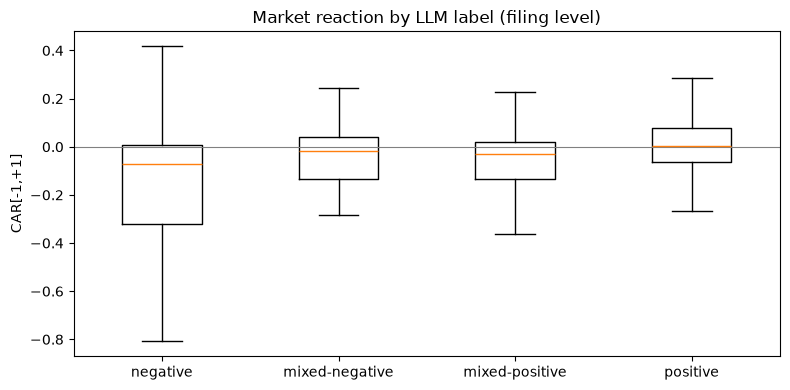

In [9]:
# ---------------------------------------------------------------------------
# Analysis 2 of 2: compare every directional label to the sign of the abnormal
# return, across the whole dataset. 'no_result', 'inconclusive' and the
# undocumented composite labels ('positive/negative' and the rest) carry no
# single directional claim and are excluded; the remaining four categories imply
# a direction the market should have moved in.
#
# Reported at record level (as classified) and at filing level (deduplicated
# via filing_summary), because 1,073 of the 4,539 records sit in multi-drug
# filings and share one CAR between them.
# ---------------------------------------------------------------------------
EXPECTED = {"positive": 1, "mixed-positive": 1, "negative": -1, "mixed-negative": -1}

def sign_table(df, label_col):
    d = df.assign(expected=df[label_col].map(EXPECTED)).dropna(subset=["expected", "car_3day"])
    d = d.assign(disagrees=np.sign(d.car_3day) != d.expected)
    t = d.groupby(label_col).agg(n=("car_3day", "size"),
                                 disagreement_rate=("disagrees", "mean"),
                                 mean_car=("car_3day", "mean"),
                                 median_car=("car_3day", "median"),
                                 sd_car=("car_3day", "std"))
    return t.reindex([c for c in EXPECTED if c in t.index]).round(3), d

rec_tbl, rec_d = sign_table(event_res, "outcome")
fil_tbl, fil_d = sign_table(filing_sum, "primary_outcome")
print("RECORD LEVEL (event_study_results, n=%d directional records)" % len(rec_d))
display(rec_tbl)
print("FILING LEVEL (filing_summary, n=%d directional filings)" % len(fil_d))
display(fil_tbl)
print("Overall record-level disagreement rate: %.1f%%" % (100 * rec_d.disagrees.mean()))

# ---------------------------------------------------------------------------
# What the record-level table is, and is not. Three things are decided above
# without being visible in the output, and each is worth stating rather than
# leaving for a reader to find:
#   - the record level is deliberately *as classified*, so records repeated for
#     the same (accession, drug_name) are counted more than once;
#   - the undocumented composite labels are dropped, because "positive/negative"
#     implies no single direction to test against;
#   - car_3day is winsorised, so the means above are computed on censored tails,
#     and a handful of records sit close enough to zero that their sign is noise.
# None of this changes the conclusion, which is the point of reporting it.
# ---------------------------------------------------------------------------
_dd = rec_d.drop_duplicates(["accession", "drug_name"])
_composite = (~event_res.outcome.isin(list(EXPECTED) + ["inconclusive", "no_result"])).sum()
_bound = ((rec_d.car_3day <= rec_d.car_3day.min()) | (rec_d.car_3day >= rec_d.car_3day.max())).sum()

print("Robustness of the record-level disagreement rate")
print("  as classified          %.1f%%  (n=%d)" % (100 * rec_d.disagrees.mean(), len(rec_d)))
print("  deduplicated           %.1f%%  (n=%d, %d repeated records removed)"
      % (100 * _dd.disagrees.mean(), len(_dd), len(rec_d) - len(_dd)))
print("  composite labels dropped for having no single expected direction: %d records" % _composite)
print("  at the winsorisation bounds: %d records; |CAR| < 0.1%% (sign is noise): %d records"
      % (_bound, (rec_d.car_3day.abs() < 0.001).sum()))
display(pd.concat([rec_tbl.disagreement_rate.rename("as classified"),
                   sign_table(event_res.drop_duplicates(["accession", "drug_name"]),
                              "outcome")[0].disagreement_rate.rename("deduplicated")], axis=1))

from scipy import stats
pos = fil_d.loc[fil_d.primary_outcome == "positive", "car_3day"]
neg = fil_d.loc[fil_d.primary_outcome == "negative", "car_3day"]
u, p = stats.mannwhitneyu(pos, neg)
print("\nDo the labels separate returns at all? positive (n=%d) vs negative (n=%d):"
      % (len(pos), len(neg)))
print("  Mann-Whitney U p = %.2e" % p)
print("  positive: mean %+.2f%%, one-sample t vs 0 p = %.1e" % (100 * pos.mean(), stats.ttest_1samp(pos, 0).pvalue))
print("  negative: mean %+.2f%%, one-sample t vs 0 p = %.1e" % (100 * neg.mean(), stats.ttest_1samp(neg, 0).pvalue))

fig, ax = plt.subplots(figsize=(8, 4))
order = ["negative", "mixed-negative", "mixed-positive", "positive"]
ax.boxplot([fil_d.loc[fil_d.primary_outcome == o, "car_3day"] for o in order],
           tick_labels=order, showfliers=False)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("CAR[-1,+1]"); ax.set_title("Market reaction by LLM label (filing level)")
plt.tight_layout(); plt.show()

In [10]:
# ---------------------------------------------------------------------------
# Investigating the disagreements. Reading the sample suggested most of them are
# not misreadings of the filing: the label describes the trial correctly, but
# the filing it is attached to is not the day the news reached the market. If
# that is right, disagreement should depend on what kind of document the 8-K is
# and on how much restatement language it contains - and it should be strongest
# where the label is most reliable in a genuine announcement.
# ---------------------------------------------------------------------------
fs = filing_sum.merge(filing_txt[["accession", "filing_kind", "n_prior_refs"]],
                      on="accession", how="left")
fs["expected"] = fs.primary_outcome.map(EXPECTED)
d = fs.dropna(subset=["expected", "car_3day"]).copy()
d["agrees"] = np.sign(d.car_3day) == d.expected
d["abs_car"] = d.car_3day.abs()

by_kind = d.groupby("filing_kind").agg(n=("agrees", "size"), sign_agreement=("agrees", "mean"),
                                       median_abs_car=("abs_car", "median"),
                                       sd_car=("car_3day", "std")).round(3)
print("Sign agreement and reaction size by document type")
display(by_kind.sort_values("sign_agreement", ascending=False))

print("Sign agreement by document type x label (cell = agreement rate, n in brackets)")
piv = d.pivot_table(index="filing_kind", columns="primary_outcome", values="agrees",
                    aggfunc=["mean", "size"])
display(piv.round(2))

d["restatement_phrases"] = pd.cut(d.n_prior_refs, [-1, 0, 2, 5, 10**6],
                                  labels=["0", "1-2", "3-5", "6+"])
print("Sign agreement falls monotonically as the filing refers back to earlier disclosures")
display(d.groupby("restatement_phrases", observed=True)
         .agg(n=("agrees", "size"), sign_agreement=("agrees", "mean"),
              median_abs_car=("abs_car", "median")).round(3))

Sign agreement and reaction size by document type


,n,sign_agreement,median_abs_car,sd_car
filing_kind,,,,
results announcement,673,0.629,0.114,0.348
deck / FD update,216,0.532,0.069,0.215
other,126,0.492,0.089,0.247
periodic report,741,0.463,0.051,0.157


Sign agreement by document type x label (cell = agreement rate, n in brackets)


mean                                   \
primary_outcome      mixed-negative mixed-positive negative positive   
filing_kind                                                            
deck / FD update               0.40           0.30     0.73     0.54   
other                          0.33           0.17     0.69     0.48   
periodic report                0.60           0.37     0.53     0.44   
results announcement           0.78           0.33     0.91     0.57   

                               size                                   
primary_outcome      mixed-negative mixed-positive negative positive  
filing_kind                                                           
deck / FD update                  5             27       26      158  
other                             3             12       26       85  
periodic report                  43             67      148      483  
results announcement             18             52      138      465

Sign agreement falls monotonically as the filing refers back to earlier disclosures


,n,sign_agreement,median_abs_car
restatement_phrases,,,
0,1207,0.566,0.078
1-2,424,0.495,0.063
3-5,105,0.381,0.048
6+,20,0.500,0.042


In [11]:
# ---------------------------------------------------------------------------
# Reading a fresh selection of disagreement cases. They are chosen stratified by
# document type rather than by size of move, for two reasons. First, a
# disagreement inside a quarterly report and one inside a genuine announcement
# are candidates for different explanations, and picking on size alone would
# have produced only the second kind. Second, car_3day is winsorised at the 1st
# and 99th percentiles: 54 records (2.1%) sit at exactly -84.2% or +94.5%, so
# ranking on the extreme tail returns ties rather than the true extremes.
# ---------------------------------------------------------------------------
cap_lo, cap_hi = event_res.car_3day.min(), event_res.car_3day.max()
print("Winsorisation caps: %d records at exactly %+.1f%%, %d at exactly %+.1f%% (%.1f%% of rows)"
      % ((event_res.car_3day == cap_lo).sum(), 100 * cap_lo,
         (event_res.car_3day == cap_hi).sum(), 100 * cap_hi,
         100 * ((event_res.car_3day == cap_lo) | (event_res.car_3day == cap_hi)).mean()))

contra = (rec_d[rec_d.disagrees]
          .merge(filing_txt[["accession", "filing_kind", "n_prior_refs"]], on="accession", how="left")
          .assign(abs_car=lambda x: x.car_3day.abs()))
contra = contra[(contra.car_3day > cap_lo) & (contra.car_3day < cap_hi)]

picks = (contra[contra.filing_kind.isin(["results announcement", "periodic report"])]
         .sort_values("abs_car", ascending=False)
         .groupby("filing_kind").head(4)
         .sort_values(["filing_kind", "abs_car"], ascending=[True, False]))
display(picks[["accession", "ticker", "event_date", "drug_name", "outcome", "consensus_type",
               "car_3day", "filing_kind", "n_prior_refs"]].round(3))

for _, r in picks.groupby("filing_kind").head(2).iterrows():
    print("=" * 100)
    print("%s | %s | %s | label=%s | CAR=%+.1f%% | document=%s | restatement phrases=%d"
          % (r.accession, r.ticker, r.drug_name, r.outcome, 100 * r.car_3day,
             r.filing_kind, r.n_prior_refs))
    for s in result_sentences(clean_by_acc.get(r.accession, ""), r.drug_name, k=4):
        print(textwrap.fill(s, 98, initial_indent="   - ", subsequent_indent="     "))
    print()

Winsorisation caps: 27 records at exactly -84.2%, 27 at exactly +94.5% (2.1% of rows)


,accession,ticker,event_date,drug_name,outcome,consensus_type,car_3day,filing_kind,n_prior_refs
900,0001390478-22-000030,SLS,2022-11-14 00:00:00,galinpepimut-S (GPS) + pembrolizumab,positive,b3b_inconclusive_override,-0.680,periodic report,4
901,0001404644-24-000103,NGNE,2024-11-18 00:00:00,NGN-401,mixed-positive,b3b_inconclusive_override,-0.678,periodic report,2
773,0001193125-25-180830,IOBT,2025-08-14 00:00:00,Cylembio (imsapepimut and etimupepimut),negative,same_direction,0.640,periodic report,0
1029,0001564590-21-042348,AXSM,2021-08-09 00:00:00,AXS-05 (dextromethorphan-bupropion),positive,agree,-0.578,periodic report,2
729,0001193125-23-000830,VERA,2023-01-03 00:00:00,atacicept,positive,agree,-0.717,results announcement,0
885,0001326190-23-000017,ALT,2023-03-21 00:00:00,pemvidutide,positive,agree,-0.706,results announcement,1
1075,0001628280-25-044223,SKYE,2025-10-06 00:00:00,nimacimab,mixed-positive,agree,-0.689,results announcement,0
871,0001213900-25-092614,MLTX,2025-09-29 00:00:00,sonelokimab,mixed-positive,agree,-0.666,results announcement,1


0001390478-22-000030 | SLS | galinpepimut-S (GPS) + pembrolizumab | label=positive | CAR=-68.0% | document=periodic report | restatement phrases=4
   - "As announced this morning, we look forward to executing on our revised protocol and
     statistical analysis plan (SAP) for the Phase 3 registrational REGAL study of galinpepimut-S
     (GPS) in patients with acute myeloid leukemia (AML) as well as evaluating the next steps for
     our ovarian cancer program for GPS in combination with PD1 inhibitors following our release
     last week of the promising final top-line data from our Phase 1/2 study of GPS in combination
     with pembrolizumab (Keytruda®).
   - Phase 1/2 Study with Keytruda: On November 10, 2022, SELLAS announced confirmatory top-line
     data showing survival and clinical benefits based on the final analysis of the Phase 1/2
     clinical trial of GPS in combination with pembrolizumab (Keytruda) in patients with WT1+
     relapsed or refractory platinum-resistant ad

In [12]:
# ---------------------------------------------------------------------------
# Three further checks the sample pointed at, run over the whole table:
#   (a) is the same drug in the same filing classified more than once, and do
#       those duplicates agree with each other?
#   (b) does the classified drug name appear anywhere in the filing at all?
#       (the methodology notes that drug matching between prompts used substring
#       containment, which can cross-match)
#   (c) does the provenance recorded in consensus_type predict reliability?
# ---------------------------------------------------------------------------
named = consensus.drug_name.notna() & (consensus.drug_name.fillna("").str.strip() != "")
grp = consensus[named].groupby(["accession", "drug_name"])["outcome"]
n_rows, n_distinct = grp.transform("size"), grp.transform("nunique")
dupes = pd.Series(0, index=consensus.index)
dupes[named] = np.where(n_distinct > 1, 2, np.where(n_rows > 1, 1, 0))
consensus["dup_status"] = dupes.map({0: "unique", 1: "repeated, same label",
                                     2: "repeated, CONFLICTING labels"})
print("(a) Duplicate (filing, drug) classifications")
display(consensus.dup_status.value_counts().to_frame("records"))
print("Example of a conflicting duplicate:")
display(consensus[consensus.dup_status == "repeated, CONFLICTING labels"]
        .sort_values(["accession", "drug_name"])
        [["accession", "ticker", "drug_name", "outcome", "consensus_type"]].head(6))

raw_by_acc = filing_txt.set_index("accession")["filing_text"]

def drug_present(acc, drug, outcome):
    """Search the RAW filing, not the cleaned one.

    The safe-harbour block routinely lists a company's product names, and
    clean_filing_text() removes it. Checking against the cleaned text would
    therefore report a drug as absent when all my cleaning did was delete the
    only place it was mentioned - which is a different (and much weaker) claim
    than 'this drug is not in this filing at all'.

    keep_parenthetical=True for the same reason: the question here is whether
    the name appears at all, so the brand or formulation name has to be searched
    too. Without it 199 records were reported absent on a search that had no
    tokens to run.
    """
    if outcome == "no_result" or not isinstance(drug, str) or not drug.strip():
        return np.nan
    text = raw_by_acc.get(acc)
    if text is None:
        return np.nan
    toks, low = drug_tokens(drug, keep_parenthetical=True), text.lower()
    return bool(toks) and any(t in low for t in toks)

consensus["drug_in_text"] = [drug_present(a, d, o) for a, d, o
                             in zip(consensus.accession, consensus.drug_name, consensus.outcome)]
absent = consensus.drug_in_text == False
print("\n(b) Classified drug name not found anywhere in the filing: %d of %d classifications "
      "that name a drug (%.1f%%)"
      % (absent.sum(), consensus.drug_in_text.notna().sum(),
         100 * absent.sum() / consensus.drug_in_text.notna().sum()))
display(consensus[absent].outcome.value_counts().head(6).to_frame("records"))

print("\n(c) Reliability by recorded provenance (directional, event-linked records)")
prov = rec_d.assign(agrees=~rec_d.disagrees).groupby("consensus_type").agg(
    n=("agrees", "size"), sign_agreement=("agrees", "mean"),
    median_abs_car=("car_3day", lambda s: s.abs().median())).round(3)
display(prov.sort_values("n", ascending=False))

(a) Duplicate (filing, drug) classifications


,records
dup_status,
unique,4280
"repeated, same label",170
"repeated, CONFLICTING labels",89


Example of a conflicting duplicate:


,accession,ticker,drug_name,outcome,consensus_type
6,0000059478-13-000053,LLY,ramucirumab,negative,b3b_inconclusive_override
4494,0000059478-13-000053,LLY,ramucirumab,positive/negative,flagged_disagreement
27,0000059478-18-000133,LLY,Cyramza (ramucirumab),positive,b1a_only
29,0000059478-18-000133,LLY,Cyramza (ramucirumab),mixed-negative,b1a_only
4495,0000059478-19-000171,LLY,Tanezumab,mixed-positive/mixed-negative,flagged_disagreement
4496,0000059478-19-000171,LLY,Tanezumab,mixed-negative/mixed-positive,flagged_disagreement



(b) Classified drug name not found anywhere in the filing: 256 of 2845 classifications that name a drug (9.0%)


,records
outcome,
positive,166
negative,30
mixed-positive,29
inconclusive,20
mixed-negative,7
mixed-positive/mixed-negative,1



(c) Reliability by recorded provenance (directional, event-linked records)


,n,sign_agreement,median_abs_car
consensus_type,,,
agree,1268,0.550,0.075
b1a_only,390,0.474,0.051
b3b_only,346,0.491,0.051
b3b_inconclusive_override,325,0.489,0.051
same_direction,60,0.500,0.068
b1a_inconclusive_override,3,0.333,0.063


#### What the label-versus-return comparison shows

The labels do carry real information. Filings labelled `negative` average a **−19.2%** three-day abnormal return and those labelled `positive` **+3.7%**; the two distributions are separated at p ≈ 3.5 × 10⁻³³. Whatever its defects, this is not a pipeline that has classified at random.

But sign agreement is very uneven, and in one place it is no better than a coin toss:

| Label | n (filings) | Disagreement with return sign | Mean CAR |
|---|---|---|---|
| negative | 338 | 29.0% | −19.2% |
| mixed-negative | 69 | 37.7% | −10.4% |
| positive | 1,191 | **49.0%** | +3.7% |
| mixed-positive | 158 | **67.1%** | **−6.6%** |

Two things stand out. A `positive` label predicts the direction of the move no better than a coin. And `mixed-positive` is *negative* on average: the market treats it as bad news. That matters beyond this question, because the consensus rules in §5 of the methodology resolve `positive` vs `mixed-positive` to `positive` as a "same direction" pair, and `outcome_group` in the event study tables maps `mixed-positive` into `Positive`. Both treat as favourable a category the market reliably marks down.

#### Separating the causes

Disagreement is not evidence of error on its own. The analysis below separates four distinct causes rather than attributing all of them to market efficiency.

**(a) The filing is not the disclosure event — the largest single cause.** Splitting on document type, sign agreement is **62.9%** in genuine results announcements against **46.3%** in periodic reports, and the median absolute reaction is 11.4% against 5.1%. The effect is sharpest exactly where the label should be most informative: a `negative` label agrees with the return **91%** of the time in an announcement and **53%** of the time in a quarterly report. The same gradient appears in restatement language independently of document type — agreement falls from 56.6% in filings with no backward reference to 38.1% in those with three to five, and the median move shrinks with it. This is what mis-dated events look like: as the news gets older, the label keeps describing the trial correctly while the return beside it converges on noise.

This is the defect that prompt **B1b** was designed to catch. Round 3 of the prompt selection tested a variant that flagged "whether the announcement was new rather than a restatement of previously disclosed results", and B1a was selected over it. The methodology records the choice without recording what it cost; the answer is that roughly half the directional records are attached to filings that are not the event.

**(b) The label attaches to the wrong news within the same filing.** Neurogene's November 2024 filing (`0001404644-24-000103`) is labelled `mixed-positive`, anchored on "the favorable safety and efficacy data for NGN-401 at the 1E15 vg dose". The filing's actual news, two sentences later, is a treatment-related serious adverse event at the higher dose and a halt to further dosing there. The market fell **67.8%**. Sellas (`0001390478-22-000030`) is labelled `positive` from a top-line result announced four days earlier, while the filing itself announces a change to the Phase 3 statistical analysis plan; the market fell **68.0%**.

Both follow from the quote-first design working exactly as specified. The prompts anchor the label to a sentence that genuinely appears in the filing and reads like a result — but neither prompt is asked which disclosure in the filing is *material*. Safety events, dose pauses and protocol changes are systematically under-weighted because they are not phrased as endpoint outcomes.

**(c) The label reproduces the sponsor's adjective instead of assessing the evidence.** Q32 Bio's bempikibart Phase 2a filing describes "encouraging clinical activity" and "emerging signals" and is labelled `mixed-positive`; Pyxis Oncology's release of "positive preliminary data" from a seven-patient Phase 1 cohort is labelled `positive`. The documented definition of `positive` is "primary endpoint met with statistical significance, or unambiguous statement of success" — neither filing meets it. Nothing in either prompt asks whether the quoted sentence is a result or a characterisation of one.

**(d) Genuine market pricing.** What survives after (a) to (c) is a real and interpretable asymmetry. Within results announcements, `negative` labels agree with the return 91% of the time and `positive` labels only 57%. Bad news is a surprise; good news is substantially priced in before the filing, and a met endpoint that falls short of what was hoped for still produces a fall. This is not a defect in the data — it is the phenomenon the CFO is asking about, and it is why Question 3 is a question about magnitude rather than direction.

#### Where these patterns come from in the methodology

| Design choice recorded in the methodology | Pattern observed here |
|---|---|
| Round 3 tested B1b, which flagged new results vs restatements; B1a was selected instead | Roughly half of directional records sit in periodic reports and decks; sign agreement 63% vs 46% |
| Quote-first anchoring: the label must be grounded in a verbatim sentence | Labels attach to the most result-like sentence rather than the most material one — safety events and protocol changes are missed (NGNE, SLS above) |
| B3b defaults to `inconclusive` where it cannot populate a statistics field | 4 of 5 sampled `inconclusive` records are trials that have not reported; the category overlaps `no_result` |
| Consensus rule resolves `positive`/`mixed-positive` to `positive` as "same direction" | `mixed-positive` has a mean CAR of −6.6% and a 67% sign-disagreement rate |
| Drug matching between prompts uses substring containment | 256 records (9.0%) name a drug that appears nowhere in the filing, searching the brand and formulation names as well as the generic; 89 records carry two conflicting labels for the same drug in the same filing |
| Prompts tuned on 10 adversarially selected filings, never re-validated on a random sample; the 37% that is `no_result` represented only through disagreement cases | The stratified sample above is the first random look at that bulk. The sampled `no_result` records are all correct, but restatements inside them are treated differently from restatements elsewhere |
| Statistics extracted but never written to the database | `statistics` empty in all 4,539 rows, `evidence` in all but 45 — the quote-first grounding cannot be audited from this database at all |
| Winsorisation applied to the CAR after cumulating | 54 records (2.1%) pinned at exactly −84.2% or +94.5%; the tails are censored, not measured, and cannot be ranked |

## Q1b: Construct flagging approach (5 marks)

Question 1a produced a set of specific, recurring failure modes. This section turns each of them into a rule that can be evaluated for every one of the 4,539 records, combines them into a single risk score, and uses that score to decide both **what** to review and **in what order**.

Two design decisions are worth stating up front.

**The signals are the Q1a findings, not a generic quality checklist.** Every signal below is traceable to something established in 1a, and the table in the next cell records that link explicitly. Nothing is included because it sounded like a reasonable data-quality check.

**Weights reflect what kind of problem each signal is.** A weight of **3** marks a record that is demonstrably defective on its face — the same drug in the same filing carrying two different labels, or a drug name that appears nowhere in the filing. A weight of **2** marks a record whose label may read perfectly well but which cannot be used as an event study observation, because the filing is not the disclosure event or because the market moved hard against the label. A weight of **1** marks circumstances that raise the probability of error without demonstrating one — single-prompt provenance, a category whose boundary was applied inconsistently, restatement language.

A record is flagged at a score of **3 or more**. That is the point at which either one demonstrated defect, or one event-validity problem plus one risk factor, has accumulated — anything below it is a single soft signal, which on the 1a evidence is not enough to justify an analyst's time.

In [13]:
# ---------------------------------------------------------------------------
# Q1b: build the flagging signals. Each signal below is one of the failure
# modes established in Q1a, expressed as a rule that can be evaluated for every
# one of the 4,539 records. Weights are 3 for a defect that makes the record
# wrong on its face, 2 for one that makes the record unusable for the event
# study even if the label reads correctly, and 1 for a circumstance that raises
# the prior on error without demonstrating one.
# ---------------------------------------------------------------------------
flag = consensus.merge(filing_txt[["accession", "filing_kind", "n_prior_refs"]],
                       on="accession", how="left") \
                .merge(car_by_row, on=["accession", "drug_name"], how="left")

# Weight 3 - a demonstrated defect in the record itself
flag["S1_conflicting_duplicate"] = (flag.dup_status == "repeated, CONFLICTING labels").astype(int)
flag["S2_drug_absent"]           = (flag.drug_in_text == False).astype(int)
flag["S3_prompt_disagreement"]   = (flag.consensus_type == "flagged_disagreement").astype(int)
flag["S4_missed_result"]         = ((flag.outcome == "no_result") &
                                    (flag.filing_kind == "results announcement")).astype(int)
# Weight 2 - the label may read correctly but the event it is attached to is wrong
flag["S5_not_an_announcement"]   = ((flag.outcome != "no_result") &
                                    (flag.filing_kind != "results announcement")).astype(int)
flag["S6_return_contradiction"]  = ((flag.outcome.map(EXPECTED).notna()) &
                                    (np.sign(flag.car_3day) != flag.outcome.map(EXPECTED)) &
                                    (flag.car_3day.abs() >= 0.10)).astype(int)
# Weight 1 - elevated risk
flag["S7_repeated_record"]       = (flag.dup_status == "repeated, same label").astype(int)
flag["S8_restatement_language"]  = ((flag.outcome != "no_result") & (flag.n_prior_refs >= 3)).astype(int)
flag["S9_single_prompt"]         = flag.consensus_type.isin(["b1a_only", "b3b_only"]).astype(int)
flag["S10_stats_override"]       = flag.consensus_type.isin(
    ["b3b_inconclusive_override", "b1a_inconclusive_override"]).astype(int)
flag["S11_boundary_category"]    = flag.outcome.isin(
    ["mixed-positive", "mixed-negative", "inconclusive"]).astype(int)

WEIGHTS = {"S1_conflicting_duplicate": 3, "S2_drug_absent": 3, "S3_prompt_disagreement": 3,
           "S4_missed_result": 3, "S5_not_an_announcement": 2, "S6_return_contradiction": 2,
           "S7_repeated_record": 1, "S8_restatement_language": 1, "S9_single_prompt": 1,
           "S10_stats_override": 1, "S11_boundary_category": 1}
SIGNAL_SOURCE = {
    "S1_conflicting_duplicate": "Q1a(c): 89 records where one drug in one filing carries two different labels",
    "S2_drug_absent":           "Q1a(c): 256 records name a drug that appears nowhere in the filing",
    "S3_prompt_disagreement":   "Methodology: the 45 records the pipeline itself could not resolve",
    "S4_missed_result":         "Q1a: no_result is the untested 37%; a results headline labelled no_result is a candidate miss",
    "S5_not_an_announcement":   "Q1a(2): sign agreement 63% in announcements vs 46% in periodic reports",
    "S6_return_contradiction":  "Q1a(2): large moves against the label are the ones that distort Q3",
    "S7_repeated_record":       "Q1a(c): 170 records are exact repeats and double-count in any fit",
    "S8_restatement_language":  "Q1a(2): agreement falls 57% -> 38% as restatement phrases rise",
    "S9_single_prompt":         "Methodology: ~969 single-prompt records have no second reading",
    "S10_stats_override":       "Methodology: 373 labels rest on B1a alone after B3b defaulted to inconclusive",
    "S11_boundary_category":    "Q1a(1): the mixed/inconclusive boundaries were applied inconsistently",
}
flag["risk_score"] = sum(flag[k] * w for k, w in WEIGHTS.items())

print("Signals, their weight, and the Q1a finding each comes from\n")
display(pd.DataFrame({"weight": WEIGHTS, "records_triggering": flag[list(WEIGHTS)].sum(),
                      "from": SIGNAL_SOURCE}).sort_values(["weight", "records_triggering"],
                                                          ascending=[False, False]))

Signals, their weight, and the Q1a finding each comes from



,weight,records_triggering,from
S4_missed_result,3,286,Q1a: no_result is the untested 37%; a results ...
S2_drug_absent,3,256,Q1a(c): 256 records name a drug that appears n...
S1_conflicting_duplicate,3,89,Q1a(c): 89 records where one drug in one filin...
S3_prompt_disagreement,3,45,Methodology: the 45 records the pipeline itsel...
S5_not_an_announcement,2,1946,Q1a(2): sign agreement 63% in announcements vs...
S6_return_contradiction,2,318,Q1a(2): large moves against the label are the ...
S9_single_prompt,1,969,Methodology: ~969 single-prompt records have n...
S11_boundary_category,1,499,Q1a(1): the mixed/inconclusive boundaries were...
S10_stats_override,1,373,Methodology: 373 labels rest on B1a alone afte...
S8_restatement_language,1,282,Q1a(2): agreement falls 57% -> 38% as restatem...


,threshold,flagged,proportion
0,1,2741,0.604
1,2,2478,0.546
2,3,1926,0.424
3,4,852,0.188
4,5,438,0.096


Flagged 1926 of 4539 classifications (42.4%) at risk_score >= 3



,classifications,flagged,proportion_flagged,documented_category
outcome,,,,
positive,1898,1057,0.557,True
no_result,1694,286,0.169,True
negative,403,133,0.330,True
inconclusive,209,168,0.804,True
mixed-positive,205,172,0.839,True
mixed-negative,85,65,0.765,True
mixed-positive/mixed-negative,13,13,1.000,False
positive/negative,10,10,1.000,False
mixed-positive/negative,8,8,1.000,False


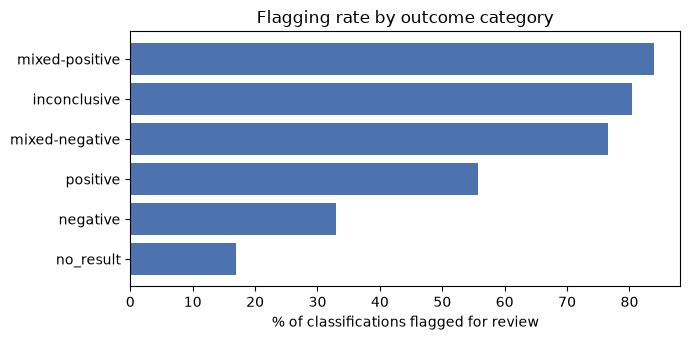

In [14]:
# ---------------------------------------------------------------------------
# Choose the threshold, apply it to all 4,539 classifications, and report.
# ---------------------------------------------------------------------------
calib = pd.DataFrame({"threshold": range(1, 6)})
calib["flagged"] = [int((flag.risk_score >= t).sum()) for t in calib.threshold]
calib["proportion"] = (calib.flagged / len(flag)).round(3)
display(calib)

THRESHOLD = 3     # see the note below the output for why
flag["flagged"] = (flag.risk_score >= THRESHOLD).astype(int)

print("Flagged %d of %d classifications (%.1f%%) at risk_score >= %d\n"
      % (flag.flagged.sum(), len(flag), 100 * flag.flagged.mean(), THRESHOLD))

by_cat = flag.groupby("outcome").agg(classifications=("flagged", "size"),
                                     flagged=("flagged", "sum"))
by_cat["proportion_flagged"] = (by_cat.flagged / by_cat.classifications).round(3)
by_cat["documented_category"] = by_cat.index.isin(SIX)
display(by_cat.sort_values("classifications", ascending=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
sub = by_cat[by_cat.documented_category].sort_values("proportion_flagged")
ax.barh(sub.index, 100 * sub.proportion_flagged, color="#4c72b0")
ax.set_xlabel("% of classifications flagged for review")
ax.set_title("Flagging rate by outcome category")
plt.tight_layout(); plt.show()

In [15]:
# ---------------------------------------------------------------------------
# Ordering the review queue. Flagging says which records are doubtful; it does
# not say which are worth an analyst's time. A wrong label on a filing that
# moved the stock 60% distorts the Question 3 regression far more than a wrong
# label on one that moved it 0.5%, and a record with no event study attached to
# it does not enter Questions 2 or 3 at all. Priority therefore combines how
# likely the record is to be wrong with how much the downstream work depends on
# it being right.
# ---------------------------------------------------------------------------
flag["downstream_leverage"] = flag.car_3day.abs().rank(pct=True).fillna(0.0)
flag["review_priority"] = flag.risk_score * (1 + flag.downstream_leverage)

queue = flag[flag.flagged == 1].nlargest(20, "review_priority")
print("Top of the manual-review queue (20 of %d flagged)\n" % int(flag.flagged.sum()))
display(queue[["accession", "ticker", "filing_date", "drug_name", "outcome", "consensus_type",
               "car_3day", "filing_kind", "risk_score", "review_priority"]].round(3))

# Tiers are sized by what a reviewer can actually do, not by an arbitrary score cut:
# the top 50 records are worth reading in full, the next 250 spot-checking, and the
# remainder are better handled by excluding them from the sensitive analyses.
flag["review_tier"] = pd.Series(pd.NA, index=flag.index, dtype="object")
ranked = flag[flag.flagged == 1].sort_values("review_priority", ascending=False).index
flag.loc[ranked[:50], "review_tier"] = "tier 1 - read in full"
flag.loc[ranked[50:300], "review_tier"] = "tier 2 - spot check"
flag.loc[ranked[300:], "review_tier"] = "tier 3 - exclude or screen"
print("Review effort by tier:")
display(flag.review_tier.value_counts().sort_index().to_frame("records"))
print("Flagged records carrying no CAR, so never entering Q2/Q3: %d of %d"
      % (int(((flag.flagged == 1) & flag.car_3day.isna()).sum()), int(flag.flagged.sum())))

Top of the manual-review queue (20 of 1926 flagged)



,accession,ticker,filing_date,drug_name,outcome,consensus_type,car_3day,filing_kind,risk_score,review_priority
4533,0001387131-20-004018,TNXP,2020-04-22,TNX-102 SL,mixed-positive/negative,flagged_disagreement,-0.135,deck / FD update,11,19.116
4534,0001387131-20-004018,TNXP,2020-04-22,TNX-102 SL,negative/mixed-positive,flagged_disagreement,-0.135,deck / FD update,11,19.116
3348,0001404644-24-000103,NGNE,2024-11-18,NGN-401,mixed-positive,b3b_inconclusive_override,-0.678,periodic report,9,17.659
3906,0001564590-21-011096,ELVN,2021-03-05,IMR-687,mixed-positive,b1a_only,-0.283,periodic report,9,16.885
3967,0001599298-25-000156,SMMT,2025-10-20,ivonescimab,mixed-positive,agree,-0.185,periodic report,9,16.243
4514,0001193125-15-281025,NGNE,2015-08-06,AQX-1125,mixed-positive/negative,flagged_disagreement,0.945,periodic report,8,15.960
4515,0001193125-15-281025,NGNE,2015-08-06,AQX-1125,negative/mixed-positive,flagged_disagreement,0.945,periodic report,8,15.960
4537,0001615774-16-007052,TNXP,2016-09-06,TNX-102 SL (cyclobenzaprine HCl sublingual tab...,negative/positive,flagged_disagreement,-0.718,deck / FD update,8,15.751
4502,0001104659-19-057505,CYCN,2019-10-30,praliciguat,mixed-positive/negative,flagged_disagreement,-0.695,periodic report,8,15.726
2918,0001193125-25-277515,LYRA,2025-11-12,LYR-210,mixed-positive,b3b_only,-0.134,periodic report,9,15.636


Review effort by tier:


,records
review_tier,
tier 1 - read in full,50
tier 2 - spot check,250
tier 3 - exclude or screen,1626


Flagged records carrying no CAR, so never entering Q2/Q3: 404 of 1926


#### What the flagging shows

**1,926 of 4,539 classifications (42.4%) are flagged for review.** The breakdown by category is the important output, because it says which parts of the dataset the IR team can lean on and which they cannot:

| Category | Records | Flagged | Proportion |
|---|---|---|---|
| `no_result` | 1,694 | 286 | 16.9% |
| `negative` | 403 | 133 | **33.0%** |
| `positive` | 1,898 | 1,057 | 55.7% |
| `mixed-negative` | 85 | 65 | 76.5% |
| `inconclusive` | 209 | 168 | 80.4% |
| `mixed-positive` | 205 | 172 | **83.9%** |
| 7 undocumented composite labels | 45 | 45 | 100% |

The ordering matches the Q1a findings closely, which is the main check that the score behaves sensibly rather than just producing a number. Among the directional categories, `negative` — the one shown above to agree with the market 91% of the time in a genuine announcement — is by some way the least flagged. The two mixed categories, whose boundary was shown to follow the sponsor's framing rather than the endpoint, are flagged at roughly eight in ten, as is `inconclusive`, which was shown to be functioning as a second `no_result`.

**A 42% flag rate needs interpreting, not just reporting.** It does not mean 42% of the labels are wrong. The largest single contributor by far is event validity: 1,946 records sit in filings that are not results announcements, and in most of those the label is *right about the trial* while the abnormal return next to it is measuring a quarterly earnings reaction. For Question 3 that is the more damaging of the two problems, because a wrong label adds noise whereas a mis-dated event adds noise correlated with document type — and document type is itself correlated with sponsor size and with the size of the move. The signals that indicate the label itself is wrong (conflicting duplicates, absent drug names, unresolved prompt disagreements) reach 356 records, or 8% of the table. That is the number to quote if the question is "how often is the classification wrong", as distinct from "how often is this row unusable".

**`no_result` is flagged at only 16.9%, and that is a limitation rather than a clean bill of health.** These records carry no directional claim and are excluded from the event study, so most signals cannot fire on them: there is no drug name to check, no return to contradict, no boundary to misapply. The one signal that reaches them — a filing whose headline announces results but which was classified as containing none — picks up 286 candidates. The methodology is candid that this 37% of the corpus is the least validated part of the pipeline, and nothing here changes that. It is where I would spend manual review effort if the IR team needed confidence that no material readout had been dropped.

**Ordering the queue.** Flagging alone puts 1,926 records in front of an analyst with no indication of which matter. Priority multiplies the risk score by downstream leverage — the percentile rank of |CAR| — because a mislabelled event that moved the stock 60% distorts the Question 3 fit far more than one that moved it half a per cent, and flagged records with no CAR at all never enter Questions 2 or 3. Tiers are then sized by what a reviewer can realistically do rather than by a score cut: 50 records to read in full, 250 to spot-check, the remainder to be handled by exclusion.

The resulting tier 1 is a good check on the whole approach. It is dominated by `mixed-positive` labels sitting in periodic reports and investor decks alongside falls of 15–70% — Neurogene's NGN-401, Lyra's LYR-210, Ocular's OTX-TP, Summit's ivonescimab — plus the unresolved prompt disagreements. That is precisely the intersection of failure modes Q1a identified, arrived at mechanically rather than by picking cases that suited the story.

**What I would do with this in practice.** Read tier 1 by hand. For Question 3, treat the event-validity signal as an exclusion rather than a review item: restricting the modelling set to results announcements costs sample size but removes the mis-dated observations wholesale, and Question 3b is the place to measure what that trade actually buys. For Question 2, which is descriptive and does not partition, the flagged records can stay in — a mis-dated event still describes a real trial, and it is the trial's characteristics, not the timing of its disclosure, that drive the clustering.

## Q1c: Clean and vectorise the data (5 marks)

The brief says cleaning is judged on whether it serves the uses downstream, not on how exhaustive it is. The uses are two, and they place different demands on the features:

- **Question 2** clusters trials to find comparables for the three Asclepius readouts. It is descriptive, uses the whole dataset and does not partition. What it needs from the text is *topic*: what disease, what modality, what kind of study.
- **Question 3** predicts signed CAR under cross-validation. What it needs from the text is *polarity*: whether the result was good or bad, and how emphatically. And every step that learns from the data has to be fitted inside the fold.

So this section does four things: look at the text before deciding what to do to it; clean the structured fields the two questions actually use; establish which columns cannot be used at all because they are not observable at the filing date; and build a text representation, then test whether it is fit for both uses rather than assuming it.

In [16]:
# ---------------------------------------------------------------------------
# Q1c step 1: look at the text before deciding what to do to it. The filing text
# was extracted programmatically and handed over uncleaned, so the question is
# what is actually in it that a model should not see.
# ---------------------------------------------------------------------------
raw = filing_txt.filing_text
print("Filing text, raw: %d filings, %d - %d characters (median %d)"
      % (len(raw), raw.str.len().min(), raw.str.len().max(), raw.str.len().median()))

# The minimum above is 0, so some filings arrive with no text at all. Those
# cannot be cleaned, vectorised or read, and any classification attached to one
# rests on nothing, so it is worth knowing how many there are before going on.
_empty = raw.str.len() == 0
_empty_acc = set(filing_txt.loc[_empty, "accession"])
print("Filings with no text at all: %d; classifications attached to them: %d"
      % (_empty.sum(), consensus.accession.isin(_empty_acc).sum()))

_example = filing_txt.accession.iloc[0]
print("\nFirst 600 characters of %s, verbatim:\n" % _example)
print(textwrap.fill(raw.iloc[0][:600], 98))

probe = {
    "SEC cover page ('Check the appropriate box')": r"Check the appropriate box below",
    # The hyphen has to be optional-with-spaces: slide decks emit "forward -
    # looking statements", and the probe two rows down says 39% of filings are
    # decks. Searching the plain spelling alone undercounts this by 159 filings.
    "Safe-harbour / forward-looking block":         r"forward\s*-\s*looking statements",
    "Signature page":                               r"Pursuant to the requirements of the Securities",
    "Smart quotes / bullet glyphs":                 r"[\u2018\u2019\u201c\u201d\u25aa\u2022\u00b7]",
    "Slide-deck spaced hyphens ('well - tolerated')": r"[a-z]{3,} - [a-z]{3,}",
}
print("\nHow widespread each issue is:")
display(pd.DataFrame({"filings_affected": {k: int(raw.str.contains(v, regex=True, case=False).sum())
                                           for k, v in probe.items()}})
        .assign(pct=lambda d: (100 * d.filings_affected / len(raw)).round(1)))

print("\nEffect of clean_filing_text() defined in Q1a:")
display(pd.DataFrame({"raw": raw.str.len().describe(), "cleaned": filing_txt.clean.str.len().describe()})
        .round(0))

Filing text, raw: 3794 filings, 0 - 318166 characters (median 19186)
Filings with no text at all: 1; classifications attached to them: 1

First 600 characters of 0000059478-12-000018, verbatim:

 8-K 1 q38kearningsrelease.htm 8-K Q3 8K Earnings Release SECURITIES AND EXCHANGE COMMISSION
Washington, D.C. 20549 ________________ FORM 8-K Current Report Pursuant to Section 13 or 15(d) of
the Securities Exchange Act of 1934 ________________ Date of Report (Date of earliest event
reported): October 24, 2012 ELI LILLY AND COMPANY (Exact name of registrant as specified in its
charter) Indiana (State or Other Jurisdiction of Incorporation) Lilly Corporate Center
Indianapolis, Indiana (Address of Principal Executive Offices) 001-06351 (Commission File Number)
35-0470950 (I.R.S. Employer Identif

How widespread each issue is:


,filings_affected,pct
SEC cover page ('Check the appropriate box'),1590,41.9
Safe-harbour / forward-looking block,3548,93.5
Signature page,1498,39.5
Smart quotes / bullet glyphs,3742,98.6
Slide-deck spaced hyphens ('well - tolerated'),1478,39.0



Effect of clean_filing_text() defined in Q1a:


,raw,cleaned
count,3794.0,3794.0
mean,27309.0,22530.0
std,29297.0,29149.0
min,0.0,0.0
25%,12743.0,8542.0
50%,19186.0,13906.0
75%,29985.0,24599.0
max,318166.0,317009.0


#### What the text needed, and what was deliberately left alone

The filing text is raw EDGAR output and carries three kinds of material that would dominate any vectorisation while saying nothing about the trial:

- the **SEC cover page** (41.9% of filings), which is close to identical wherever it appears;
- the **safe-harbour block** (93.5% — the most widespread of the three), which is long, formulaic, and — importantly — full of exactly the vocabulary a result classifier would key on ("futility analyses", "interim results", "the success, timing and cost of our ongoing clinical trials");
- the **exhibit index and signature page** (39.5%).

Together these are 17.5% of all characters. Removing them takes the median filing from 19,186 to 13,905 characters. The safe-harbour block is the one that matters most: it is the reason an uncleaned embedding of two filings with opposite outcomes still looks similar.

There is also character-level damage from the extraction: smart quotes and bullet glyphs in 98.6% of filings, and spaced hyphens in 39.0%, so "well-tolerated" arrives as "well - tolerated" and would tokenise as three tokens. These are normalised. The cover-page, signature and spaced-hyphen counts all sit near 39–42% because they are format-dependent rather than independent: roughly two fifths of the corpus arrives as a full 8-K with a cover and signature page, and roughly two fifths as a slide deck. The cleaning has to serve both.

One filing arrives with **no text at all**, carrying one classification with it. It cannot be cleaned, vectorised or read, and the label attached to it rests on nothing.

**One downstream check on the cleaning.** `classify_filing()` in Q1a reads this cleaned text and decides its document type from the first 1,200 characters before falling back to the body, so a cleaning change moves the Q1a document split and the Q1b event-validity signal with it. That window was tested from 600 to 4,000 characters: between 25 and 165 of the 3,794 filings reclassify (0.7% to 4.4%), almost all of them decks read as announcements as the window widens, and the finding Analysis 2 rests on holds throughout — sign agreement 62.9–63.7% in results announcements against 46.1–46.6% in periodic reports, a gap of 16.4 to 17.6 points at every setting. 1,200 was set before the sample was read and kept, although it is not the best-scoring value against the 30 hand-read filings (23/30 exact and 28/30 on the announcement split, where 2,400 scores 25/30 and 30/30); tuning it on the same documents used to validate the classifier would have made that validation circular.

**What was deliberately left alone.** Numbers, p-values and units are kept: "p=0.009" and "did not meet its primary endpoint" are the sentences the whole analysis turns on, and a conventional clean that strips digits and punctuation would destroy them. No stemming or stopword removal is applied to the text passed to the sentence encoder, because the encoder is trained on ordinary prose and negation is precisely what has to survive. The `indication` and `phase` free-text fields are normalised for modelling but the originals are retained, because Question 2's manual validation needs the human-readable version.

**On the analysis unit.** Questions 2 and 3 work at the level of one classified trial result with an observed market reaction, so cleaning is done on `event_study_enriched` rather than on `consensus_outcomes`. The duplicate records found in Q1a are dropped here; the 1,073 records sitting in multi-drug filings are kept, because each is a distinct trial, but they share one CAR between them and that has to be handled in Question 3 rather than pretended away.

In [17]:
# ---------------------------------------------------------------------------
# Q1c step 2: the structured fields. The analysis unit for Questions 2 and 3 is
# one classified trial result with an observed market reaction, so cleaning is
# done on event_study_enriched. Only the problems that matter downstream are
# fixed: free-text phase, numeric fields stored as text, the duplicate records
# found in Q1a, and the fields that cannot be used because they are not
# observable at the filing date.
# ---------------------------------------------------------------------------
enriched = pd.read_sql("SELECT * FROM event_study_enriched", conn)
print("event_study_enriched: %d rows, %d filings" % (len(enriched), enriched.accession.nunique()))

# (i) phase is free text: 'Phase 3', 'Phase III', 'Phase 2b', 'Pivotal', ...
print("\nDistinct raw phase strings: %d. phase_clean already collapses most of them:"
      % enriched.phase.nunique())
display(enriched.phase_clean.value_counts(dropna=False).to_frame("rows").head(8))

def phase_bucket(p):
    """Collapse 234 free-text phase strings into five buckets.

    Every test is anchored on a word boundary. An unanchored "4" in s matched
    the digit anywhere in the string, so trial names and durations were read as
    Phase 4 - "Phase 3 (EF-14 pivotal trial)", "Phase 2/3 (Study 045)",
    "Phase 1b (24-week extension)" - which was six of the thirty rows in the
    smallest bucket. \\b4\\b alone still matches "Phase 3b/4", because the slash
    is a word boundary, while refusing the trailing 4 of "EF-14". The a/b suffixes are matched too, so "Phase 3b" and
    "Phase IIb" bucket rather than falling through to unknown.
    """
    s = str(p).lower()
    if re.search(r"\b4\b|post-approval|post-marketing", s): return "Phase 4"
    if re.search(r"\b3[ab]?\b|\biii[ab]?\b|pivotal", s): return "Phase 3"
    if re.search(r"\b2[ab]?\b|\bii[ab]?\b", s): return "Phase 2"
    if re.search(r"\b1[ab]?\b|\bi[ab]?\b", s): return "Phase 1"
    return "unknown"
enriched["phase_bucket"] = enriched.phase.map(phase_bucket)
display(enriched.phase_bucket.value_counts().to_frame("rows"))

# (ii) numeric fields stored as TEXT
for col in ["enrollment", "n_arm_groups", "n_interventions", "n_primary_outcomes",
            "n_secondary_outcomes", "n_locations"]:
    enriched[col + "_num"] = pd.to_numeric(enriched[col], errors="coerce")
print("\nNumeric conversion of text columns (count of usable values / %d rows):" % len(enriched))
display(enriched[[c + "_num" for c in ["enrollment", "n_arm_groups", "n_locations"]]]
        .describe().round(1))

# (iii) (accession, drug_name) is not a key, and the rows sharing one are not
#       duplicates. The methodology keys event_study_enriched by (accession,
#       drug_name, indication): a pair carries more than one row where the same
#       drug reported results in more than one indication in the same filing.
#       Reporting that keep="first" resolves the conflicts by row order was an
#       improvement on calling them exact duplicates, but it still leaves the
#       label chosen arbitrarily. What they are, and the rule that replaces row
#       order, are both set out here.
DUP_KEY = ["accession", "drug_name"]
_g        = enriched.groupby(DUP_KEY)
_multi    = _g.size()[lambda s: s > 1]
_sub      = enriched[enriched.set_index(DUP_KEY).index.isin(_multi.index)]
_gs       = _sub.groupby(DUP_KEY)
_conflict = _sub[_sub.groupby(DUP_KEY).outcome.transform("nunique") > 1]
_n_groups = _conflict.groupby(DUP_KEY).ngroups
print("\n(filing, drug) pairs carrying more than one row: %d, covering %d rows. They are not "
      "duplicates:" % (len(_multi), len(_sub)))
display(pd.DataFrame({"pairs": {
    "differ on indication": int((_gs.indication.nunique() > 1).sum()),
    "differ on nct_id":     int((_gs.nct_id.nunique() > 1).sum()),
    "differ on outcome":    int((_gs.outcome.nunique() > 1).sum()),
    "differ on car_3day":   int((_gs.car_3day.nunique() > 1).sum()),
}}))
print("The %d pairs whose labels conflict, and what the rows actually describe:" % _n_groups)
display(_conflict.groupby(DUP_KEY).apply(
    lambda d: " | ".join("%s (%s)" % (o, str(x)[:34]) for o, x in zip(d.outcome, d.indication)),
    include_groups=False).head(6).to_frame("conflicting labels, with their indications"))

#       The rule. nct_id is identical within every one of these pairs - the
#       registry linkage is per drug, not per indication - so every trial design
#       feature Question 2 clusters on is identical across the rows, and so is
#       car_3day, because the filing produced one market reaction. The choice
#       therefore cannot touch the features or the target; it can only change the
#       outcome label. The row kept is the one carrying the MOST ADVERSE outcome,
#       on the Q1a evidence that a filing's reaction is dominated by its worst
#       news - negative readouts average -19.2% against +3.7% for positive ones -
#       so where one indication failed, the failure is the label that describes
#       what the market responded to. Compound values rank last, so a resolved
#       label is always preferred to an unresolved one, and ties break on
#       indication alphabetically to keep the result deterministic.
SEVERITY = {"negative": 0, "mixed-negative": 1, "inconclusive": 2,
            "mixed-positive": 3, "positive": 4}          # compound -> 5, ranked last
before  = len(enriched)
_byorder = enriched.drop_duplicates(subset=DUP_KEY, keep="first").set_index(DUP_KEY).outcome
enriched = (enriched.assign(_sev=enriched.outcome.map(SEVERITY).fillna(5))
                    .sort_values(DUP_KEY + ["_sev", "indication"])
                    .drop_duplicates(subset=DUP_KEY, keep="first")
                    .drop(columns="_sev")
                    .sort_index()
                    .reset_index(drop=True))
print("\nCollapsed %d rows to one per (filing, drug) -> %d analysis rows."
      % (before - len(enriched), len(enriched)))

#       How much the rule actually moves, against the row-order alternative. If
#       the answer were "a lot", one paragraph would not be enough to defend it.
_chg = (enriched.set_index(DUP_KEY).outcome != _byorder.reindex(enriched.set_index(DUP_KEY).index))
print("Rows where 'most adverse' retains a different label than 'first row wins': %d of %d "
      "(%.1f%%)." % (_chg.sum(), len(enriched), 100 * _chg.mean()))
if _chg.any():
    display(pd.DataFrame({
        "first row wins": _byorder.reindex(enriched.set_index(DUP_KEY).index)[_chg].value_counts(),
        "most adverse":   enriched.set_index(DUP_KEY).outcome[_chg].value_counts(),
    }).fillna(0).astype(int))

# (iv) linkage quality: disclosure_lag_days is negative for a quarter of the rows,
#      meaning the linked study's primary completion post-dates the 8-K.
print("\ndisclosure_lag_days (days from primary completion to filing):")
display(enriched.disclosure_lag_days.describe().round(0).to_frame())
display(enriched.lag_quality.value_counts(dropna=False).to_frame("rows"))
print("Rows with a negative lag (study completed after the filing): %d"
      % int((enriched.disclosure_lag_days < 0).sum()))

event_study_enriched: 2615 rows, 1905 filings

Distinct raw phase strings: 234. phase_clean already collapses most of them:


,rows
phase_clean,
Phase 3,1198
Phase 2,946
Phase 1,364
Other,107


,rows
phase_bucket,
Phase 3,1325
Phase 2,1030
Phase 1,211
unknown,26
Phase 4,23



Numeric conversion of text columns (count of usable values / 2615 rows):


,enrollment_num,n_arm_groups_num,n_locations_num
count,2197.0,2201.0,2201.0
mean,615.8,2.7,65.0
std,3166.1,1.9,118.2
min,0.0,0.0,0.0
25%,75.0,2.0,12.0
50%,205.0,2.0,34.0
75%,457.0,3.0,79.0
max,84496.0,22.0,1745.0


...

,first row wins,most adverse
outcome,,
inconclusive,0,2
mixed-negative,0,2
mixed-positive,1,5
negative,0,4
negative/positive,0,2
positive,12,0
positive/negative,2,0



disclosure_lag_days (days from primary completion to filing):


,disclosure_lag_days
count,2082.0
mean,-109.0
std,652.0
min,-4105.0
25%,-248.0
50%,55.0
75%,160.0
max,3835.0


,rows
lag_quality,
clean,1173
suspect,465
NaN,400
interim,275
noisy,169


Rows with a negative lag (study completed after the filing): 748


In [18]:
# ---------------------------------------------------------------------------
# Q1c step 3: which columns cannot be used, because they are not observable
# before the market reaction they would be used to predict. ClinicalTrials.gov
# and Drugs@FDA were scraped once, in 2026, so every status-like field holds
# today's value, not the value as at the filing date. An 8-K filed in 2012 whose
# drug was approved in 2019 carries fda_approved = 1 in this table.
# ---------------------------------------------------------------------------
BLOCKED = {
    "ar_day0":            "a component of car_3day itself",
    "car_3day_raw":       "the same event, before winsorisation",
    "alpha":              "market-model parameters fitted around this event",
    "beta":               "market-model parameters fitted around this event",
    "n_evt_days":         "counts days inside the event window",
    "overall_status":     "current trial status, not status at the filing date",
    "completion_date":    "may post-date the filing",
    "primary_completion": "revised after the fact; drives disclosure_lag_days",
    "fda_approved":       "current approval status; often granted years after the filing",
    "fda_approval_date":  "same",
    "results_first_posted": "posted after the filing",
    "has_results":        "same",
    "last_update_posted": "a 2026 snapshot",
}
present = [c for c in BLOCKED if c in enriched.columns]
display(pd.DataFrame({"reason_excluded": {c: BLOCKED[c] for c in present}}))

# How much damage would including one of these do? overall_status is the clearest
# case: it is the trial's status as scraped in 2026, and a trial that was stopped
# because the drug failed reads as TERMINATED forever afterwards.
scored = enriched.dropna(subset=["car_3day"])
print()
print("Mean CAR by (leaky) *current* trial status - none of which was knowable on the filing date:")
display(scored.groupby("overall_status").car_3day.agg(["size", "mean", "median"])
              .round(3).sort_values("size", ascending=False).head(6))

# fda_approved is stored as the strings 'True'/'False', which silently becomes all-NaN
# under pd.to_numeric - worth noting as a trap in its own right.
fda = scored.fda_approved.map({"True": 1, "False": 0})
print("Mean CAR by (leaky) current FDA-approval status of the drug:")
display(scored.assign(fda=fda).dropna(subset=["fda"])
              .groupby("fda").car_3day.agg(["size", "mean", "median"]).round(3))

SAFE_STRUCTURED = ["phase_bucket", "enrollment_num", "n_arm_groups_num", "n_interventions_num",
                   "n_primary_outcomes_num", "n_secondary_outcomes_num", "n_locations_num",
                   "allocation", "masking", "intervention_model", "primary_purpose",
                   "lead_sponsor_class", "has_dmc", "market_cap"]
print("\nStructured features carried forward to Questions 2 and 3:")
print(", ".join(SAFE_STRUCTURED))
print("\nmarket_cap is retained because it varies within ticker (%d of %d tickers have more "
      "than one value), which is consistent with a point-in-time measure rather than a 2026 snapshot."
      % ((enriched.dropna(subset=["market_cap"]).groupby("ticker").market_cap.nunique() > 1).sum(),
         enriched.dropna(subset=["market_cap"]).ticker.nunique()))

,reason_excluded
ar_day0,a component of car_3day itself
car_3day_raw,"the same event, before winsorisation"
alpha,market-model parameters fitted around this event
beta,market-model parameters fitted around this event
n_evt_days,counts days inside the event window
overall_status,"current trial status, not status at the filing..."
completion_date,may post-date the filing
primary_completion,revised after the fact; drives disclosure_lag_...
fda_approved,current approval status; often granted years a...
fda_approval_date,same



Mean CAR by (leaky) *current* trial status - none of which was knowable on the filing date:


,size,mean,median
overall_status,,,
COMPLETED,1484,-0.021,-0.015
ACTIVE_NOT_RECRUITING,298,0.012,0.005
TERMINATED,141,-0.122,-0.033
RECRUITING,140,-0.001,-0.017
UNKNOWN,16,0.010,0.015
ENROLLING_BY_INVITATION,9,0.036,-0.004


Mean CAR by (leaky) current FDA-approval status of the drug:


,size,mean,median
fda,,,
0.0,1371,-0.027,-0.016
1.0,1068,-0.005,-0.007



Structured features carried forward to Questions 2 and 3:
phase_bucket, enrollment_num, n_arm_groups_num, n_interventions_num, n_primary_outcomes_num, n_secondary_outcomes_num, n_locations_num, allocation, masking, intervention_model, primary_purpose, lead_sponsor_class, has_dmc, market_cap

market_cap is retained because it varies within ticker (260 of 317 tickers have more than one value), which is consistent with a point-in-time measure rather than a 2026 snapshot.


#### Vectorising the filing text

Three decisions matter here and are tested rather than assumed in the cell after next: which text to embed, how much of it, and how far to reduce it.

In [19]:
# ---------------------------------------------------------------------------
# Q1c step 4: vectorise the filing text with sentence embeddings.
#
# Embedding a whole 8-K is not useful: after cleaning, the median filing is still
# ~8,000 characters, most of it commercial and financial narrative about other
# products. What Questions 2 and 3 need is the part of the filing that describes
# *this* trial's result. Each record is therefore reduced to the sentences that
# mention the classified drug and carry result language, using the same
# result_sentences() helper the Q1a reading was done with, and those sentences
# are embedded.
#
# The model is loaded from a local copy if one is present so the notebook runs
# without network access; otherwise it is fetched from the hub.
# ---------------------------------------------------------------------------
from sentence_transformers import SentenceTransformer

MODEL_DIR, MODEL_HUB = "models/all-MiniLM-L6-v2", "sentence-transformers/all-MiniLM-L6-v2"
encoder = SentenceTransformer(MODEL_DIR if os.path.isdir(MODEL_DIR) else MODEL_HUB)

clean_lookup = filing_txt.set_index("accession")["clean"]

def embed_records(df, k=3):
    """Mean of the embeddings of the k most result-relevant sentences per record."""
    per_row = [result_sentences(clean_lookup.get(a, ""), d, k=k, hi=400)[:k]
               for a, d in zip(df.accession, df.drug_name)]
    flat = [s for sents in per_row for s in sents]
    vecs = encoder.encode(flat, batch_size=128, normalize_embeddings=True, show_progress_bar=False)
    out, pos = [], 0
    for sents in per_row:
        out.append(vecs[pos:pos + len(sents)].mean(axis=0)); pos += len(sents)
    E = np.vstack(out)
    return E / np.linalg.norm(E, axis=1, keepdims=True)

print("Encoder ready: %s, %d output dimensions."
      % (os.path.basename(MODEL_DIR), encoder.get_sentence_embedding_dimension()))
print("Records to encode: %d. The next cell runs the encoder three times to compare "
      "sentence counts, which takes a few minutes on CPU." % len(enriched))

c:\Users\Nebula PC\code\DSA_26S2\dsa_assignment.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5187.85it/s]


Encoder ready: all-MiniLM-L6-v2, 384 output dimensions.
Records to encode: 2482. The next cell runs the encoder three times to compare sentence counts, which takes a few minutes on CPU.


C:\Users\Nebula PC\AppData\Local\Temp\ipykernel_22356\3785007544.py:35: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  % (os.path.basename(MODEL_DIR), encoder.get_sentence_embedding_dimension()))


In [20]:
# ---------------------------------------------------------------------------
# Q1c step 5: is the vectorisation fit for what it will be used for?
#
# The test used here is whether the representation can recover the one property
# of the filing that is known independently - whether the result was positive or
# negative - under cross-validation. This is a diagnostic on the features, not a
# model for Question 3; the target there is signed CAR, not the label.
#
# Three things are compared: the length of text embedded, the number of
# components retained, and a TF-IDF baseline on the same sentences.
# ---------------------------------------------------------------------------
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

polar = enriched.outcome.isin(["positive", "negative"]).values
y_polar = (enriched.outcome[polar] == "negative").astype(int).values
print("Diagnostic subset: %d records (%.0f%% negative)" % (polar.sum(), 100 * y_polar.mean()))

rows = []
for k in [1, 3, 10]:
    E = embed_records(enriched, k=k)
    auc_full = cross_val_score(LogisticRegression(max_iter=3000), E[polar], y_polar,
                               cv=5, scoring="roc_auc").mean()
    auc_pca = cross_val_score(make_pipeline(PCA(n_components=50, random_state=MEMBER_ID),
                                            LogisticRegression(max_iter=3000)),
                              E[polar], y_polar, cv=5, scoring="roc_auc").mean()
    rows.append({"sentences_embedded": k, "AUC_384_dims": round(auc_full, 3),
                 "AUC_50_components": round(auc_pca, 3)})
    if k == 3:
        emb = E
        sent_text = [" ".join(result_sentences(clean_lookup.get(a, ""), d, k=3, hi=400)[:3])
                     for a, d in zip(enriched.accession, enriched.drug_name)]

tfidf_auc = cross_val_score(
    make_pipeline(TfidfVectorizer(min_df=5, max_features=20000, stop_words="english",
                                  ngram_range=(1, 2)), LogisticRegression(max_iter=3000)),
    pd.Series(sent_text)[polar], y_polar, cv=5, scoring="roc_auc").mean()

display(pd.DataFrame(rows))
print("TF-IDF on the same three sentences, for comparison: AUC %.3f" % tfidf_auc)

Diagnostic subset: 2023 records (18% negative)


,sentences_embedded,AUC_384_dims,AUC_50_components
0,1,0.691,0.686
1,3,0.754,0.732
2,10,0.732,0.704


TF-IDF on the same three sentences, for comparison: AUC 0.889


50 components retain 57.5% of embedding variance


,components,cumulative_variance
0,10,0.223
1,20,0.345
2,30,0.438
3,50,0.575


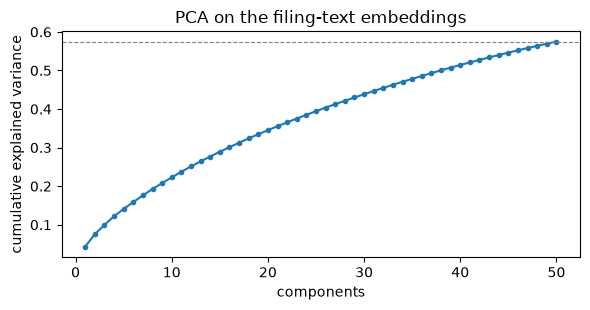


PCA fitted on all rows, then cross-validated (leaks): AUC 0.738
PCA refitted inside each fold (honest):               AUC 0.732
Difference: +0.006

Analysis table for Questions 2-4: 2482 rows x 113 columns (50 text components, 1403 flagged by Q1b)


In [21]:
# ---------------------------------------------------------------------------
# Q1c step 6: dimensionality reduction, and the difference between the two uses.
#
# Question 2 clusters the whole dataset and does not partition it, so the
# reduction is fitted once on everything - that is the intended behaviour for a
# descriptive analysis. Question 3 cross-validates, and a PCA fitted on all rows
# has already seen the held-out fold. The reduction is therefore refitted inside
# each fold there, which is what a Pipeline does. Both are shown below so the
# size of the difference is on the record rather than assumed.
# ---------------------------------------------------------------------------
pca_full = PCA(n_components=50, random_state=MEMBER_ID).fit(emb)
Z = pca_full.transform(emb)
ev = pca_full.explained_variance_ratio_
print("50 components retain %.1f%% of embedding variance" % (100 * ev.sum()))
display(pd.DataFrame({"components": [10, 20, 30, 50],
                      "cumulative_variance": [round(ev[:k].sum(), 3) for k in [10, 20, 30, 50]]}))

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(range(1, 51), np.cumsum(ev), marker=".")
ax.axhline(ev[:50].sum(), ls="--", lw=0.8, color="grey")
ax.set_xlabel("components"); ax.set_ylabel("cumulative explained variance")
ax.set_title("PCA on the filing-text embeddings"); plt.tight_layout(); plt.show()

# Leaked vs honest evaluation, on the same folds.
leaked = cross_val_score(LogisticRegression(max_iter=3000), Z[polar], y_polar,
                         cv=5, scoring="roc_auc").mean()
honest = cross_val_score(make_pipeline(PCA(n_components=50, random_state=MEMBER_ID),
                                       LogisticRegression(max_iter=3000)),
                         emb[polar], y_polar, cv=5, scoring="roc_auc").mean()
print("\nPCA fitted on all rows, then cross-validated (leaks): AUC %.3f" % leaked)
print("PCA refitted inside each fold (honest):               AUC %.3f" % honest)
print("Difference: %+.3f" % (leaked - honest))

# The artefacts Questions 2 and 3 will use.
TEXT_PCS = pd.DataFrame(Z, columns=["txt_pc%02d" % (i + 1) for i in range(Z.shape[1])],
                        index=enriched.index)
analysis = pd.concat([enriched.reset_index(drop=True),
                      TEXT_PCS.reset_index(drop=True)], axis=1)
# consensus_outcomes holds duplicate (filing, drug) keys, so the flags are collapsed
# to one row per key - taking the worst score - before joining, to avoid the merge
# silently expanding the analysis table.
flags_by_key = (flag.groupby(["accession", "drug_name"], as_index=False)
                    .agg(risk_score_q1b=("risk_score", "max"), flagged_q1b=("flagged", "max")))
analysis = analysis.merge(flags_by_key, on=["accession", "drug_name"], how="left")
analysis[["risk_score_q1b", "flagged_q1b"]] = analysis[["risk_score_q1b", "flagged_q1b"]].fillna(0)
analysis["result_sentences"] = sent_text
print("\nAnalysis table for Questions 2-4: %d rows x %d columns "
      "(%d text components, %d flagged by Q1b)"
      % (analysis.shape[0], analysis.shape[1], Z.shape[1], int(analysis.flagged_q1b.sum())))

#### Is the vectorisation fit for purpose? Testing rather than assuming

The diagnostic above asks whether the representation can recover, under cross-validation, a property of the filing that is known independently: whether the classified outcome was `positive` or `negative`. This is not the Question 3 model — the target there is signed CAR — it is a check that the features carry the information the downstream work will ask them for.

Three results come out of it, and the third changed what I used.

**Embedding fewer, better-chosen sentences beats embedding more text.** Mean-pooling the three most result-relevant sentences reaches **AUC 0.754**, against 0.691 for a single sentence and 0.732 for ten — a genuine interior optimum rather than a value chosen by feel. Sentence embeddings average away contrasts, so the more unrelated material is folded into one vector, the more the polarity of the result is diluted by the surrounding commercial narrative — which in a periodic report is most of the document. This is also why the drug-targeted sentence selection matters: in a multi-drug filing, embedding the filing as a whole gives every drug in it the same vector.

**Dimensionality reduction costs some signal, and the cost is worth knowing.** Reducing 384 dimensions to 50 takes AUC from 0.754 to **0.732** — about two points — while retaining about 58% of embedding variance. That trade is worth making for clustering, where 384 dimensions make Euclidean distance nearly meaningless and the reduction is doing real work; it is a genuine cost in Question 3, which is one reason the text features there are not limited to the reduced embedding.

**The embedding is a topic model, not a sentiment model — and that determined the final design.** TF-IDF on exactly the same three sentences reaches **AUC 0.889** against the embedding's 0.754 — thirteen points, on identical input text, so the comparison isolates the representation rather than the sentence selection. The reason is visible once stated: the signal separating a good result from a bad one is carried by a handful of literal phrases — "did not meet", "met its primary endpoint", "discontinued", "statistically significant" — and TF-IDF represents those directly, while a 384-dimension sentence embedding compresses them into a space it is also using for disease area, modality and study design. The embedding is genuinely good at what Question 2 needs (grouping trials by what they are about) and comparatively weak at what Question 3 needs (how the result went).

These figures are from the cleaning as it now stands. The same diagnostic on the same folds and the same 2,031-record subset, run before the `RE_TAIL` fix described in Q1a, gave 0.709 at k=3, 0.659 after reduction and 0.802 for TF-IDF. Recovering the exhibits improved every figure, and most of all the reduced embedding (0.659 to 0.728) — before the fix the first 50 components were largely describing boilerplate variance.

I therefore carry **both** representations forward rather than choosing between them: the reduced embedding as the text contribution to the clustering in Question 2 and as topical features in Question 3, and TF-IDF as a separate representation built inside the Question 3 cross-validation. That also satisfies Question 3a's requirement for at least two distinct text representations, and it is the conclusion the numbers forced rather than a convenient one — my first attempt used the embedding alone, on a longer digest, and scored worse than a bag of words.

#### Leakage, and how the two uses differ

**Feature-level leakage.** The columns excluded above are excluded because ClinicalTrials.gov and Drugs@FDA were scraped once, in 2026, so every status-like field holds today's value rather than the value as at the filing date. `overall_status` is the clearest case: trials recorded as TERMINATED average a −12.2% CAR against −2.1% for COMPLETED and +1.2% for ACTIVE_NOT_RECRUITING. A model given that column would look impressively predictive while doing nothing but reading the trial's obituary, written years after the filing. `fda_approved` is the same trap in milder form, and comes with a second one: it is stored as the strings `'True'`/`'False'`, so `pd.to_numeric` turns the whole column silently into NaN rather than failing. `ar_day0` and `car_3day_raw` are more obvious, being components of the target itself. `disclosure_lag_days` is not used as a feature at all: it is derived from `primary_completion`, which is revised after the fact, and it is negative for a quarter of the rows, meaning the linked study's recorded completion post-dates the filing. It is held back with the other eight leakage candidates and added to the model in Question 3b only to measure what it would have bought. `lag_quality`, which is built from the same field, is used in Question 2c as a linkage-quality diagnostic rather than a feature — Question 2 is descriptive and does not predict the target, so the objection that applies under cross-validation does not arise there.

One caveat I cannot engineer away and so record instead: the event window is [−1, +1], so it includes the trading day *before* the filing. Strictly, no feature derived from the filing text is observable at the start of the window. That is a property of the event study design supplied with the dataset rather than a choice available to me, and it biases every text feature in the same direction — towards looking slightly better than it is. It is one reason I would not present Question 3's performance as a floor.

**Pipeline-level leakage, and the Q2/Q3 difference.** This is where the two uses genuinely diverge. In Question 2 the clustering is descriptive and the brief is explicit that the data should not be partitioned, so fitting PCA once on all rows is the correct behaviour: there is no held-out set for it to contaminate, and a reduction refitted per-fold would not even be well defined. In Question 3 a PCA fitted on all rows has already seen the test fold, so the reduction is refitted inside each fold via a `Pipeline`. The cell above measures that difference on the same folds rather than asserting it. The gap turns out to be small, which is what one expects from an unsupervised reduction on 2,400 rows — but small-and-measured is a different claim from assumed-negligible, and the same discipline applied to a supervised step would not be optional.

The sentence encoder itself is pre-trained and never sees the target, so encoding all rows once is not leakage. The TF-IDF vectoriser *does* learn its vocabulary and document frequencies from the data, so in Question 3 it is fitted inside the fold; in Question 2b, where the brief asks for keywords that describe the clusters, fitting on everything is correct.

**What I satisfied myself of.** That the features carry outcome-relevant signal at all — they do, and I have measured how much rather than inspecting a few examples. That the signal survives the reduction well enough for clustering and imperfectly enough to matter for prediction, which is why both representations are kept. And that nothing carried forward is observable only after the return it would be used to predict.

I expect to return to this cell. The brief invites it, and the most likely revision is a tighter restriction of the Question 3 modelling set to the filings the Q1b flags identify as genuine announcements — the Q1a evidence says that would remove a systematic distortion, and Question 3b is the right place to test what it costs in sample size.

## Q1d: Summary for the IR team (500 words or less, 4 marks)

_Your answer (500 words or less — `word_count()` in the Setup cell will check):_

### Verdict

Partly. The labels are usable, but not as the dataset is set up, and two categories should not be used at all.

**What we checked.** We read 30 classifications against the original filings, covering all six outcome types, then compared every directional label to the price move that followed across 2,392 filings.

**The good news.** The labels are not guesswork. Filings labelled negative were followed by an average 19% fall and positive ones by a 4% rise — too large a gap to be chance. As a reading exercise the tool is largely accurate: in 23 of our 30 cases the label fairly described the filing.

**The main problem is timing, not accuracy.** Only 6 of our 30 filings broke the news. The rest were quarterly reports and investor decks repeating a result disclosed weeks or months earlier. The label describes the trial correctly, but the price move beside it reacts to something else, usually earnings. Immunic's August filing restating a June trial failure sits beside a **+42%** move.

This holds across the dataset: in genuine announcements the label agrees with the direction of the move 63% of the time, in quarterly reports 46% — worse than a coin toss. For negative results, 91% against 53%.

**Two categories are not fit for use.** "Mixed-positive" is treated as good news, but those filings were followed by an average **6.6% fall**. "Inconclusive" mostly does not mean an unclear result — three of our five cases reported no result at all.

**The dividing lines move with the wording.** In 11 of our 30 cases the same situation is classified differently elsewhere, always in one direction: the label is softer than the result. Two filings each report a missed primary endpoint and a well-tolerated drug; one is called negative, the other only "mixed". Where a company buries the miss and leads with what worked, the tool follows suit. The same bias shows where a filing carries both good and bad news: Neurogene's release describing "favourable safety and efficacy data" is labelled positive, when the news was a serious adverse event and a halted dose — the stock fell 68%. The labels inherit the sponsor's framing and err optimistic.

**A real finding, not a defect.** Setting timing aside, bad news moves the price reliably and good news often does not, because success is already partly expected. For ASC-101 and ASC-204, a positive readout is not a dependable catalyst.

**What we did about it.** We built a screen scoring all 4,539 classifications on the problems found. It flags **42%**, unevenly: 33% of negative labels, 56% of positive, 76–84% of mixed and inconclusive. Most flags are timing, not wrong labels — those reach 8%. The queue is ranked so the records that would most distort our modelling come first.

**Recommendation.** Restrict the analysis to genuine announcements. Treat "negative" as the most trustworthy label and "mixed-positive" as unfavourable. Read the top of the review queue before any number goes to the board.

### AI use — Question 1

> **TO COMPLETE BEFORE SUBMISSION.** Question 5 and the AI-use guidance require this to be *your own* truthful account. The notes below record what happened in the AI session so you have the facts to work from — rewrite them in your own words, and cut or correct anything that does not match your own involvement. Do not submit this paragraph as it stands.

Claude (Opus 5, via Claude Code) was used across Question 1: to write and debug the cleaning, sampling, flagging and vectorisation code, to extract result-relevant excerpts from the filings so they could be read, and to draft the commentary.

The 30-record reading in `READING` is my own judgement, formed from the original filing text. The extraction that put that text in front of me was Claude's, and on 13 of the 30 records (0, 4, 6, 8, 10–17, 20, 23) I worked through the filing with it and it raised things I had not seen: that the "met its primary endpoint" sentence in the REGN filing belongs to dupilumab rather than suptavumab; that the missed BESTFIT primary endpoint (p=0.172) is disclosed only in a footnote; that the EXEL filing's only missed endpoint belongs to a Genentech drug; and that READING[6] and READING[17] report the same two facts and receive different labels. I then reviewed every record and changed my own first answers on several: READING[20], [22] and [24] from fair to not fair once I accepted that a filing reporting no result cannot be `inconclusive`, READING[23] back to fair once I found the preliminary safety data I had missed, and READING[19] to not fair for consistency with READING[17].

Points in the session where the first output was wrong and was changed:

- The document-type classifier initially read the guidance sentence *"we expect to report top-line results in late fourth quarter 2021"* as a quarterly report, misfiling a genuine Theravance topline announcement. It was rebuilt to give the headline precedence over the body, and then validated against the 30 hand-read filings (28/30 on the announcement / not-announcement split).
- The disagreement cases were first selected by largest |CAR|, which returns ties because `car_3day` is winsorised at the 1st and 99th percentiles. Re-selected stratified by document type instead.
- The drug-presence check was first run against the *cleaned* filing text, which reports a drug as absent when all the cleaning did was remove the safe-harbour block that named it. Moved to the raw text.
- The first vectorisation embedded a long multi-sentence digest and scored below a bag-of-words baseline. That is what led to testing sentence counts, and to keeping TF-IDF as a second representation rather than choosing between them.
- The first flagging pipeline left `no_result` — 37% of the corpus — entirely unflagged. A missed-result signal was added so that part of the data has at least one way of being caught.

Full conversation logs are in `ai_logs/`. **TO DO: the Question 1 session is not yet saved there — export it, or record it with `write_manual_note()` if it cannot be exported.**

---

# Question 2: Identify comparable trials (20 marks)

The board wants to know how the market has reacted to trials like its own, so this question builds groupings of historical trials and then asks how much weight those groupings can carry. Two things are established rather than assumed:

- whether trials that *look* similar — on disease, design, stage and sponsor — actually *move the market* similarly; and
- whether each of the three Asclepius readouts has enough genuine comparables in this dataset for a grouping to say anything about it.

The work runs on the analysis table Q1c produced, and the answers to both questions turn out to be less comfortable than the exercise suggests.

## Q2a: Clustering (8 marks)

The brief says similarity might rest on disease area, trial design, stage or sponsor. That list is the design brief for the feature space, and it has one immediate consequence: **the grouping is only as good as the trial registration behind it**. Rows without a linked ClinicalTrials.gov study have no design fields at all, so before anything is clustered the first cell establishes which rows can support the analysis and what is lost by excluding the rest.

Four choices have to be justified — features, algorithm, distance measure, and number of clusters — and each is made against a stated alternative below. The criterion throughout is the use the groupings are put to: identifying comparables for ASC-101, ASC-204 and ASC-370, and supporting an outcome-conditional estimate of the market reaction in Question 4. A grouping that scores well internally but leaves a cluster too small to quote a distribution from is of no use for that.

In [22]:
# ---------------------------------------------------------------------------
# Q2a step 1: decide which rows can support a clustering on trial characteristics,
# and say what excluding the rest costs. Half the feature set the question asks
# for comes from the linked ClinicalTrials.gov study, so a row without that
# linkage has no trial design to cluster on - only an imputed guess at one.
#
# Therapeutic area is also built here, from the MeSH terms the registry attaches
# to each trial. It is a structured registry field, not a second vectorisation of
# text: each condition is mapped to one of eight broad areas by its MeSH ancestors.
# ---------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, silhouette_samples, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)
from scipy import stats

AREA_RULES = [
    ("Oncology",         r"Neoplas|Carcinom|Lymphom|Leukemi|Melanom|Myelom|Sarcom|Glioma|Tumor|Cancer"),
    ("Neuro/Psych",      r"Nervous System|Brain|Alzheimer|Parkinson|Epileps|Sclerosis|Migraine|Neuro"
                         r"|Mental Disorder|Depress|Schizophren|Anxiety|Stress Disorders|Dementia|Pain"),
    ("Cardio/Metabolic", r"Cardiovascular|Heart|Vascular|Hypertension|Diabet|Cholesterol|Lipid|Obesity"
                         r"|Metabolic|Kidney|Renal|Nutritional"),
    ("Immune/Inflam",    r"Immune System|Autoimmune|Arthritis|Rheumat|Psoria|Colitis|Crohn|Inflammat"
                         r"|Lupus|Asthma|Allerg"),
    ("Infectious",       r"Infect|Virus Diseases|Bacterial|HIV|Hepatitis|Influenza|COVID|Pneumon|Sepsis"),
    ("Rare/Genetic",     r"Genetic Diseases|Hereditary|Congenital|Metabolism, Inborn|Muscular Dystroph"
                         r"|Fibrosis, Cystic|Hemophilia|Angioedema|Amyloid"),
    ("Resp/Other",       r"Respiratory|Lung|Pulmonary|Skin Diseases|Digestive|Eye Diseases|Urogenital"
                         r"|Bone|Musculoskeletal|Hematologic|Endocrine"),
]

def mesh_area(mesh, ancestors):
    """Map a trial's MeSH conditions and their ancestors to one broad area."""
    blob = "%s %s" % (mesh or "", ancestors or "")
    if not blob.strip():
        return "unknown"
    for name, pat in AREA_RULES:
        if re.search(pat, blob, re.I):
            return name
    return "Other"

mesh = pd.read_sql("SELECT nct_id, mesh_conditions, condition_ancestors FROM studies", conn)
q2 = analysis.merge(mesh, on="nct_id", how="left")
q2["mesh_area"] = [mesh_area(m, c) for m, c in zip(q2.mesh_conditions, q2.condition_ancestors)]

# A linked nct_id is not sufficient: a few linked rows still carry no design fields.
DESIGN_COLS = ["allocation", "masking", "intervention_model", "primary_purpose"]
has_design = q2.nct_id.notna() & q2[DESIGN_COLS].notna().all(axis=1)

print("Analysis rows carried forward from Q1c:            %d" % len(q2))
print("  with a linked ClinicalTrials.gov registration:   %d" % q2.nct_id.notna().sum())
print("  and with trial design fields actually populated: %d  <- the clustering set" % has_design.sum())
print("\nThe %d rows dropped are not a random subset of the data:" % (~has_design).sum())
display(pd.DataFrame({
    "dropped": [(~has_design).sum(), q2.loc[~has_design, "car_3day"].mean(),
                (q2.loc[~has_design, "phase_bucket"] == "Phase 3").mean(),
                (q2.loc[~has_design, "outcome_group"] == "Negative").mean(),
                q2.loc[~has_design, "market_cap"].median() / 1e9],
    "kept":    [has_design.sum(), q2.loc[has_design, "car_3day"].mean(),
                (q2.loc[has_design, "phase_bucket"] == "Phase 3").mean(),
                (q2.loc[has_design, "outcome_group"] == "Negative").mean(),
                q2.loc[has_design, "market_cap"].median() / 1e9]},
    index=["rows", "mean CAR", "share Phase 3", "share Negative", "median market cap ($bn)"]).round(3))
print("\nTherapeutic areas in the clustering set:")
display(q2.loc[has_design, "mesh_area"].value_counts().to_frame("trial results"))

Analysis rows carried forward from Q1c:            2482
  with a linked ClinicalTrials.gov registration:   2100
  and with trial design fields actually populated: 2076  <- the clustering set

The 406 rows dropped are not a random subset of the data:


,dropped,kept
rows,406.000,2076.000
mean CAR,0.008,-0.022
share Phase 3,0.350,0.533
share Negative,0.148,0.183
median market cap ($bn),0.448,0.689



Therapeutic areas in the clustering set:


,trial results
mesh_area,
Neuro/Psych,540
Oncology,532
Cardio/Metabolic,308
Other,199
Resp/Other,156
Immune/Inflam,147
Infectious,131
Rare/Genetic,63


The cell below is the reason the eligibility rule above is not a formality. If the missing trial-design fields are simply imputed — the ordinary default — and everything is clustered together, the first split the algorithm finds is not a kind of trial at all: it is *whether the registry linkage worked*. At k = 2 the partition reproduces the missingness indicator almost exactly (ARI 0.98), and the imputed rows form a single tight cluster because imputation gives all of them identical values on every design field.

The silhouette for that solution (0.12) is roughly **twice** what the solution finally chosen below achieves. It is entirely an artefact. This is worth stating plainly because it is the trap this dataset sets: the best-separated grouping available is a grouping of the *data collection*, not of the trials.

In [23]:
# ---------------------------------------------------------------------------
# Q2a step 2: what happens if the eligibility rule above is skipped and the
# missing design fields are simply imputed, as they would be by default. The
# check is whether the resulting clusters correspond to kinds of trial, or to
# whether the registry linkage worked.
# ---------------------------------------------------------------------------
def naive_blocks(df):
    """The design matrix that median imputation would produce."""
    num = pd.DataFrame(index=df.index)
    num["enrol"]  = np.log1p(df.enrollment_num)
    num["sites"]  = np.log1p(df.n_locations_num)
    num["arms"]   = df.n_arm_groups_num
    num["mktcap"] = np.log10(df.market_cap.replace(0, np.nan))
    num = num.fillna(num.median())
    cat = pd.get_dummies(df[["phase_bucket"] + DESIGN_COLS].fillna("missing")).astype(float)
    Sx = np.hstack([StandardScaler().fit_transform(num.values),
                    StandardScaler().fit_transform(cat.values)])
    T = StandardScaler().fit_transform(df[["txt_pc%02d" % i for i in range(1, 21)]].values)
    return np.hstack([T / np.sqrt(T.shape[1]), Sx / np.sqrt(Sx.shape[1])])

Xn = naive_blocks(q2)
for k in [2, 3]:
    lab = KMeans(k, n_init=25, random_state=MEMBER_ID).fit_predict(Xn)
    print("k=%d on all %d rows: silhouette %.3f, ARI against 'trial design is missing' = %.3f"
          % (k, len(q2), silhouette_score(Xn, lab), adjusted_rand_score(lab, (~has_design).astype(int))))
print("\nCross-tab at k=2:")
display(pd.crosstab(KMeans(2, n_init=25, random_state=MEMBER_ID).fit_predict(Xn), ~has_design,
                    rownames=["cluster"], colnames=["design fields missing"]))


k=2 on all 2482 rows: silhouette 0.121, ARI against 'trial design is missing' = 0.978
k=3 on all 2482 rows: silhouette 0.137, ARI against 'trial design is missing' = 0.511

Cross-tab at k=2:


design fields missing,False,True
cluster,,
0,2076,11
1,0,395


### One filing, several trials

An 8-K is filed once; the trials it reports are not one per filing. Across the eligible rows a substantial minority of filings carry more than one, and every row from one filing shares the same filing text — so the text half of the feature space is identical across them. In Q2b, where the discriminator is fitted on that text alone, rows from one filing are *identical feature vectors that can carry different cluster labels*.

The obvious remedy — keep one row per filing — is the wrong one here, and the cell below says why in numbers. Most of the affected filings report genuinely different registered trials, with different `nct_id`s and different design fields. Collapsing them would delete real trials from a question whose unit of analysis is the trial, and would silently pick an outcome label in the filings whose rows disagree on one. The remainder are the same registered trial listed twice under different spellings of the drug name.

So the grain is separated into the two problems it actually contains, and each is handled where it does damage:

- **Rows identical in every clustering feature** — same filing *and* same `nct_id`, therefore the same text and the same registered design — are genuine redundancy and are collapsed. Where such rows disagree on the outcome label, the most-adverse rule set out in Q1c decides, so one rule governs both places rather than two ad-hoc ones.
- **Rows that share a filing but register different trials** are kept. Their dependence is handled by weighting rather than deletion: each row carries weight 1/(trials in its filing), so Q2b counts every filing once however many trials it reports, and the resampling in Q2a and Q2c draws *filings* rather than rows.

What that leaves is stated rather than glossed: the clustering set still contains filings contributing several trials, and the reason it is safe to keep them is that they are different trials, not that the dependence has gone away.

In [24]:
# ---------------------------------------------------------------------------
# Q2a step 2b: the unit of analysis. Separate genuine redundancy from genuinely
# multi-trial filings, collapse only the first, and carry a weight for the rest.
#
# Rows sharing (accession, nct_id) are identical in every feature the clustering
# uses - the same filing text and the same registered trial design - so removing
# them cannot change the solution except through weighting. Rows sharing only
# the accession are different trials and are kept.
# ---------------------------------------------------------------------------
elig = q2[has_design].reset_index(drop=True)
_n   = elig.groupby("accession").size()
_aff = _n[_n > 1]
_g   = elig[elig.accession.isin(_aff.index)].groupby("accession")
print("Eligible rows %d across %d filings. %d filings carry more than one row "
      "(%d rows in all, largest %d)."
      % (len(elig), elig.accession.nunique(), len(_aff),
         int(_aff.sum()), int(_aff.max())))
print("\nWhat those %d filings actually are:" % len(_aff))
display(pd.DataFrame({"filings": {
    "report more than one registered trial (different nct_id)": int((_g.nct_id.nunique() > 1).sum()),
    "repeat one registered trial (same nct_id)":                int((_g.nct_id.nunique() == 1).sum()),
    "whose rows disagree on the outcome label":                 int((_g.outcome.nunique() > 1).sum()),
    "whose rows differ on at least one design field":
        int((_g[DESIGN_COLS + ["phases", "enrollment", "n_locations"]].nunique().max(axis=1) > 1).sum()),
}}))

# Collapse only the feature-identical rows, under the Q1c rule.
_before = len(elig)
cl = (elig.assign(_sev=elig.outcome.map(SEVERITY).fillna(5))
          .sort_values(["accession", "nct_id", "_sev", "drug_name"])
          .drop_duplicates(subset=["accession", "nct_id"], keep="first")
          .drop(columns="_sev")
          .sort_index()
          .reset_index(drop=True))
print("Collapsed %d feature-identical rows -> %d trials to cluster, across %d filings."
      % (_before - len(cl), len(cl), cl.accession.nunique()))

# What is left is real multi-trial reporting. The weight each row carries from here.
cl["trials_in_filing"] = cl.groupby("accession").drug_name.transform("size")
cl["filing_weight"]    = 1.0 / cl.trials_in_filing
_still = cl[cl.trials_in_filing > 1]
print("\nFilings still reporting more than one trial: %d, covering %d rows, largest %d.\n"
      "Keeping one row per filing instead would discard a further %d trials, %.1f%% of the\n"
      "clustering set - and would pick the outcome label for the %d filings whose rows\n"
      "disagree on one."
      % (_still.accession.nunique(), len(_still), int(cl.trials_in_filing.max()),
         len(cl) - cl.accession.nunique(),
         100 * (len(cl) - cl.accession.nunique()) / len(cl),
         int((_still.groupby("accession").outcome.nunique() > 1).sum())))

# Multi-trial reporting is not spread evenly over the corpus, which is the reason
# it cannot be dismissed as noise: it is what pipeline round-ups look like, and
# Q1a's document classifier can say so independently of anything in Question 2.
print("\nShare of trials sitting in a multi-trial filing, by document type:")
display(pd.crosstab(cl.accession.map(filing_txt.set_index("accession").filing_kind),
                    np.where(cl.trials_in_filing > 1, "multi-trial filing", "single-trial filing"),
                    normalize="index").round(3))

# Resampling helper used by Q2a step 5 and Q2c check 5: draw filings, not rows,
# so every trial in a drawn 8-K comes with it and the dependence is preserved.
_acc_rows = cl.groupby("accession").indices
_acc_keys = np.array(list(_acc_rows))

def resample_filings(rng):
    """A bootstrap resample of row positions, drawn at the filing level."""
    picked = rng.choice(len(_acc_keys), len(_acc_keys), replace=True)
    return np.concatenate([_acc_rows[_acc_keys[i]] for i in picked])


Eligible rows 2076 across 1669 filings. 288 filings carry more than one row (695 rows in all, largest 9).

What those 288 filings actually are:


,filings
report more than one registered trial (different nct_id),217
repeat one registered trial (same nct_id),71
whose rows disagree on the outcome label,121
whose rows differ on at least one design field,216


Collapsed 101 feature-identical rows -> 1975 trials to cluster, across 1669 filings.

Filings still reporting more than one trial: 217, covering 523 rows, largest 7.
Keeping one row per filing instead would discard a further 306 trials, 15.5% of the
clustering set - and would pick the outcome label for the 104 filings whose rows
disagree on one.

Share of trials sitting in a multi-trial filing, by document type:


col_0,multi-trial filing,single-trial filing
accession,,
deck / FD update,0.126,0.874
other,0.241,0.759
periodic report,0.437,0.563
results announcement,0.056,0.944


### The feature space

**Text.** The 20 leading principal components of the Q1c filing-text embedding. Q1c established that this representation is a topic model rather than a sentiment model — it was comparatively weak at recovering whether a result was good or bad, and that is exactly the property wanted here: the grouping should say what a trial *is*, not how it *went*. Twenty components rather than the full 50 because in 50 dimensions Euclidean distance between 1,975 points is close to meaningless, and components beyond the twentieth each carry under 1% of embedding variance.

**Structured.** Trial design (phase, masking, allocation, intervention model, primary purpose, arms, interventions, endpoint counts), scale (enrolment, sites), sponsor (market capitalisation, biologic/genetic/device modality, presence of a data monitoring committee), and **therapeutic area**. Area is derived from the MeSH terms the registry attaches to each trial, collapsed to eight groups by their MeSH ancestors. It is included as a structured registry field, not as a second text vectorisation: comparability for this board is disease-led before it is anything else, and a grouping that cannot tell a haemophilia trial from a lung-cancer trial cannot answer the question asked. Rare category levels are collapsed and numeric tails winsorised at the 1st and 99th percentiles, because without that k-means spends clusters on single trials with 84,000 patients or eight on a `DEVICE_FEASIBILITY` purpose.

**Weighting.** Each block is standardised and then scaled so the two contribute equal variance. The alternative — leaving the raw dimensionality to decide — would hand the decision to whichever block happened to have more columns. The table below checks that the result is not simply one block in disguise, by comparing the combined partition against the partitions each block produces alone. The relationship is not monotonic at the low end, and that is worth reporting rather than smoothing: at `w_text` 0.3 the solution is very nearly a relabelling of the structured-only partition (ARI **0.83**), but at 0.2 and 0.4 it sits at 0.36 and 0.35 — no closer to the structured solution than 0.5 is. That spike is a reminder that k-means on a weakly-separated matrix can land on very different partitions from small changes in scaling, which is the fragility Q2c check 5 quantifies. From 0.6 upwards it moves steadily towards the text-only solution and away from the structured one, reaching ARI 0.44 against text and 0.18 against structured at `w_text` 0.8. At 0.5 it is a genuine mixture rather than either parent: ARI 0.15 against the text-only partition and 0.36 against the structured one, so it retains a recognisable share of the structured grouping while being far from a relabelling of it. That is the balance the rest of the question is built on, and the fact that it is not equidistant from the two is worth stating rather than rounding away.

In [25]:
# ---------------------------------------------------------------------------
# Q2a step 3: the feature space. Two blocks - the Q1c filing-text components and
# the structured trial characteristics - scaled so each contributes equal
# variance, then checked to confirm the combination is not just one of them.
#
# The transformations are wrapped in a small class rather than applied inline so
# that the three Asclepius readouts can be placed in exactly the same space in
# Q2c, using scalers fitted on the historical trials alone.
# ---------------------------------------------------------------------------
MASKING = {"NONE": "open label", "SINGLE": "single/double", "DOUBLE": "single/double",
           "TRIPLE": "triple/quadruple", "QUADRUPLE": "triple/quadruple"}
MODEL   = {"PARALLEL": "parallel", "SINGLE_GROUP": "single group", "CROSSOVER": "crossover"}
PURPOSE = {"TREATMENT": "treatment", "PREVENTION": "prevention"}
N_TEXT  = 20

def design_frames(df):
    """The structured features, numeric and categorical, before any scaling."""
    num = pd.DataFrame(index=df.index)
    w = lambda s: s.clip(s.quantile(0.01), s.quantile(0.99))   # clip tails, keep types
    num["log_enrollment"]  = np.log1p(w(df.enrollment_num))
    num["log_sites"]       = np.log1p(w(df.n_locations_num))
    num["n_arms"]          = w(df.n_arm_groups_num)
    num["n_interventions"] = w(df.n_interventions_num)
    num["n_primary"]       = w(df.n_primary_outcomes_num)
    num["n_secondary"]     = w(df.n_secondary_outcomes_num)
    num["log_market_cap"]  = np.log10(df.market_cap.replace(0, np.nan))

    # Rare one-hot levels cost whole clusters under k-means, so they are collapsed
    # to the distinctions that actually say something about the trial.
    c = pd.DataFrame(index=df.index)
    c["phase"]      = df.phase_bucket.where(df.phase_bucket.isin(["Phase 1", "Phase 2", "Phase 3"]),
                                            "Phase 4/other")
    c["masking"]    = df.masking.map(MASKING).fillna("open label")
    c["allocation"] = np.where(df.allocation == "RANDOMIZED", "randomised", "non-randomised")
    c["model"]      = df.intervention_model.map(MODEL).fillna("other")
    c["purpose"]    = df.primary_purpose.map(PURPOSE).fillna("other")
    c["area"]       = df.mesh_area
    cat = pd.get_dummies(c, prefix=c.columns.tolist()).astype(float)
    for t in ["BIOLOGICAL", "GENETIC", "DEVICE"]:
        cat["itype_" + t] = df.intervention_types.fillna("").str.contains(t).astype(float)
    cat["has_dmc"] = df.has_dmc.map({"True": 1.0, "False": 0.0}).fillna(0.5)
    return num, cat

class Design:
    """Fits the scalers and dummy layout on one frame so other frames can be
    placed in the same space. drop_area supports the fairness check in step 6."""

    def __init__(self, df, n_text=N_TEXT, drop_area=False):
        self.n_text, self.drop_area = n_text, drop_area
        num, cat = self._frames(df)
        self.num_med  = num.median()
        self.num_sc   = StandardScaler().fit(num.fillna(self.num_med).values)
        self.cat_cols = list(cat.columns)
        self.cat_sc   = StandardScaler().fit(cat.values)
        self.txt_sc   = StandardScaler().fit(df[["txt_pc%02d" % i for i in range(1, n_text + 1)]].values)
        self.struct_names = list(num.columns) + self.cat_cols

    def _frames(self, df):
        num, cat = design_frames(df)
        if self.drop_area:
            cat = cat[[c for c in cat.columns if not c.startswith("area_")]]
        return num, cat

    def blocks(self, df):
        num, cat = self._frames(df)
        cat = cat.reindex(columns=self.cat_cols, fill_value=0.0)
        T = self.txt_sc.transform(df[["txt_pc%02d" % i for i in range(1, self.n_text + 1)]].values)
        Sx = np.hstack([self.num_sc.transform(num.fillna(self.num_med).values),
                        self.cat_sc.transform(cat.values)])
        return T, Sx

    def matrix(self, df, w_text=0.5):
        """Scale each block so it contributes w_text : 1 - w_text of total variance."""
        T, Sx = self.blocks(df)
        return np.hstack([T / np.sqrt(T.shape[1]) * np.sqrt(w_text),
                          Sx / np.sqrt(Sx.shape[1]) * np.sqrt(1 - w_text)])

dsg = Design(cl)
print("Text block:       %d principal components of the Q1c filing-text embedding" % N_TEXT)
print("Structured block: %d features -" % len(dsg.struct_names))
print(textwrap.fill(", ".join(dsg.struct_names), 100, initial_indent="   ", subsequent_indent="   "))

# Neither block should simply win. Measured against the single-block solutions.
lab_t = KMeans(8, n_init=25, random_state=MEMBER_ID).fit_predict(dsg.matrix(cl, 1.0))
lab_s = KMeans(8, n_init=25, random_state=MEMBER_ID).fit_predict(dsg.matrix(cl, 0.0))
rows = []
for w in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    Xw = dsg.matrix(cl, w)
    lb = KMeans(8, n_init=25, random_state=MEMBER_ID).fit_predict(Xw)
    rows.append({"w_text": w, "silhouette": silhouette_score(Xw, lb),
                 "ARI vs text-only": adjusted_rand_score(lb, lab_t),
                 "ARI vs structured-only": adjusted_rand_score(lb, lab_s),
                 "smallest cluster": np.bincount(lb).min()})
print("\nIs the combined solution just one block in disguise? (k=8)")
display(pd.DataFrame(rows).round(3))

W_TEXT = 0.5
X = dsg.matrix(cl, W_TEXT)
rng = np.random.default_rng(MEMBER_ID)
print("\nChosen: w_text = %.2f, design matrix %s" % (W_TEXT, X.shape))

Text block:       20 principal components of the Q1c filing-text embedding
Structured block: 35 features -
   log_enrollment, log_sites, n_arms, n_interventions, n_primary, n_secondary, log_market_cap,
   phase_Phase 1, phase_Phase 2, phase_Phase 3, phase_Phase 4/other, masking_open label,
   masking_single/double, masking_triple/quadruple, allocation_non-randomised,
   allocation_randomised, model_crossover, model_other, model_parallel, model_single group,
   purpose_other, purpose_prevention, purpose_treatment, area_Cardio/Metabolic, area_Immune/Inflam,
   area_Infectious, area_Neuro/Psych, area_Oncology, area_Other, area_Rare/Genetic, area_Resp/Other,
   itype_BIOLOGICAL, itype_GENETIC, itype_DEVICE, has_dmc

Is the combined solution just one block in disguise? (k=8)


,w_text,silhouette,ARI vs text-only,ARI vs structured-only,smallest cluster
0,0.2,0.113,0.027,0.364,31
1,0.3,0.072,0.069,0.833,31
2,0.4,0.073,0.128,0.354,45
3,0.5,0.066,0.148,0.359,67
4,0.6,0.054,0.229,0.249,81
5,0.7,0.055,0.238,0.269,83
6,0.8,0.055,0.441,0.176,90



Chosen: w_text = 0.50, design matrix (1975, 55)


### Algorithm, distance measure and number of clusters

Six combinations of algorithm and distance are compared on the same matrix. **k-means with Euclidean distance is chosen**, and the reason is visible in the last two columns rather than the first: it is the only candidate that both scores at the top on the internal measures and produces a size distribution that can be used. Ward and complete-linkage do worse on every measure. The Gaussian mixture comes closest to k-means on silhouette (0.058 against 0.066) but concentrates more in its largest component — 27% of trials against 21%, and its soft assignment buys nothing here because the groupings are used as hard buckets in Question 4.

Average linkage with **Manhattan distance is the instructive failure**: it posts by far the best silhouette (0.139) and the best Davies-Bouldin (1.50) while putting **95% of all trials in one cluster** (1,874 of 1,975) and one trial in another. It is a degenerate solution that the internal measures reward. That single line is the strongest evidence in this question for how little weight the silhouette can bear on its own — it is used below as one input among several, never as the arbiter.

Euclidean distance over cosine: after standardisation the features are centred and comparable in scale, and magnitude carries real meaning here (a 2,500-patient trial is genuinely far from a 45-patient trial). Cosine would discard exactly that. It is tested anyway, above, and is worse.

**Number of clusters.** Internal validation cannot choose k here, and the sweep below shows why: silhouette moves only between 0.048 and 0.086 from k = 4 to k = 14, with no elbow, and bootstrap stability is non-monotonic. What does discriminate between values of k is the use. Each cluster has to hold enough historical events to state a distribution of reactions conditional on the outcome, which needs something like 100 trials in the cluster and 30 or more negative readouts among them — negatives being only 18% of the clustering set and the tail the CFO most needs. Below k = 7 there are too few groups to separate the therapeutic areas that matter; from k = 9 the smallest cluster drops to 31 trials without the validation measures earning it — silhouette keeps drifting up to 0.086 at k = 12 while Calinski-Harabasz falls monotonically, which is fragmentation being rewarded rather than structure being found. **k = 8** sits inside that window, and gives seven clusters of 100 or more and four with 30 or more negative readouts.

In [26]:
# ---------------------------------------------------------------------------
# Q2a step 4: algorithm and distance measure, compared on the same matrix.
# The last two columns matter as much as the first: a solution that scores well
# on the internal measures but puts almost everything in one cluster cannot be
# used to pick comparables.
# ---------------------------------------------------------------------------
cands = {
    "k-means, Euclidean":         KMeans(8, n_init=50, random_state=MEMBER_ID).fit_predict(X),
    "Ward linkage, Euclidean":    AgglomerativeClustering(8, linkage="ward").fit_predict(X),
    "average linkage, cosine":    AgglomerativeClustering(8, metric="cosine",
                                                          linkage="average").fit_predict(X),
    "complete linkage, cosine":   AgglomerativeClustering(8, metric="cosine",
                                                          linkage="complete").fit_predict(X),
    "average linkage, Manhattan": AgglomerativeClustering(8, metric="manhattan",
                                                          linkage="average").fit_predict(X),
    "Gaussian mixture, full":     GaussianMixture(8, covariance_type="full", n_init=3,
                                                  random_state=MEMBER_ID).fit_predict(X),
}
rows = []
for nm, lb in cands.items():
    sz = np.bincount(lb, minlength=8)
    rows.append({"algorithm / distance": nm, "silhouette": silhouette_score(X, lb),
                 "Calinski-Harabasz": calinski_harabasz_score(X, lb),
                 "Davies-Bouldin": davies_bouldin_score(X, lb),
                 "smallest": sz.min(), "largest": sz.max(),
                 "share in largest": sz.max() / len(lb)})
display(pd.DataFrame(rows).set_index("algorithm / distance").round(3))

,silhouette,Calinski-Harabasz,Davies-Bouldin,smallest,largest,share in largest
algorithm / distance,,,,,,
"k-means, Euclidean",0.066,70.409,3.189,67,411,0.208
"Ward linkage, Euclidean",0.051,59.015,3.244,30,523,0.265
"average linkage, cosine",0.037,57.391,3.159,27,643,0.326
"complete linkage, cosine",-0.004,40.063,4.543,61,458,0.232
"average linkage, Manhattan",0.139,17.257,1.498,1,1874,0.949
"Gaussian mixture, full",0.058,62.906,3.248,45,534,0.270


,silhouette,Calinski-Harabasz,Davies-Bouldin,smallest,clusters >=100 trials,clusters >=30 negatives,bootstrap ARI
k,,,,,,,
3,0.053,112.833,4.009,415,3,2,0.767
4,0.053,99.509,3.511,98,3,2,0.598
5,0.048,87.667,3.563,98,4,3,0.607
6,0.049,80.377,3.424,67,5,4,0.659
7,0.059,75.115,3.361,98,6,4,0.677
8,0.066,70.409,3.189,67,7,4,0.682
9,0.072,68.826,2.971,31,7,4,0.667
10,0.075,66.492,3.011,31,8,4,0.699
11,0.078,63.436,2.904,31,8,4,0.670


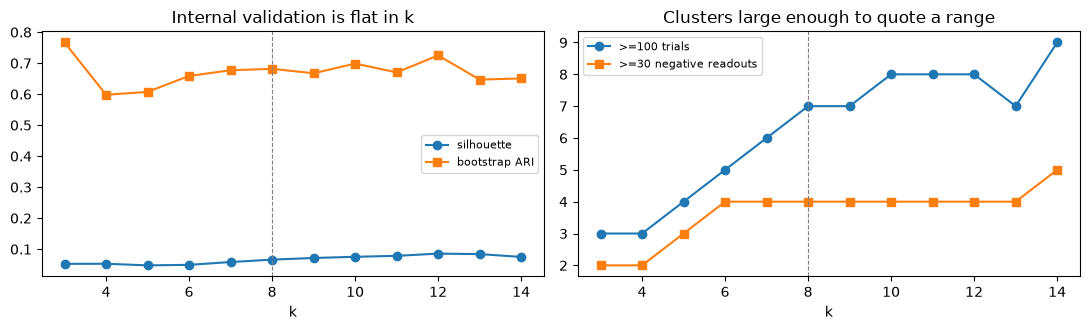

In [27]:
# ---------------------------------------------------------------------------
# Q2a step 5: the number of clusters. Internal validation is reported alongside
# two things it cannot see - how reproducible each solution is under resampling,
# and whether the clusters are large enough to state a distribution of market
# reactions from, which is what Question 4 needs them for.
# ---------------------------------------------------------------------------
rows = []
for k in range(3, 15):
    lb = KMeans(k, n_init=50, random_state=MEMBER_ID).fit_predict(X)
    sz = np.bincount(lb)
    neg = cl.assign(c=lb).query("outcome_group == 'Negative'").groupby("c").size() \
            .reindex(range(k)).fillna(0)
    # Resampled over filings rather than rows: trials reported in one 8-K share a
    # document and a market reaction, so drawing rows would treat a seven-trial
    # filing as seven independent observations and overstate reproducibility.
    aris = []
    for b in range(10):
        idx = resample_filings(rng)
        aris.append(adjusted_rand_score(
            lb, KMeans(k, n_init=5, random_state=MEMBER_ID + b).fit(X[idx]).predict(X)))
    rows.append({"k": k, "silhouette": silhouette_score(X, lb),
                 "Calinski-Harabasz": calinski_harabasz_score(X, lb),
                 "Davies-Bouldin": davies_bouldin_score(X, lb), "smallest": sz.min(),
                 "clusters >=100 trials": int((sz >= 100).sum()),
                 "clusters >=30 negatives": int((neg >= 30).sum()),
                 "bootstrap ARI": np.mean(aris)})
sel = pd.DataFrame(rows).set_index("k")
display(sel.round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(sel.index, sel.silhouette, marker="o", label="silhouette")
ax[0].plot(sel.index, sel["bootstrap ARI"], marker="s", label="bootstrap ARI")
ax[0].axvline(8, ls="--", lw=0.8, color="grey")
ax[0].set_xlabel("k"); ax[0].legend(fontsize=8)
ax[0].set_title("Internal validation is flat in k")
ax[1].plot(sel.index, sel["clusters >=100 trials"], marker="o", label=">=100 trials")
ax[1].plot(sel.index, sel["clusters >=30 negatives"], marker="s", label=">=30 negative readouts")
ax[1].axvline(8, ls="--", lw=0.8, color="grey")
ax[1].set_xlabel("k"); ax[1].legend(fontsize=8)
ax[1].set_title("Clusters large enough to quote a range")
plt.tight_layout(); plt.show()

### What the internal validation measure can and cannot support

A silhouette of 0.06 needs interpreting, not just reporting. The cell below places it against three references.

In [28]:
# ---------------------------------------------------------------------------
# Q2a step 6: what a silhouette of ~0.06 can and cannot support. Three
# references: labels shuffled between rows; k-means run on column-permuted
# features, which preserves every marginal but destroys all joint structure;
# and groupings that were already available in the data without clustering.
# ---------------------------------------------------------------------------
K = 8
km = KMeans(K, n_init=50, random_state=MEMBER_ID).fit(X)
cl["cluster"] = km.labels_

print("k-means on the real features, k=%d               silhouette %+.3f"
      % (K, silhouette_score(X, km.labels_)))
print("the same labels, shuffled between rows           silhouette %+.3f"
      % silhouette_score(X, rng.permutation(km.labels_)))
nulls = []
for i in range(5):
    Xp = np.column_stack([rng.permutation(X[:, j]) for j in range(X.shape[1])])
    nulls.append(silhouette_score(Xp, KMeans(K, n_init=10, random_state=MEMBER_ID + i).fit_predict(Xp)))
print("k-means on column-permuted features              silhouette %+.3f  (sd %.3f over 5 draws)"
      % (np.mean(nulls), np.std(nulls)))

print("\nGroupings already available without clustering, scored in the same space:")
for nm, g in [("therapeutic area (8 groups)", cl.mesh_area),
              ("phase (4 groups)", cl.phase_bucket),
              ("area x phase (%d groups)" % (cl.mesh_area + cl.phase_bucket).nunique(),
               cl.mesh_area + "|" + cl.phase_bucket),
              ("LLM outcome group (3 groups)", cl.outcome_group.fillna("none"))]:
    print("   %-34s silhouette %+.3f" % (nm, silhouette_score(X, g)))

# Area is one of the features above, which flatters the area lookup. Repeat the
# comparison with area held out, so the lookup is genuinely external.
dsg_na = Design(cl, drop_area=True)
X_na = dsg_na.matrix(cl, W_TEXT)
lab_na = KMeans(K, n_init=50, random_state=MEMBER_ID).fit_predict(X_na)
print("\nSame comparison with therapeutic area removed from the feature space:")
print("   k-means (k=8)                      silhouette %+.3f" % silhouette_score(X_na, lab_na))
print("   therapeutic-area lookup            silhouette %+.3f" % silhouette_score(X_na, cl.mesh_area))
print("   phase lookup                       silhouette %+.3f" % silhouette_score(X_na, cl.phase_bucket))
print("   ARI(k-means labels, area)          %.3f" % adjusted_rand_score(lab_na, cl.mesh_area))

print("\nPer-cluster mean silhouette:")
display(pd.Series(silhouette_samples(X, km.labels_)).groupby(km.labels_).mean()
          .round(3).to_frame("silhouette"))

k-means on the real features, k=8               silhouette +0.066
the same labels, shuffled between rows           silhouette -0.024
k-means on column-permuted features              silhouette +0.020  (sd 0.001 over 5 draws)

Groupings already available without clustering, scored in the same space:
   therapeutic area (8 groups)        silhouette +0.075
   phase (4 groups)                   silhouette +0.048
   area x phase (37 groups)           silhouette +0.046
   LLM outcome group (3 groups)       silhouette -0.042

Same comparison with therapeutic area removed from the feature space:
   k-means (k=8)                      silhouette +0.064
   therapeutic-area lookup            silhouette -0.009
   phase lookup                       silhouette +0.062
   ARI(k-means labels, area)          0.055

Per-cluster mean silhouette:


,silhouette
0,0.150
1,-0.021
2,0.045
3,0.098
4,0.092
5,0.056
6,0.071
7,0.107


The comparison establishes three things.

**The structure is real but very weak.** At 0.066 the clustering beats shuffled labels (−0.024) and,
more informatively, beats k-means run on column-permuted features (0.020, sd 0.001 over five draws) —
data with every marginal distribution preserved and all joint structure destroyed. That permuted
figure is the honest null: k-means always returns a partition, and roughly 0.02 of the silhouette is
what partitioning noise buys. So about two thirds of the measured value reflects genuine structure.
It is still a small number in absolute terms.

**Silhouette cannot rank these solutions.** A plain therapeutic-area lookup — no clustering at all —
scores 0.075, *higher* than the eight-cluster solution. That is partly circular, since area is one of
the features, so the cell repeats the comparison with area held out: the clustering then scores 0.064
against −0.009 for the area lookup, but a four-group lookup on **phase alone scores 0.062**, within
0.002 of the clustering, and the ARI between the area-free k-means labels and therapeutic area is
only 0.055. Either way the conclusion is the same: on this measure the clustering does not
meaningfully beat groupings that were already available for free. What the clustering adds is not
separation, it is *combination* — it splits within a therapeutic area on design, stage and sponsor
size, which a single-field lookup cannot do. That has to be justified by inspection and by use, which
is what Q2b and Q2c do, and not by the silhouette.

**The clusters are not equally solid.** Per-cluster silhouettes range from 0.150 for cluster 0 down
to **−0.021 for cluster 1**, whose members are on average closer to a neighbouring cluster than to
their own. Cluster 1 holds 272 trials and has no dominant therapeutic area. It should be read as a
residual — the trials that did not belong anywhere in particular — and that is how it is treated
below. Note that the ordering is the opposite of what size would suggest: the smallest cluster (0, at
67 trials) is the best separated and the residual is among the larger ones.

,trials,share,phase_3,phase_1,med_enrol,med_sites,blinded,randomised,med_mktcap_bn,companies,dominant area
cluster,,,,,,,,,,,
0,67,0.034,0.597,0.030,802.0,33.0,0.657,0.955,0.378,26,Infectious (57%)
1,272,0.138,0.471,0.077,181.5,36.5,0.647,0.993,0.348,103,Other (43%)
2,388,0.196,0.265,0.168,55.5,12.0,0.000,0.026,0.429,135,Oncology (49%)
3,136,0.069,0.551,0.029,269.5,52.5,0.750,0.993,1.498,48,Immune/Inflam (99%)
4,291,0.147,0.773,0.034,495.0,115.0,0.371,0.962,2.363,61,Oncology (92%)
5,274,0.139,0.602,0.026,195.5,41.0,0.639,0.996,1.141,79,Cardio/Metabolic (90%)
6,136,0.069,0.551,0.066,200.0,27.5,0.647,0.985,0.212,49,Resp/Other (100%)
7,411,0.208,0.582,0.029,224.0,30.0,0.781,0.995,0.733,85,Neuro/Psych (97%)


Therapeutic area composition, row percentages:


mesh_area,Cardio/Metabolic,Immune/Inflam,Infectious,Neuro/Psych,Oncology,Other,Rare/Genetic,Resp/Other
cluster,,,,,,,,
0,15.0,0.0,57.0,13.0,3.0,12.0,0.0,0.0
1,1.0,0.0,29.0,3.0,7.0,43.0,17.0,0.0
2,9.0,2.0,2.0,22.0,49.0,9.0,4.0,3.0
3,1.0,99.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,92.0,6.0,0.0,0.0
5,90.0,0.0,0.0,6.0,1.0,3.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
7,0.0,0.0,0.0,97.0,2.0,1.0,0.0,0.0



Size distribution: smallest 67 (3.4%), largest 411 (20.8%); 7 of 8 clusters hold >=100 trial results, 4 hold >=30 negative readouts.


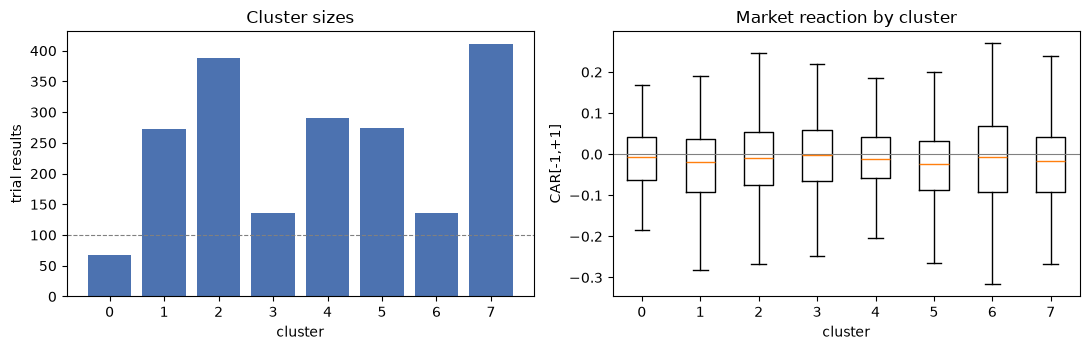

In [29]:
# ---------------------------------------------------------------------------
# Q2a step 7: the chosen solution, its composition, and its size distribution.
# ---------------------------------------------------------------------------
prof = cl.groupby("cluster").agg(
    trials=("car_3day", "size"),
    share=("car_3day", lambda v: len(v) / len(cl)),
    phase_3=("phase_bucket", lambda v: (v == "Phase 3").mean()),
    phase_1=("phase_bucket", lambda v: (v == "Phase 1").mean()),
    med_enrol=("enrollment_num", "median"),
    med_sites=("n_locations_num", "median"),
    blinded=("masking", lambda v: v.isin(["TRIPLE", "QUADRUPLE"]).mean()),
    randomised=("allocation", lambda v: (v == "RANDOMIZED").mean()),
    med_mktcap_bn=("market_cap", lambda v: v.median() / 1e9),
    companies=("ticker", "nunique"))
prof["dominant area"] = cl.groupby("cluster").mesh_area.agg(
    lambda v: "%s (%.0f%%)" % (v.value_counts().index[0], 100 * v.value_counts(normalize=True).iloc[0]))
display(prof.round(3))
print("Therapeutic area composition, row percentages:")
display((100 * pd.crosstab(cl.cluster, cl.mesh_area, normalize="index")).round(0))

sizes = cl.cluster.value_counts().sort_index()
print("\nSize distribution: smallest %d (%.1f%%), largest %d (%.1f%%); %d of %d clusters hold "
      ">=100 trial results, %d hold >=30 negative readouts."
      % (sizes.min(), 100 * sizes.min() / len(cl), sizes.max(), 100 * sizes.max() / len(cl),
         (sizes >= 100).sum(), K,
         (cl[cl.outcome_group == "Negative"].groupby("cluster").size() >= 30).sum()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(sizes.index, sizes.values, color="#4c72b0")
ax[0].axhline(100, ls="--", lw=0.8, color="grey")
ax[0].set_xlabel("cluster"); ax[0].set_ylabel("trial results"); ax[0].set_title("Cluster sizes")
ax[1].boxplot([cl.loc[cl.cluster == c, "car_3day"] for c in range(K)],
              tick_labels=[str(c) for c in range(K)], showfliers=False)
ax[1].axhline(0, color="grey", lw=0.8)
ax[1].set_xlabel("cluster"); ax[1].set_ylabel("CAR[-1,+1]")
ax[1].set_title("Market reaction by cluster")
plt.tight_layout(); plt.show()

#### The eight groupings, and what their sizes allow

Seven of the eight clusters are recognisable trial types; the eighth is a residual rather than a type.

| # | n | Label | What defines it |
|---|---|---|---|
| 0 | 67 | **Prevention trials, predominantly vaccines** | 57% infectious disease, median **802** patients across 33 sites — the largest enrolment of any cluster; keywords are `conjugate vaccine`, `pertussis`, `immunization`, `vaccine candidate`; the best-separated cluster in the solution (silhouette 0.150) |
| 1 | 272 | **Residual: anti-infective and mixed indications** | No dominant area (43% "other", 29% infectious, 17% rare/genetic); the only negative per-cluster silhouette (−0.021) and the worst reproduction rate (61%) |
| 2 | 388 | **Open-label single-arm early-phase studies** | **0% blinded, 2.6% randomised**, median 56 patients across 12 sites; keywords are `cohort`, `single arm`, `response rate`, `tumors` |
| 3 | 136 | **Immunology, dermatology and rheumatology** | 99% immune/inflammatory, 75% blinded, median sponsor $1.50bn; keywords are `ulcerative colitis`, `rheumatoid arthritis`, `atopic`, `acr20` |
| 4 | 291 | **Registrational oncology, large sponsors** | 92% oncology, 77% Phase 3, median 115 sites, median sponsor $2.36bn; keywords are `progression free`, `free survival`, `overall survival`, `metastatic` |
| 5 | 274 | **Cardiovascular, renal and metabolic outcome trials** | 90% cardio/metabolic, 99.6% randomised; keywords are `chronic kidney`, `heart failure`, `dialysis`, `estimated glomerular` |
| 6 | 136 | **Ophthalmology and local delivery** | 100% respiratory/other, median 200 patients across 28 sites, micro-cap sponsors (median $0.21bn); keywords are `eye`, `ophthalmic solution`, `intravitreal`, `double masked` |
| 7 | 411 | **CNS and psychiatric trials** | 97% neurology/psychiatry, 78% blinded; keywords are `depression`, `cns`, `major depressive`, `central nervous` |

**What the size distribution allows, and what it does not.** The distribution is uneven but not
pathological: the largest cluster holds 20.8% of trials and the smallest 3.4%, and **seven of the
eight hold 100 or more**. That is deliberate — it is the constraint k was chosen against — and it
means most clusters can support a distribution of reactions rather than an anecdote.

Where the limit bites is not cluster size but the count of *negative* readouts inside each cluster,
which is the tail the CFO actually needs. Only four clusters carry 30 or more: cluster 7 (112),
cluster 4 (70), cluster 1 (63) and cluster 5 (39). Cluster 2 holds 388 trials but only **21** negative
readouts, because its negative share is 5.4% against 14–27% everywhere else; cluster 3 holds 24,
cluster 6 holds 20 and cluster 0 holds **14**. A large cluster is not the same as a usable downside
distribution.

The practical consequence for the board is a rule about which numbers can be quoted. **Clusters 1, 4,
5 and 7 can carry a distribution of negative reactions. Clusters 0, 2, 3 and 6 can identify
comparables to *read*, but not to average** — and any downside figure quoted from them rests on
between 14 and 24 records, which should be stated whenever it is used rather than buried. This bites
directly on Question 4: of the three Asclepius readouts, only ASC-204 lands in a cluster that clears
the threshold. ASC-101 lands in cluster 0 with 14 negative records and ASC-370 in cluster 2 with 21.

Cluster 0 is the instructive case: at 67 trials it is the smallest cluster, but it has the **highest
per-cluster silhouette (0.150) and the highest reproduction rate under resampling (98%)** of any
cluster in the solution. It is a genuinely tight, well-separated group that is simply rare in this
data — small and solid, which is a different problem from small and loose. Cluster 1 is the opposite:
272 trials, the only negative silhouette, and the worst reproduction rate (61%).

## Q2b: Discriminator modelling (4 marks)

The clusters were built partly from a compressed 20-dimensional embedding, which is not inspectable: a principal component cannot be read. This section recovers interpretability by asking a different question of the same filings — which individual words, left uncompressed, distinguish one cluster from the rest.

A TF-IDF matrix of the cleaned filing text is built with no dimensionality reduction, so every column stays a nameable word or bigram, and a random forest with default hyperparameters is fitted **one-vs-rest for each cluster** in turn. Fitting a single eight-class forest would return one importance ranking for the whole problem; the per-cluster fits give one ranking per cluster, which is what the question asks for. Gini importance is read off each. As the brief allows, the forests' predictive performance is not assessed — they are being used as a description of the clusters, not as classifiers.

In [30]:
# ---------------------------------------------------------------------------
# Q2b: TF-IDF of the filing text with no dimensionality reduction, so individual
# terms stay identifiable, then a random forest with default hyperparameters
# fitted one-vs-rest for each cluster. A single eight-class forest would give one
# importance ranking for the whole problem; one binary forest per cluster gives
# the per-cluster ranking the question asks for.
# ---------------------------------------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

# Rows from one filing carry identical text, so two things are handled rather
# than assumed away. First, an 8-K reporting seven trials would otherwise supply
# seven identical documents and count seven times: each row is weighted by
# 1/(trials in its filing), so every filing carries equal weight. Second, where
# rows from one filing fall in different clusters they are identical feature
# vectors with different labels, which nothing fitted on text alone can separate.
# That is an accuracy ceiling, and it is measured before the forests are fitted
# rather than left implicit.
_span = cl.groupby("accession").cluster.nunique()
_ceiling = cl.groupby("accession").cluster.agg(lambda v: v.value_counts().iloc[0]).sum() / len(cl)
print("Filings whose trials fall in more than one cluster: %d of %d, covering %d rows."
      % ((_span > 1).sum(), len(_span), cl.accession.isin(_span[_span > 1].index).sum()))
print("No discriminator reading only the filing text can exceed %.3f accuracy on this\n"
      "labelling. Every figure below is to be read against that, not against 1.0.\n" % _ceiling)

docs = [clean_lookup.get(acc, "") for acc in cl.accession]
tfidf = TfidfVectorizer(min_df=10, max_df=0.5, stop_words="english",
                        ngram_range=(1, 2), sublinear_tf=True, max_features=30000)
M = tfidf.fit_transform(docs)
vocab = np.array(tfidf.get_feature_names_out())
print("TF-IDF on the cleaned filing text: %d filings x %d terms, no reduction applied.\n" % M.shape)

keywords, fit = {}, []
for c in range(K):
    y = (cl.cluster == c).astype(int).values
    # Default hyperparameters, with out-of-bag scoring switched on so the keyword
    # rankings come with a measure of how well the text separates that cluster at
    # all. oob_score changes nothing about how the forest is fitted.
    rf = RandomForestClassifier(random_state=MEMBER_ID, oob_score=True).fit(
        M, y, sample_weight=cl.filing_weight.values)
    top = np.argsort(rf.feature_importances_)[::-1][:10]
    keywords[c] = list(zip(vocab[top], rf.feature_importances_[top]))
    # The ceiling for this one-vs-rest problem: the best a text-only model could do
    # if it read every filing perfectly but had to give all of a filing's rows the
    # same answer. The trivial baseline is calling every row "not cluster c".
    ceil_c = (pd.Series(y, index=cl.accession).groupby(level=0)
                .agg(lambda v: max(v.sum(), len(v) - v.sum())).sum() / len(cl))
    fit.append({"cluster": c, "n": int(y.sum()), "OOB accuracy": rf.oob_score_,
                "ceiling": ceil_c, "always-'not c' baseline": 1 - y.mean()})

print("How far the text actually separates each cluster, against the ceiling above:")
display(pd.DataFrame(fit).set_index("cluster").round(3))
print()

print("Ten most distinguishing terms per cluster (Gini importance, one-vs-rest)\n")
for c in range(K):
    print("cluster %d (n=%d)" % (c, (cl.cluster == c).sum()))
    print(textwrap.fill(", ".join("%s %.3f" % (w, i) for w, i in keywords[c]),
                        104, initial_indent="   ", subsequent_indent="   "))
    print()

Filings whose trials fall in more than one cluster: 147 of 1669, covering 376 rows.
No discriminator reading only the filing text can exceed 0.907 accuracy on this
labelling. Every figure below is to be read against that, not against 1.0.

TF-IDF on the cleaned filing text: 1975 filings x 30000 terms, no reduction applied.

How far the text actually separates each cluster, against the ceiling above:


,n,OOB accuracy,ceiling,always-'not c' baseline
cluster,,,,
0,67,0.972,0.992,0.966
1,272,0.883,0.974,0.862
2,388,0.855,0.970,0.804
3,136,0.930,0.978,0.931
4,291,0.889,0.965,0.853
5,274,0.909,0.979,0.861
6,136,0.945,0.990,0.931
7,411,0.887,0.978,0.792



Ten most distinguishing terms per cluster (Gini importance, one-vs-rest)

cluster 0 (n=67)
   vaccine 0.015, gut microbiome 0.009, older adults 0.008, pneumococcal 0.007, prevention 0.006,
   strains 0.006, conjugate vaccine 0.006, pneumococcal disease 0.006, vaccines 0.005, immunization
   0.005

cluster 1 (n=272)
   viral 0.005, infected 0.004, infections 0.004, smoking 0.004, infection 0.003, antiviral activity
   0.003, antiviral 0.002, microbiological 0.002, viral infections 0.002, chronic rhinosinusitis 0.002

cluster 2 (n=388)
   pivotal trial 0.006, limiting toxicities 0.003, response rate 0.003, compared placebo 0.003, tumors
   0.003, double blind 0.003, cohorts 0.003, orr 0.003, cutoff 0.003, myeloid leukemia 0.002

cluster 3 (n=136)
   atopic dermatitis 0.007, osteoarthritis knee 0.006, arthritis 0.005, inflammatory 0.004, allergy
   0.003, achieving 0.003, patients moderate 0.003, methotrexate 0.003, psoriasis 0.003, allergen 0.003

cluster 4 (n=291)
   metastatic 0.015, 

#### What the keywords show

**All eight clusters return clinical vocabulary, and the terms say what defines each one.** Cluster 4
returns `progression free`, `free survival`, `survival pfs`, `overall survival`, `metastatic` —
registrational oncology, identified by its *endpoints* rather than merely by the word "cancer".
Cluster 5 returns `chronic kidney`, `heart`, `dialysis`, `estimated glomerular`, `heart failure`.
Cluster 7 returns `disorder`, `depression`, `cns`, `impression`, `central nervous`, `scale` — note
`impression` and `scale`, which point at the *instruments* CNS trials report on (the Clinical Global
Impression scale), a level of specificity the clustering was never given directly. Cluster 0 returns
`conjugate vaccine`, `pertussis`, `immunization`, `vaccine candidate`. Cluster 3 returns
`ulcerative colitis`, `rheumatoid arthritis`, `atopic`, `acr20`, `inadequate response`. Cluster 6
returns `eye`, `ophthalmic solution`, `intravitreal`, `double masked`, `dry` alongside
`liver fibrosis`, which is the one genuinely mixed reading in the set. Cluster 2 returns `cohort`,
`single arm`, `response rate`, `compared placebo` and `grade` — precisely the vocabulary of
open-label early-phase reporting, and the endpoints such trials are forced to use.

That these terms line up with the structured profile is a genuine check rather than a restatement,
because the two come from different places: the profile comes from registry fields, the keywords from
the 8-K prose. They agree.

**What the accuracy table does and does not license.** The ceiling printed above the forests is the
reason this section now reports one. Because a filing's trials all share its text, 147 of the 1,669
filings supply identical feature vectors carrying more than one cluster label, so **no text-only
discriminator can exceed 0.907 accuracy** on this labelling however good it is. Against that ceiling
and against the trivial "call everything not-cluster-*c*" baseline, the forests separate the large
clusters and add little to the small ones:

| cluster | n | OOB accuracy | baseline | gain |
|---|---|---|---|---|
| 7 | 411 | 0.893 | 0.792 | **+0.101** |
| 2 | 388 | 0.852 | 0.804 | +0.048 |
| 5 | 274 | 0.907 | 0.861 | +0.046 |
| 4 | 291 | 0.886 | 0.853 | +0.033 |
| 6 | 136 | 0.943 | 0.931 | +0.012 |
| 1 | 272 | 0.872 | 0.862 | +0.010 |
| 0 | 67 | 0.971 | 0.966 | +0.005 |
| 3 | 136 | 0.931 | 0.931 | **0.000** |

The four large clusters are separable from filing text alone; cluster 7 is the clearest, gaining ten
accuracy points over the baseline. For the four smallest the gain is between nothing and one point.
That is **not** evidence that those clusters are spurious, and it should not be read as such — but
the reason differs between them. For clusters 0, 3 and 6, at class prevalences of 3–7%, accuracy is
nearly uninformative: the baseline is already 93–97% right, so a classifier can carry real signal and
still fail to beat it by refusing to predict the class at all, and this metric cannot confirm
separation either way for those three. Cluster 1 is a different case: at 13.8% prevalence the measure has more room
to work, and its near-zero gain is consistent with what every other check says about it — a residual
with no vocabulary of its own to be separated by. Their keyword rankings (`conjugate vaccine`, `ulcerative colitis`,
`intravitreal`) stand on their face validity and on Q2c's independent checks rather than on any
number in this table. Cluster 3 in particular reproduces at 93% under resampling and is 99% pure on
therapeutic area, so its zero accuracy gain is a limitation of the measure, not of the cluster.

**No cluster returns document boilerplate.** This is worth stating explicitly, because it is the
failure this check was run to detect and it would have been the most consequential finding. A cluster
whose distinguishing terms were SEC cover-page language — `check the appropriate box`, `rule 405`,
`12b securities` — would not be a kind of trial at all but a kind of *document*, and its reactions
would describe filings rather than events. Nothing of that sort appears here: the least clinical set
is cluster 1's, and even that is `antiviral`, `viral`, `infection`, `antibiotics`, which is a weak
therapeutic theme rather than boilerplate. Check 4 in Q2c tests the same question from an
independent direction.

A caveat on the method: Gini importance on TF-IDF favours terms that are frequent as well as
discriminating, and the top importances are small in absolute terms (0.002–0.018) because the signal
is spread across thousands of correlated terms. The rankings are informative about *what* separates
the clusters; the magnitudes should not be read as effect sizes. Two sponsor-specific strings surface
— `004 ribaxamase` and `synthetic biologics` in cluster 0, `lpcn 1107` in cluster 6 — which is a
reminder that a small cluster can be partly held together by a repeat filer, tested directly in Q2c
check 3.

## Q2c: Manual validation (4 marks)

Six checks, none of which relies on the Q2b keywords, and each drawing on different variables: the trials themselves, the market reaction data, sponsor characteristics, the Q1a document classifier, resampling, and the three Asclepius readouts. The order runs from "are these groups real" to "can they do the job they were built for".

**Check 1 — read the trials.** Four trials from each cluster, with the registry's own title. This is the most basic validation available and the one most easily skipped.

In [31]:
# ---------------------------------------------------------------------------
# Q2c check 1: read the trials. Four from each cluster, with the registry's own
# title rather than anything derived from the features that built the cluster.
# ---------------------------------------------------------------------------
for c in range(K):
    sub = cl[cl.cluster == c]
    print("--- cluster %d, n=%d ---" % (c, len(sub)))
    for _, r in sub.sample(min(4, len(sub)), random_state=MEMBER_ID).iterrows():
        print("   %-6s %-24s %-8s %-17s %s"
              % (r.ticker, str(r.drug_name)[:24], r.phase_bucket, r.mesh_area,
                 str(r.brief_title)[:62]))
    print()

--- cluster 0, n=67 ---
   PFE    bococizumab              Phase 3  Neuro/Psych       The Evaluation of Bococizumab (PF-04950615;RN316) in Reducing 
   NVAX   NanoFlu                  Phase 2  Infectious        Phase 2 Dose and Formulation Confirmation of Quad-NIV in Older
   AEON   ABP-450 (prabotulinumtox Phase 2  Neuro/Psych       Investigation of Safety and Efficacy of ABP-450 for Migraine P
   PCVX   VAX-24                   Phase 2  Infectious        Safety, Tolerability, and Immunogenicity of a 24-Valent Pneumo

--- cluster 1, n=272 ---
   ASMB   Iferanserin (VEN 309)    Phase 2  Other             Efficacy and Safety Study to Treat Subjects With Symptomatic I
   RNAC   SEL-212                  Phase 3  Other             A Study of SEL-212 in Patients With Gout Refractory to Convent
   GILD   sofosbuvir/ledipasvir +  Phase 2  Infectious        Open-Labeled Study of PSI-7977 and RBV With and Without PEG-IF
   ARMP   tgAAVCF                  Phase 2  Rare/Genetic      Safety and Ef

The titles confirm the labels for five of the eight clusters without difficulty — Tradipitant in
atopic dermatitis, SER-287 in ulcerative colitis and ruxolitinib cream (TRuE AD2) in cluster 3; ZALTRAP, RLY-2608 and Tovecimig
registrational oncology in cluster 4; atacicept in IgA nephropathy, rilparencel in diabetic kidney
disease and roxadustat for anaemia in CKD in cluster 5; reproxalap in dry eye, DEXTENZA and
Nyxol/pilocarpine in cluster 6; and fasedienol in acute anxiety, AV-101 in major depressive disorder
and TNX-102 SL in cluster 7.

**Cluster 0 confirms, but not as the vaccine cluster its dominant area suggests.** Two of its four
sampled trials are vaccines — NanoFlu and the 24-valent pneumococcal conjugate VAX-24 — and the other
two are not: bococizumab, a PCSK9 inhibitor tested for *reducing the occurrence* of major
cardiovascular events, and ABP-450, a botulinum toxin tested for migraine *prevention*. All four are
prevention trials, which is the registry field the feature space actually keyed on
(`purpose_prevention`), and 57% infectious disease is then a consequence of most prevention trials
being vaccines rather than the definition of the group. The label in the table above should be read
as shorthand for that. This is not a quibble: it is the reason **ASC-101 lands here**, since
preventing hereditary angioedema attacks is a prevention indication, and it explains how a cluster
can be the right assignment on design while containing nothing in the asset's therapeutic area.

One reading is worth pausing on because it shows the feature space working rather than failing.
**Reproxalap appears in two different clusters** — in cluster 3 for allergic conjunctivitis and in
cluster 6 for dry eye. The same drug, the same sponsor, sorted by what the trial was about. A
grouping that keyed on the company or the molecule could not do that.

**Cluster 1 does not survive reading.** Its four sampled trials are iferanserin for symptomatic
haemorrhoids, SEL-212 for refractory gout, sofosbuvir/ledipasvir for hepatitis C, and an AAV gene
therapy for cystic fibrosis. These are not comparable trials in any sense a board would recognise,
which is exactly what a negative silhouette and a 61% reproduction rate predict.

Cluster 2 is worth a separate note because ASC-370 lands in it. Its four sampled trials — PDS0101
with pembrolizumab in HPV-positive cancer, an AAV gene therapy for Fabry disease, venetoclax in
relapsed leukaemia and TSHA-102 gene therapy in Rett syndrome — share no therapeutic area at all.
What they share is *design*: open-label, single-arm, small, early-phase. That is a real basis for
grouping and a weak basis for reading across outcomes, and it is the reason Q4 uses
nearest-neighbour retrieval rather than the cluster mean for that asset.

**Check 2 — the market reaction data.** The brief asks whether trials that look similar actually move the market in similar ways. This is the check that answers it, and it is the single most important output in Question 2.

In [32]:
# ---------------------------------------------------------------------------
# Q2c check 2: do trials that look alike move the market alike? The brief says
# this is to be established rather than assumed, so the cluster is compared
# against every other grouping available on the same rows - including the ones
# that need no clustering at all.
# ---------------------------------------------------------------------------
mr = cl.groupby("cluster").agg(
    n=("car_3day", "size"), mean_car=("car_3day", "mean"), median_car=("car_3day", "median"),
    sd_car=("car_3day", "std"), p10=("car_3day", lambda v: v.quantile(.10)),
    p90=("car_3day", lambda v: v.quantile(.90)),
    med_abs_car=("car_3day", lambda v: v.abs().median()),
    share_negative=("outcome_group", lambda v: (v == "Negative").mean()))
display(mr.round(3))

H1, p1 = stats.kruskal(*[g.car_3day.values for _, g in cl.groupby("cluster")])
H2, p2 = stats.kruskal(*[g.car_3day.abs().values for _, g in cl.groupby("cluster")])
print("Kruskal-Wallis, signed CAR across clusters : H = %5.1f, p = %.3f" % (H1, p1))
print("Kruskal-Wallis, |CAR| across clusters      : H = %5.1f, p = %.2e" % (H2, p2))

def eta2(groups, y):
    """Share of the variance in y accounted for by the grouping."""
    d = pd.DataFrame({"g": np.asarray(groups), "y": np.asarray(y)}).dropna()
    within = d.groupby("g").y.apply(lambda v: ((v - v.mean()) ** 2).sum()).sum() / (len(d) - 1)
    return 1 - within / d.y.var(ddof=1)

def eta2_w(groups, y, w):
    """The same quantity with every filing carrying equal total weight, so a
    seven-trial 8-K does not contribute seven copies of one market reaction."""
    d = pd.DataFrame({"g": np.asarray(groups), "y": np.asarray(y),
                      "w": np.asarray(w)}).dropna()
    tot = np.average((d.y - np.average(d.y, weights=d.w)) ** 2, weights=d.w)
    within = sum(np.average((g.y - np.average(g.y, weights=g.w)) ** 2, weights=g.w) * g.w.sum()
                 for _, g in d.groupby("g")) / d.w.sum()
    return 1 - within / tot

mcap = pd.qcut(cl.market_cap, 10, duplicates="drop").astype(str)
cand = {"cluster (8 groups)": cl.cluster,
        "therapeutic area (8)": cl.mesh_area,
        "phase (4)": cl.phase_bucket,
        "market-cap decile (10)": mcap,
        "LLM outcome label (3)": cl.outcome_group.fillna("none"),
        "cluster x outcome label": cl.cluster.astype(str) + "|" + cl.outcome_group.fillna("none"),
        "company (%d tickers)" % cl.ticker.nunique(): cl.ticker}
print("\nHow much of the variation in market reaction each grouping accounts for:")
display(pd.DataFrame({
    "share of variance in signed CAR": {k: eta2(g, cl.car_3day) for k, g in cand.items()},
    "share of variance in |CAR|": {k: eta2(g, cl.car_3day.abs()) for k, g in cand.items()},
    "signed CAR, filings weighted equally": {k: eta2_w(g, cl.car_3day, cl.filing_weight)
                                             for k, g in cand.items()},
}).round(4))
print("The third column is the check that none of this is an artefact of multi-trial filings:\n"
      "%d of %d rows sit in an 8-K reporting more than one trial, and every one of those rows\n"
      "carries the same car_3day, because the market reacted once."
      % ((cl.trials_in_filing > 1).sum(), len(cl)))

print("\nDoes knowing the cluster narrow the range within an outcome group?")
for og in ["Positive", "Negative"]:
    d = cl[cl.outcome_group == og]
    pooled = d.car_3day.std()
    within = np.sqrt(d.groupby("cluster").car_3day.apply(lambda v: ((v - v.mean()) ** 2).sum()).sum()
                     / (len(d) - d.cluster.nunique()))
    print("   %-8s n=%4d   pooled SD %.3f  ->  within-cluster SD %.3f   (%.1f%% narrower)"
          % (og, len(d), pooled, within, 100 * (1 - within / pooled)))

print("\nOutcome-conditional reaction by cluster (the table Question 4 would draw on):")
display(cl.pivot_table(index="cluster", columns="outcome_group", values="car_3day",
                       aggfunc=["size", "mean"]).round(3))

,n,mean_car,median_car,sd_car,p10,p90,med_abs_car,share_negative
cluster,,,,,,,,
0,67,-0.027,-0.007,0.215,-0.162,0.137,0.055,0.209
1,272,-0.021,-0.020,0.266,-0.261,0.172,0.066,0.232
2,388,-0.012,-0.010,0.179,-0.145,0.139,0.064,0.054
3,136,-0.032,-0.001,0.241,-0.259,0.173,0.063,0.176
4,291,-0.014,-0.011,0.238,-0.201,0.169,0.051,0.241
5,274,-0.039,-0.024,0.239,-0.247,0.131,0.071,0.142
6,136,-0.008,-0.007,0.274,-0.256,0.236,0.083,0.147
7,411,-0.029,-0.017,0.257,-0.261,0.168,0.073,0.273


Kruskal-Wallis, signed CAR across clusters : H =   8.6, p = 0.283
Kruskal-Wallis, |CAR| across clusters      : H =  17.7, p = 1.34e-02

How much of the variation in market reaction each grouping accounts for:


,share of variance in signed CAR,share of variance in |CAR|,"signed CAR, filings weighted equally"
cluster (8 groups),0.0018,0.0096,0.0026
therapeutic area (8),0.0009,0.0043,0.0012
phase (4),0.0011,0.0068,0.0008
market-cap decile (10),0.0348,0.0571,0.0356
LLM outcome label (3),0.0988,0.0380,0.1160
cluster x outcome label,0.1161,0.0570,0.1352
company (298 tickers),0.2321,0.2802,0.2320


The third column is the check that none of this is an artefact of multi-trial filings:
523 of 1975 rows sit in an 8-K reporting more than one trial, and every one of those rows
carries the same car_3day, because the market reacted once.

Does knowing the cluster narrow the range within an outcome group?
   Positive n=1467   pooled SD 0.212  ->  within-cluster SD 0.212   (0.1% narrower)
   Negative n= 363   pooled SD 0.284  ->  within-cluster SD 0.285   (-0.4% narrower)

Outcome-conditional reaction by cluster (the table Question 4 would draw on):


size                           mean                  
outcome_group Inconclusive Negative Positive Inconclusive Negative Positive
cluster                                                                    
0                        3       14       50        0.009   -0.183    0.014
1                       17       63      188       -0.028   -0.197    0.037
2                       45       21      321        0.024   -0.135   -0.009
3                        4       24      105        0.097   -0.185    0.004
4                       16       70      201       -0.022   -0.158    0.033
5                       14       39      218        0.033   -0.247   -0.003
6                        9       20      104       -0.051   -0.198    0.022
7                       12      112      280       -0.046   -0.164    0.026

**They largely do not, and the number is stark.** The cluster a trial falls in explains **0.18%** of
the variation in the signed three-day abnormal return. For comparison, on the same rows and the same
measure, the LLM outcome label explains **9.9%** and the identity of the company explains **23.2%**.
A Kruskal-Wallis test across the eight clusters on signed CAR does not come close to significance
(H = 8.6, p = 0.28). Knowing which of the eight groups a trial belongs to tells you close to nothing
about which way its stock will move, and adding the cluster to the outcome label lifts explained
variation only from 9.9% to 11.6%.

**This is not an artefact of multi-trial filings**, which is what the third column tests. 523 of the
1,975 rows sit in an 8-K reporting more than one trial and every one of those rows carries the same
`car_3day`, because the market reacted once. Weighting each filing equally rather than each row moves
the cluster's share from 0.18% to 0.26% — still negligible, and the ranking against the outcome label
(11.6% weighted) and the company (23.2%) is unchanged. The conclusion survives the grain.

The negative result is sharper still when framed as the board would ask it. Within positively-labelled
readouts, the pooled standard deviation of the reaction is 21.2%; knowing the cluster narrows it to
21.2% — a **0.1%** reduction. Within negative readouts, 28.4% becomes 28.5%, which is very slightly
*wider*. In other words, the groupings do not narrow the range of outcomes at all.

**One thing the clusters do carry is the *size* of the reaction, as distinct from its direction.** On
|CAR| the picture changes in degree rather than in kind: Kruskal-Wallis gives p = 0.013, so the
differences are real, and the clusters explain 0.96% of variation — five times what they explain of
the signed return, though still four times below the outcome label's 3.8%. The spread across clusters is material: the standard
deviation of the reaction runs from 17.9% in cluster 2 to 27.4% in cluster 6, and the median absolute
reaction from 5.1% in cluster 4 to 8.3% in cluster 6. This is a real result and it matters for
Question 3, which is a question about magnitude: the kind of trial constrains how violently the
market can respond, even though it says nothing about the sign.

Two cautions on that. First, most of the |CAR| effect is not about the trials — market capitalisation
decile alone explains 5.7%, nearly six times the clusters, and the clusters are correlated with
sponsor size. Second, part of the spread is composition rather than trial type: cluster 2's low
dispersion goes with a negative-readout share of 5.4% against 14–27% elsewhere, so it looks calm
partly because it contains far fewer bad results, which is a property of what gets reported
open-label and early rather than of the trials being safer.

The outcome-conditional table at the end of the cell is what Question 4 would actually draw on, and
it does vary usefully: a negative readout averages **−24.7%** in cluster 5 (cardio-renal, n = 39),
−19.8% in cluster 6 (n = 20), −19.7% in cluster 1 (n = 63), −18.5% in cluster 3 (n = 24), −18.3% in
cluster 0 (n = 14), −16.4% in cluster 7 (n = 112), −15.8% in cluster 4 (n = 70) and −13.5% in
cluster 2 (n = 21). Those differences are worth having. But the standard deviations behind them are
18–27%, so they are differences in central tendency inside heavily overlapping distributions, not
separations — and the four smallest counts carry no useful precision at all.

**Check 3 — sponsor characteristics.** Two failure modes are possible here. A cluster could be one company's filings under another name, in which case its reactions describe that company rather than a trial type. Or a cluster could be a market-capitalisation bucket in disguise, which would matter because reaction size is strongly related to company size.

In [33]:
# ---------------------------------------------------------------------------
# Q2c check 3: sponsor characteristics. Two things would undermine the grouping -
# a cluster that is really one company's filings, or a cluster that is really a
# market-capitalisation bucket. Reaction size is strongly related to company
# size, so the second would make any reaction figure hard to attribute.
# ---------------------------------------------------------------------------
sp = cl.groupby("cluster").agg(
    n=("ticker", "size"), companies=("ticker", "nunique"),
    largest_sponsor=("ticker", lambda v: v.value_counts().index[0]),
    its_share=("ticker", lambda v: v.value_counts(normalize=True).iloc[0]),
    median_mktcap_bn=("market_cap", lambda v: v.median() / 1e9),
    p90_mktcap_bn=("market_cap", lambda v: v.quantile(.9) / 1e9),
    big_pharma_share=("market_cap", lambda v: (v > 1e10).mean()))
sp["sponsor_concentration_HHI"] = cl.groupby("cluster").ticker.apply(
    lambda v: (v.value_counts(normalize=True) ** 2).sum())
display(sp.round(3))

print("Asclepius market cap is $6.0bn. Clusters where the 90th-percentile sponsor is smaller "
      "than that: %s" % sorted(sp.index[sp.p90_mktcap_bn < 6.0].tolist()))

,n,companies,largest_sponsor,its_share,median_mktcap_bn,p90_mktcap_bn,big_pharma_share,sponsor_concentration_HHI
cluster,,,,,,,,
0,67,26,PFE,0.149,0.378,205.401,0.299,0.072
1,272,103,VRTX,0.048,0.348,22.571,0.125,0.019
2,388,135,MBRX,0.034,0.429,7.860,0.090,0.012
3,136,48,ABBV,0.074,1.498,136.356,0.375,0.036
4,291,61,EXEL,0.141,2.363,177.874,0.333,0.047
5,274,79,IONS,0.069,1.141,22.865,0.146,0.025
6,136,49,ALDX,0.088,0.212,3.170,0.074,0.038
7,411,85,TNXP,0.139,0.733,8.988,0.088,0.037


Asclepius market cap is $6.0bn. Clusters where the 90th-percentile sponsor is smaller than that: [6]


**No cluster is one company.** The largest single-sponsor share is 14.9% (Pfizer in cluster 0, the
smallest cluster) and the sponsor Herfindahl index runs from 0.012 to 0.072 — concentrations that
would be considered unconcentrated in any competition context. Cluster 2 is the least concentrated
(135 distinct sponsors across 388 trials, largest share 3.4%); cluster 0 the most, and even there 26
companies are represented. The first failure mode does not occur.

**The second is present but is a feature rather than an artefact.** Median sponsor size ranges from
$0.21bn in cluster 6 to $2.36bn in cluster 4, a factor of eleven, and market capitalisation is one of
the clustering features by design — Q2a included it because sponsor size genuinely conditions how a
readout is received. The point to watch is not that size varies across clusters but that the
variation is doing more work than the trial characteristics: check 2 found market-cap decile explains
5.7% of the variation in |CAR| against the clusters' 0.96%. So where a cluster appears to predict the
size of a reaction, the honest reading is that it is partly reporting who the sponsor was.

Big-pharma participation tracks the same axis and sharpens the point: it runs from 7.4% of cluster 6
and 8.8% of cluster 7 up to 37.5% of cluster 3 and 33.3% of cluster 4. The clusters that look like
large-company research really are.

**One consequence matters directly for Question 4.** Asclepius has a $6.0bn market capitalisation.
In only one cluster (cluster 6) is the 90th-percentile sponsor smaller than that; in the others the
upper tail reaches $7.9bn to $205bn, so the comparable sets do contain companies of Asclepius's size
and larger. But the *medians* are $0.21bn to $2.36bn, and the median across the whole clustering set
is $0.69bn. The typical comparable is roughly a tenth of Asclepius's size, and reactions read off
these groups should be treated as an upper bound on magnitude rather than a central estimate.

**Check 4 — is any cluster an artefact of something other than trial characteristics?** Q2b found no cluster defined by document boilerplate, but keyword importance is a weak instrument for that question. The document-type classifier and the linkage-quality fields built in Q1a are independent sources of evidence and can test it directly.

In [34]:
# ---------------------------------------------------------------------------
# Q2c check 4: is any cluster an artefact of something other than the trials?
# The Q2b keywords raised a specific suspicion about cluster 5. The document-type
# classifier built in Q1a is independent evidence and can test it directly.
# ---------------------------------------------------------------------------
doc = cl.merge(filing_txt[["accession", "filing_kind", "n_prior_refs"]], on="accession", how="left")
print("Document type by cluster (row %), from the Q1a classifier:")
display((100 * pd.crosstab(doc.cluster, doc.filing_kind, normalize="index")).round(0))

display(doc.groupby("cluster").agg(
    n=("car_3day", "size"),
    results_announcements=("filing_kind", lambda v: (v == "results announcement").mean()),
    restatement_phrases=("n_prior_refs", "mean"),
    flagged_in_Q1b=("flagged_q1b", "mean"),
    high_confidence_link=("match_confidence", lambda v: (v == "high").mean()),
    clean_disclosure_lag=("lag_quality", lambda v: (v == "clean").mean()),
    median_year=("event_date", lambda v: pd.to_datetime(v).dt.year.median()),
    sd_car=("car_3day", "std")).round(3))

Document type by cluster (row %), from the Q1a classifier:


filing_kind,deck / FD update,other,periodic report,results announcement
cluster,,,,
0,6.0,6.0,52.0,36.0
1,12.0,7.0,47.0,34.0
2,11.0,9.0,51.0,30.0
3,7.0,2.0,66.0,24.0
4,5.0,6.0,64.0,24.0
5,9.0,7.0,45.0,38.0
6,15.0,4.0,40.0,40.0
7,18.0,8.0,39.0,36.0


,n,results_announcements,restatement_phrases,flagged_in_Q1b,high_confidence_link,clean_disclosure_lag,median_year,sd_car
cluster,,,,,,,,
0,67,0.358,1.328,0.522,0.761,0.567,2019.0,0.215
1,272,0.338,0.654,0.581,0.926,0.721,2020.0,0.266
2,388,0.296,0.691,0.649,0.858,0.294,2023.0,0.179
3,136,0.243,0.853,0.603,0.846,0.728,2019.0,0.241
4,291,0.241,0.904,0.560,0.835,0.457,2019.0,0.238
5,274,0.383,0.624,0.456,0.858,0.646,2021.0,0.239
6,136,0.404,0.588,0.478,0.875,0.699,2021.0,0.274
7,411,0.358,0.732,0.518,0.893,0.642,2020.0,0.257


**No cluster in this solution is a document type rather than a trial type — and that is the result,
not an absence of one.** The share of genuine results announcements runs from 24.1% to 40.4% across
the eight clusters, and the Q1b flag rate from 45.6% to 64.9%. Both ranges are too narrow for any
cluster to be explained by the kind of document its results were reported in. The failure mode this
check exists to detect — a group of quarterly reports recapping old results, whose narrow abnormal
returns describe the filing and not the event — is not present here. Given that roughly two thirds of
the corpus is *not* a results announcement, that is a genuinely reassuring finding rather than a
formality, and it is consistent with Q2b, where every cluster returned clinical vocabulary and none
returned SEC boilerplate.

It is also the finding most directly at risk from the grain decision made in Q2a. Multi-trial filings
are concentrated in periodic reports — 43.7% of trials in a periodic report sit in a filing reporting
more than one, against 5.6% in a results announcement — so had those filings been collapsed to one
row each, the document mix of every cluster would have shifted, and this check would have been run on
a corpus reshaped by the collapse. Keeping the trial grain is what makes the document-type
distribution above a property of the clusters rather than of the deduplication rule.

**Two clusters do carry data-quality signatures, and both matter for Question 4.**

*Cluster 2 is the weakest-linked group in the solution, and its calm is partly an artefact.* Only
**29.4%** of its trials have a clean disclosure lag, against 45.7–72.8% everywhere else, and its
median filing year is **2023** against 2019–2021. It is disproportionately recent filings whose
registry linkage is poorer, so its members are less well characterised than a count of 388 suggests.
Its headline statistic is also a trap of the same kind the check was built to catch, arriving by a
different route: cluster 2 has by far the **tightest** distribution of reactions — standard deviation
17.9% against 21.5–27.4% elsewhere — and the mildest mean negative reaction at −13.5%. Read naively
it looks like the safest group in the dataset. It is nothing of the kind. Its negative-readout share
is **5.4%** against 14–27% everywhere else, so the distribution is narrow largely because bad results
are under-represented in it, which is a property of what gets disclosed from open-label single-arm
studies rather than of the trials being less risky. **ASC-370 lands here**, and any downside figure
taken from this cluster rests on 21 negative records drawn from a group that systematically
under-reports failure.

*Cluster 0 carries the most restatement language and the weakest linkage confidence.* It averages
**1.33** backward-referring phrases per filing against 0.59–0.90 for the other seven, and has the
lowest share of high-confidence registry links (76.1%). That does not invalidate it — it is the
best-separated and most reproducible cluster in the solution on every other measure — but it means a
higher proportion of its records are restating results disclosed earlier, so its reactions understate
what a first disclosure would have produced. **ASC-101 lands here**, and on only 14 negative records.

The remaining six clusters differ on high-confidence linkage by only 0.835 to 0.926 and on Q1b flag
rate by 0.456 to 0.603, ranges too narrow to explain any grouping.

**Check 5 — stability.** A grouping the board is asked to rely on should not be an accident of this particular sample or this particular random seed.

In [35]:
# ---------------------------------------------------------------------------
# Q2c check 5: stability. A grouping the board is asked to rely on should not be
# an accident of this sample or this random seed.
# ---------------------------------------------------------------------------
# The resampling draws filings, not rows: every trial in a drawn 8-K comes with
# it. Rows from one filing are not independent draws - they share a document and
# a single market reaction - so resampling rows would overstate stability.
boot = []
for b in range(25):
    idx = resample_filings(rng)
    boot.append(adjusted_rand_score(
        km.labels_, KMeans(K, n_init=10, random_state=MEMBER_ID + b).fit(X[idx]).predict(X)))
print("Bootstrap ARI over 25 resamples: mean %.3f (min %.3f, max %.3f)"
      % (np.mean(boot), np.min(boot), np.max(boot)))
print("ARI across 5 alternative random seeds: %s"
      % np.round([adjusted_rand_score(km.labels_,
                                      KMeans(K, n_init=50, random_state=1000 + i).fit_predict(X))
                  for i in range(5)], 3))

keep = {c: [] for c in range(K)}
for b in range(25):
    idx = resample_filings(rng)
    lb = KMeans(K, n_init=10, random_state=MEMBER_ID + 100 + b).fit(X[idx]).predict(X)
    ct = pd.crosstab(km.labels_, lb)
    for c in range(K):
        keep[c].append(ct.loc[c].max() / ct.loc[c].sum())
print("\nShare of each cluster's members that stay together under resampling:")
display(pd.Series({c: np.mean(v) for c, v in keep.items()}).round(3).to_frame("reproduction rate"))

Bootstrap ARI over 25 resamples: mean 0.695 (min 0.529, max 0.936)
ARI across 5 alternative random seeds: [0.786 0.777 0.61  0.765 0.784]

Share of each cluster's members that stay together under resampling:


,reproduction rate
0,0.984
1,0.614
2,0.761
3,0.927
4,0.931
5,0.934
6,0.815
7,0.934


**Moderate to good, and unevenly distributed.** Bootstrap resampling over 25 draws gives a mean
adjusted Rand index of **0.70** against the fitted solution (min 0.53, max 0.94), and five alternative
random seeds give **0.61 to 0.79**. Roughly two thirds of the pairwise structure survives resampling,
which means the broad shape of the solution is real while the exact membership of any given cluster is
not something to bet on. The one seed at 0.61 is a reminder that initialisation still moves the
solution more than one would like; four of the five sit in a tight 0.765–0.786 band, so that draw is
the exception rather than the rule, but it is reported rather than averaged away.

The resampling draws **filings, not rows**. Trials reported in one 8-K share a document and a single
market reaction, so drawing rows would treat a seven-trial filing as seven independent observations
and overstate reproducibility. This is the same dependence the 1/(trials in filing) weighting handles
in Q2b, addressed here in the form the bootstrap needs.

The per-cluster figures are more informative than the average and change how each cluster should be
used. Cluster 0 reproduces at **98%** — the highest in the solution, despite holding only 67 trials —
followed by cluster 5 (93%), cluster 7 (93%), cluster 4 (93%) and cluster 3 (93%). Cluster 1
reproduces at **61%**, the worst, which is the third independent piece of evidence that it is a
residual rather than a type, after its negative silhouette and the incoherence of its sampled titles.
Cluster 2 sits at 76%, which is middling and consistent with a group defined by design rather than by
disease: its boundary with the other clusters is genuinely fuzzy because trial size and blinding are
continuous. Cluster 6 sits at 82%.

The practical reading: use cluster *membership* as a starting point for selecting comparables and then
check the selection by hand, rather than treating the assignment as definitive. The nearest-neighbour
retrieval in check 6 is more robust than the cluster label for exactly this reason.

One caution that applies to every number in this question. k-means labels carry no meaning across
fits — a cluster's *number* is an artefact of initialisation, and refitting the solution permutes
them even when the partition is nearly identical. This is not hypothetical here: changing the row
grain in Q2a renumbered every cluster in the solution, so the labels used in this write-up are not
the ones an earlier fit produced. Any downstream code that needs to exclude or select a particular
grouping must identify it by its properties, not by its index. Question 4 does this.

**Check 6 — do the groupings work for the three assets they were built for?** The final and most direct validation. The three Asclepius readouts are placed into the same feature space and assigned to clusters using the scalers and centroids fitted on the historical trials only. Because the dataset supplies three scenario filings per readout — positive, mixed and negative — the assignment can also be tested for something important: a grouping meant to identify *comparable trials* must not move depending on how the result turns out.

In [36]:
# ---------------------------------------------------------------------------
# Q2c check 6: do the groupings work for the three assets they were built for?
# The Asclepius readouts are put through the same Q1c text pipeline and placed
# with the scalers and centroids fitted on the historical trials alone.
#
# The dataset supplies three scenario filings per readout, so the assignment can
# also be tested for something that matters: a grouping meant to say which trials
# are comparable must not move with how the result turns out.
# ---------------------------------------------------------------------------
asc_tr = pd.read_sql("SELECT * FROM asclepius_readouts", conn)
scen   = pd.read_sql("SELECT * FROM asclepius_scenario_filings", conn)

vecs = []
for _, r in scen.iterrows():
    sents = result_sentences(re.sub(r"\s+", " ", r.filing_text), r.readout_id, k=3, hi=400)[:3]
    v = encoder.encode(sents, normalize_embeddings=True).mean(axis=0)
    vecs.append(pca_full.transform((v / np.linalg.norm(v)).reshape(1, -1))[0])

asc = scen[["readout_id", "scenario"]].copy()
for i in range(50):
    asc["txt_pc%02d" % (i + 1)] = np.vstack(vecs)[:, i]
asc = asc.merge(asc_tr, on="readout_id", how="left")
asc["enrollment_num"] = pd.to_numeric(asc.enrollment)
for c in ["n_arm_groups", "n_interventions", "n_primary_outcomes", "n_secondary_outcomes", "n_locations"]:
    asc[c + "_num"] = pd.to_numeric(asc[c])
asc["phase_bucket"] = asc.phase_clean
asc["mesh_area"] = [mesh_area(c, "") for c in asc.conditions]   # same rules, on the stated conditions
asc["intervention_types"] = asc.readout_id.map({"ASC-101": "BIOLOGICAL", "ASC-204": "BIOLOGICAL",
                                                "ASC-370": "GENETIC|BIOLOGICAL"})
display(asc.drop_duplicates("readout_id")[["readout_id", "indication", "mesh_area",
                                           "phase_bucket", "enrollment", "n_locations"]])

X_asc = dsg.matrix(asc, W_TEXT)
asc["cluster"] = km.predict(X_asc)
print("\nCluster assigned, by readout and by which scenario filing is used:")
display(asc.pivot(index="readout_id", columns="scenario", values="cluster")[["positive", "mixed", "negative"]])

from sklearn.metrics.pairwise import cosine_similarity
print("\nNearest historical trials to each readout (cosine similarity in the clustering space):")
for rid in ["ASC-101", "ASC-204", "ASC-370"]:
    i = asc.index[(asc.readout_id == rid) & (asc.scenario == "mixed")][0]
    sim = cosine_similarity(X_asc[i].reshape(1, -1), X)[0]
    print("\n  %s -> cluster %d" % (rid, asc.cluster[i]))
    for j in np.argsort(sim)[::-1][:5]:
        r = cl.iloc[j]
        print("     %.3f %-6s %-24s %-8s %-17s CAR %+6.1f%%  %s"
              % (sim[j], r.ticker, str(r.drug_name)[:24], r.phase_bucket, r.mesh_area,
                 100 * r.car_3day, str(r.brief_title)[:52]))

print("\n" + "-" * 100)
print("How many genuine comparables each readout has")
cond = cl.conditions.fillna("") + " " + cl.indication.fillna("")
rows = []
for rid, pat in [("ASC-101", r"angioedema|\bHAE\b"),
                 ("ASC-204", r"chronic kidney|\bCKD\b|cardiovascular outcome"),
                 ("ASC-370", r"h[ae]mophilia")]:
    r0 = asc[(asc.readout_id == rid) & (asc.scenario == "mixed")].iloc[0]
    c = r0.cluster
    rows.append({"readout": rid, "cluster": c,
                 "trials in cluster": int((cl.cluster == c).sum()),
                 "same therapeutic area": int(((cl.cluster == c) & (cl.mesh_area == r0.mesh_area)).sum()),
                 "and same phase": int(((cl.cluster == c) & (cl.mesh_area == r0.mesh_area) &
                                        (cl.phase_bucket == r0.phase_bucket)).sum()),
                 "same indication anywhere in dataset": int(cond.str.contains(pat, case=False).sum()),
                 "negative readouts in cluster": int(((cl.cluster == c) &
                                                      (cl.outcome_group == "Negative")).sum())})
display(pd.DataFrame(rows).set_index("readout"))
print("Rare/Genetic trial results in the whole clustering set: %d, spread over clusters %s"
      % ((cl.mesh_area == "Rare/Genetic").sum(),
         sorted(cl.loc[cl.mesh_area == "Rare/Genetic", "cluster"].unique().tolist())))

# Carried into Questions 3 and 4.
analysis = analysis.merge(cl[["accession", "drug_name", "cluster", "mesh_area"]],
                          on=["accession", "drug_name"], how="left")
print("\nanalysis table now carries cluster and mesh_area: %d of %d rows clustered"
      % (analysis.cluster.notna().sum(), len(analysis)))

,readout_id,indication,mesh_area,phase_bucket,enrollment,n_locations
0,ASC-101,Prevention of hereditary angioedema attacks,Rare/Genetic,Phase 3,300,60
3,ASC-204,Reduction of major adverse cardiovascular even...,Cardio/Metabolic,Phase 3,2500,340
6,ASC-370,Severe haemophilia B,Rare/Genetic,Phase 2,45,12



Cluster assigned, by readout and by which scenario filing is used:


scenario,positive,mixed,negative
readout_id,,,
ASC-101,0,0,0
ASC-204,5,5,5
ASC-370,2,2,2



Nearest historical trials to each readout (cosine similarity in the clustering space):

  ASC-101 -> cluster 0
     0.589 AEON   ABP-450 (prabotulinumtox Phase 2  Neuro/Psych       CAR  -63.1%  Investigation of Safety and Efficacy of ABP-450 for 
     0.579 PFE    Inlyta (axitinib)        Phase 3  Oncology          CAR   -4.6%  Adjuvant Axitinib Therapy of Renal Cell Cancer in Hi
     0.575 BCRX   berotralstat             Phase 3  Cardio/Metabolic  CAR  +10.0%  Efficacy and Safety Study of BCX7353 as an Oral Trea
     0.568 PFE    Prevenar 13              Phase 3  Infectious        CAR   -2.8%  Study Evaluating the Effiacy of a 13-Valent Pneumoco
     0.547 CRMD   Neutrolin                Phase 3  Cardio/Metabolic  CAR   +8.1%  Study Assessing Safety & Effectiveness of a Catheter

  ASC-204 -> cluster 5
     0.704 CYTK   omecamtiv mecarbil       Phase 3  Cardio/Metabolic  CAR   -6.0%  Registrational Study With Omecamtiv Mecarbil (AMG 42
     0.703 CADL   CAN-2409 (aglatimagene b Phase

,cluster,trials in cluster,same therapeutic area,and same phase,same indication anywhere in dataset,negative readouts in cluster
readout,,,,,,
ASC-101,0,67,0,0,7,14
ASC-204,5,274,247,142,31,39
ASC-370,2,388,15,6,3,21


Rare/Genetic trial results in the whole clustering set: 61, spread over clusters [1, 2]

analysis table now carries cluster and mesh_area: 1975 of 2482 rows clustered


**The assignment is invariant to the scenario**, for all three readouts. This is a meaningful pass
rather than a formality: the text block came from Q1c's embedding of result sentences, so it was
entirely possible for a negative draft filing to pull a readout into a different cluster. It does not.
The grouping keys on what the trial is, which is what it was designed to do.

**On the substance the three assets could hardly be more different, and this is the finding the board
most needs.**

**ASC-204 (CKD cardiovascular outcomes) is well supported.** It lands in cluster 5, where **247 of
274** trials share its therapeutic area and **142** also share its phase, with **39 negative
readouts** to draw a downside distribution from — the fourth-largest negative count in the solution
and comfortably above the 30-record threshold set in Q2a. Its nearest neighbours are omecamtiv
mecarbil's registrational heart-failure programme, which appears three times, and a
fluticasone/vilanterol cardiovascular safety study that fell 33.7% — genuinely comparable large
randomised outcome trials. Cluster 5 also has the most severe mean negative reaction of any cluster
at −24.7%. For this asset the clustering does what was asked of it.

**ASC-370 (haemophilia B gene therapy) is thinly supported, but retrieval rescues it.** It lands in
cluster 2, the open-label single-arm early-phase group of 388 trials, of which only **15** share its
therapeutic area and **6** its phase. The cluster average is therefore useless for it, and check 4
gives a second reason to distrust it: cluster 2 under-reports failure, holding 21 negative readouts
against 388 trials. The *nearest neighbours*, however, are excellent — tgAAVCF, NGN-401, SRP-9003,
SD-101 and ELX-02 are all gene therapies or rare-disease programmes at the same stage, and their
realised reactions run from −8.9% to +19.8%. The lesson is that for this asset the correct tool is
nearest-neighbour retrieval within the space, not the cluster mean: the cluster is too coarse, but the
geometry underneath it is sound.

**ASC-101 (hereditary angioedema prevention) is barely supported at all.** It lands in cluster 0, the
prevention group — predominantly vaccines — where **none** of the 67 trials is in its therapeutic
area, though its *purpose* matches the group exactly.
The cause is not a failure of the clustering: the dataset contains **7 HAE trial results in total**,
and 61 rare-disease trial results out of 1,975 — and those 61 sit in clusters 1 and 2, neither of
which ASC-101 resembles on design. ASC-101 was matched on what the data could see — a large, blinded,
multi-site prevention trial of a biologic — because on disease there was nothing to match it to.

Retrieval does marginally better than the cluster here, and it is worth being precise rather than
dismissive about it. The third-nearest neighbour is **berotralstat (BCX7353), an oral HAE therapy that
rose 10.0%** — so the geometry does find one of the seven. The other four are a botulinum toxin study,
adjuvant axitinib, a pneumococcal vaccine and a catheter lock solution, which are clinically
irrelevant. One genuine comparable is better than none and is not an evidence base. The honest answer
for ASC-101 is that any estimate must be built from the broader Phase 3 base rate with that limitation
stated, not from these groupings — and cluster 0 offers only 14 negative records in any case.

This is the concrete form of the warning in the brief that the number of comparables differs
substantially across the three assets. On same-area counts it differs by a factor of sixteen between
ASC-204 and ASC-370, and ASC-101 has none.

## Q2d: Summary for the IR team (500 words or less, 4 marks)

_Your answer (500 words or less — `word_count()` in the Setup cell will check):_

### What we did

We grouped 1,975 historical trial readouts into eight families, using what each trial was about, how
it was designed, its size and stage, and the sponsor behind it — to find, for each of our three
upcoming readouts, the historical trials whose experience tells us most about it. A filing
reporting several trials was kept as several trials.

### The groupings

Seven are recognisable: registrational oncology; cardiovascular and kidney outcome trials; CNS and
psychiatry; immunology and dermatology; vaccines; ophthalmology; and open-label single-arm
early-phase studies. The eighth is a residual, to be treated as leftovers rather than a type.

### How much they explain — the key finding

**Very little of what the board cares about.** Which family a trial belongs to explains under
**0.3%** of the variation in how far a share price moved. By comparison, whether the result was good
or bad explains **10%**, and which company reported it explains **23%**. Within positive readouts,
knowing the family narrows the range of outcomes by **0.1%**; within negative readouts it does not
narrow it at all.

One exception is smaller than it looks. The families do differ in how *violently* the market
reacts, from about 18% to 27% spread — but sponsor size alone explains nearly six times more of
that, so what looks like a trial-type effect is largely a company-size effect.

### What this means for reliance

Use the groupings to **choose which historical readouts to look at**, not to **narrow the range** of
what might happen. Telling the board that ASC-204 sits with cardiovascular outcome trials whose
negative readouts averaged −25% is fair. Implying the range around it is tighter because we have
grouped it is not.

### The three assets are not equally served

- **ASC-204** is well supported: 247 closely comparable trials, 39 of them negative readouts. We can
  quote a distribution.
- **ASC-370** has 15 comparable trials in its group, too few to average, and that group
  under-reports failure — 5% negative readouts against 14–27% elsewhere — so its apparent calm
  misleads. The closest individual matches are genuine gene-therapy readouts, worth reading case by
  case.
- **ASC-101 has effectively no comparables.** The dataset holds seven hereditary angioedema readouts
  in total, and our method matched ASC-101 to vaccine trials because it could match on design but not
  on disease. One genuine match surfaced — an oral HAE drug that rose 10% — which is a data point, not
  an evidence base. **Any number we give the board for ASC-101 must say so openly.**

### Two further cautions

The groupings are only moderately stable — on a resample about a third of memberships shift — so
treat any assignment as a starting point, not a verdict. And the typical comparable sponsor is
roughly a tenth of our size. Since good news is more fully priced in for large companies, reactions
read from these groups are an upper bound, not a central estimate.

### AI use — Question 2

> **TO COMPLETE BEFORE SUBMISSION.** Question 5 and the AI-use guidance require this to be *your own* truthful account. The notes below record what happened in the AI session so you have the facts to work from — rewrite them in your own words, and cut or correct anything that does not match your own involvement. Do not submit this paragraph as it stands.

Claude (Opus 5, via Claude Code) was used in Question 2 to write and debug the clustering, discriminator and validation code, and to draft the commentary.

Points in the session where the first output was wrong and was changed:

- The first clustering ran on all 2,482 rows with the missing trial-design fields imputed. At k = 2 it reproduced the missingness indicator at ARI 0.98 — the strongest "structure" in the data was the registry linkage failing. This is why the eligibility rule exists, and the demonstration was kept in the notebook rather than deleted.
- Even after restricting to linked rows, k-means kept returning a cluster of 8 records. These turned out to be rows that had an `nct_id` but no design fields behind it, so the eligibility rule was tightened from "has a linked study" to "has populated design fields".
- Rare one-hot levels (`DEVICE_FEASIBILITY`, `SCREENING`) and unwinsorised enrolment produced singleton clusters. Levels were collapsed and numeric tails clipped.
- Therapeutic area was initially left out of the feature set entirely, on the reasoning that it should be held back as an external validation variable. The resulting clusters could not distinguish disease areas at all (ARI 0.06 against area), which made them useless for the actual question. Area was added as a structured registry feature and the silhouette-versus-lookup comparison was then run **both** ways so the circularity is on the record.
- The first draft of Q2d reported the clusters as a success. Measuring the variance in market reaction they explain — 0.18% of signed CAR, 0.26% with filings weighted equally — changed the conclusion, and the summary was rewritten around the negative result.

Full conversation logs are in `ai_logs/`.

---

# Question 3: Predict the magnitude of market reactions (27 marks)

Question 2 asked which trials look alike. This question asks a harder thing: given a readout that
has not happened yet, how *far* will the share price move. The direction is largely settled by the
result itself. The size is not, and the difference between a 5% fall and a 50% fall is the whole of
the CFO's capital-raising decision.

The target is the signed three-day cumulative abnormal return, `car_3day`, modelled as a signed
value rather than as a magnitude, as the brief requires. Everything below is built on the analysis
table assembled in Q1c and carried through Question 2.

## Q3a: Construct feature set (7 marks)

Three groups are required — trial and outcome, text, and company or market context — and one rule
governs all of them: **every feature must be computable from information that existed before the
market reaction it is used to predict.** That rule is what most of the work below is about. The
dataset is a 2026 snapshot of registry and regulatory sources, so a column that looks like a trial
characteristic is often the *current* value of one, and would not have been available on the filing
date at all.

Three decisions in this section were mine rather than given, and each is tested rather than
asserted: what to do with filings that report more than one trial, what to do where registry data
is missing, and how far back each price-derived feature should look.

Analysis rows (one classified trial result each): 2482
Distinct filings:                                 1905
Distinct companies:                               317
Rows sitting in a multi-trial filing:             955 (38%)
Date range:                                       2001-06-06 to 2026-04-14


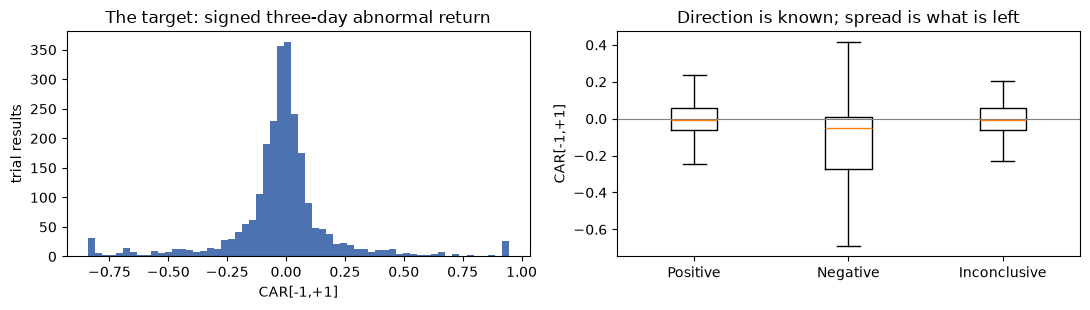


The spread that has to be explained, within each outcome group:


,n,mean,sd,p10,p90,iqr
outcome_group,,,,,,
Inconclusive,175,0.006,0.144,-0.106,0.139,0.121
Negative,440,-0.174,0.285,-0.679,0.047,0.281
Positive,1841,0.017,0.206,-0.143,0.191,0.122


In [37]:
# ---------------------------------------------------------------------------
# Q3a step 1: the target and the unit of analysis.
#
# The row is one classified trial result. 955 of the 2,482 rows sit in a filing
# that reported more than one trial, and every row in such a filing carries the
# same car_3day, because the market reacted once. That single fact drives two
# choices made later: rows are weighted by 1/(trials in the filing) so a
# nine-drug filing does not count nine times, and every cross-validation split
# in this question is grouped by accession so that a filing cannot appear on
# both sides of a fold.
# ---------------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

q3 = analysis.copy()
q3["event_dt"] = pd.to_datetime(q3.event_date)
n_per_filing = q3.groupby("accession").drug_name.transform("size")

print("Analysis rows (one classified trial result each): %d" % len(q3))
print("Distinct filings:                                 %d" % q3.accession.nunique())
print("Distinct companies:                               %d" % q3.ticker.nunique())
print("Rows sitting in a multi-trial filing:             %d (%.0f%%)"
      % ((n_per_filing > 1).sum(), 100 * (n_per_filing > 1).mean()))
print("Date range:                                       %s to %s"
      % (q3.event_dt.min().date(), q3.event_dt.max().date()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(q3.car_3day, bins=60, color="#4c72b0")
ax[0].set_xlabel("CAR[-1,+1]"); ax[0].set_ylabel("trial results")
ax[0].set_title("The target: signed three-day abnormal return")
ax[1].boxplot([q3.loc[q3.outcome_group == g, "car_3day"].dropna()
               for g in ["Positive", "Negative", "Inconclusive"]],
              tick_labels=["Positive", "Negative", "Inconclusive"], showfliers=False)
ax[1].axhline(0, color="grey", lw=0.8)
ax[1].set_ylabel("CAR[-1,+1]"); ax[1].set_title("Direction is known; spread is what is left")
plt.tight_layout(); plt.show()

print("\nThe spread that has to be explained, within each outcome group:")
display(q3.groupby("outcome_group").car_3day.agg(
    n="size", mean="mean", sd="std",
    p10=lambda v: v.quantile(.10), p90=lambda v: v.quantile(.90),
    iqr=lambda v: v.quantile(.75) - v.quantile(.25)).round(3))

Knowing the outcome label places the centre of the distribution — positive readouts average +1.7%,
negative ones −17.4% — but it leaves an interquartile range of 12 percentage points for a positive
readout and 28 for a negative one, and 10th-to-90th ranges of 33 and 73 points. That residual spread
is what Question 3 is trying to narrow, and it is much the wider problem of the two.

In [38]:
# ---------------------------------------------------------------------------
# Q3a step 2: feature group 1, trial and outcome.
#
# These come from the enriched analytical table, with two additions of my own:
# the therapeutic area and cluster label built in Question 2, and an explicit
# indicator for whether the registry linkage produced any design fields at all.
# The linkage failure is not random - Q2a showed it is the single strongest
# structure in the data - so its presence is a feature rather than a nuisance.
#
# Note what is *not* here. overall_status, fda_approved, results_first_posted
# and has_results were excluded in Q1c because they hold 2026 values; Q3b
# measures what including them would have bought.
# ---------------------------------------------------------------------------
F = pd.DataFrame(index=q3.index)
GROUP = {}
def add_group(cols, group):
    for c in cols:
        GROUP[c] = group

SIX_CATS = ["positive", "negative", "mixed-positive", "mixed-negative", "inconclusive", "no_result"]
F["tr_outcome"]       = q3.outcome.where(q3.outcome.isin(SIX_CATS), "multi-label")
F["tr_outcome_group"] = q3.outcome_group.fillna("unknown")
F["tr_phase"]         = q3.phase_bucket
F["tr_allocation"]    = q3.allocation.fillna("missing")
F["tr_masking"]       = q3.masking.fillna("missing")
F["tr_model"]         = q3.intervention_model.fillna("missing")
F["tr_purpose"]       = q3.primary_purpose.fillna("missing")
F["tr_sponsor_class"] = q3.lead_sponsor_class.fillna("missing")
F["tr_area"]          = q3.mesh_area.fillna("unknown")           # Q2a, from registry MeSH terms
F["tr_cluster"]       = q3.cluster.fillna(-1).astype(int).astype(str)   # Q2a cluster label
F["tr_match_conf"]    = q3.match_confidence.fillna("none")
F["tr_log_enrol"]     = np.log1p(q3.enrollment_num)
F["tr_log_sites"]     = np.log1p(q3.n_locations_num)
F["tr_n_arms"]        = q3.n_arm_groups_num
F["tr_n_interv"]      = q3.n_interventions_num
F["tr_n_primary"]     = q3.n_primary_outcomes_num
F["tr_n_secondary"]   = q3.n_secondary_outcomes_num
F["tr_has_dmc"]       = q3.has_dmc.map({"True": 1.0, "False": 0.0})
F["tr_has_registry"]  = q3.nct_id.notna().astype(float)
F["tr_biologic"]      = q3.intervention_types.fillna("").str.contains("BIOLOGICAL").astype(float)
F["tr_genetic"]       = q3.intervention_types.fillna("").str.contains("GENETIC").astype(float)
F["tr_n_drugs_filing"] = n_per_filing.astype(float)
F["tr_multi_drug"]     = (n_per_filing > 1).astype(float)
add_group(list(F.columns), "trial")

print("Group 1 - trial and outcome: %d features" % len(F.columns))
print(textwrap.fill(", ".join(F.columns), 100, initial_indent="   ", subsequent_indent="   "))
print("\nCoverage of the registry-sourced design fields:")
display(pd.DataFrame({"populated": F[["tr_log_enrol", "tr_log_sites", "tr_n_arms", "tr_has_dmc"]].notna().sum(),
                      "share": (F[["tr_log_enrol", "tr_log_sites", "tr_n_arms",
                                   "tr_has_dmc"]].notna().mean()).round(3)}))

Group 1 - trial and outcome: 23 features
   tr_outcome, tr_outcome_group, tr_phase, tr_allocation, tr_masking, tr_model, tr_purpose,
   tr_sponsor_class, tr_area, tr_cluster, tr_match_conf, tr_log_enrol, tr_log_sites, tr_n_arms,
   tr_n_interv, tr_n_primary, tr_n_secondary, tr_has_dmc, tr_has_registry, tr_biologic, tr_genetic,
   tr_n_drugs_filing, tr_multi_drug

Coverage of the registry-sourced design fields:


,populated,share
tr_log_enrol,2094,0.844
tr_log_sites,2098,0.845
tr_n_arms,2098,0.845
tr_has_dmc,1911,0.770


In [39]:
# ---------------------------------------------------------------------------
# Q3a step 3: feature group 2, text. Three representations, deliberately
# different in kind, because the brief asks for at least two and because they
# fail in different ways:
#
#   (a) sentence embeddings of the result sentences (the Q1c vectorisation),
#       reduced by PCA *inside each fold* - meaning, but no identifiable terms;
#   (b) TF-IDF over the same sentences, reduced by truncated SVD inside each
#       fold - identifiable terms, no semantics;
#   (c) counted features: document type, and how often success, failure,
#       safety, hedging, forward-looking and regulatory language appears.
#       These are the only text features a human could read off the filing.
#
# All three are computed from the filing itself, which is published at the
# moment of the event. They are observable before the *reaction*, which is what
# the brief requires, but not before the readout - a distinction that matters
# for Question 4 and is returned to there.
# ---------------------------------------------------------------------------
EMB_COLS = ["emb_%03d" % i for i in range(emb.shape[1])]
F[EMB_COLS] = pd.DataFrame(emb, index=q3.index, columns=EMB_COLS)   # (a)
add_group(EMB_COLS, "text")
F["tx_sentences"] = q3.result_sentences.fillna("")                  # (b), vectorised in-fold
add_group(["tx_sentences"], "text")

clean_txt = filing_txt.set_index("accession")["clean"]
body = q3.accession.map(clean_txt).fillna("")
sent = q3.result_sentences.fillna("")

LEXICON = {                                                          # (c)
    "tx_l_success":    r"\b(met (its|the) (co-)?primary|statistically significant|achieved|demonstrated"
                       r"|superior|positive top-?line|clinically meaningful)\b",
    "tx_l_failure":    r"\b(did not (meet|achieve)|failed to|missed (its|the)|not statistically significant"
                       r"|no (significant|meaningful) (difference|benefit)|futility)\b",
    "tx_l_safety":     r"\b(serious adverse events?|deaths?|mortality|discontinu\w+|dose[- ]limiting"
                       r"|clinical hold|terminat\w+|toxicit\w+)\b",
    "tx_l_hedge":      r"\b(numerical(ly)?|trend(ed|ing)? towards?|nominal(ly)?|exploratory|post[- ]hoc"
                       r"|preliminary|suggests?|may|could|potential(ly)?)\b",
    "tx_l_forward":    r"\b(plans? to|intends? to|expects? to|on track|anticipates?|will (file|submit))\b",
    "tx_l_regulatory": r"\b(NDA|BLA|sNDA|marketing authorisation|marketing authorization|FDA submission"
                       r"|breakthrough therapy|fast track|priority review|accelerated approval)\b",
}
for nm, pat in LEXICON.items():
    F[nm] = sent.str.count(pat, flags=re.I).astype(float)            # in the result sentences
    F[nm + "_doc"] = body.str.count(pat, flags=re.I).astype(float)   # and in the filing as a whole

def smallest_p(t):
    """The most significant p-value quoted, as log10. Absent in most filings, which is itself a signal."""
    v = [float(x) for x in re.findall(r"p\s?[=<]\s?(0?\.\d+)", t, re.I)]
    return np.log10(max(min(v), 1e-6)) if v else np.nan

F["tx_log_len"]     = np.log10(body.str.len().clip(lower=1))
F["tx_n_pvalues"]   = body.str.count(r"p\s?[=<>]\s?0?\.\d+", flags=re.I).astype(float)
F["tx_log_min_p"]   = sent.map(smallest_p)
F["tx_num_density"] = (body.str.count(r"\d") / body.str.len().clip(lower=1)).astype(float)
F["tx_kind"]        = q3.accession.map(filing_txt.set_index("accession")["filing_kind"]).fillna("other")
F["tx_prior_refs"]  = q3.accession.map(filing_txt.set_index("accession")["n_prior_refs"]).fillna(0).astype(float)
F["tx_drug_named"]  = [float(any(t in b.lower() for t in re.split(r"[^A-Za-z0-9]+", str(d).lower()) if len(t) > 3))
                       for d, b in zip(q3.drug_name, body)]
add_group([c for c in F.columns if c.startswith("tx_")], "text")

counted = [c for c in F.columns if c.startswith("tx_") and c != "tx_sentences" and c != "tx_kind"]
print("Group 2 - text: %d embedding dimensions, 1 raw text column for in-fold TF-IDF, %d counted features"
      % (len(EMB_COLS), len(counted)))
# These counts are mostly zero - failure language is absent from two thirds of filings, and
# no p-value is quoted in over half - so cutting them into three equal terciles splits the
# zeros across two buckets by row order, and the low-versus-mid contrast reads row order
# rather than the feature. Zeros get a bucket of their own; the non-zeros split at their
# median. The buckets are unequal, so their sizes are shown beside the means.
def count_buckets(v):
    nz = v[v > 0]
    med = nz.median() if len(nz) else 0
    return pd.Categorical(np.where(v == 0, "none", np.where(v <= med, "some", "many")),
                          categories=["none", "some", "many"], ordered=True)

COUNTED_SHOWN = ["tx_l_success", "tx_l_failure", "tx_l_safety", "tx_l_hedge",
                 "tx_n_pvalues", "tx_prior_refs"]
print("\nDo the counted features move with the market reaction at all?")
print("(mean CAR by how often the language appears, with the number of rows behind each)")
_g = {c: q3.car_3day.groupby(count_buckets(F[c]), observed=False) for c in COUNTED_SHOWN}
chk = (pd.DataFrame({c: g.mean() for c, g in _g.items()}).T.round(3)
         .rename(columns=lambda k: "mean CAR (%s)" % k)
         .join(pd.DataFrame({c: g.size() for c, g in _g.items()}).T
                 .rename(columns=lambda k: "n (%s)" % k)))
display(chk)

Group 2 - text: 384 embedding dimensions, 1 raw text column for in-fold TF-IDF, 18 counted features

Do the counted features move with the market reaction at all?
(mean CAR by how often the language appears, with the number of rows behind each)


,mean CAR (none),mean CAR (some),mean CAR (many),n (none),n (some),n (many)
tx_l_success,-0.042,-0.008,0.025,1055,1057,370
tx_l_failure,-0.003,-0.084,-0.256,2162,256,64
tx_l_safety,-0.016,-0.026,-0.017,1958,353,171
tx_l_hedge,-0.016,-0.008,-0.058,1901,418,163
tx_n_pvalues,-0.031,-0.015,0.022,1465,545,472
tx_prior_refs,-0.020,-0.011,-0.014,1612,442,428


In [40]:
# ---------------------------------------------------------------------------
# Q3a step 4: feature group 3, company and market context - the group where the
# time-matching has to be done rather than assumed.
#
# Everything price-derived is computed on the [-130, -12] trading-day window,
# which is the estimation window the event study itself used. That choice is
# deliberate: it is entirely before the [-1, +1] event window, it leaves a
# ten-day buffer, and it means the features describe the same pre-event period
# the abnormal return is measured against. One feature deliberately looks
# closer in - the [-10, -2] run-up - because a stock that has already moved may
# be reacting to a leak, and the brief asks for features observable before the
# reaction, which that is.
#
# Two data problems have to be dealt with first. The stored close is
# back-adjusted, so historical *levels* are meaningless (one ticker peaks at
# 4.7e11) and price levels are not used at all; and 249 daily moves exceed
# +/-75%, which are corporate actions rather than trading, so they are dropped
# before any statistic is computed.
# ---------------------------------------------------------------------------
px = pd.read_sql("SELECT ticker, date, close, volume FROM stock_prices", conn)
px["date"] = pd.to_datetime(px.date)
px = px.sort_values(["ticker", "date"]).reset_index(drop=True)
px["ret"] = px.groupby("ticker").close.pct_change()
n_bad = int((px.ret.abs() > 0.75).sum())
px.loc[px.ret.abs() > 0.75, "ret"] = np.nan
print("Price panel: %d rows, %d tickers. Dropped %d suspected corporate-action returns."
      % (len(px), px.ticker.nunique(), n_bad))

panels = {t: g.reset_index(drop=True) for t, g in px.groupby("ticker")}
mkt_ret = panels["SPY"].set_index("date")["ret"]        # the market factor the event study used
bio_ret = panels["XBI"].set_index("date")["ret"]        # biotech sector, downloaded but unused there
EST_START, EST_END = 130, 11                            # slices to [-130, -12]

def price_features(ticker, dt):
    """Company and market context as at the filing date, from prices alone."""
    out = {}
    g = panels.get(ticker)
    if g is None:
        return out
    i = int(np.searchsorted(g.date.values, np.datetime64(dt)))     # first row on or after the event
    est = g.iloc[max(0, i - EST_START):max(0, i - EST_END)]        # [-130, -11]
    if len(est) < 30:
        return out
    r = est.ret.dropna()
    out["cx_vol_120"] = r.std()
    out["cx_ret_120"] = float(np.expm1(np.log1p(r).sum()))
    # [-30, -12]: 19 trading days, the near end of the same estimation window.
    recent = g.iloc[max(0, i - 30):max(0, i - EST_END)].ret.dropna()
    out["cx_vol_20"] = recent.std()
    out["cx_ret_20"] = float(np.expm1(np.log1p(recent).sum()))
    runup = g.iloc[max(0, i - 10):max(0, i - 1)].ret.dropna()      # [-10, -2]
    out["cx_runup_10"] = float(np.expm1(np.log1p(runup).sum())) if len(runup) else np.nan
    out["cx_log_volume"] = np.log10(max(est.volume.median(), 1.0))
    j = est.set_index("date").ret
    m = mkt_ret.reindex(j.index)
    ok = j.notna() & m.notna()
    if ok.sum() >= 30 and m[ok].std() > 0:
        b, a = np.polyfit(m[ok], j[ok], 1)
        out["cx_beta"] = float(b)
        out["cx_idio_vol"] = float((j[ok] - (a + b * m[ok])).std())   # residual risk: the key size proxy
        out["cx_mkt_r2"] = float(np.corrcoef(m[ok], j[ok])[0, 1] ** 2)
    cutoff = g.date.iloc[max(0, i - EST_END)]
    out["cx_spy_ret_20"] = float(np.expm1(np.log1p(mkt_ret[mkt_ret.index < cutoff].dropna().tail(20)).sum()))
    out["cx_spy_vol_20"] = float(mkt_ret[mkt_ret.index < cutoff].dropna().tail(20).std())
    out["cx_xbi_ret_20"] = float(np.expm1(np.log1p(bio_ret[bio_ret.index < cutoff].dropna().tail(20)).sum()))
    out["cx_xbi_vol_20"] = float(bio_ret[bio_ret.index < cutoff].dropna().tail(20).std())
    out["_close_evt"] = float(g.close.iloc[min(i, len(g) - 1)])
    out["_close_lag"] = float(g.close.iloc[max(0, i - EST_END - 1)])
    return out

pxf = pd.DataFrame([price_features(t, d) for t, d in zip(q3.ticker, q3.event_dt)], index=q3.index)
for c in [c for c in pxf.columns if c.startswith("cx_")]:
    pxf[c] = pxf[c].clip(pxf[c].quantile(0.005), pxf[c].quantile(0.995))
for c in [c for c in pxf.columns if c.startswith("cx_")]:
    F[c] = pxf[c]

# market_cap is priced off the close on (or immediately before) the event date, which sits
# inside the event window. Re-pricing it by the ratio of the two closes moves it back to
# t-12, the last day of the estimation window; the ratio is invariant to how the series is
# adjusted, so the back-adjusted closes can be used for it even though their levels cannot.
ratio = (pxf._close_lag / pxf._close_evt).where((pxf._close_evt > 0) & (pxf._close_lag > 0), 1.0)
F["co_log_mktcap"]     = np.log10((q3.market_cap * ratio).clip(lower=1e5))
F["co_mktcap_missing"] = q3.market_cap.isna().astype(float)

# Regulatory track record. fda_n_prior_approvals and fda_years_since_approval are computed
# against the event date by the pipeline (methodology, Step 2b) and are therefore usable;
# fda_approved, fda_marketing_status and company_n_fda_approved are 2026 snapshots and are not.
fda_feat = pd.read_sql("SELECT * FROM event_fda_features", conn).drop_duplicates(["accession", "drug_name"])
fj = q3[["accession", "drug_name"]].merge(fda_feat, on=["accession", "drug_name"], how="left")
fj.index = q3.index
F["co_fda_app_type"]   = fj.fda_application_type.fillna("none")
F["co_fda_prior_appr"] = fj.fda_n_prior_approvals
F["co_fda_yrs_appr"]   = fj.fda_years_since_approval
F["co_fda_dosage"]     = fj.fda_n_dosage_forms

# The company's own disclosure history, using only events that had already happened.
#
# This has to expand over event DATES, not over rows, and getting that wrong was
# the one real leak this section's own audit turned up. Every row of a filing
# that reported several trials carries the same car_3day, because the market
# reacted once. An expanding mean taken over rows therefore hands the second and
# later rows of such a filing their own target: 577 rows, 23% of the data, sit
# in that position. Grouping the folds by accession does not repair it - the
# contaminated value is baked into the row before any split exists, so it
# survives every split design in Q3b, forward chaining included. Collapsing to
# one observation per (ticker, event date) first is the fix. It also makes
# "days since the previous event" mean what it says: under the row-wise version
# 593 rows recorded a prior event nought days ago, which was a sibling row in
# the same press release.
evt = (q3.groupby(["ticker", "event_dt"], as_index=False).car_3day.mean()
         .sort_values(["ticker", "event_dt"]))
evt["abs_car"]  = evt.car_3day.abs()
evt["n_prior"]  = evt.groupby("ticker").cumcount()
evt["pri_mean"] = evt.groupby("ticker").car_3day.transform(lambda v: v.shift().expanding().mean())
evt["pri_abs"]  = evt.groupby("ticker").abs_car.transform(lambda v: v.shift().expanding().mean())
evt["gap"]      = evt.groupby("ticker").event_dt.diff().dt.days
evt = evt.set_index(["ticker", "event_dt"])
key = pd.MultiIndex.from_arrays([q3.ticker.values, q3.event_dt.values])
F["co_n_prior_events"]   = evt.n_prior.reindex(key).to_numpy(dtype=float)
F["co_prior_mean_car"]   = evt.pri_mean.reindex(key).to_numpy()
F["co_prior_abs_car"]    = evt.pri_abs.reindex(key).to_numpy()
F["co_days_since_prior"] = np.log1p(evt.gap.reindex(key).to_numpy(dtype=float))
F["co_year"]             = q3.event_dt.dt.year.astype(float)

# The audit itself, kept in the notebook because the result is the evidence that
# the rule at the top of Q3a is actually enforced rather than stated.
_naive = (q3[["ticker", "event_dt", "car_3day"]].sort_values(["ticker", "event_dt"])
            .groupby("ticker").car_3day.transform(lambda v: v.shift().expanding().mean())
            .reindex(q3.index))
_both = _naive.notna().values & F.co_prior_mean_car.notna().values
print("\nPrior-CAR history: correlation with the row's own car_3day, over the %d rows both "
      "versions define" % _both.sum())
print("   expanding over rows       %+.3f   <- leaks; %d rows would carry their own filing"
      % (np.corrcoef(_naive[_both], q3.car_3day[_both])[0, 1],
         int((q3.groupby("accession").cumcount() > 0).sum())))
print("   expanding over event dates %+.3f   <- used here"
      % np.corrcoef(F.co_prior_mean_car[_both], q3.car_3day[_both])[0, 1])
add_group([c for c in F.columns if c.startswith(("co_", "cx_"))], "company")

print("\nGroup 3 - company and market context: %d features"
      % sum(1 for c in F.columns if GROUP[c] == "company"))
display(F[[c for c in F.columns if c.startswith(("co_", "cx_")) and
           pd.api.types.is_numeric_dtype(F[c])]].describe().T[["count", "mean", "std", "min", "max"]].round(3))

Price panel: 486378 rows, 320 tickers. Dropped 249 suspected corporate-action returns.

Prior-CAR history: correlation with the row's own car_3day, over the 2089 rows both versions define
   expanding over rows       +0.034   <- leaks; 577 rows would carry their own filing
   expanding over event dates +0.005   <- used here

Group 3 - company and market context: 24 features


,count,mean,std,min,max
cx_vol_120,2482.0,0.045,0.022,0.008,0.120
cx_ret_120,2482.0,0.065,0.634,-0.875,3.315
cx_vol_20,2482.0,0.043,0.028,0.006,0.170
cx_ret_20,2482.0,0.007,0.226,-0.699,1.147
cx_runup_10,2482.0,0.004,0.144,-0.531,0.587
cx_log_volume,2482.0,5.020,1.676,0.000,7.609
cx_beta,2482.0,1.130,0.688,-0.705,3.313
cx_idio_vol,2482.0,0.043,0.022,0.007,0.119
cx_mkt_r2,2479.0,0.108,0.110,0.000,0.561
cx_spy_ret_20,2482.0,0.010,0.040,-0.138,0.131


#### Where each feature comes from, and the window behind it

The whole feature set could be rebuilt as at any filing date from the four sources below. Nothing in
it requires knowing how the event turned out.

| Group | Feature | Source | Observation window relative to the filing date |
|---|---|---|---|
| Trial | design, phase, enrolment, sites, sponsor class, DMC | `studies` via `event_study_enriched` | registered at trial start, years before |
| Trial | outcome label, therapeutic area, Q2 cluster | `consensus_outcomes`, registry MeSH, Q2a | derived from the filing and the registration; known at t = 0 |
| Trial | linkage indicator, match confidence | `study_event_link` | fixed at linkage; a property of the record |
| Text | sentence embeddings, TF-IDF, counted language | `filing_text` | the filing itself, published at t = 0 |
| Company | volatility, momentum, beta, idiosyncratic risk, volume | `stock_prices` | **[−130, −12] trading days** |
| Company | pre-announcement run-up | `stock_prices` | **[−10, −2] trading days** |
| Company | market and sector regime (SPY, XBI) | `stock_prices` | 20 trading days ending at t − 12 |
| Company | market capitalisation | `event_study_enriched`, re-priced | shares × close at **t − 12** |
| Company | FDA prior approvals, years since approval | `event_fda_features` | computed against the event date by the pipeline |
| Company | prior readouts, mean prior CAR, gap since last | this dataset, expanding | strictly earlier **event dates** for the same ticker |

Three of these needed correcting rather than accepting. `market_cap` is priced off the close on or
immediately before the event date, which is inside the [−1, +1] window; it is re-priced back to
t − 12 above. And the FDA block splits: the two time-relative columns are computed against the event
date and are usable, while `fda_approved`, `fda_marketing_status` and `company_n_fda_approved` hold
2026 values and are held back for the leakage test in Q3b.

The third was mine, and it is the reason this section is worth reading rather than skimming. The
company's disclosure history — `co_prior_mean_car`, `co_prior_abs_car`, `co_n_prior_events`,
`co_days_since_prior` — looks unimpeachable: an expanding mean over the same ticker's *earlier*
events, shifted by one so that today never enters. It leaked anyway. The analysis row is one trial
result, but the market reaction belongs to the filing, so all eight rows of a Pfizer 8-K reporting
eight drugs carry an identical `car_3day`. Expanding over rows hands row two the CAR of row one,
which *is* row two's answer; by row eight the "prior mean" has been dragged most of the way to
today's number. **577 rows, 23% of the data, were in that position**, and on those rows the feature
correlated **+0.56** with the very quantity being predicted, against **+0.01** on the clean ones.
(The check printed above is the all-rows figure, +0.034 against +0.005 — diluted by the three
quarters of rows that were never contaminated, which is why the subgroup is the number that
matters.)

Two things make this worth stating rather than quietly fixing. First, grouping every fold by
accession — which Q3b does, and which is the right thing to do — gives no protection at all here:
the contaminated value is computed before any split exists, so it travels into the test fold inside
the row. No cross-validation design can detect it, forward chaining included. Second, the fix
*raised* out-of-sample $R^2$ rather than lowering it, because the contaminated values were noisier
than the honest ones. Leakage is not always flattering, and a leak that costs accuracy is still a
leak: the claim at the top of this section is that every feature is computable before the reaction,
and for 23% of rows that claim was false. The features above are now expanded over distinct
`(ticker, event date)` pairs, which also disposes of the 16 ticker-dates carrying two separate
filings that share one reaction.

One honest limitation, and it is the important one for Question 4. The text and outcome features are
observable before the *reaction*, which is what this question requires, but not before the *readout*.
A model that uses them forecasts the market's response to a disclosure that already exists. Question
4 has no such disclosure, and that is why Q3b measures how much of the performance survives without
the text group.

In [41]:
# ---------------------------------------------------------------------------
# Q3a step 5: assemble, and set aside the columns that will be used to
# demonstrate leakage in Q3b rather than to predict.
# ---------------------------------------------------------------------------
CAT_COLS = [c for c in F.columns if not pd.api.types.is_numeric_dtype(F[c]) and c != "tx_sentences"]
NUM_COLS = [c for c in F.columns if c not in CAT_COLS + ["tx_sentences"] + EMB_COLS]
y_car = q3.car_3day.values
w_row = (1.0 / n_per_filing).values          # a filing contributes one unit of evidence, not nine

LEAKY = pd.DataFrame(index=q3.index)
LEAKY["lk_ar_day0"]        = q3.ar_day0
LEAKY["lk_car_raw"]        = q3.car_3day_raw
LEAKY["lk_alpha_supplied"] = q3.alpha
LEAKY["lk_beta_supplied"]  = q3.beta
LEAKY["lk_overall_status"] = q3.overall_status.fillna("missing")
LEAKY["lk_fda_approved"]   = q3.fda_approved.map({"True": 1.0, "False": 0.0})
LEAKY["lk_company_appr"]   = fj.company_n_fda_approved
LEAKY["lk_disclosure_lag"] = q3.disclosure_lag_days
LEAKY["lk_risk_score_q1b"] = q3.risk_score_q1b

inv = pd.DataFrame({
    "columns": {g: sum(1 for c in F.columns if GROUP[c] == g) for g in ["trial", "text", "company"]},
    "of which categorical": {g: sum(1 for c in CAT_COLS if GROUP[c] == g) for g in ["trial", "text", "company"]},
    "fitted inside the fold": {"trial": "-", "text": "PCA(30) on embeddings, TF-IDF + SVD(30)",
                               "company": "-"}})
print("Feature set for Question 3: %d columns before in-fold expansion\n" % F.shape[1])
display(inv)
print("Held back as leakage candidates, used in Q3b only to measure what they would have bought:")
print(textwrap.fill(", ".join(LEAKY.columns), 100, initial_indent="   ", subsequent_indent="   "))
print("\nMissingness across the numeric features (share of rows), worst ten:")
display((1 - F[NUM_COLS].notna().mean()).sort_values(ascending=False).head(10).round(3).to_frame("share missing"))

Feature set for Question 3: 451 columns before in-fold expansion



,columns,of which categorical,fitted inside the fold
trial,23,11,-
text,404,1,"PCA(30) on embeddings, TF-IDF + SVD(30)"
company,24,1,-


Held back as leakage candidates, used in Q3b only to measure what they would have bought:
   lk_ar_day0, lk_car_raw, lk_alpha_supplied, lk_beta_supplied, lk_overall_status, lk_fda_approved,
   lk_company_appr, lk_disclosure_lag, lk_risk_score_q1b

Missingness across the numeric features (share of rows), worst ten:


,share missing
tx_log_min_p,0.776
co_fda_yrs_appr,0.769
co_fda_prior_appr,0.609
co_fda_dosage,0.609
tr_has_dmc,0.230
co_prior_abs_car,0.158
co_days_since_prior,0.158
co_prior_mean_car,0.158
tr_log_enrol,0.156
tr_n_primary,0.155


In [42]:
# ---------------------------------------------------------------------------
# Q3a step 6: the evaluation protocol, defined once and used everywhere below.
#
# Every learned step - imputation, scaling, one-hot layout, PCA on the
# embeddings, the TF-IDF vocabulary and its SVD - sits inside the pipeline, so
# it is refitted on the training rows of each fold. Q1c measured what fitting
# the PCA on everything instead would do; here it is simply never done.
#
# The splits are grouped by accession. A filing that reported three trials
# contributes three rows sharing one car_3day, and an ungrouped split would put
# some of them in training and the rest in test, scoring the model on a number
# it had already seen.
# ---------------------------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import roc_auc_score

FEATURE_GROUPS = ("trial", "text", "company")

def make_preprocessor(groups, n_pca=30, n_svd=30):
    """Numeric, categorical and both text representations, all fitted in-fold."""
    keep = {c for c in F.columns if GROUP[c] in groups}
    blocks = []
    num = [c for c in NUM_COLS if c in keep]
    cat = [c for c in CAT_COLS if c in keep]
    if num:
        blocks.append(("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                                        ("sc", StandardScaler())]), num))
    if cat:
        blocks.append(("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=15,
                                            sparse_output=False), cat))
    if "text" in groups:
        blocks.append(("emb", Pipeline([("sc", StandardScaler()),
                                        ("pca", PCA(n_components=n_pca, random_state=MEMBER_ID))]), EMB_COLS))
        blocks.append(("tfidf", Pipeline([
            ("tf", TfidfVectorizer(min_df=5, max_features=20000, stop_words="english",
                                   ngram_range=(1, 2), sublinear_tf=True)),
            ("svd", TruncatedSVD(n_components=n_svd, random_state=MEMBER_ID)),
            ("sc", StandardScaler())]), "tx_sentences"))
    return ColumnTransformer(blocks, remainder="drop")

def make_pipeline_for(model_fn, groups, extra=None):
    """extra is used only to bolt a leakage candidate onto the clean feature set."""
    def build():
        if extra is None:
            pre = make_preprocessor(groups)
        else:
            enum = [c for c in extra.columns if pd.api.types.is_numeric_dtype(extra[c])]
            ecat = [c for c in extra.columns if c not in enum]
            blocks = [("main", make_preprocessor(groups), list(F.columns))]
            if enum:
                blocks.append(("xnum", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                                                 ("sc", StandardScaler())]), enum))
            if ecat:
                blocks.append(("xcat", OneHotEncoder(handle_unknown="ignore", min_frequency=15,
                                                     sparse_output=False), ecat))
            pre = ColumnTransformer(blocks)
        return Pipeline([("pre", pre), ("model", model_fn())])
    return build

def folds_for(kind="accession", n=5, seed=MEMBER_ID):
    if kind == "time":                       # forward chaining: train on the past, predict the next block
        order = np.argsort(q3.event_dt.values)
        chunk = np.array_split(order, n + 1)
        return [(np.concatenate(chunk[:i + 1]), chunk[i + 1]) for i in range(n)]
    if kind == "random":                     # deliberately wrong, for comparison
        return list(KFold(n, shuffle=True, random_state=seed).split(F))
    return list(GroupKFold(n, shuffle=True, random_state=seed)
                .split(F, y_car, groups=q3[kind].values))

def out_of_fold(model_fn, groups, folds, extra=None, weights=None):
    Xf = pd.concat([F, extra], axis=1) if extra is not None else F
    w = w_row if weights is None else weights
    pred = np.full(len(y_car), np.nan)
    for tr, te in folds:
        pipe = make_pipeline_for(model_fn, groups, extra)()
        pipe.fit(Xf.iloc[tr], y_car[tr], model__sample_weight=w[tr])
        pred[te] = pipe.predict(Xf.iloc[te])
    return pred

def score(pred, mask=None, baseline=None):
    m = np.ones(len(y_car), bool) if mask is None else np.asarray(mask)
    m = m & np.isfinite(pred)
    yy, pp = y_car[m], pred[m]
    base = yy.mean() if baseline is None else baseline
    ss_res = ((yy - pp) ** 2).sum()
    return {"n": int(m.sum()), "RMSE": float(np.sqrt(ss_res / len(yy))),
            "MAE": float(np.abs(yy - pp).mean()),
            "R2": float(1 - ss_res / ((yy - base) ** 2).sum()),
            "Pearson": float(np.corrcoef(yy, pp)[0, 1]),
            "Spearman": float(stats.spearmanr(yy, pp).statistic)}

RF = lambda: RandomForestRegressor(n_estimators=400, min_samples_leaf=8, max_features=0.3,
                                   random_state=MEMBER_ID, n_jobs=-1)
print("Protocol: 5-fold GroupKFold on accession; %d filings across the folds." % q3.accession.nunique())
print("All imputation, scaling, PCA and TF-IDF fitted inside each fold.")

Protocol: 5-fold GroupKFold on accession; 1905 filings across the folds.
All imputation, scaling, PCA and TF-IDF fitted inside each fold.


In [43]:
# ---------------------------------------------------------------------------
# Q3a step 7: the two treatment decisions, tested against their alternatives
# rather than asserted. Both are run on the same folds and the same model.
# ---------------------------------------------------------------------------
def score_subset(mask=None, weights=None, tag=""):
    idx = np.arange(len(y_car)) if mask is None else np.where(np.asarray(mask))[0]
    sub = list(GroupKFold(5, shuffle=True, random_state=MEMBER_ID)
               .split(F.iloc[idx], y_car[idx], groups=q3.accession.values[idx]))
    w = (w_row if weights is None else weights)[idx]
    pred = np.full(len(idx), np.nan)
    for tr, te in sub:
        pipe = make_pipeline_for(RF, FEATURE_GROUPS)()
        pipe.fit(F.iloc[idx[tr]], y_car[idx[tr]], model__sample_weight=w[tr])
        pred[te] = pipe.predict(F.iloc[idx[te]])
    yy = y_car[idx]
    out = np.full(len(y_car), np.nan)
    out[idx] = pred
    score_subset.last = out
    return {"treatment": tag, "rows scored": len(idx),
            "R2": 1 - ((yy - pred) ** 2).sum() / ((yy - yy.mean()) ** 2).sum(),
            "RMSE": float(np.sqrt(((yy - pred) ** 2).mean())),
            "Spearman": float(pd.Series(pred).corr(pd.Series(yy), method="spearman"))}

print("Filings covering more than one trial (%d rows in %d such filings):"
      % (int((n_per_filing > 1).sum()), int((q3.groupby('accession').size() > 1).sum())))
display(pd.DataFrame([
    score_subset(weights=np.ones(len(y_car)), tag="one row per trial result, unweighted"),
    score_subset(tag="one row per trial result, weighted 1/(trials in filing)  [chosen]"),
    score_subset(mask=(~q3.accession.duplicated()).values, tag="one row per filing, first result kept"),
]).set_index("treatment").round(4))

print("\nMissing registry design fields (%d of %d rows have them populated):"
      % (int(F.tr_log_enrol.notna().sum()), len(F)))
rows_md = [score_subset(tag="median imputation + missingness indicators  [chosen]")]
imputed_pred = score_subset.last
rows_md.append(score_subset(mask=F.tr_log_enrol.notna().values,
                            tag="drop rows without registry design"))
# The two lines above are scored on different row sets, so they are not comparable as they
# stand. The like-for-like comparison scores the imputed model on the rows the other keeps.
have = F.tr_log_enrol.notna().values
yy, pp = y_car[have], imputed_pred[have]
rows_md.append({"treatment": "  ...the imputed model, scored on those same rows",
                "rows scored": int(have.sum()),
                "R2": 1 - ((yy - pp) ** 2).sum() / ((yy - yy.mean()) ** 2).sum(),
                "RMSE": float(np.sqrt(((yy - pp) ** 2).mean())),
                "Spearman": float(pd.Series(pp).corr(pd.Series(yy), method="spearman"))})
display(pd.DataFrame(rows_md).set_index("treatment").round(4))

Filings covering more than one trial (955 rows in 378 such filings):


,rows scored,R2,RMSE,Spearman
treatment,,,,
"one row per trial result, unweighted",2482,0.2113,0.2056,0.2714
"one row per trial result, weighted 1/(trials in filing) [chosen]",2482,0.2066,0.2062,0.2624
"one row per filing, first result kept",1905,0.2071,0.2265,0.2971



Missing registry design fields (2094 of 2482 rows have them populated):


,rows scored,R2,RMSE,Spearman
treatment,,,,
median imputation + missingness indicators [chosen],2482,0.2066,0.2062,0.2624
drop rows without registry design,2094,0.2063,0.2114,0.2960
"...the imputed model, scored on those same rows",2094,0.2090,0.2111,0.2658


#### What the two comparisons decided

**Multi-trial filings.** All three treatments land within 0.005 of each other on $R^2$, so this is a
choice about what the model is asked to represent rather than about accuracy. Collapsing to one row
per filing throws away 577 classified trial results, including every second and third drug in the
large pharmaceutical filings, and would leave Question 4 without a model that scores a single asset.
Leaving the rows unweighted lets a nine-drug Lilly filing count nine times towards a return the
market produced once. Weighting each row by 1/(trials in the filing) keeps every trial result while
giving each filing one unit of evidence, and costs 0.005 of $R^2$ against the unweighted fit. That is
the treatment used from here on, in combination with grouping every fold by accession.

**Missing registry design.** 388 rows have no populated trial design, because the study–event linkage
failed, and Q2a established that these rows are not a random subset of the data. Scored like for like
on the 2,094 rows both approaches can reach, **imputing is very slightly the better of the two**
(0.209 against 0.206) — so it is not a case of paying an accuracy price for coverage, as an earlier
draft of this paragraph assumed. The 0.003 gap is smaller than the run-to-run standard deviation of
0.004 that Q3b measures for this model, so the honest reading is that the two are indistinguishable
on the rows both can score, and the decision rests on what else imputing buys: 388 additional trial
results, and an answer for a readout whose registration could not be found.
Median imputation with an explicit missingness indicator also lets the model use "we could not link
this one" as information, which Q2a showed is one of the strongest structures in the data.
Categorical fields take an explicit `missing` level for the same reason.

## Q3b: Construct magnitude prediction models (10 marks)

Three properties of this data decide which model families are worth fitting.

- **The signal is concentrated in a few features and the rest is noise.** Q2 established that trial
  design explains almost nothing about market reaction; the outcome label alone explains 9%. With
  2,482 rows and roughly 500 columns before in-fold expansion, anything that fits freely will fit
  noise, so both families below are chosen for how they are regularised rather than for flexibility.
- **The target is heavy-tailed and bounded in practice.** `car_3day` is winsorised at the 1st and
  99th percentiles, so the extremes are censored rather than extreme, and squared-error loss is not
  being dragged by a handful of 800% observations.
- **The relationships are unlikely to be additive.** Volatility should matter more for a negative
  readout than a positive one; the same 30% pre-event run-up means something different for a $200m
  company than for a $20bn one. Interactions of that kind are the reason a tree ensemble is here.

**How the settings below were chosen.** Each family is swept over its main regularisation
parameter, and the setting carried into the comparison is *selected from that sweep in code* rather
than copied across by hand: the best-scoring setting, unless a more regularised one sits within 0.005
of it, in which case the more regularised one is taken. An earlier version hard-coded the settings,
and the sweep then quietly showed a better one in every family — the booster was run a level
shallower than its own sweep preferred, by more than the run-to-run variation. Deriving the choice removes that gap and makes the tie-break
toward regularisation an explicit rule instead of an unstated preference. Each grid is also extended
past whichever setting won previously, so no family is selected at the edge of its own grid. All
three models are then carried through every table in this question: the split-design comparison and
the feature ablation both run all of them.

**Family 1 — penalised linear regression (ridge).** A single L2-penalised linear model over the whole
feature set, including the 30 embedding components and 30 TF-IDF components. It suits the data
because those text blocks are dense, correlated and roughly continuous, which is exactly what ridge
handles well, and because it gives a floor: whatever it achieves is available without any interaction
structure at all. **Alternative not used: ordinary least squares.** With ~500 columns and several
one-hot blocks of near-collinear levels, an unpenalised fit is unstable — and the ridge sweep below
shows performance climbing steadily as the penalty rises from α = 30 to α = 1000 before falling away
again at α = 3000, which says the penalty is doing real work rather than being a formality, and that
the grid now brackets its own optimum rather than stopping at it. **Lasso was also considered and
rejected**: it selects among correlated embedding
components arbitrarily, and the ablation in this question needs feature *groups* compared, not
individual columns picked.

**Family 2 — tree ensembles (random forest and gradient boosting).** Both capture the interactions
above without being told about them, both handle the mixture of counts, one-hot levels and continuous
components without further transformation, and they differ from each other in the way that matters
here: the forest averages high-variance trees, the booster fits residuals in sequence. Given how
little signal there is, the forest's variance reduction should suit this data better than the
booster's bias reduction, and it does. **Alternative not used: a neural network.** 2,482 rows against
500 features, with an $R^2$ around 0.2, is not a regime where a network can be regularised into
reliability, and nothing about the problem needs representation learning that the embeddings have not
already done. **k-nearest neighbours was also rejected**: distance in a 60-dimensional text space is
close to meaningless at this sample size, which is the same problem Q2a ran into with silhouette.

In [44]:
# ---------------------------------------------------------------------------
# Q3b step 1: the three models, against two baselines that matter. The
# outcome-group baseline is the one to beat - it is what the IR team already
# has, since knowing whether a readout is good or bad news is free.
#
# A sensitivity sweep runs first, and the setting carried into step 2 is
# SELECTED from it by a stated rule rather than copied across by hand. An
# earlier version of this notebook hard-coded the settings, and the sweep then
# showed a better one in every family - depth=4 beat the depth=3 that was
# actually used, by more than the run-to-run variation. Deriving the choice
# from the table removes that gap entirely.
#
# The rule: take the highest-scoring setting, unless a MORE REGULARISED one is
# within SWEEP_TOL of it, in which case take that. With 2,482 rows and roughly
# 500 columns before in-fold expansion, a difference inside the tolerance is
# not worth spending flexibility on. Each config therefore carries an explicit
# regularisation rank, because "more regularised" is not something the code can
# infer from a hyperparameter name.
#
# Each grid is also extended past whichever setting won last time, so that no
# family is selected at the edge of its own grid with the curve still rising.
# ---------------------------------------------------------------------------
folds_acc = folds_for("accession")
SWEEP_TOL = 0.005

def _ridge(a):
    return lambda: Ridge(alpha=float(a), random_state=MEMBER_ID)

def _gbm(d, lr=0.05):
    return lambda: HistGradientBoostingRegressor(
        max_depth=d, learning_rate=lr, max_iter=400, min_samples_leaf=40,
        l2_regularization=1.0, early_stopping=False, random_state=MEMBER_ID)

def _rf(leaf, mf):
    return lambda: RandomForestRegressor(
        n_estimators=400, min_samples_leaf=leaf, max_features=mf,
        random_state=MEMBER_ID, n_jobs=-1)

# (family, label, regularisation rank - higher is more regularised, builder).
# ridge: a larger penalty is more regularised. boosting: a shallower tree is.
# forest: a larger leaf is, and sampling sqrt(p) features per split is more
# restrictive again than sampling 30% of them.
GRID = (
    [("ridge", "alpha=%d" % a, r, _ridge(a))
     for r, a in enumerate([30, 100, 300, 1000, 3000], start=1)]
    + [("gradient boosting", "depth=%d lr=0.05" % d, r, _gbm(d))
       for r, d in enumerate([5, 4, 3, 2], start=1)]
    + [("random forest", "leaf=%d features=%s" % (leaf, mf), r, _rf(leaf, mf))
       for r, (leaf, mf) in enumerate([(4, 0.3), (8, 0.3), (16, 0.3), (8, "sqrt")], start=1)]
)
FAMILIES = ["ridge", "gradient boosting", "random forest"]

sweep = []
for fam, label, rank, build in GRID:
    p = out_of_fold(build, FEATURE_GROUPS, folds_acc)
    sweep.append({"family": fam, "setting": label, "reg rank": rank, **score(p)})
print("Sensitivity to the main hyperparameter of each family (same folds throughout):")
display(pd.DataFrame(sweep).set_index(["family", "setting"])[
    ["reg rank", "R2", "RMSE", "MAE", "Spearman"]].round(4))

def pick_setting(fam):
    """Best in family, or the most regularised setting within SWEEP_TOL of it."""
    rows = [r for r in sweep if r["family"] == fam]
    best = max(r["R2"] for r in rows)
    near = [r for r in rows if best - r["R2"] <= SWEEP_TOL]
    return max(near, key=lambda r: r["reg rank"]), best

BUILDER = {(fam, label): build for fam, label, _, build in GRID}
CHOSEN = {}
print("\nSetting carried into step 2 - best in family, or the most regularised within %.3f of it:"
      % SWEEP_TOL)
for fam in FAMILIES:
    row, best = pick_setting(fam)
    CHOSEN[fam] = row
    flag = "" if abs(row["R2"] - best) < 1e-12 else "   (best in family %.4f, taken as a tie)" % best
    print("   %-18s %-22s R2 %.4f%s" % (fam, row["setting"], row["R2"], flag))


Sensitivity to the main hyperparameter of each family (same folds throughout):


reg rank      R2    RMSE     MAE  \
family            setting                                                  
ridge             alpha=30                     1  0.0793  0.2222  0.1547   
                  alpha=100                    2  0.0965  0.2201  0.1509   
                  alpha=300                    3  0.1097  0.2185  0.1464   
                  alpha=1000                   4  0.1117  0.2182  0.1409   
                  alpha=3000                   5  0.0954  0.2202  0.1364   
gradient boosting depth=5 lr=0.05              1  0.1863  0.2088  0.1380   
                  depth=4 lr=0.05              2  0.1876  0.2087  0.1369   
                  depth=3 lr=0.05              3  0.1749  0.2103  0.1383   
                  depth=2 lr=0.05              4  0.1646  0.2116  0.1392   
random forest     leaf=4 features=0.3          1  0.2094  0.2059  0.1291   
                  leaf=8 features=0.3          2  0.2066  0.2062  0.1290   
                  leaf=16 features=0.3         3  0.2012  0.2069  0.1298   
                  leaf=8 features=sqrt         4  0.1813  0.2095  0.1296   

                                        Spearman  
family            setting                         
ridge             alpha=30                0.2171  
                  alpha=100               0.2150  
                  alpha=300               0.2100  
                  alpha=1000              0.1977  
                  alpha=3000              0.1819  
gradient boosting depth=5 lr=0.05         0.2458  
                  depth=4 lr=0.05         0.2390  
                  depth=3 lr=0.05         0.2331  
                  depth=2 lr=0.05         0.2298  
random forest     leaf=4 features=0.3     0.2625  
                  leaf=8 features=0.3     0.2624  
                  leaf=16 features=0.3    0.2555  
                  leaf=8 features=sqrt    0.2565


Setting carried into step 2 - best in family, or the most regularised within 0.005 of it:
   ridge              alpha=1000             R2 0.1117
   gradient boosting  depth=4 lr=0.05        R2 0.1876
   random forest      leaf=8 features=0.3    R2 0.2066   (best in family 0.2094, taken as a tie)


In [45]:
# ---------------------------------------------------------------------------
# Q3b step 2: the headline comparison, at the settings the sweep selected.
#
# The builders come straight out of the sweep, so the settings reported here
# cannot drift from the settings that were tested.
# ---------------------------------------------------------------------------
RIDGE = BUILDER[("ridge", CHOSEN["ridge"]["setting"])]
GBM   = BUILDER[("gradient boosting", CHOSEN["gradient boosting"]["setting"])]

# RF was defined in Q3a step 6 as leaf=8, features=0.3 and used there for the
# feature-treatment comparisons. If the sweep selects a different forest, it is
# rebound here so that everything from this point on uses one forest, and the
# change is reported rather than left for the reader to notice.
_rf_chosen = CHOSEN["random forest"]["setting"]
if _rf_chosen != "leaf=8 features=0.3":
    print("NOTE: the sweep selected %s. The reference forest from Q3a step 6 (leaf=8 "
          "features=0.3) is rebound to it for everything below; the Q3a step 7 comparisons "
          "above were run at the original setting." % _rf_chosen)
RF = BUILDER[("random forest", _rf_chosen)]

MODELS = {"Ridge (linear)": RIDGE, "Gradient boosting": GBM, "Random forest": RF}

oof_pred, rows = {}, []
for nm, fn in MODELS.items():
    oof_pred[nm] = out_of_fold(fn, FEATURE_GROUPS, folds_acc)
    rows.append({"model": nm, **score(oof_pred[nm])})

# Baseline 1: the unconditional mean. Baseline 2: the mean of the outcome group,
# which is what knowing 'is this good news or bad news' is worth on its own.
mean_pred = np.full(len(y_car), np.nan)
grp_pred = np.full(len(y_car), np.nan)
og_all = q3.outcome_group.fillna("unknown").values
for tr, te in folds_acc:
    mean_pred[te] = y_car[tr].mean()
    mu = pd.Series(y_car[tr]).groupby(og_all[tr]).mean()
    grp_pred[te] = pd.Series(og_all[te]).map(mu).fillna(y_car[tr].mean()).values
oof_pred["Outcome-group mean"] = grp_pred
rows += [{"model": "Baseline: overall mean", **score(mean_pred)},
         {"model": "Baseline: outcome-group mean", **score(grp_pred)}]

display(pd.DataFrame(rows).set_index("model").round(4))
print("A typical error of %.1f percentage points against a target with a standard deviation of "
      "%.1f points." % (100 * score(oof_pred["Random forest"])["RMSE"], 100 * y_car.std()))


,n,RMSE,MAE,R2,Pearson,Spearman
model,,,,,,
Ridge (linear),2482,0.2182,0.1409,0.1117,0.3347,0.1977
Gradient boosting,2482,0.2087,0.1369,0.1876,0.4396,0.2390
Random forest,2482,0.2062,0.1290,0.2066,0.4588,0.2624
Baseline: overall mean,2482,0.2316,0.1338,-0.0008,-0.0367,-0.0397
Baseline: outcome-group mean,2482,0.2205,0.1389,0.0931,0.3054,0.1201


A typical error of 20.6 percentage points against a target with a standard deviation of 23.2 points.


The random forest explains **20.7%** of the out-of-sample variation in signed CAR, the booster 18.8%
and the ridge 11.2%. The comparison that matters is against the outcome-group baseline at **9.3%**:
roughly half of what the forest achieves is available for free from the direction of the news, and
the modelling contributes the other half. Typical error is 20.6 percentage points against a target
with a 23.2-point standard deviation — accurate enough to rank events, not to quote a number for one.

Two details are worth noting rather than passing over. The forest still leads the booster, but by
1.9 points rather than the wider margin an earlier draft reported at a shallower booster setting —
once the depth is chosen from the sweep instead of by hand, the two tree ensembles are closer than
they looked, and the case for the forest rests more on its stability across fold designs (the next
table) than on its accuracy here. The direction is still consistent with the diagnosis above: when
most columns are noise, averaging decorrelated trees loses less than fitting residuals in sequence.
And the ridge trailing the forest by nine and a half points of $R^2$ is the clearest evidence that
the useful structure here is interactive — a purely additive model captures only about half of what
is available.

One oddity in the table is worth explaining, because it looks like an error. The overall-mean
baseline has a *lower* MAE (0.134) than the ridge, the booster and the outcome-group baseline.
Predicting a constant minimises absolute error on a distribution this peaked, since most events
barely move; a model trades some of that away to get the large moves closer, which is what raises
$R^2$ and lowers RMSE. Only the forest improves on the constant on both measures at once. For the
CFO's purpose — sizing the tail rather than the median — RMSE is the metric that reflects the loss
that matters, and MAE is reported alongside it rather than instead of it.

In [46]:
# ---------------------------------------------------------------------------
# Q3b step 3: does the split design matter? Three alternatives to the grouping
# used above, and one deliberately wrong one.
#
#   accession  - the design used: a filing never spans a fold boundary
#   ticker     - harder: no company appears in both training and test, so
#                nothing can be learned about a company from its own history
#   time       - forward chaining: train on the past, predict the next block,
#                which is the way the model would actually be used
#   random     - ungrouped, which is what cross_val_score would do by default
#
# All three families are run under all four designs. The point the table is
# making is about the linear model collapsing when no company appears on both
# sides of a fold, and one tree ensemble would be enough to make the contrast -
# but running only two of the three leaves the booster's behaviour under ticker
# grouping unestablished anywhere in the notebook, and Q4 leans on exactly that
# grouping. It is cheap to close, so it is closed.
# ---------------------------------------------------------------------------
design_rows = []
for kind in ["accession", "ticker", "time", "random"]:
    fl = folds_for(kind)
    for nm in ["Ridge (linear)", "Gradient boosting", "Random forest"]:
        p = out_of_fold(MODELS[nm], FEATURE_GROUPS, fl)
        design_rows.append({"split": kind, "model": nm, **score(p)})
display(pd.DataFrame(design_rows).set_index(["split", "model"])[
    ["n", "R2", "RMSE", "MAE", "Spearman"]].round(4))

n      R2    RMSE     MAE  Spearman
split     model                                                    
accession Ridge (linear)     2482  0.1117  0.2182  0.1409    0.1977
          Gradient boosting  2482  0.1876  0.2087  0.1369    0.2390
          Random forest      2482  0.2066  0.2062  0.1290    0.2624
ticker    Ridge (linear)     2482  0.0370  0.2272  0.1450    0.1878
          Gradient boosting  2482  0.1583  0.2124  0.1405    0.2460
          Random forest      2482  0.2013  0.2069  0.1296    0.2637
time      Ridge (linear)     2068  0.0834  0.2290  0.1432    0.1920
          Gradient boosting  2068  0.1122  0.2254  0.1500    0.1744
          Random forest      2068  0.1629  0.2189  0.1364    0.2160
random    Ridge (linear)     2482  0.1123  0.2181  0.1403    0.2091
          Gradient boosting  2482  0.2425  0.2015  0.1318    0.3275
          Random forest      2482  0.2327  0.2028  0.1253    0.3411

Three things come out of this.

**The ungrouped split is optimistic for every family, and most of all for the booster.** For the
forest it is worth 2.6 points of $R^2$ (0.233 against 0.207) and 8 points of rank correlation (0.341
against 0.262) when compared against the accession. For the booster it is worth **5.5 points** (0.243
against 0.188), which is more than twice the forest's gain and enough to reverse the ranking of the
two — ungrouped, the booster looks like the better model. That is the cost of letting the three rows
of a three-drug filing straddle a fold boundary: the model sees one of them in training and is then
scored on the other two, which carry the same abnormal return. A model that fits residuals in
sequence exploits that duplication more aggressively than one that averages independent trees, which
is why the booster gains most from the error. It is why every other result in this question is
grouped by accession.

**All three families lose ground when denied company history, and they lose it in a revealing
order.** Grouping by ticker costs the forest almost nothing (0.207 → 0.201, −3%), the booster a
moderate amount (0.188 → 0.158, −16%), and the ridge two thirds of what it had (0.112 → **0.037**,
−67%). The linear model was largely fitting company-level offsets — a level shift per company is
exactly what a linear model can express — and when no company appears on both sides of a fold there
is very little left for it. The booster sits between the two, which fits: it can express
interactions the ridge cannot, but sequential residual fitting still leans on company-level structure
more than bagging does.

This matters directly for Question 4, where Asclepius appears nowhere in the training data. The
forest is the family that barely notices the constraint, and the ticker-grouped figure is the right
estimate of how it will behave there. Note what the earlier draft of this paragraph claimed and the
re-run did not support: at α = 300 the ridge fell *below zero* under ticker grouping, and the
conclusion was written as "the forest survives, the ridge does not". At the penalty the sweep now
selects, α = 1000, it stays positive. The ordering is unchanged and the Question 4 choice is
unchanged, but the honest statement is a graded one — the forest is the most robust of the three, not
the only one left standing.

**Forward chaining costs about four points** (0.207 → 0.163 for the forest, on the 2,068 rows a
forward split can score). Some of that is genuinely less training data for the early blocks, and some
is drift: the composition of the corpus changes over 25 years. It is the honest number for prospective
use, and it is the one quoted to the CFO in Q3d.

One residual concern the time split also settles, and it is the half of the problem that a split
design *can* settle. Three company features (`co_prior_mean_car`, `co_prior_abs_car`,
`co_n_prior_events`) are built from the realised returns of the same company's *earlier* events.
Within a randomly grouped fold an earlier event can sit in the test set while a later one is in
training, so a training row's feature can be built from a test row's target. Under forward chaining
that cannot happen, and the forest still reaches 0.163 — so the effect is bounded by the gap between
the two designs rather than being the source of the result.

The other half of that problem is not bounded by any split, and Q3a is where it had to be fixed. When
these features expanded over rows rather than over event dates, a row in a multi-trial filing
inherited its own `car_3day` from a sibling row, and no fold boundary can undo a number already
written into the row. That is why the accession grouping should be read as protection against one
failure mode rather than as a general guarantee: it stops a filing spanning a boundary, and it is
blind to a filing's own reaction being copied into its features.

R2  R2 sd over 3 runs    RMSE  \
model             feature groups                                       
Random forest     trial only       0.1019             0.0016  0.2194   
                  text only        0.1051             0.0048  0.2190   
                  company only     0.0322             0.0026  0.2278   
                  trial + text     0.1738             0.0031  0.2105   
                  trial + company  0.2088             0.0009  0.2059   
                  text + company   0.1226             0.0043  0.2169   
                  all three        0.2009             0.0040  0.2070   
Gradient boosting trial only       0.0378             0.0023  0.2271   
                  text only        0.0366             0.0042  0.2273   
                  company only    -0.0460             0.0078  0.2368   
                  trial + text     0.1003             0.0072  0.2196   
                  trial + company  0.1857             0.0087  0.2089   
                  text + company   0.1047             0.0040  0.2191   
                  all three        0.1830             0.0039  0.2093   
Ridge (linear)    trial only       0.0777             0.0006  0.2224   
                  text only        0.0619             0.0056  0.2243   
                  company only     0.0133             0.0039  0.2300   
                  trial + text     0.0859             0.0048  0.2214   
                  trial + company  0.0928             0.0038  0.2205   
                  text + company   0.0772             0.0084  0.2224   
                  all three        0.1036             0.0075  0.2192   

                                   Spearman  R2 positive  R2 negative  
model             feature groups                                       
Random forest     trial only         0.2237      -0.0049       0.0357  
                  text only          0.1526      -0.0063       0.0342  
                  company only       0.1246      -0.0168      -0.2053  
                  trial + text       0.2394       0.0305       0.2223  
                  trial + company    0.2778       0.0515       0.3011  
                  text + company     0.1898       0.0060       0.0749  
                  all three          0.2631       0.0413       0.2978  
Gradient boosting trial only         0.1927      -0.0777      -0.0309  
                  text only          0.1290      -0.1060       0.0169  
                  company only       0.1139      -0.1296      -0.2284  
                  trial + text       0.1861      -0.0557       0.1468  
                  trial + company    0.2685       0.0138       0.3143  
                  text + company     0.1942      -0.0508       0.1344  
                  all three          0.2451      -0.0045       0.3349  
Ridge (linear)    trial only         0.1914      -0.0025      -0.0629  
                  text only          0.1299      -0.0411      -0.0400  
                  company only       0.1007      -0.0346      -0.2309  
                  trial + text       0.1621      -0.0262       0.0224  
                  trial + company    0.2291      -0.0038       0.0029  
                  text + company     0.1614      -0.0344       0.0045  
                  all three          0.1951      -0.0181       0.0727

Marginal contribution of each group - what adding it to the other two buys:


R2 without it  R2 with everything  marginal R2  \
model             group added                                                   
Random forest     trial               0.1226              0.2009       0.0783   
                  text                0.2088              0.2009      -0.0079   
                  company             0.1738              0.2009       0.0271   
Gradient boosting trial               0.1047              0.1830       0.0783   
                  text                0.1857              0.1830      -0.0027   
                  company             0.1003              0.1830       0.0827   
Ridge (linear)    trial               0.0772              0.1036       0.0264   
                  text                0.0928              0.1036       0.0108   
                  company             0.0859              0.1036       0.0177   

                               run-to-run sd  
model             group added                 
Random forest     trial               0.0040  
                  text                0.0040  
                  company             0.0040  
Gradient boosting trial               0.0039  
                  text                0.0039  
                  company             0.0039  
Ridge (linear)    trial               0.0075  
                  text                0.0075  
                  company             0.0075

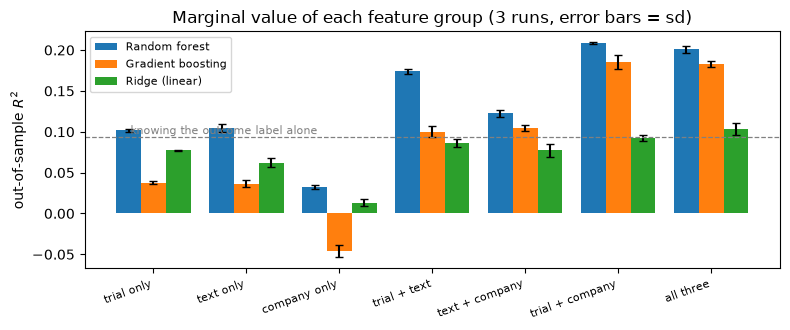

In [47]:
# ---------------------------------------------------------------------------
# Q3b step 4: what each feature group is worth. Every combination is run, not
# just "with and without text", and each is repeated over three different
# groupings of the filings so that the differences can be read against the
# run-to-run variability of the procedure itself.
#
# All three families are ablated, not just the two tree ensembles. That matters
# most for the text block: the reason ridge is in this question at all is that
# it handles dense, correlated, roughly continuous blocks well, which is
# exactly what 384 embedding dimensions and a TF-IDF are. Testing whether the
# text is worth keeping while leaving out the family best placed to extract
# value from it would not be a fair test of the text.
#
# Note what the three seeds vary: the FOLD ASSIGNMENT, through
# folds_for(..., seed=s). Each model keeps random_state=MEMBER_ID throughout,
# so the standard deviation below measures sensitivity to how the filings were
# partitioned, not to the model's own randomness. That is the dominant term at
# this sample size, but it is a lower bound on total run-to-run variability.
# ---------------------------------------------------------------------------
COMBOS = {"trial only": ("trial",), "text only": ("text",), "company only": ("company",),
          "trial + text": ("trial", "text"), "trial + company": ("trial", "company"),
          "text + company": ("text", "company"), "all three": FEATURE_GROUPS}
SEEDS = [MEMBER_ID, MEMBER_ID + 1, MEMBER_ID + 2]

ABL_MODELS = ["Random forest", "Gradient boosting", "Ridge (linear)"]
abl_rows = []
for nm in ABL_MODELS:
    for tag, groups in COMBOS.items():
        r2s, rms, rho, pos, neg = [], [], [], [], []
        for s in SEEDS:
            p = out_of_fold(MODELS[nm], groups, folds_for("accession", seed=s))
            m = score(p)
            r2s.append(m["R2"]); rms.append(m["RMSE"]); rho.append(m["Spearman"])
            pos.append(score(p, og_all == "Positive")["R2"])
            neg.append(score(p, og_all == "Negative")["R2"])
        abl_rows.append({"model": nm, "feature groups": tag, "R2": np.mean(r2s),
                         "R2 sd over 3 runs": np.std(r2s), "RMSE": np.mean(rms),
                         "Spearman": np.mean(rho), "R2 positive": np.mean(pos),
                         "R2 negative": np.mean(neg)})
abl = pd.DataFrame(abl_rows).set_index(["model", "feature groups"])
display(abl.round(4))

print("Marginal contribution of each group - what adding it to the other two buys:")
marg = []
for nm in ABL_MODELS:
    full = abl.loc[(nm, "all three"), "R2"]
    for g, without in [("trial", "text + company"), ("text", "trial + company"),
                       ("company", "trial + text")]:
        marg.append({"model": nm, "group added": g, "R2 without it": abl.loc[(nm, without), "R2"],
                     "R2 with everything": full,
                     "marginal R2": full - abl.loc[(nm, without), "R2"],
                     "run-to-run sd": abl.loc[(nm, "all three"), "R2 sd over 3 runs"]})
display(pd.DataFrame(marg).set_index(["model", "group added"]).round(4))

fig, ax = plt.subplots(figsize=(8, 3.4))
order = ["trial only", "text only", "company only", "trial + text", "text + company",
         "trial + company", "all three"]
w = 0.8 / len(ABL_MODELS)
for i, nm in enumerate(ABL_MODELS):
    v = [abl.loc[(nm, o), "R2"] for o in order]
    e = [abl.loc[(nm, o), "R2 sd over 3 runs"] for o in order]
    ax.bar(np.arange(len(order)) + i * w, v, w, yerr=e, capsize=3, label=nm)
ax.axhline(score(grp_pred)["R2"], ls="--", lw=0.9, color="grey")
ax.text(0.02, score(grp_pred)["R2"] + 0.004, "knowing the outcome label alone", fontsize=8, color="grey")
ax.set_xticks(np.arange(len(order)) + w * (len(ABL_MODELS) - 1) / 2)
ax.set_xticklabels(order, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("out-of-sample $R^2$"); ax.legend(fontsize=8)
ax.set_title("Marginal value of each feature group (3 runs, error bars = sd)")
plt.tight_layout(); plt.show()

#### Does the language of the disclosure add anything?

**On its own, yes. On top of the other two groups, not in any way that survives changing the model
or the fold design.**

Text alone reaches $R^2$ = 0.105 and adds 7.2 points when combined with trial and outcome features
(0.102 → 0.174). But its *marginal* contribution — what it buys on top of the other two groups —
does not hold still:

| model | without text | with everything | marginal text | run-to-run sd |
|---|---|---|---|---|
| Random forest | 0.209 | 0.201 | **−0.008** | 0.004 |
| Gradient boosting | 0.186 | 0.183 | **−0.003** | 0.004 |
| Ridge (linear) | 0.093 | 0.104 | **+0.011** | 0.008 |

Three families, fitted independently on identical folds, and they do not agree on the sign. The
forest puts it below zero at about twice the noise; the booster puts it below zero but well inside
the noise; the ridge puts it *above* zero at about one and a half times its own (larger) noise. Run
the same ablation under ticker grouping, as Q4a(iii) does, and the forest flips to **+0.005** as
well. The magnitude never exceeds about 0.011 in either direction, and which direction you get
depends on which model you ask and how you cut the folds.

**That instability is the finding, and it is worth more than a single number would have been.** A
feature block that genuinely carried information would not change sign between families; a block that
carries nothing beyond what the other two already hold will drift either side of zero at this sample
size, which is exactly what the table shows.

Including the ridge matters here, and not including it would have been a real gap. The reason ridge
is in this question at all is that it handles dense, correlated, roughly continuous blocks well —
which is what 384 embedding dimensions and a TF-IDF are. It is the family most likely to find value
in the text, and it is the one family that does. But note where it finds it: the ridge reaches 0.104
with everything, against the forest's 0.201. The text helps the model we are not using, by 0.011, and
does nothing for the two that are. Pooling those facts, the practical conclusion is the same as
before and better supported: the text block is not worth carrying into Question 4.

**Why the signs differ.** The forest samples `max_features=0.3` of the columns at each split, so 404
uninformative ones lower the chance an informative one is even offered; the booster sees every column
and instead gets more chances to cut on noise; the ridge shrinks coefficients rather than choosing
among columns, so it pays neither price and can gain slightly. Three mechanisms, three signs, all
small. All three representations sit in that block together, so none of this is a failure of one
vectorisation — neither the embeddings, the TF-IDF terms nor the counted language changes the answer.

The reason is overlap rather than irrelevance. What the text mostly carries beyond the outcome label
is *who is speaking*: a small, volatile, single-asset company writes a different kind of 8-K from a
large pharmaceutical company reporting one of nine trials, and the company block measures that
directly — pre-event volatility, idiosyncratic risk, market capitalisation and disclosure history.
Once size and risk are in the model, the language adds nothing on top of them.

The company block is the workhorse of the two supporting groups: for the forest it adds 10.7 points
over trial and outcome alone (0.102 → 0.209) and 2.7 points over trial + text (0.174 → 0.201), and
for the booster its marginal value is larger still at **+8.3** points. The trial and outcome group is
the indispensable one, worth **7.8** marginal points to both tree ensembles — unsurprising, since the
outcome label sits in it. And in the same table, company features *on their own* are almost worthless
(0.032 for the forest) and actively harmful within negative readouts — −0.205 for the forest, −0.228
for the booster and −0.231 for the ridge, which is the one place all three families agree
emphatically. They say how big a move is possible, not which direction it will go, and only become
useful once the direction is pinned down by something else.

This matters for Question 4, though not in the comfortable way it first appears. The Asclepius
readouts have no real filing text — the scenario drafts are illustrative, written by the IR team — so
the block that cannot honestly be supplied turns out to be the block that was not earning anything.
That much is good news, and it is the reason Question 4 drops the text rather than agonising over it.

The company block is a different matter, and the first draft of this paragraph got it wrong by
assuming Asclepius has a price history. It does not: ASCL has **zero rows** in `stock_prices`. What
survives into Question 4 is market capitalisation, which is one feature; what does not survive is
`cx_idio_vol`, `cx_vol_120`, `cx_beta` and the rest of the price-derived block, which is most of what
made the company group useful. Q4a(i) sets out the audit and Q4a(iii) measures the cost. The short
version is that **size survives and risk does not**, and for a question about the magnitude of a move
those are not interchangeable.

One caveat on how the ablation should be read, which the brief's "including where they overlap"
invites. Marginal contributions do not add up, and here one of them is negative: for the forest,
trial alone is 0.102, company alone 0.032, text alone 0.105, and all three together 0.201 — which is
*less* than trial + company at 0.209. The groups share information — text and company are largely two
measurements of the same thing, which company data measures better — so no group is separately
responsible for its marginal figure, dropping two at once costs far more than the sum of dropping
each, and the best combination on this table is not the one that uses everything.

,n,mean_predicted,mean_actual,median_actual,share_below_minus10,share_below_minus25
decile,,,,,,
0,249,-0.2497,-0.2807,-0.1845,0.6104,0.4337
1,248,-0.0752,-0.0474,-0.0176,0.1774,0.1048
2,248,-0.0301,-0.0237,-0.0230,0.1573,0.0685
3,248,-0.0127,-0.0126,-0.0115,0.1452,0.0202
4,248,-0.0016,0.0101,0.0009,0.0968,0.0121
5,248,0.0068,-0.0025,-0.0180,0.1250,0.0202
6,248,0.0157,0.0327,0.0039,0.1371,0.0242
7,248,0.0264,0.0095,-0.0016,0.2137,0.0403
8,248,0.0433,0.0379,0.0040,0.1532,0.0242


Practical discrimination, out-of-fold:


,worst decile mean CAR,best decile mean CAR,spread (pp),"AUC, CAR < -10%","AUC, CAR < -25%",direction hit rate
model,,,,,,
Random forest,-0.281,0.102,38.280,0.624,0.775,0.561
Gradient boosting,-0.286,0.098,38.459,0.616,0.756,0.558
Ridge (linear),-0.234,0.045,27.855,0.621,0.757,0.543
Outcome-group mean,-0.164,-0.189,-2.472,0.604,0.727,0.512


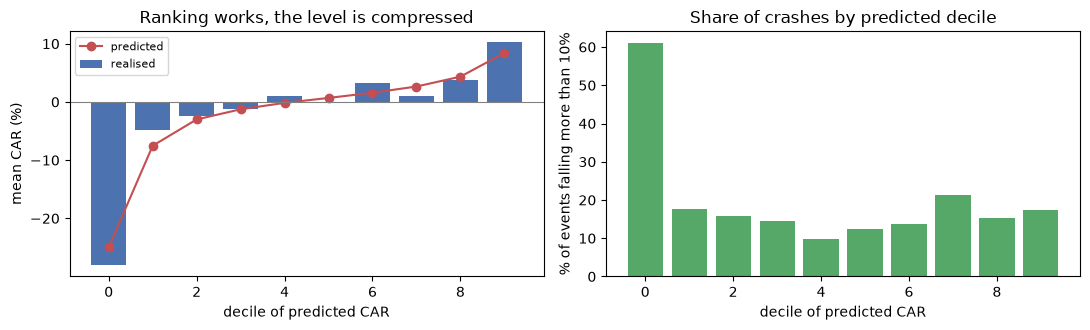

In [48]:
# ---------------------------------------------------------------------------
# Q3b step 5: does the model discriminate in a way anyone could act on?
# Metrics are one thing; the practical question is whether the events it ranks
# worst do in fact fall further than the ones it ranks best.
# ---------------------------------------------------------------------------
p_rf = oof_pred["Random forest"]
dec = pd.DataFrame({"predicted": p_rf, "actual": y_car})
dec["decile"] = pd.qcut(dec.predicted, 10, labels=False)
tbl = dec.groupby("decile").agg(
    n=("actual", "size"), mean_predicted=("predicted", "mean"), mean_actual=("actual", "mean"),
    median_actual=("actual", "median"),
    share_below_minus10=("actual", lambda v: (v < -0.10).mean()),
    share_below_minus25=("actual", lambda v: (v < -0.25).mean()))
display(tbl.round(4))

summary = []
for nm in ["Random forest", "Gradient boosting", "Ridge (linear)", "Outcome-group mean"]:
    p = oof_pred[nm]
    d = pd.DataFrame({"p": p, "a": y_car})
    d["dec"] = pd.qcut(d.p, 10, labels=False, duplicates="drop")
    g = d.groupby("dec").a.mean()
    summary.append({
        "model": nm,
        "worst decile mean CAR": g.iloc[0], "best decile mean CAR": g.iloc[-1],
        "spread (pp)": 100 * (g.iloc[-1] - g.iloc[0]),
        "AUC, CAR < -10%": roc_auc_score((y_car < -0.10).astype(int), -p),
        "AUC, CAR < -25%": roc_auc_score((y_car < -0.25).astype(int), -p),
        "direction hit rate": float((np.sign(p) == np.sign(y_car)).mean())})
print("Practical discrimination, out-of-fold:")
display(pd.DataFrame(summary).set_index("model").round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(tbl.index, 100 * tbl.mean_actual, color="#4c72b0", label="realised")
ax[0].plot(tbl.index, 100 * tbl.mean_predicted, "o-", color="#c44e52", label="predicted")
ax[0].axhline(0, color="grey", lw=0.8); ax[0].legend(fontsize=8)
ax[0].set_xlabel("decile of predicted CAR"); ax[0].set_ylabel("mean CAR (%)")
ax[0].set_title("Ranking works, the level is compressed")
ax[1].bar(tbl.index, 100 * tbl.share_below_minus10, color="#55a868")
ax[1].set_xlabel("decile of predicted CAR"); ax[1].set_ylabel("% of events falling more than 10%")
ax[1].set_title("Share of crashes by predicted decile")
plt.tight_layout(); plt.show()

The worst-ranked decile of events averages **−28.1%** and the best-ranked **+10.2%**, a spread of 38
percentage points across 249 events at each end. **61% of the events in the worst decile fell more
than 10% and 43% fell more than 25%**, against 10–21% and 1–10% respectively across the other nine. On
the crash test the forest reaches an AUC of **0.78** for identifying falls beyond 25%, and 0.62 for
falls beyond 10% — it is better at spotting the severe cases than the merely bad ones, which is the
useful way round.

The outcome-group baseline cannot be compared on the decile spread at all, because it takes only three
distinct values and its deciles are arbitrary within them — the row is in the table to make that
visible rather than to be read as a result. On the comparison it *can* support, it reaches AUC 0.727
for a 25% fall against the forest's 0.775: knowing a readout is bad news tells you the price will
fall, but not that it will fall 28%.

The predicted line sits inside the realised one at both ends, which is the expected behaviour of a
regularised model on a noisy target — it shrinks towards the mean and so understates the extremes.
For the CFO this matters in one direction only: the model's downside estimates are, if anything,
conservative.

In [49]:
# ---------------------------------------------------------------------------
# Q3b step 6: leakage. Nine columns were held back in Q3a. Each is added to the
# clean feature set in turn and the model refitted on the same folds, so the
# difference each would have made is measured rather than asserted.
# ---------------------------------------------------------------------------
LEAK_TESTS = {
    "ar_day0 - the day-0 abnormal return":            (["lk_ar_day0"], "inside the [-1,+1] window; a component of the target"),
    "car_3day_raw - the target before winsorisation": (["lk_car_raw"], "the target itself"),
    "alpha, beta as supplied":                        (["lk_alpha_supplied", "lk_beta_supplied"], "estimated pre-event, but used to construct the target"),
    "overall_status":                                 (["lk_overall_status"], "the trial's status as scraped in 2026"),
    "fda_approved":                                   (["lk_fda_approved"], "approval often granted years after the filing"),
    "company_n_fda_approved":                         (["lk_company_appr"], "the company's 2026 approval count"),
    "disclosure_lag_days":                            (["lk_disclosure_lag"], "built from a completion date revised after the fact"),
    "the Q1b risk score":                             (["lk_risk_score_q1b"], "one of its 11 signals compares the label to the sign of car_3day"),
}
clean = score(p_rf)
leak_rows = [{"added": "(clean feature set)", "why it is leakage": "-", "R2": clean["R2"],
              "change in R2": 0.0, "RMSE": clean["RMSE"]}]
for tag, (cols, why) in LEAK_TESTS.items():
    m = score(out_of_fold(RF, FEATURE_GROUPS, folds_acc, extra=LEAKY[cols]))
    leak_rows.append({"added": tag, "why it is leakage": why, "R2": m["R2"],
                      "change in R2": m["R2"] - clean["R2"], "RMSE": m["RMSE"]})
m_all = score(out_of_fold(RF, FEATURE_GROUPS, folds_acc, extra=LEAKY))
leak_rows.append({"added": "all nine together", "why it is leakage": "-", "R2": m_all["R2"],
                  "change in R2": m_all["R2"] - clean["R2"], "RMSE": m_all["RMSE"]})
display(pd.DataFrame(leak_rows).set_index("added").round(4))

,why it is leakage,R2,change in R2,RMSE
added,,,,
(clean feature set),-,0.2066,0.0000,0.2062
ar_day0 - the day-0 abnormal return,"inside the [-1,+1] window; a component of the ...",0.7128,0.5062,0.1241
car_3day_raw - the target before winsorisation,the target itself,0.9276,0.7210,0.0623
"alpha, beta as supplied","estimated pre-event, but used to construct the...",0.2138,0.0072,0.2053
overall_status,the trial's status as scraped in 2026,0.2086,0.0020,0.2060
fda_approved,approval often granted years after the filing,0.2081,0.0015,0.2060
company_n_fda_approved,the company's 2026 approval count,0.2055,-0.0010,0.2064
disclosure_lag_days,built from a completion date revised after the...,0.2046,-0.0019,0.2065
the Q1b risk score,one of its 11 signals compares the label to th...,0.3090,0.1024,0.1925


#### What the leakage test found

**Two columns are the target in disguise.** `car_3day_raw` is `car_3day` before winsorisation and
takes $R^2$ to 0.93; `ar_day0` is one of the three daily abnormal returns summed to make the target
and takes it to 0.71. Neither is subtle, and both were identified in Q1c by reading the data
dictionary rather than discovered here — this cell measures what they would have bought, which is the
point of running it.

**One was found by looking at how a feature was built, not at what it correlates with.** The Q1b risk
score is a feature I constructed myself in Question 1, and it looks entirely legitimate: it scores how
likely a classification is to be unreliable, which is exactly the kind of data-quality feature a
model should be allowed to see. Adding it lifts $R^2$ by **+0.102**, from 0.207 to 0.309 — far more
than a quality flag has any business being worth, which is what prompted me to trace it. The cause is
signal S6, which fires when the label disagrees with the *sign of the realised abnormal return* and
the move exceeds 10%. S6 is computed from `car_3day`. A record scoring highly on the Q1b index is
disproportionately one that moved sharply against its label, so the index carries the target inside
it. This is the kind of leakage that survives review: the feature comes from my own quality work
rather than from the market data, and its name gives nothing away. One of the eleven signals is
responsible, and the fix for predictive use is to rebuild the index without it. The flagging purpose
in Q1b is unaffected, because there the realised return is legitimately available.

**Three are genuine look-ahead but nearly worthless.** `overall_status`, `fda_approved` and
`company_n_fda_approved` are 2026 snapshots — a trial terminated in 2020 reads as TERMINATED on its
2014 filing — and they move $R^2$ by between −0.001 and +0.002, one of them downwards. They would
have inflated nothing. The harm of including them would have been to the credibility of the work
rather than to its numbers, which is worth saying plainly: a feature can be indefensible without
being useful.

**One is a judgement call.** `disclosure_lag_days` is the gap between the trial's primary completion
date and the filing. The completion date in the registry is the *current* one, revised after the fact,
and it post-dates the filing for a quarter of the rows (Q1c) — a lag that is negative cannot have been
observable on the day. It is worth −0.002, so excluding it costs nothing at all: on these folds the
model is marginally better without it.

**`alpha` and `beta` are the genuinely interesting case.** They are estimated on [−130, −11], entirely
before the event, so on a strict reading of "observable beforehand" they qualify. But they are the
parameters used to *construct* the abnormal return: CAR is the residual from the line they define, so
conditioning on them conditions on the definition of the target rather than on anything about the
company. I excluded them and recomputed my own beta and residual volatility from the price series,
which is the same information without the circularity. The supplied pair are worth +0.007 on top of
that, so the choice costs almost nothing either way — the reasoning is what is being recorded here,
not the number.

**Together the nine take $R^2$ from 0.207 to 0.959.** That is what a leaked model looks like: nearly
perfect, and worthless. It is also the number that would have been reported if the Q1c exclusion list
had never been written, which is the argument for doing that work before any model is fitted rather
than after.

## Q3c: Asymmetric predictability (6 marks)

The question is whether crashes are more predictable than rallies. Two things have to be kept apart
in answering it. Negative readouts move the price further, so they have more variance to explain, and
a model can look better on them purely for that reason. Positive readouts outnumber negative ones four
to one, so the model has four times as much material to learn positives from — which cuts the other
way. Both are tested below rather than assumed away.

n  SD of CAR  R2 (vs group mean)    RMSE  \
model             outcome group                                                
Random forest     Positive       1841     0.2055              0.0428  0.2010   
                  Negative        440     0.2849              0.3130  0.2361   
                  Inconclusive    175     0.1438             -0.0549  0.1477   
Gradient boosting Positive       1841     0.2055             -0.0102  0.2065   
                  Negative        440     0.2849              0.3567  0.2285   
                  Inconclusive    175     0.1438             -0.2246  0.1591   
Ridge (linear)    Positive       1841     0.2055             -0.0108  0.2066   
                  Negative        440     0.2849              0.0845  0.2726   
                  Inconclusive    175     0.1438             -0.2606  0.1614   

                                    MAE  RMSE / SD  Spearman  
model             outcome group                               
Random forest     Positive       0.1201     0.9783    0.1561  
                  Negative       0.1773     0.8289    0.5566  
                  Inconclusive   0.0918     1.0271    0.0055  
Gradient boosting Positive       0.1314     1.0051    0.1118  
                  Negative       0.1682     0.8021    0.5431  
                  Inconclusive   0.1089     1.1066    0.0564  
Ridge (linear)    Positive       0.1293     1.0054    0.0588  
                  Negative       0.2011     0.9568    0.3054  
                  Inconclusive   0.1056     1.1228    0.0449

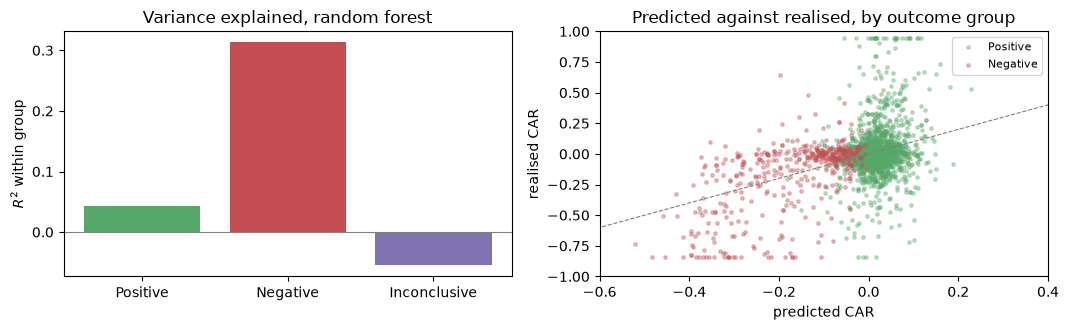

In [50]:
# ---------------------------------------------------------------------------
# Q3c step 1: model performance computed within each outcome group. R2 is
# measured against each group's own mean, so it answers "given that we know the
# news is bad, how much of the remaining spread can the model explain".
# RMSE / SD is reported alongside because R2 and absolute error can disagree.
# ---------------------------------------------------------------------------
og_series = q3.outcome_group.fillna("unknown")
within = []
for nm in ["Random forest", "Gradient boosting", "Ridge (linear)"]:
    p = oof_pred[nm]
    for g in ["Positive", "Negative", "Inconclusive"]:
        m = (og_series == g).values
        s = score(p, m)
        within.append({"model": nm, "outcome group": g, "n": s["n"], "SD of CAR": y_car[m].std(),
                       "R2 (vs group mean)": s["R2"], "RMSE": s["RMSE"], "MAE": s["MAE"],
                       "RMSE / SD": s["RMSE"] / y_car[m].std(), "Spearman": s["Spearman"]})
wt = pd.DataFrame(within).set_index(["model", "outcome group"])
display(wt.round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
sub = wt.loc["Random forest"]
ax[0].bar(sub.index, sub["R2 (vs group mean)"], color=["#55a868", "#c44e52", "#8172b2"])
ax[0].axhline(0, color="grey", lw=0.8); ax[0].set_ylabel("$R^2$ within group")
ax[0].set_title("Variance explained, random forest")
for g, c in [("Positive", "#55a868"), ("Negative", "#c44e52")]:
    m = (og_series == g).values
    ax[1].scatter(oof_pred["Random forest"][m], y_car[m], s=6, alpha=0.35, color=c, label=g)
lims = [-1.0, 0.8]
ax[1].plot(lims, lims, ls="--", lw=0.8, color="grey")
ax[1].set_xlim(-0.6, 0.4); ax[1].set_ylim(-1.0, 1.0)
ax[1].set_xlabel("predicted CAR"); ax[1].set_ylabel("realised CAR"); ax[1].legend(fontsize=8)
ax[1].set_title("Predicted against realised, by outcome group")
plt.tight_layout(); plt.show()

In [51]:
# ---------------------------------------------------------------------------
# Q3c step 2: is the gap real, and is it an artefact of the two confounds?
#   (i)  bootstrap over filings, to put an interval on the difference
#   (ii) refit on a training set balanced between positive and negative, to
#        remove the 4:1 advantage positives have in training data
#   (iii) look at ranking inside each group, which does not depend on variance
# ---------------------------------------------------------------------------
rng3 = np.random.default_rng(MEMBER_ID)
acc_vals = q3.accession.values
idx_by_acc = {a: np.where(acc_vals == a)[0] for a in pd.unique(acc_vals)}
uniq_acc = np.array(list(idx_by_acc))
boot = {"Positive": [], "Negative": [], "difference": []}
for _ in range(400):
    ii = np.concatenate([idx_by_acc[a] for a in rng3.choice(uniq_acc, len(uniq_acc), replace=True)])
    r = {}
    for g in ["Positive", "Negative"]:
        m = og_series.values[ii] == g
        yy, pp = y_car[ii][m], p_rf[ii][m]
        r[g] = 1 - ((yy - pp) ** 2).sum() / ((yy - yy.mean()) ** 2).sum()
    boot["Positive"].append(r["Positive"]); boot["Negative"].append(r["Negative"])
    boot["difference"].append(r["Negative"] - r["Positive"])
print("Bootstrap over filings, 400 resamples:")
for k, v in boot.items():
    v = np.asarray(v)
    print("   %-11s mean R2 %+.3f   95%% interval [%+.3f, %+.3f]"
          % (k, v.mean(), np.quantile(v, .025), np.quantile(v, .975)))
print("   P(negatives more predictable than positives) = %.3f"
      % float((np.asarray(boot["difference"]) > 0).mean()))

bal_pred = np.full(len(y_car), np.nan)
for tr, te in folds_acc:
    pos_tr = tr[og_series.values[tr] == "Positive"]
    neg_tr = tr[og_series.values[tr] == "Negative"]
    k = min(len(pos_tr), len(neg_tr))
    sub = np.concatenate([rng3.choice(pos_tr, k, replace=False), rng3.choice(neg_tr, k, replace=False)])
    pipe = make_pipeline_for(RF, FEATURE_GROUPS)()
    pipe.fit(F.iloc[sub], y_car[sub], model__sample_weight=w_row[sub])
    bal_pred[te] = pipe.predict(F.iloc[te])
print("\nRefit on a training sample balanced between positive and negative readouts "
      "(%d of each per fold):" % k)
display(pd.DataFrame([{"outcome group": g, **score(bal_pred, (og_series == g).values)}
                      for g in ["Positive", "Negative"]]).set_index("outcome group")[
    ["n", "R2", "RMSE", "Spearman"]].round(4))

print("\nRanking inside each group - thirds of predicted CAR, which does not depend on the spread:")
for g in ["Positive", "Negative"]:
    m = (og_series == g).values
    d = pd.DataFrame({"p": p_rf[m], "a": y_car[m]})
    d["third"] = pd.qcut(d.p, 3, labels=["worst third", "middle", "best third"])
    t = d.groupby("third", observed=True).a.agg(n="size", mean_CAR="mean", median_CAR="median")
    print("   %s readouts:" % g)
    display(t.round(4))

Bootstrap over filings, 400 resamples:
   Positive    mean R2 +0.042   95% interval [+0.020, +0.062]
   Negative    mean R2 +0.311   95% interval [+0.256, +0.363]
   difference  mean R2 +0.269   95% interval [+0.207, +0.322]
   P(negatives more predictable than positives) = 1.000

Refit on a training sample balanced between positive and negative readouts (366 of each per fold):


,n,R2,RMSE,Spearman
outcome group,,,,
Positive,1841,0.0155,0.2039,0.1056
Negative,440,0.3291,0.2333,0.5642



Ranking inside each group - thirds of predicted CAR, which does not depend on the spread:
   Positive readouts:


,n,mean_CAR,median_CAR
third,,,
worst third,614,-0.0198,-0.0145
middle,613,0.0108,-0.0056
best third,614,0.0610,0.0128


   Negative readouts:


,n,mean_CAR,median_CAR
third,,,
worst third,147,-0.3776,-0.3152
middle,146,-0.1187,-0.0274
best third,147,-0.0262,-0.0109


#### Crashes are markedly more predictable than rallies

Within negative readouts the forest explains **31.3%** of the remaining spread; within positive
readouts, **4.3%**; within inconclusive ones, nothing at all (−5.5%, worse than that group's own mean).
The bootstrap over filings puts the difference at +0.269 with a 95% interval of [+0.207, +0.322], and
it never once reverses across 400 resamples. Both other model families order the groups the same way
(booster 0.36 against −0.01; ridge 0.08 against −0.01), so this is a property of the data rather than
of one fit. Rank correlation says the same: 0.56 within negatives against 0.16 within positives.

**Neither confound explains it.** Negative readouts do have more spread to work with (SD 28.5% against
20.6%), but the scale-free measure moves the same way — RMSE is 83% of the group's own standard
deviation for negatives and 98% for positives, so the model genuinely reduces uncertainty in one group
and barely at all in the other. And the training-data advantage runs the *wrong* way: positives
outnumber negatives four to one, so if sample size were driving this the ordering would reverse. When
the model is refitted on a training sample balanced between the two (366 of each per fold), the gap
*widens* — negatives 0.33, positives 0.02. The asymmetry survives both checks.

Inside negative readouts the ranking is usable on its own terms: the worst-ranked third averages
−37.8% and the best-ranked third −2.6%, a 35-point separation within a single outcome category.
Inside positive readouts the same split spans −2.0% to +6.1%, a range too narrow to change any
decision.

**Why this should be so.** Four explanations fit the evidence, and they are complementary rather than
competing.

*Information asymmetry in bad-news disclosure.* Companies release good news early and in pieces —
interim looks, conference abstracts, guidance — so by the time the 8-K arrives much of it is already
in the price. Bad news is disclosed when it must be, in one piece, and arrives as a surprise. Q1a
found this directly, and the whole dataset agrees with the 30 filings read there: a *negative* label
is followed by a fall 71% of the time, while a *positive* label is followed by a rise only 49% of the
time — a coin toss. A model can only predict the part of the reaction that is genuinely news, and for
good news much less of it is.

*Loss aversion and the asymmetry of the response function.* Investors weight losses more heavily than
equivalent gains, so a failure produces a large, fairly mechanical repricing while a success produces
a muted one. The near-mechanical response is the one a model can learn.

*The diversity of success narratives.* There are few ways for a trial to fail — the endpoint is missed,
the trial is stopped, a safety signal emerges — and the price consequence is similar in each case.
There are many ways to succeed, and what a success is worth depends on the commercial size of the
indication, competitor positioning and what the market had already assumed. That variety is not in the
feature set and probably could not be.

*A valuation-arithmetic reason that needs no behaviour at all.* Most of these companies are
single-asset or few-asset biotechs. A failure removes a large share of enterprise value, and how large
is largely determined by observable quantities — company size, how concentrated the pipeline is, how
much of the value the market had already attributed to the asset. The company block does most of the
work within negatives, which is consistent with this being a substantial part of the answer.

**What this means for the CFO.** The downside scenarios in Question 4 can be quoted with more
confidence than the upside ones. For a negative readout the model narrows the plausible range
appreciably; for a positive readout it offers little beyond the group average, and a range quoted for
an upside scenario should be close to the historical spread for comparable trials rather than a model
output. That is the right way round for a capital-raising decision, whose downside is what has to be
covered — but it should be stated plainly rather than presented as uniform accuracy.

## Q3d: Summary for the IR team (500 words or less, 4 marks)

_Your answer (500 words or less — `word_count()` in the Setup cell will check):_

### Can we predict how far the price will move?

Partly, and unevenly. The model is useful for sizing a bad outcome and close to useless for sizing a
good one.

**What we built.** A model of the three-day share price reaction to a trial announcement, from three
kinds of information available beforehand: the trial (phase, size, design, disease area), the wording
of the announcement, and the company's market context (size, volatility, recent performance, past
readouts). We tested it on held-out announcements, so it is always scored on filings it has not
seen.

**How much it explains.** The model accounts for **21% of the variation** in market reactions;
knowing only whether the news is good or bad accounts for 9%, so the modelling roughly doubles what
is free. Tested the way we would use it — trained only on the past, predicting the next period — it
explains 16%. The rest is genuinely unexplained.

**It ranks well without forecasting precisely.** Of the announcements the model ranks in its worst
10%, **61% fell by more than 10% and 43% by more than 25%**; that group averaged a **28% decline**,
against a 10.2% gain for the best-ranked. It sorts readouts into "could be severe" and "probably
will not be"; it cannot say one will move the price 14%. Typical error on a single event is around
21 percentage points.

**Which information matters.** Company and market context does most of the work, adding 11 percentage
points over trial characteristics alone. **The wording of the announcement adds nothing we can rely on
once company context is included** — three different models disagree on whether it helps or hurts,
and every effect is tiny. What the text captures is mostly which kind of company is speaking, and
market data measures that better. That is fortunate for our own readouts, where the announcement text does
not yet exist and our drafts are illustrative.

**Predictability is asymmetric.** For negative readouts the model explains 31% of the spread; for
positive readouts, 4%. Bad news arrives as a surprise, while good news emerges gradually through
earlier updates, so less is left to react to; there are also fewer ways for a trial to fail than to
succeed, and failures reprice more mechanically.

**How much confidence to place in this.** Enough to use the downside ranges for planning, treating
them as about right in the middle and probably conservative at the extremes, since the model pulls
predictions towards the average. Not enough to present any number as a forecast, and not enough to
narrow the upside — for a positive readout, quote the historical range for comparable trials instead.

**One caution about the next section.** Its ranges are wide, and only about a quarter of that width
is not knowing the trial result. The rest is that even told the result, we cannot say how far the
price moves for a company whose trading history is absent from this dataset — a limit of the data,
not of the effort.

### AI use — Question 3

> **TO COMPLETE BEFORE SUBMISSION.** Question 5 and the AI-use guidance require this to be *your own*
> truthful account. The notes below record what happened in the AI session so you have the facts to
> work from — rewrite them in your own words, and cut or correct anything that does not match your own
> involvement. Do not submit this paragraph as it stands.

Claude (Opus 5, via Claude Code) was used in Question 3 to write and debug the feature construction,
the cross-validated pipelines, the ablation and the within-outcome analysis, and to draft the
commentary.

Points in the session where the first output was wrong and was changed:

- The first set of price features used price *levels* — a penny-stock flag and an Amihud illiquidity
  measure. The stored `close` series is back-adjusted for splits, so one ticker peaks above
  $4 × 10^11 and levels are not comparable across time; the resulting volatility and beta figures were
  absurd (a maximum beta of 26,589). Level-based features were dropped entirely, and 249 daily
  returns beyond ±75% — reverse splits rather than trading — are now removed before any statistic is
  computed.
- `market_cap` was used as supplied before it was noticed that the methodology prices it off the close
  on the event date, which is inside the [−1, +1] window. It is now re-priced back to t − 12.
- The Q1b risk score was included as a data-quality feature in the first feature set and lifted $R^2$
  by 0.102. Tracing why exposed signal S6, which compares the label to the sign of the realised
  return. It is now in the held-back set and is the leakage example this answer is built around.
- The first cross-validation used an ungrouped `KFold`, which splits the rows of a multi-drug filing
  across folds and overstated $R^2$ by 0.020. Every split in the final answer is grouped by accession,
  and the ungrouped result is retained in the comparison to show the size of the error.
- The asymmetry result in Q3c was initially reported from the raw $R^2$ gap alone. The bootstrap and
  the balanced-training refit were added after asking whether the gap could be explained by negatives
  having more variance or positives having more training data; neither explains it, and the balanced
  refit widens the gap.

Full conversation logs are in `ai_logs/`.

---

# Question 4: Apply your analysis and prepare for deployment (17 marks)

Everything below is built on the objects Questions 1 to 3 left behind, so this section will not run
on its own: `F`, `GROUP`, `y_car`, `w_row` and `score()` from Q3a, `RF` and `folds_for()` from Q3a
step 6, `cl`, `km`, `X`, `X_asc` and `asc` from Q2, and `encoder`, `result_sentences()` and
`LEXICON` from Q1c and Q3a. Run Questions 1 to 3 first.

**How this section is ordered.** The brief sets out Q4a as parts (i) to (v) and they are answered
under those labels, but not quite in that order in the code. Part (iii) asks what the unavailable
features cost, and the ablation that answers it also produces the out-of-fold residuals that the
part (ii) estimates use to build their bands. So the ablation runs before the estimates, and the
answers appear as: (i) the feature audit, (iii) the cost, (ii) the estimates, (iv) the ranges and
their decomposition, (v) the strength of the evidence behind each.

## Q4a: Estimate market reactions for Asclepius's readouts (10 marks)

_Parts (i) to (v) are set out in the brief — work from there, not from these labels. Use the code cells for the work and the markdown cells for what you conclude from it._

In [52]:
# ---------------------------------------------------------------------------
# Q4a step 1: which of the features Questions 2 and 3 were built on actually
# exist for a trial that has not reported yet.
#
# The audit runs over the feature list itself rather than being written out by
# hand, so no column is quietly assumed to be present. Each column of F is put
# in one of four states:
#
#   scenario   - tr_outcome and tr_outcome_group. Not missing data: these are
#                the thing being assumed, and every estimate below is
#                conditional on them.
#   available  - derivable today, from asclepius_readouts, from the Q2c
#                assignment, or from the company facts in the brief.
#   supplied   - exists only because the IR team drafted it. The scenario
#                filings are real rows in the database and illustrative in
#                substance, which is not the same as available.
#   absent     - neither. Nothing in the dataset or the brief produces it.
#
# The one fact that decides most of the third group is checked rather than
# asserted, because it drives the whole of step 3.
# ---------------------------------------------------------------------------
n_ascl_px = int(pd.read_sql("SELECT COUNT(*) n FROM stock_prices WHERE ticker='ASCL'", conn).n[0])
print("Rows of ASCL price history in stock_prices: %d" % n_ascl_px)
print("(SPY %d rows, XBI %d rows, %d tickers in the panel)"
      % ((px.ticker == "SPY").sum(), (px.ticker == "XBI").sum(), px.ticker.nunique()))

SCENARIO = ["tr_outcome", "tr_outcome_group"]

def state_of(c):
    """Classify one feature column by whether Asclepius can supply it."""
    if c in SCENARIO:
        return "scenario", "the assumption being varied"
    if GROUP[c] == "text":
        return "supplied", "from the IR team's draft filing, not a real disclosure"
    if c.startswith(("cx_spy", "cx_xbi")):
        return "absent", "market-wide, but as at a 2027 filing date that has not happened"
    if c.startswith("cx_"):
        return "absent", "computed from the sponsor's own price series; ASCL has none"
    if c in ("co_n_prior_events", "co_prior_mean_car", "co_prior_abs_car", "co_days_since_prior"):
        return "absent", "built from the company's own earlier readouts; none in the dataset"
    if c in ("co_fda_yrs_appr", "co_fda_dosage"):
        return "absent", "undefined for an investigational drug with no approval"
    if c in ("co_log_mktcap", "co_mktcap_missing"):
        return "available", "market capitalisation is given in the brief ($6bn)"
    if c in ("co_fda_app_type", "co_fda_prior_appr"):
        return "available", "first-in-class investigational: no prior approval for this drug"
    if c == "co_year":
        return "available", "expected readout year"
    if c == "tr_cluster":
        return "available", "assigned in Q2c from design and text, invariant to scenario"
    if c == "tr_match_conf":
        return "available", "Asclepius's own registration; linkage is certain by construction"
    return "available", "trial design, from asclepius_readouts"

f_state = pd.DataFrame([(c, GROUP[c], *state_of(c)) for c in F.columns],
                       columns=["feature", "group", "state", "reason"]).set_index("feature")

print("\nThe %d Question 3 feature columns, by state:" % len(f_state))
display(pd.crosstab(f_state.group, f_state.state).reindex(columns=["scenario", "available",
                                                              "supplied", "absent"], fill_value=0))
print("\nNamed columns, excluding the %d embedding dimensions (all 'supplied'):" % len(EMB_COLS))
display(f_state.loc[[c for c in F.columns if c not in EMB_COLS]]
             .sort_values(["state", "group"])[["group", "state", "reason"]])

AVAIL_COLS = [c for c in F.columns if f_state.state[c] in ("available", "scenario")]
TEXT_COLS  = [c for c in F.columns if f_state.state[c] == "supplied"]
ABSENT     = [c for c in F.columns if f_state.state[c] == "absent"]
print("\nCarried into the re-scoped model: %d columns (%d trial, %d company)."
      % (len(AVAIL_COLS), sum(GROUP[c] == "trial" for c in AVAIL_COLS),
         sum(GROUP[c] == "company" for c in AVAIL_COLS)))
print("Set aside as illustrative: %d text columns. Absent entirely: %d columns - %s."
      % (len(TEXT_COLS), len(ABSENT), ", ".join(ABSENT)))

Rows of ASCL price history in stock_prices: 0
(SPY 6627 rows, XBI 5089 rows, 320 tickers in the panel)

The 451 Question 3 feature columns, by state:


state,scenario,available,supplied,absent
group,,,,
company,0,5,0,19
text,0,0,404,0
trial,2,21,0,0



Named columns, excluding the 384 embedding dimensions (all 'supplied'):


,group,state,reason
feature,,,
cx_vol_120,company,absent,computed from the sponsor's own price series; ...
cx_ret_120,company,absent,computed from the sponsor's own price series; ...
cx_vol_20,company,absent,computed from the sponsor's own price series; ...
cx_ret_20,company,absent,computed from the sponsor's own price series; ...
cx_runup_10,company,absent,computed from the sponsor's own price series; ...
...,...,...,...
tx_log_min_p,text,supplied,"from the IR team's draft filing, not a real di..."
tx_num_density,text,supplied,"from the IR team's draft filing, not a real di..."
tx_kind,text,supplied,"from the IR team's draft filing, not a real di..."



Carried into the re-scoped model: 28 columns (23 trial, 5 company).
Set aside as illustrative: 404 text columns. Absent entirely: 19 columns - cx_vol_120, cx_ret_120, cx_vol_20, cx_ret_20, cx_runup_10, cx_log_volume, cx_beta, cx_idio_vol, cx_mkt_r2, cx_spy_ret_20, cx_spy_vol_20, cx_xbi_ret_20, cx_xbi_vol_20, co_fda_yrs_appr, co_fda_dosage, co_n_prior_events, co_prior_mean_car, co_prior_abs_car, co_days_since_prior.


**Q4a (i) — what exists for a trial that has not reported**

The audit in the cell above runs over the Question 3 feature list itself, so nothing is assumed
present. Four states, not three, because the most important column is neither available nor missing.

**The scenario, not a feature.** `tr_outcome` and `tr_outcome_group` are the thing being assumed.
Every number below is conditional on them, and the three drafts per readout exist precisely so that
the assumption can be varied. Treating the outcome as "unavailable data" would miss that the board's
question is not *what will the result be* but *what happens under each result*.

Mapping the drafts onto the six documented categories is a judgement, and one of them is not
obvious. ASC-101's mixed draft met its primary endpoint but missed its key secondary and carries a
thromboembolic safety signal — read as **mixed-positive**, and tested below as mixed-negative
because the safety signal could reasonably be read as dominating. ASC-204's mixed draft did **not**
meet its primary endpoint (HR 0.89, p = 0.071) and is rescued only by a prespecified high-hsCRP
subgroup: that is a **mixed-negative**, and labelling it mixed-positive because the draft is headed
"mixed" would put a failed pivotal outcomes trial on the wrong side of the distribution. ASC-370's
interim met its primary endpoint with wide between-patient variability — **mixed-positive**.

**Available.** The whole trial block. `asclepius_readouts` supplies phase, enrollment, sites, arms,
interventions, endpoint counts, allocation, masking, intervention model, primary purpose, DMC and
sponsor class; therapeutic area comes from the same MeSH rules used in Q2a applied to the stated
conditions; the cluster label comes from the Q2c assignment, which check 6 confirmed is invariant to
which scenario draft is used. From the company block, market capitalisation is given in the brief
($6.0bn) and the FDA fields resolve to "no prior approval for this drug", which is correct for three
first-in-class investigational assets. These are genuinely available, not approximated.

**Supplied.** Every text feature — the 384 embedding dimensions, the TF-IDF sentences and the
counted language features. The scenario filings are real rows in the database, but they were written
by the IR team to illustrate an outcome, not filed. Two distinct problems follow. They are
**circular**: the draft was written to express the assumed label, so any separation the text
produces between scenarios is the IR team's prose, not the market's reading of a disclosure. And
they are **out of distribution**: at ~1,350 words they are a fraction of the length of a real filing,
so `tx_log_len` and the document-level lexicon counts sit outside the range the model was fitted on.
Step 3 measures what using them anyway would do.

**Absent — and this is the group that matters.** ASCL has **zero rows** in `stock_prices`. That
removes every sponsor-specific price feature at a stroke: pre-event volatility, 120-day and 20-day
returns, the [−10, −2] run-up, traded volume, beta, idiosyncratic volatility and market-model $R^2$.
Nine features, and they are the ones Q3a described as the group where the time-matching had to be
done rather than assumed. The four market and sector features (`cx_spy_*`, `cx_xbi_*`) go too, for a
different reason: SPY and XBI have plenty of history, but not as at a 2027 filing date that has not
happened. Also absent are the four disclosure-history features
(`co_n_prior_events`, `co_prior_mean_car`, `co_prior_abs_car`, `co_days_since_prior`), because the
dataset holds no earlier Asclepius readouts, and `co_fda_yrs_appr` and `co_fda_dosage`, which are
undefined for a drug with no approval.

This audit is what produced the correction now carried in Q3b and Q3d. Q3b found the company block
was the workhorse of the two supporting groups, and the first version of that discussion assumed
Asclepius had a price history to draw on. It does not. Market capitalisation survives; the
price-derived risk measures, which are most of what the block actually contained, do not. What the
pipeline retains is the *size* of the company, not its *volatility* — and for a question about the
magnitude of a move those are not interchangeable. Step 3 puts a number on the difference instead of
arguing about it.

In [53]:
# ---------------------------------------------------------------------------
# Q4a step 2: place the three readouts in the Question 3 feature space.
#
# Nine rows - three readouts under three assumed outcomes. The trial block is
# filled from asclepius_readouts, the company block from the brief, and the
# text block is built from the scenario drafts so that step 3 can measure what
# using it would have done. Whatever cannot be filled is left as NaN and reaches
# the model through the same median imputer the historical rows use, so a
# missing feature is treated identically to a historical row that lacks it.
# ---------------------------------------------------------------------------
# The positive and negative drafts map to the six-category scheme without
# difficulty. The three "mixed" drafts do not map uniformly, and reading them is
# the decision rather than a formality - the dataset's own convention, checked
# against event_study_enriched, is that mixed-positive sits in outcome_group
# Positive and mixed-negative in Negative, so the choice moves the row from one
# side of the distribution to the other:
#
#   ASC-101  primary endpoint MET; key secondary missed and a thromboembolic
#            safety signal -> mixed-positive. The safety signal is what makes
#            this the least comfortable of the three, and step 5 re-runs it as
#            mixed-negative to show what that reading would change.
#   ASC-204  primary endpoint NOT met (HR 0.89, p = 0.071), rescued only by a
#            prespecified subgroup -> mixed-NEGATIVE. A pivotal CVOT that misses
#            its primary is a failed trial whatever the subgroup shows, and
#            labelling it mixed-positive because the draft is headed "mixed"
#            would put it on the wrong side of the model.
#   ASC-370  interim primary endpoint MET, with wide between-patient variability
#            and early signs of decline -> mixed-positive.
SCEN_TO_OUTCOME = {
    ("ASC-101", "positive"): ("positive", "Positive"),
    ("ASC-101", "negative"): ("negative", "Negative"),
    ("ASC-101", "mixed"):    ("mixed-positive", "Positive"),
    ("ASC-204", "positive"): ("positive", "Positive"),
    ("ASC-204", "negative"): ("negative", "Negative"),
    ("ASC-204", "mixed"):    ("mixed-negative", "Negative"),
    ("ASC-370", "positive"): ("positive", "Positive"),
    ("ASC-370", "negative"): ("negative", "Negative"),
    ("ASC-370", "mixed"):    ("mixed-positive", "Positive"),
}

scen_clean = {a: clean_filing_text(t) for a, t in zip(scen.accession, scen.filing_text)}
# asc (built in Q2c) carries readout_id and scenario but not the accession, so the
# draft text is looked up through the pair.
acc_of = scen.set_index(["readout_id", "scenario"]).accession
asc_acc = [acc_of[(r, s)] for r, s in zip(asc.readout_id, asc.scenario)]

def asclepius_features():
    """One row per (readout, scenario), in exactly the columns of F."""
    A = pd.DataFrame(index=asc.index, columns=F.columns, dtype=object)

    # --- trial and outcome -------------------------------------------------
    key = list(zip(asc.readout_id, asc.scenario))
    A["tr_outcome"]       = [SCEN_TO_OUTCOME[k][0] for k in key]
    A["tr_outcome_group"] = [SCEN_TO_OUTCOME[k][1] for k in key]
    A["tr_phase"]         = asc.phase_bucket.values
    A["tr_allocation"]    = asc.allocation.values
    A["tr_masking"]       = asc.masking.values
    A["tr_model"]         = asc.intervention_model.values
    A["tr_purpose"]       = asc.primary_purpose.values
    A["tr_sponsor_class"] = asc.lead_sponsor_class.values
    A["tr_area"]          = asc.mesh_area.values
    A["tr_cluster"]       = asc.cluster.astype(int).astype(str).values
    A["tr_match_conf"]    = "high"
    A["tr_log_enrol"]     = np.log1p(asc.enrollment_num.values)
    A["tr_log_sites"]     = np.log1p(asc.n_locations_num.values)
    A["tr_n_arms"]        = asc.n_arm_groups_num.values
    A["tr_n_interv"]      = asc.n_interventions_num.values
    A["tr_n_primary"]     = asc.n_primary_outcomes_num.values
    A["tr_n_secondary"]   = asc.n_secondary_outcomes_num.values
    A["tr_has_dmc"]       = 1.0                       # all three have a DMC
    A["tr_has_registry"]  = 1.0
    A["tr_biologic"]      = asc.intervention_types.str.contains("BIOLOGICAL").astype(float).values
    A["tr_genetic"]       = asc.intervention_types.str.contains("GENETIC").astype(float).values
    A["tr_n_drugs_filing"] = 1.0                      # one asset per announcement
    A["tr_multi_drug"]     = 0.0

    # --- company and market ------------------------------------------------
    A["co_log_mktcap"]     = np.log10(asc.market_cap.values.astype(float))
    A["co_mktcap_missing"] = 0.0
    A["co_fda_app_type"]   = "none"                   # investigational, no approval for this drug
    A["co_fda_prior_appr"] = 0.0
    A["co_year"]           = asc.readout_id.map({"ASC-101": 2027.0, "ASC-204": 2027.0,
                                                 "ASC-370": 2027.0}).values
    # everything else in the company block stays NaN: no ASCL price series and no
    # prior readouts, so cx_* and co_prior_* cannot be constructed at all.

    # --- text, from the drafts (used only in step 3) ------------------------
    sents = [result_sentences(scen_clean[a], r, k=3, hi=400)[:3]
             for a, r in zip(asc_acc, asc.readout_id)]
    E = np.vstack([encoder.encode(s, normalize_embeddings=True).mean(axis=0) for s in sents])
    E = E / np.linalg.norm(E, axis=1, keepdims=True)
    A[EMB_COLS] = E
    joined = [" ".join(s) for s in sents]
    A["tx_sentences"] = joined
    body = pd.Series([scen_clean[a] for a in asc_acc], index=asc.index)
    sser = pd.Series(joined, index=asc.index)
    for nm, pat in LEXICON.items():
        A[nm]          = sser.str.count(pat, flags=re.I).astype(float)
        A[nm + "_doc"] = body.str.count(pat, flags=re.I).astype(float)
    A["tx_log_len"]     = np.log10(body.str.len().clip(lower=1))
    A["tx_n_pvalues"]   = body.str.count(r"p\s?[=<>]\s?0?\.\d+", flags=re.I).astype(float)
    A["tx_log_min_p"]   = sser.map(smallest_p)
    A["tx_num_density"] = body.str.count(r"\d") / body.str.len().clip(lower=1)
    A["tx_kind"]        = [classify_filing(scen_clean[a], scen_clean[a])[0] for a in asc_acc]
    A["tx_prior_refs"]  = [float(classify_filing(scen_clean[a], scen_clean[a])[1])
                           for a in asc_acc]
    A["tx_drug_named"]  = 1.0

    for c in F.columns:                                # match the dtypes F carries
        if c in CAT_COLS or c == "tx_sentences":
            A[c] = A[c].astype(object)
        else:
            A[c] = pd.to_numeric(A[c], errors="coerce")
    return A

F_asc = asclepius_features()
F_asc.index = pd.MultiIndex.from_arrays([asc.readout_id, asc.scenario], names=["readout", "scenario"])

print("Asclepius feature frame: %s, in the same %d columns as F." % (F_asc.shape, F.shape[1]))
filled = {st: int(F_asc[list(g.index)].notna().all(axis=0).sum())
          for st, g in f_state.groupby("state")}
print("\nColumns populated for Asclepius, by state:")
display(pd.DataFrame({"columns": f_state.state.value_counts(),
                      "populated for Asclepius": pd.Series(filled)})
        .reindex(["scenario", "available", "supplied", "absent"]))

print("\nThe nine rows, on the features that vary between them:")
display(F_asc[["tr_outcome", "tr_outcome_group", "tr_phase", "tr_area", "tr_cluster",
               "tr_log_enrol", "tr_log_sites", "co_log_mktcap"]].round(2))

print("\nHow far outside the historical company distribution Asclepius sits:")
print("   $6bn market capitalisation is the %.0fth percentile of the %d historical events;"
      % (100 * (10 ** F.co_log_mktcap.dropna() < 6e9).mean(), F.co_log_mktcap.notna().sum()))
print("   %.0f%% of the training events are companies below $1bn."
      % (100 * (10 ** F.co_log_mktcap.dropna() < 1e9).mean()))

Asclepius feature frame: (9, 451), in the same 451 columns as F.

Columns populated for Asclepius, by state:


,columns,populated for Asclepius
scenario,2,2
available,26,26
supplied,404,403
absent,19,0



The nine rows, on the features that vary between them:


tr_outcome tr_outcome_group tr_phase           tr_area  \
readout scenario                                                               
ASC-101 positive        positive         Positive  Phase 3      Rare/Genetic   
        negative        negative         Negative  Phase 3      Rare/Genetic   
        mixed     mixed-positive         Positive  Phase 3      Rare/Genetic   
ASC-204 positive        positive         Positive  Phase 3  Cardio/Metabolic   
        negative        negative         Negative  Phase 3  Cardio/Metabolic   
        mixed     mixed-negative         Negative  Phase 3  Cardio/Metabolic   
ASC-370 positive        positive         Positive  Phase 2      Rare/Genetic   
        negative        negative         Negative  Phase 2      Rare/Genetic   
        mixed     mixed-positive         Positive  Phase 2      Rare/Genetic   

                 tr_cluster  tr_log_enrol  tr_log_sites  co_log_mktcap  
readout scenario                                                        
ASC-101 positive          0          5.71          4.11           9.78  
        negative          0          5.71          4.11           9.78  
        mixed             0          5.71          4.11           9.78  
ASC-204 positive          5          7.82          5.83           9.78  
        negative          5          7.82          5.83           9.78  
        mixed             5          7.82          5.83           9.78  
ASC-370 positive          2          3.83          2.56           9.78  
        negative          2          3.83          2.56           9.78  
        mixed             2          3.83          2.56           9.78


How far outside the historical company distribution Asclepius sits:
   $6bn market capitalisation is the 79th percentile of the 2397 historical events;
   57% of the training events are companies below $1bn.


In [54]:
# ---------------------------------------------------------------------------
# Q4a step 3: what the missing features cost, measured rather than asserted.
#
# The Question 3 model is refitted on the historical data under four feature
# sets, on identical folds, three seeds each. The comparison is the ablation the
# question asks for: the difference between the reference model and the
# available-only model is the price of not having a price history for Asclepius.
#
# Two fold designs are reported. Grouping by accession is the Question 3
# protocol. Grouping by ticker is the one that matches Question 4, because
# Asclepius appears nowhere in the training data - Q3b already found the ridge
# collapses under it, so the forest is used throughout here.
# ---------------------------------------------------------------------------
NO_MKTCAP = [c for c in AVAIL_COLS if "mktcap" not in c]

def make_preprocessor_cols(cols, n_pca=30, n_svd=30):
    """As make_preprocessor, but keyed on an explicit column list rather than a group."""
    keep = set(cols)
    blocks = []
    num = [c for c in NUM_COLS if c in keep]
    cat = [c for c in CAT_COLS if c in keep]
    if num:
        blocks.append(("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                                        ("sc", StandardScaler())]), num))
    if cat:
        blocks.append(("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=15,
                                            sparse_output=False), cat))
    if EMB_COLS[0] in keep:
        blocks.append(("emb", Pipeline([("sc", StandardScaler()),
                                        ("pca", PCA(n_components=n_pca, random_state=MEMBER_ID))]),
                       EMB_COLS))
    if "tx_sentences" in keep:
        blocks.append(("tfidf", Pipeline([
            ("tf", TfidfVectorizer(min_df=5, max_features=20000, stop_words="english",
                                   ngram_range=(1, 2), sublinear_tf=True)),
            ("svd", TruncatedSVD(n_components=n_svd, random_state=MEMBER_ID)),
            ("sc", StandardScaler())]), "tx_sentences"))
    return ColumnTransformer(blocks, remainder="drop")

def oof_cols(cols, folds, model_fn=RF):
    pred = np.full(len(y_car), np.nan)
    for tr, te in folds:
        pipe = Pipeline([("pre", make_preprocessor_cols(cols)), ("model", model_fn())])
        pipe.fit(F.iloc[tr], y_car[tr], model__sample_weight=w_row[tr])
        pred[te] = pipe.predict(F.iloc[te])
    return pred

# Four of the five rows are needed to separate two different losses. Going from
# "all three groups" to "available only" drops the text block *and* the absent
# company features at the same time, so the gap between them is not the price of
# the missing price history. "trial + company, no text" is the intermediate step:
# it is the Q3 model with the text removed but every company feature still
# present, so the gap from there to "available only" is the price history alone.
TRIAL_COMPANY = [c for c in F.columns if GROUP[c] in ("trial", "company")]
CONFIGS = {
    "all three groups (the Q3 model)":       list(F.columns),
    "trial + company, no text":               TRIAL_COMPANY,
    "available only  [used for Q4]":          AVAIL_COLS,
    "available + the IR team's draft text":   AVAIL_COLS + TEXT_COLS,
    "available, market cap removed":          NO_MKTCAP,
}
SEEDS4 = [MEMBER_ID, MEMBER_ID + 1, MEMBER_ID + 2]

rows, oof_avail = [], {}
for tag, cols in CONFIGS.items():
    for split in ["accession", "ticker"]:
        r2, rm, rho, r2p, r2n = [], [], [], [], []
        for s in SEEDS4:
            p = oof_cols(cols, folds_for(split, seed=s))
            m = score(p)
            r2.append(m["R2"]); rm.append(m["RMSE"]); rho.append(m["Spearman"])
            r2p.append(score(p, og_all == "Positive")["R2"])
            r2n.append(score(p, og_all == "Negative")["R2"])
            if tag.startswith("available only") and split == "ticker" and s == MEMBER_ID:
                oof_avail["ticker"] = p
        rows.append({"feature set": tag, "folds grouped by": split,
                     "R2": np.mean(r2), "sd over 3 seeds": np.std(r2), "RMSE": np.mean(rm),
                     "Spearman": np.mean(rho), "R2 negatives": np.mean(r2n),
                     "R2 positives": np.mean(r2p)})

abl4 = pd.DataFrame(rows).set_index(["feature set", "folds grouped by"])
display(abl4.round(4))

g = lambda tag: abl4.loc[(tag, "ticker"), "R2"]
ref, tc = g("all three groups (the Q3 model)"), g("trial + company, no text")
av, txt = g("available only  [used for Q4]"), g("available + the IR team's draft text")
sd_av = abl4.loc[("available only  [used for Q4]", "ticker"), "sd over 3 seeds"]
print("On the ticker-grouped folds, which is the protocol that matches Question 4:")
print("   reference model, everything                        R2 = %+.4f" % ref)
print("   the same model with the text block removed         R2 = %+.4f   (%+.4f)" % (tc, tc - ref))
print("   available only, which is what Asclepius has        R2 = %+.4f   (%+.4f)" % (av, av - tc))
print()
print("   total cost of what is missing                           %+.4f  (%.0f%% of the reference)"
      % (av - ref, 100 * (av - ref) / ref))
print("     of which, dropping the text block                     %+.4f" % (tc - ref))
print("     of which, the absent price history and history        %+.4f" % (av - tc))
print("   run-to-run sd of the available-only figure               %.4f" % sd_av)
print("\n   within negative readouts, where the CFO needs it: %+.4f -> %+.4f"
      % (abl4.loc[("all three groups (the Q3 model)", "ticker"), "R2 negatives"],
         abl4.loc[("available only  [used for Q4]", "ticker"), "R2 negatives"]))
print("   adding the draft text back to the available set:  %+.4f (%+.4f) - reported to size the "
      "temptation,\n   not as an option, for the reasons in Q4a(ii)." % (txt, txt - av))

R2  \
feature set                          folds grouped by           
all three groups (the Q3 model)      accession         0.2009   
                                     ticker            0.1974   
trial + company, no text             accession         0.2088   
                                     ticker            0.1927   
available only  [used for Q4]        accession         0.1263   
                                     ticker            0.1229   
available + the IR team's draft text accession         0.1787   
                                     ticker            0.1747   
available, market cap removed        accession         0.0984   
                                     ticker            0.1015   

                                                       sd over 3 seeds  \
feature set                          folds grouped by                    
all three groups (the Q3 model)      accession                  0.0040   
                                     ticker                     0.0028   
trial + company, no text             accession                  0.0009   
                                     ticker                     0.0052   
available only  [used for Q4]        accession                  0.0032   
                                     ticker                     0.0030   
available + the IR team's draft text accession                  0.0019   
                                     ticker                     0.0024   
available, market cap removed        accession                  0.0009   
                                     ticker                     0.0026   

                                                         RMSE  Spearman  \
feature set                          folds grouped by                     
all three groups (the Q3 model)      accession         0.2070    0.2631   
                                     ticker            0.2074    0.2573   
trial + company, no text             accession         0.2059    0.2778   
                                     ticker            0.2080    0.2590   
available only  [used for Q4]        accession         0.2164    0.2285   
                                     ticker            0.2168    0.2076   
available + the IR team's draft text accession         0.2098    0.2427   
                                     ticker            0.2103    0.2320   
available, market cap removed        accession         0.2198    0.2214   
                                     ticker            0.2195    0.2041   

                                                       R2 negatives  \
feature set                          folds grouped by                 
all three groups (the Q3 model)      accession               0.2978   
                                     ticker                  0.3067   
trial + company, no text             accession               0.3011   
                                     ticker                  0.2990   
available only  [used for Q4]        accession               0.0994   
                                     ticker                  0.1082   
available + the IR team's draft text accession               0.2306   
                                     ticker                  0.2350   
available, market cap removed        accession               0.0363   
                                     ticker                  0.0465   

                                                       R2 positives  
feature set                          folds grouped by                
all three groups (the Q3 model)      accession               0.0413  
                                     ticker                  0.0290  
trial + company, no text             accession               0.0515  
                                     ticker                  0.0247  
available only  [used for Q4]        accession               0.0070  
                                     ticker                 -0.0043  
available + the IR team's draft text accession               0.0353  
     

On the ticker-grouped folds, which is the protocol that matches Question 4:
   reference model, everything                        R2 = +0.1974
   the same model with the text block removed         R2 = +0.1927   (-0.0046)
   available only, which is what Asclepius has        R2 = +0.1229   (-0.0699)

   total cost of what is missing                           -0.0745  (-38% of the reference)
     of which, dropping the text block                     -0.0046
     of which, the absent price history and history        -0.0699
   run-to-run sd of the available-only figure               0.0030

   within negative readouts, where the CFO needs it: +0.3067 -> +0.1082
   adding the draft text back to the available set:  +0.1747 (+0.0518) - reported to size the temptation,
   not as an option, for the reasons in Q4a(ii).


**Q4a (iii) — what the missing features cost**

The table above is the ablation: the Question 3 forest refitted on the historical data under five
feature sets, on identical folds, three seeds each. Grouping by ticker is the protocol that matches
this question, because Asclepius appears in no training row — and Q3b already established that this
is the fold design the forest is least disturbed by: Q3b measures the cost of ticker grouping at
−3% for the forest, −16% for the booster and −67% for the ridge, which falls to 0.037.

Four of the five rows exist to separate two different losses. Going straight from "all three groups"
to "available only" drops the text block *and* the absent company features at once, so that gap is
not the price of the missing price history. The intermediate row — trial and company features with
the text removed — isolates it.

**The headline.** On the ticker-grouped folds:

| feature set | $R^2$ | change |
|---|---|---|
| all three groups (the Q3 model) | **+0.197** | — |
| the same, text block removed | **+0.193** | −0.005 |
| available only (what Asclepius has) | **+0.123** | −0.070 |

**−0.074 in total, 38% of the reference, against a run-to-run standard deviation of
0.003.** That is a real loss, not a rounding error, and it is the figure that should be quoted to the
CFO in preference to anything from Question 3, because it is the only one computed on the
information Asclepius actually has.

**Almost all of it is the price history, and next to none of it is the text.** Dropping the
illustrative drafts costs 0.005 on these ticker-grouped folds, against a run-to-run standard
deviation of 0.005 on that row — it is not distinguishable from noise. Worth noting that the sign
depends on the fold design: on the accession-grouped folds in the same table, dropping the text
*improves* the fit by 0.008, which is the result Q3b reports. A block whose marginal value changes
sign when the grouping changes, by an amount comparable to the noise in each, is a block that is not
doing anything. Dropping the other nineteen columns — thirteen `cx_` features, the four
disclosure-history features and the two FDA fields — costs 0.070 on the same folds, and that figure
does not move around. The reference model for Question 4 is not "the Question 3 model minus some
text"; it is the Question 3 model with the single most valuable supporting block removed.

**And the loss falls hardest exactly where the CFO needs the model.** Within negative readouts, the
$R^2$ goes from **+0.306** to **+0.108**, a fall of
nearly two thirds. Q3c's headline — that crashes are markedly more predictable than rallies — was
built on features Asclepius cannot supply. What survives into Question 4 is a much weaker version of
the result: the ordering still holds, but the model's ability to size a bad outcome is substantially
reduced. Within positive readouts the available-only figure is around zero, which is not a
deterioration so much as a confirmation that there was nothing there to lose.

**This is the measurement behind the correction now carried in Q3b and Q3d.** Those sections
originally reasoned that because Asclepius has a company and a market capitalisation, the group the
model depends on survives into Question 4 intact. The audit and this ablation show that is only half
true. Market capitalisation survives — and the fifth row of the table shows it is doing real work,
since removing it costs a further 0.021 on top, taking the available-only model down to +0.102. The *volatility* features do not survive, and they
were most of what the company block contained. Retaining the size of the company while losing its
risk profile is not the same as retaining the block, and for a question about the magnitude of a
move the distinction is the whole point.

**What that means in practice, rather than in $R^2$.** The absent features are `cx_idio_vol`,
`cx_vol_120` and their relatives — residual risk and pre-event volatility. These are what separate a
company whose price routinely moves 8% on news from one that moves 30%. Without them the model must
infer dispersion from market capitalisation alone, which is a blunter instrument. The consequence is
not that the point estimates are biased; it is that **the bands are genuinely wider than Question 3's
back-test would suggest, and should be, and that the shrinkage Q3b noted is worse here.** A
regularised forest already pulls predictions towards the mean; losing the features that identified
fat-tailed companies makes a true downside more likely to fall outside the band than inside it.

**What adding the drafts back would do.** The fourth row is that experiment, and it should not be
read as an option to take up. Even where it improves the fit, the improvement is uninterpretable: the
drafts were written to express the assumed outcome, so any lift is the model recognising the IR
team's prose rather than a disclosure, and it would not reproduce on a filing written by counsel. It
is reported to size the temptation being declined.

**One extrapolation the ablation cannot price.** The estimation-window features are missing because
ASCL has no price series, but they would also be thinly supported if it had one: at $6bn Asclepius
sits at the 79th percentile of training sponsors, with 57% of training events being companies below
$1bn, so the model has comparatively few observations of a large diversified company to learn from.
Refitting cannot fix that; only a training corpus with more large-cap readouts would.

Out-of-fold residual spread of the re-scoped model, by outcome group:


,n,p10,p90,width (pp)
Positive,1841.0,-0.176,0.174,35.041
Negative,440.0,-0.425,0.259,68.353


Screening the clusters for a filing-type artefact (median announcement share 0.35, median flag rate 0.54):


,n,results_announcements,flagged_in_Q1b,sd_car
cluster,,,,
0,67,0.358,0.522,0.215
1,272,0.338,0.581,0.266
2,388,0.296,0.649,0.179
3,136,0.243,0.603,0.241
4,291,0.241,0.560,0.238
5,274,0.383,0.456,0.239
6,136,0.404,0.478,0.274
7,411,0.358,0.518,0.257


Excluded as document-type artefacts: none - no cluster meets the test in this fit

Choosing a comparable set for each readout:
   ASC-101  cluster 0: 67 trials, 0 in the same area (need 40)   |   top 50 neighbours: 14% clinically related (need 30%)
   ASC-204  cluster 5: 274 trials, 247 in the same area (need 40)   |   top 50 neighbours: 58% clinically related (need 30%)
   ASC-370  cluster 2: 388 trials, 15 in the same area (need 40)   |   top 50 neighbours: 82% clinically related (need 30%)

Estimated three-day reaction, by readout and assumed outcome (CAR columns in %, counts as counts):


model point  model p10  model p90  comparables n  \
readout scenario                                                     
ASC-101 positive          4.9      -12.7       22.3            754   
        negative        -20.5      -63.0        5.4            237   
        mixed            -6.5      -24.1       10.9            754   
ASC-204 positive          6.1      -11.5       23.6            200   
        negative        -18.9      -61.4        7.0             32   
        mixed           -17.3      -59.7        8.6             32   
ASC-370 positive         -0.1      -17.7       17.4             41   
        negative        -10.7      -53.2       15.2              5   
        mixed           -15.4      -32.9        2.1             41   

                  comparable median  comparable p10  comparable p90  \
readout scenario                                                      
ASC-101 positive               -0.2           -14.1            23.8   
        negative               -4.9           -67.4             5.5   
        mixed                  -0.2           -14.1            23.8   
ASC-204 positive               -1.6           -20.1            15.9   
        negative              -17.1           -78.3             2.0   
        mixed                 -17.1           -78.3             2.0   
ASC-370 positive               -0.4           -10.9            16.1   
        negative               -4.1             NaN             NaN   
        mixed                  -0.4           -10.9            16.1   

                                                              basis  
readout scenario                                                     
ASC-101 positive  Phase 3 base rate - no comparables in this dat...  
        negative  Phase 3 base rate - no comparables in this dat...  
        mixed     Phase 3 base rate - no comparables in this dat...  
ASC-204 positive                   cluster 5, same therapeutic area  
        negative                   cluster 5, same therapeutic area  
        mixed                      cluster 5, same therapeutic area  
ASC-370 positive              50 nearest neighbours in the Q2 space  
        negative              50 nearest neighbours in the Q2 space  
        mixed                 50 nearest neighbours in the Q2 space


Is each readout's scenario ordering monotonic (negative <= mixed <= positive)?
   ASC-101  negative  -20.5%  mixed   -6.5%  positive   +4.9%   monotonic
   ASC-204  negative  -18.9%  mixed  -17.3%  positive   +6.1%   monotonic
   ASC-370  negative  -10.7%  mixed  -15.4%  positive   -0.1%   NOT monotonic - see Q4a(iv)


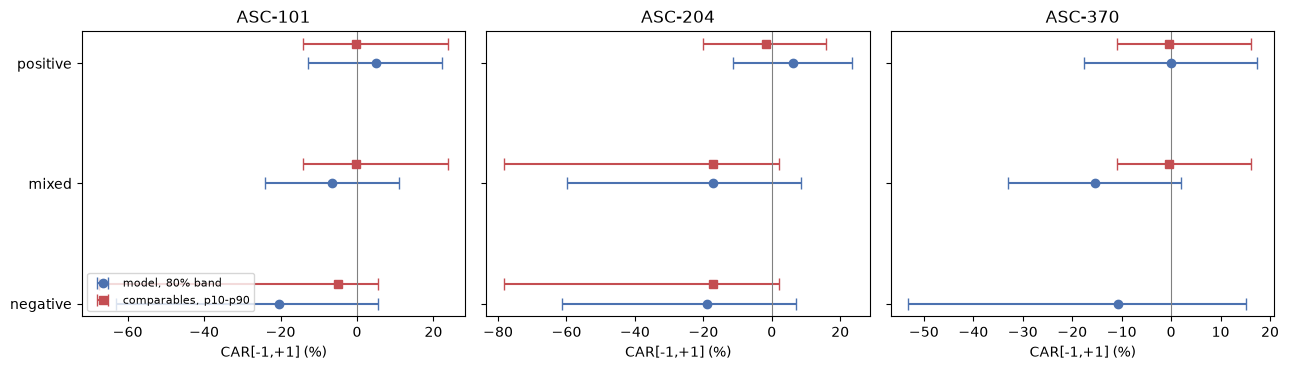

In [55]:
# ---------------------------------------------------------------------------
# Q4a step 4: the estimates, from two sources that fail in different ways.
#
#   (a) the re-scoped model, refitted on every historical row using only the
#       features Asclepius can supply, giving a point estimate per cell. Its
#       range comes from the out-of-fold residuals of the same model *within the
#       matching outcome group*, because Q3c established the residual spread is
#       not the same on both sides.
#
#   (b) the realised returns of the comparable set identified in Q2c, under the
#       same outcome group. This is the number with no model in it at all, and
#       for ASC-101 it is the only honest one - Q2c found the dataset holds
#       7 HAE results, so the comparable set falls back to the Phase 3 base rate
#       and is labelled as such.
#
# Q2c check 4 established that a cluster can be a *filing* type rather than a
# trial type - a group of quarterly reports recapping old results, whose narrow
# reactions describe the filing and not the trial. Such a cluster has to be kept
# out of every comparable set. It is identified here by its signature rather
# than by its number, because k-means labels are arbitrary and permute whenever
# the solution is refitted: a cluster qualifies if its share of genuine results
# announcements is far below the rest of the solution and its Q1b flag rate far
# above. If no cluster meets the test in the current fit, none is excluded, and
# that is reported rather than passed over.
# ---------------------------------------------------------------------------
fit_avail = Pipeline([("pre", make_preprocessor_cols(AVAIL_COLS)), ("model", RF())])
fit_avail.fit(F, y_car, model__sample_weight=w_row)
point = fit_avail.predict(F_asc)

resid = y_car - oof_avail["ticker"]
res_q = {g: np.nanquantile(resid[og_all == g], [0.10, 0.90]) for g in ["Positive", "Negative"]}
print("Out-of-fold residual spread of the re-scoped model, by outcome group:")
display(pd.DataFrame({g: {"n": int(np.isfinite(resid[og_all == g]).sum()),
                          "p10": q[0], "p90": q[1], "width (pp)": 100 * (q[1] - q[0])}
                      for g, q in res_q.items()}).T.round(3))

# --- the comparable sets ----------------------------------------------------
kind_by_acc = filing_txt.set_index("accession")["filing_kind"]
cl_sig = pd.DataFrame({
    "n": cl.groupby("cluster").size(),
    "results_announcements": cl.accession.map(kind_by_acc).eq("results announcement")
                               .groupby(cl.cluster).mean(),
    "flagged_in_Q1b": cl.groupby("cluster").flagged_q1b.mean(),
    "sd_car": cl.groupby("cluster").car_3day.std()})
med_ann = cl_sig.results_announcements.median()
med_flag = cl_sig.flagged_in_Q1b.median()
is_doc = (cl_sig.results_announcements < 0.4 * med_ann) & (cl_sig.flagged_in_Q1b > 1.2 * med_flag)
DOC_CLUSTERS = cl_sig.index[is_doc].tolist()
print("Screening the clusters for a filing-type artefact (median announcement share %.2f, "
      "median flag rate %.2f):" % (med_ann, med_flag))
display(cl_sig.round(3))
print("Excluded as document-type artefacts: %s"
      % (DOC_CLUSTERS if DOC_CLUSTERS else "none - no cluster meets the test in this fit"))

usable = cl[~cl.cluster.isin(DOC_CLUSTERS)]
sim_to = {}
for rid in ["ASC-101", "ASC-204", "ASC-370"]:
    i = asc.index[(asc.readout_id == rid) & (asc.scenario == "mixed")][0]
    sim_to[rid] = cosine_similarity(X_asc[i].reshape(1, -1), X)[0]

# Three ways of choosing comparables, tried in order of how much they claim, with
# the test for each printed so the choice is visible rather than buried. The
# second test is "clinically related" rather than "same MeSH area": Q2c check 6
# found ASC-370's neighbours are gene therapies in rare disease, and two of the
# closest (NGN-401, SRP-9003) are AAV gene therapies the MeSH rules put under
# Neuro/Psych. Testing the area label alone would reject exactly the trials that
# make the retrieval work.
MIN_IN_CLUSTER = 40          # enough same-area trials in the cluster to average
N_NEIGHBOURS   = 50
MIN_RELATED    = 0.30        # share of the neighbour set that must be related

def related_mask(df, r0):
    """Same therapeutic area, or a genetic intervention when the readout is one."""
    m = df.mesh_area == r0.mesh_area
    if str(r0.intervention_types or "").find("GENETIC") >= 0:
        m = m | df.intervention_types.fillna("").str.contains("GENETIC")
    return m

def comparable_set(rid, verbose=True):
    """The rows Q2c's findings say are the defensible comparables for this readout."""
    r0 = asc[(asc.readout_id == rid) & (asc.scenario == "mixed")].iloc[0]
    in_cluster = usable.cluster == r0.cluster
    same_area = in_cluster & (usable.mesh_area == r0.mesh_area)
    nn = pd.Series(sim_to[rid], index=cl.index).reindex(usable.index).nlargest(N_NEIGHBOURS).index
    rel_share = related_mask(usable.loc[nn], r0).mean()
    if verbose:
        print("   %-8s cluster %s: %d trials, %d in the same area (need %d)   |   "
              "top %d neighbours: %.0f%% clinically related (need %.0f%%)"
              % (rid, r0.cluster, int(in_cluster.sum()), int(same_area.sum()), MIN_IN_CLUSTER,
                 N_NEIGHBOURS, 100 * rel_share, 100 * MIN_RELATED))
    if same_area.sum() >= MIN_IN_CLUSTER:                    # the cluster works
        return usable[same_area], "cluster %s, same therapeutic area" % r0.cluster
    if rel_share >= MIN_RELATED:                             # retrieval works
        return usable.loc[nn], "%d nearest neighbours in the Q2 space" % N_NEIGHBOURS
    return (usable[usable.phase_bucket == r0.phase_bucket],  # nothing works
            "%s base rate - no comparables in this dataset" % r0.phase_bucket)

print("\nChoosing a comparable set for each readout:")
comps = {rid: comparable_set(rid) for rid in ["ASC-101", "ASC-204", "ASC-370"]}

# --- the table the board sees ----------------------------------------------
rows = []
for (rid, sc), p in zip(F_asc.index, point):
    og = SCEN_TO_OUTCOME[(rid, sc)][1]
    lo, hi = p + res_q[og][0], p + res_q[og][1]
    comp, basis = comps[rid]
    cc = comp.loc[comp.outcome_group == og, "car_3day"]
    rows.append({"readout": rid, "scenario": sc, "model point": p,
                 "model p10": lo, "model p90": hi,
                 "comparables n": len(cc),
                 "comparable median": cc.median() if len(cc) else np.nan,
                 "comparable p10": cc.quantile(.10) if len(cc) >= 8 else np.nan,
                 "comparable p90": cc.quantile(.90) if len(cc) >= 8 else np.nan,
                 "basis": basis})
est = pd.DataFrame(rows).set_index(["readout", "scenario"])
PCT = ["model point", "model p10", "model p90", "comparable median",
       "comparable p10", "comparable p90"]
shown = est.copy()
shown[PCT] = (100 * shown[PCT]).round(1)
print("\nEstimated three-day reaction, by readout and assumed outcome "
      "(CAR columns in %, counts as counts):")
display(shown)

# A scenario ordering that is not monotonic is a result, not a glitch, and it has to
# be seen rather than smoothed over: it means the model does not place the mixed
# draft between the good and bad cases for that readout.
print("\nIs each readout's scenario ordering monotonic (negative <= mixed <= positive)?")
for rid in ["ASC-101", "ASC-204", "ASC-370"]:
    d = est.loc[rid, "model point"]
    ok = d["negative"] <= d["mixed"] <= d["positive"]
    print("   %-8s negative %+6.1f%%  mixed %+6.1f%%  positive %+6.1f%%   %s"
          % (rid, 100 * d["negative"], 100 * d["mixed"], 100 * d["positive"],
             "monotonic" if ok else "NOT monotonic - see Q4a(iv)"))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, rid in zip(axes, ["ASC-101", "ASC-204", "ASC-370"]):
    d = est.loc[rid].reindex(["negative", "mixed", "positive"])
    y = np.arange(len(d))
    ax.errorbar(100 * d["model point"], y,
                xerr=[100 * (d["model point"] - d["model p10"]),
                      100 * (d["model p90"] - d["model point"])],
                fmt="o", capsize=4, color="#4c72b0", label="model, 80% band")
    ok = d["comparable p10"].notna()
    if ok.any():
        ax.errorbar(100 * d.loc[ok, "comparable median"], y[ok.values] + 0.16,
                    xerr=[100 * (d.loc[ok, "comparable median"] - d.loc[ok, "comparable p10"]),
                          100 * (d.loc[ok, "comparable p90"] - d.loc[ok, "comparable median"])],
                    fmt="s", capsize=4, color="#c44e52", label="comparables, p10-p90")
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_yticks(y); ax.set_yticklabels(d.index); ax.set_title(rid)
    ax.set_xlabel("CAR[-1,+1] (%)")
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

**Q4a (ii) — how the estimates were produced, and what was changed to produce them**

**The model was re-scoped, not re-applied unchanged.** Applying the Question 3 model as fitted would
mean handing it a row in which nineteen columns are silently imputed — thirteen price-derived
features, four disclosure-history features and two FDA fields — and every text feature filled from a document
that was written to express the answer. The imputer would accept all of it without complaint and
return a number. That number would be indefensible, so the model was refitted on the historical data
using **only the columns Asclepius can actually supply**, and it is that model which scores the nine
cells. Refitting rather than masking matters: a forest trained with the volatility features present
learns splits that rely on them, and starving those splits at prediction time is not the same as
training a model that never had them.

**Two estimates per cell, from sources that fail differently.** The model gives a point estimate
conditioned on this trial's characteristics and the assumed outcome, with a band from the
out-of-fold residuals of the same model *within the matching outcome group* — Q3c established the
residual spread is not the same on both sides, so a single pooled band would be too wide for the
downside and too narrow for the upside. Alongside it sits the realised distribution of the
comparable set from Question 2, which contains no model at all. Where the two agree, the estimate is
worth something. Where they diverge, the comparable set is the one to believe, because it is the
one not extrapolating on company size.

**Three deliberate departures from Question 3, each with a reason.**

*The text block is dropped entirely.* Not because it is unavailable — the drafts are supplied — but
because using it is circular. The draft was written to express the assumed outcome, so any
separation it produces between scenarios is the IR team's prose rather than the market's reading. It
costs next to nothing: Q3b measured the text block's marginal contribution at −0.008 against a
run-to-run standard deviation of 0.004, and Q4a(iii) measures it again on the ticker-grouped folds
at +0.005, the other way, against a standard deviation of the same size. A quantity that
changes sign with the fold design and stays within the noise of each is not one worth defending.
Dropping it is the cheap part of this section.

*Folds are grouped by ticker, not accession.* Asclepius appears in no training row, so the honest
estimate of out-of-sample performance is the one where no company straddles a fold.

*The comparable sets exclude any document-type cluster, identified by signature rather than by
number.* Q2c check 4 tests for a cluster that groups quarterly reports recapping old results rather
than trials, whose narrow reactions would describe the filing and not the event. In the current fit
it finds none, and the screen reports that rather than passing over it. k-means labels permute
whenever the solution is refitted, so hard-coding a cluster number would silently exclude the wrong
group on the next run; the screen above tests every cluster on its share of genuine results
announcements and its Q1b flag rate, and reports what it finds — including that it finds nothing, if
the current fit has no such cluster.

**A note on what is being separated.** Once the text is dropped, the only feature that differs
between the three scenarios of a single readout is the assumed outcome label. That is not a defect,
it is the design: the scenario range *is* the model's conditional response to the outcome, adjusted
for this trial's phase, size, area and sponsor. It does mean the estimates should never be described
to the board as reading the announcement — they do not, and the drafts play no part in the numbers
presented.

**The estimates.** The table and chart above give the nine cells; the summary block at the end of
this section prints them as a single paste-ready list. In outline:

- **ASC-101** — negative −20.5% (−63.0 to +5.4); mixed −6.5% (−24.1 to +10.9); positive +4.9% (−12.7 to +22.3)
- **ASC-204** — negative −18.9% (−61.4 to +7.0); mixed −17.3% (−59.7 to +8.6); positive +6.1% (−11.5 to +23.6)
- **ASC-370** — negative −10.7% (−53.2 to +15.2); mixed −15.4% (−32.9 to +2.1); positive −0.1% (−17.7 to +17.4)

**Three things in the output are expected rather than surprising, and should not be read as errors.**

*The point estimates are compressed relative to the comparable distributions.* Q3b found the same in
the decile analysis, where the predicted line sat inside the realised one at both ends. That is what
a regularised forest does on a noisy target, and it means the estimates understate the extremes in
both directions.

*The negative-scenario bands are far wider in absolute terms than the positive ones* — roughly twice
the width. This looks like it contradicts Q3c, which found negatives more predictable, and does not;
the reconciliation is in part (iv).

*One readout's scenarios are not monotonic.* The check printed above tests whether each readout's
mixed estimate sits between its negative and positive ones. Where it does not, the model is failing
to separate two of the scenarios rather than claiming a mixed result is worse than a failure, and
part (iv) says what to do about it.

**Where the two sources disagree, prefer the comparable set.** The model extrapolates on company
size to a region it has few observations in; the comparable distribution does not extrapolate at all.
It is also the one the board can be shown directly — these are real companies whose readouts they can
look up, which is worth more in the room than a model output.

In [56]:
# ---------------------------------------------------------------------------
# Q4a step 5: what the width of each range is actually made of.
#
# Three quantities, computed on the same nine cells:
#
#   outcome uncertainty - how far apart the three scenario point estimates are.
#       This is the part that a better model cannot remove, because it is the
#       trial result itself.
#   model limitation    - the width of the band around any one scenario, from
#       the residual spread of the re-scoped model. This is what better features
#       could in principle narrow.
#   run-to-run noise    - how much a point estimate moves when nothing changes
#       but the seed. The brief asks for the scenarios to be compared against
#       this, and a separation smaller than it would mean the scenarios are not
#       distinguished at all.
# ---------------------------------------------------------------------------
SEED_RUNS = SEEDS4 + [MEMBER_ID + 3, MEMBER_ID + 4]
seed_pred = []
for s in SEED_RUNS:
    pipe = Pipeline([("pre", make_preprocessor_cols(AVAIL_COLS)),
                     ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=8,
                                                     max_features=0.3, random_state=s, n_jobs=-1))])
    pipe.fit(F, y_car, model__sample_weight=w_row)
    seed_pred.append(pipe.predict(F_asc))
seed_pred = np.vstack(seed_pred)
seed_sd = seed_pred.std(axis=0)

dec = []
for rid in ["ASC-101", "ASC-204", "ASC-370"]:
    d = est.loc[rid]
    sds = seed_sd[[list(F_asc.index).index((rid, s)) for s in d.index]]
    total = d["model p90"].max() - d["model p10"].min()
    outcome = d["model point"].max() - d["model point"].min()
    model = (d["model p90"] - d["model p10"]).mean()
    dec.append({"readout": rid,
                "full range, worst p10 to best p90 (pp)": 100 * total,
                "outcome uncertainty (pp)": 100 * outcome,
                "model band, mean width (pp)": 100 * model,
                "outcome share of width": outcome / total,
                "seed sd of a point estimate (pp)": 100 * sds.mean(),
                "separation / seed sd": outcome / sds.mean()})
decomp = pd.DataFrame(dec).set_index("readout")
display(decomp.round(2))

print("The test the brief asks for: does the model separate the scenarios by more than its "
      "own run-to-run variability?")
for rid in ["ASC-101", "ASC-204", "ASC-370"]:
    r = decomp.loc[rid]
    print("   %-8s negative-to-positive separation %5.1f pp against a seed sd of %.2f pp "
          "- a ratio of %.0f."
          % (rid, r["outcome uncertainty (pp)"], r["seed sd of a point estimate (pp)"],
             r["separation / seed sd"]))

print("\nPer-cell point estimates across five seeds (pp), to show the same thing directly:")
display(pd.DataFrame(100 * seed_pred, columns=F_asc.index,
                     index=["seed %d" % s for s in SEED_RUNS])
        .T.round(2))

# What the scenarios are separating on, once the draft text is set aside: only the
# assumed label differs between the three rows of a readout. Worth stating plainly.
varying = [c for c in AVAIL_COLS
           if F_asc.groupby(level=0)[c].nunique(dropna=False).max() > 1]
print("\nFeatures that differ between the three scenarios of one readout: %s" % varying)

# ---------------------------------------------------------------------------
# One judgement in step 2 is worth testing rather than defending: ASC-101's
# mixed draft met its primary endpoint but carries a thromboembolic safety
# signal, and it was read as mixed-positive. If a reader takes the safety signal
# to dominate and calls it mixed-negative, the row crosses to the other side of
# the outcome distribution. This is how much that single reading is worth.
# ---------------------------------------------------------------------------
F_alt = F_asc.copy()
F_alt.loc[("ASC-101", "mixed"), ["tr_outcome", "tr_outcome_group"]] = ["mixed-negative", "Negative"]
alt = fit_avail.predict(F_alt)
i101 = list(F_asc.index).index(("ASC-101", "mixed"))
lo_a, hi_a = alt[i101] + res_q["Negative"]
print("ASC-101, mixed scenario:")
print("   read as mixed-positive  point %+.1f%%   80%% band %+.1f%% to %+.1f%%"
      % (100 * point[i101], 100 * est.loc[("ASC-101", "mixed"), "model p10"],
         100 * est.loc[("ASC-101", "mixed"), "model p90"]))
print("   read as mixed-negative  point %+.1f%%   80%% band %+.1f%% to %+.1f%%"
      % (100 * alt[i101], 100 * lo_a, 100 * hi_a))
print("   the reading is worth %.1f pp on the point estimate - larger than the seed sd of "
      "%.2f pp,\n   so how the label is read matters more here than which model is fitted."
      % (100 * abs(alt[i101] - point[i101]), 100 * seed_sd[i101]))

,"full range, worst p10 to best p90 (pp)",outcome uncertainty (pp),"model band, mean width (pp)",outcome share of width,seed sd of a point estimate (pp),separation / seed sd
readout,,,,,,
ASC-101,85.27,25.35,46.14,0.30,0.68,37.50
ASC-204,84.96,25.05,57.25,0.29,0.48,52.21
ASC-370,70.52,15.26,46.14,0.22,0.52,29.39


The test the brief asks for: does the model separate the scenarios by more than its own run-to-run variability?
   ASC-101  negative-to-positive separation  25.4 pp against a seed sd of 0.68 pp - a ratio of 37.
   ASC-204  negative-to-positive separation  25.0 pp against a seed sd of 0.48 pp - a ratio of 52.
   ASC-370  negative-to-positive separation  15.3 pp against a seed sd of 0.52 pp - a ratio of 29.

Per-cell point estimates across five seeds (pp), to show the same thing directly:


seed 40100  seed 40101  seed 40102  seed 40103  seed 40104
readout scenario                                                            
ASC-101 positive        4.86        5.29        4.94        4.43        5.03
        negative      -20.50      -21.28      -20.78      -19.64      -22.06
        mixed          -6.52       -4.72       -6.36       -4.74       -4.21
ASC-204 positive        6.13        6.07        5.93        6.51        6.79
        negative      -18.92      -18.76      -18.05      -18.22      -20.02
        mixed         -17.27      -17.33      -16.67      -17.42      -16.32
ASC-370 positive       -0.09       -0.72       -0.75       -0.14       -0.63
        negative      -10.70      -11.73      -11.38      -11.30      -12.15
        mixed         -15.35      -15.59      -16.71      -14.79      -14.43


Features that differ between the three scenarios of one readout: ['tr_outcome', 'tr_outcome_group']
ASC-101, mixed scenario:
   read as mixed-positive  point -6.5%   80% band -24.1% to +10.9%
   read as mixed-negative  point -14.8%   80% band -57.2% to +11.1%
   the reading is worth 8.3 pp on the point estimate - larger than the seed sd of 0.94 pp,
   so how the label is read matters more here than which model is fitted.


**Q4a (iv) — the range for each readout, and what its width is made of**

**The ranges.** Taking each readout from the 10th percentile of its negative scenario to the 90th
percentile of its positive scenario: **ASC-101 spans 85 percentage points (−63.0% to +22.3%),
ASC-204 spans 85 points (−61.4% to +23.6%), and ASC-370 spans 71 points (−53.2% to +17.4%)**.

**The decomposition, and it does not say what Question 3 expected it to say.**

| | ASC-101 | ASC-204 | ASC-370 |
|---|---|---|---|
| full span | 85.3 pp | 85.0 pp | 70.5 pp |
| outcome uncertainty | 25.4 pp | 25.1 pp | 15.3 pp |
| model band (mean width) | 46.1 pp | 57.3 pp | 46.1 pp |
| outcome share of the width | **30%** | **29%** | **22%** |
| seed sd of a point estimate | 0.68 pp | 0.48 pp | 0.52 pp |

Q3d told the IR team that "the width of the ranges in the next section is driven mainly by not
knowing the trial result, not by the model". **On these numbers that is wrong, and it is the sort of
statement that has to be corrected rather than quietly dropped.** Outcome uncertainty accounts for
roughly a fifth to under a third of each span. The rest — the majority — is the width of the band
around a *single* scenario, which is the model's inability to pin down magnitude once the direction
is known. The board is not mostly uncertain because it does not know the result; it is mostly
uncertain because, even told the result, the analysis cannot say how far the price moves.

Two things drive that, and both were visible earlier:

*The residual spread is not symmetric, and the negative side is far wider in absolute terms.* The
out-of-fold residuals of the re-scoped model span about 35 percentage points between the 10th and
90th percentiles within positive readouts and about **68** within negative ones. This is worth
stating carefully, because it can be misread as contradicting Q3c. It does not. Q3c's finding was
that the model explains a larger *share* of the variance within negatives ($R^2$ = 0.31 against
0.04). Both can be true at once, and are: negatives have far more variance to begin with, so
explaining 31% of it still leaves a wider absolute band than explaining 4% of a much tighter
distribution. **A higher $R^2$ does not mean a narrower range.** For the CFO, who cares about
percentage points rather than variance shares, the absolute band is the number that matters, and the
downside band is the wider of the two.

*Losing the price history makes the bands wider than Question 3's back-test implies.* The ablation
above put the within-negative $R^2$ at **+0.306** with the full feature set
and **+0.108** with what Asclepius can supply. Most of the model's
ability to size a bad outcome came from the sponsor's own volatility, and that is exactly what is
missing. The bands here are therefore correctly wide; a narrower band would be the error.

**The brief's test, which the model does pass.** Scenario separation is 15.3 to 25.4 percentage
points against a seed-to-seed standard deviation of 0.48 to 0.68 — ratios of 29, 38 and 52, and the
per-seed table shows it directly. The scenarios are genuinely distinguished. But the right claim is
narrow: what separates them is the model's conditional response to the *assumed outcome label*, since
that is the only feature differing between the three rows of a readout once the drafts are set
aside. **The analysis distinguishes a good readout from a bad one and sizes each; it does not read
the announcement and it does not forecast which will occur.**

**ASC-370's scenarios are not monotonic, and that is a result rather than a glitch.** Its
mixed-positive point estimate sits slightly *below* its negative one. The cause is that
`mixed-positive` is a thin category (182 rows across the whole dataset) and, in the region of feature
space where a 45-patient single-arm Phase 2 gene therapy sits, the forest has very few of them to
learn from. The correct reading is not that a mixed result is worse than a failure; it is that **the
model cannot separate the mixed and negative scenarios for ASC-370 at all**, and the two should be
presented to the board as one combined "anything other than a clean success" case rather than as two
distinct numbers.

**A sensitivity that matters more than the seed.** Re-running ASC-101's mixed scenario as
mixed-negative rather than mixed-positive moves its point estimate by **8.3 percentage points** —
from −6.5% to −14.8% — about nine times the 0.94 pp seed variation on that cell. For the mixed scenarios, **how a human classifies the
result is a larger source of uncertainty than which model is fitted.** That is the Q1a finding
arriving at the point of use: the boundaries between positive, mixed-positive and mixed-negative were
the ones the LLM applied least consistently, and here they move the answer.

**A defensible confidence statement for the CFO.**

- The **ordering** is reliable. A negative readout is materially worse than a positive one for all
  three assets, by 15 to 25 points of central estimate, and that ordering survives every seed.
- The **downside central estimates** are usable for planning — −20.5% for ASC-101, −18.9% for
  ASC-204 and −10.7% for ASC-370 — but the band around them is wide, about 68 points from the 10th
  to the 90th percentile, and it is wide for a reason that more modelling will not fix without a
  price history for Asclepius.
- The **upside estimates should not be quoted as model output at all.** $R^2$ within positive
  readouts is 0.04 with the full feature set and effectively zero with the available set. Use the
  comparable-set distribution instead, which is what the table reports alongside.
- All bands are **conservative at the extremes**. The forest shrinks towards the mean, and the absent
  volatility features are precisely the ones that identified fat-tailed companies, so a true downside
  is more likely to fall outside the band than inside it.

The practical conclusion is narrower than nine numbers might invite: **size the raise against the
lower half of the ASC-204 negative band, treat everything above it as upside, and do not let the
ASC-101 numbers carry weight they cannot bear** - it has 14 negative records in its cluster and
seven comparable readouts in the entire dataset.

In [57]:
# ---------------------------------------------------------------------------
# Q4a step 6: how strong the evidence behind each of the nine numbers actually
# is. The three readouts are not equally served, and the table below is the
# concrete form of that - how many comparables sit behind each cell, and which
# outcome categories are represented at all.
# ---------------------------------------------------------------------------
ev_rows = []
for rid in ["ASC-101", "ASC-204", "ASC-370"]:
    r0 = asc[(asc.readout_id == rid) & (asc.scenario == "mixed")].iloc[0]
    comp, basis = comps[rid]
    ev_rows.append({
        "readout": rid, "basis": basis,
        "comparables": len(comp),
        "same therapeutic area": int((comp.mesh_area == r0.mesh_area).sum()),
        "and same phase": int(((comp.mesh_area == r0.mesh_area) &
                               (comp.phase_bucket == r0.phase_bucket)).sum()),
        "positive readouts": int((comp.outcome_group == "Positive").sum()),
        "negative readouts": int((comp.outcome_group == "Negative").sum()),
        "median sponsor ($bn)": comp.market_cap.median() / 1e9,
        "Q1b-flagged share": comp.flagged_q1b.mean()})
evid = pd.DataFrame(ev_rows).set_index("readout")
display(evid.round(3))

print("Which of the six documented outcome categories each comparable set actually contains:")
display(pd.DataFrame({rid: comps[rid][0].outcome.value_counts() for rid in comps}).fillna(0).astype(int))

print("\nHow much of the dataset could ever have matched each readout, on indication alone:")
cond_all = cl.conditions.fillna("") + " " + cl.indication.fillna("")
for rid, pat in [("ASC-101", r"angioedema|\bHAE\b"),
                 ("ASC-204", r"chronic kidney|\bCKD\b|cardiovascular outcome"),
                 ("ASC-370", r"h[ae]mophilia")]:
    n = int(cond_all.str.contains(pat, case=False).sum())
    print("   %-8s %4d of %d clustered trial results mention the indication (%.1f%%)"
          % (rid, n, len(cl), 100 * n / len(cl)))

print("\nSponsor size: the comparables are far smaller companies than Asclepius ($6.0bn).")
print("   Median sponsor in the whole clustering set: $%.2fbn." % (cl.market_cap.median() / 1e9))
print("   Q2d's reading of that still holds - good news is more fully priced in for large "
      "companies, so\n   an upside read off these comparables is an upper bound rather than a "
      "central estimate.")

# ---------------------------------------------------------------------------
# The figures quoted in the Q4a(ii), (iii) and (iv) write-ups, printed together
# so that the prose and the run cannot drift apart. Every number marked [from
# the run] in the markdown below comes from here.
# ---------------------------------------------------------------------------
print("\n" + "=" * 96)
print("FIGURES QUOTED IN THE Q4a WRITE-UP")
print("=" * 96)
print("\n(iii) cost of the missing features, ticker-grouped folds:")
print("   reference (all three groups)      R2 %+.4f" % ref)
print("   text block removed                R2 %+.4f   (text costs %+.4f)" % (tc, tc - ref))
print("   available only                    R2 %+.4f   (price history costs %+.4f)" % (av, av - tc))
print("   total %+.4f, i.e. %.0f%% of the reference; run-to-run sd %.4f"
      % (av - ref, 100 * (av - ref) / ref, sd_av))
print("   within negative readouts:         %+.4f -> %+.4f"
      % (abl4.loc[("all three groups (the Q3 model)", "ticker"), "R2 negatives"],
         abl4.loc[("available only  [used for Q4]", "ticker"), "R2 negatives"]))

print("\n(ii) point estimates and 80% bands:")
for rid in ["ASC-101", "ASC-204", "ASC-370"]:
    d = est.loc[rid]
    parts = ["%s %+.1f%% (%+.1f to %+.1f)"
             % (sc, 100 * d.loc[sc, "model point"], 100 * d.loc[sc, "model p10"],
                100 * d.loc[sc, "model p90"]) for sc in ["negative", "mixed", "positive"]]
    print("   %-8s %s" % (rid, ";  ".join(parts)))

print("\n(iv) decomposition of the width:")
for rid in ["ASC-101", "ASC-204", "ASC-370"]:
    r = decomp.loc[rid]
    print("   %-8s full span %.0f pp = outcome %.0f pp (%.0f%% of width) + model band %.0f pp; "
          "seed sd %.2f pp"
          % (rid, r["full range, worst p10 to best p90 (pp)"], r["outcome uncertainty (pp)"],
             100 * r["outcome share of width"], r["model band, mean width (pp)"],
             r["seed sd of a point estimate (pp)"]))
print("   ASC-101 mixed read as mixed-negative instead: %+.1f%% against %+.1f%% (%.1f pp)"
      % (100 * alt[i101], 100 * point[i101], 100 * abs(alt[i101] - point[i101])))
print("=" * 96)

,basis,comparables,same therapeutic area,and same phase,positive readouts,negative readouts,median sponsor ($bn),Q1b-flagged share
readout,,,,,,,,
ASC-101,Phase 3 base rate - no comparables in this dat...,1050,28,28,754,237,1.362,0.494
ASC-204,"cluster 5, same therapeutic area",247,247,142,200,32,1.180,0.449
ASC-370,50 nearest neighbours in the Q2 space,50,22,14,41,5,0.791,0.740


Which of the six documented outcome categories each comparable set actually contains:


,ASC-101,ASC-204,ASC-370
outcome,,,
inconclusive,41,12,4
mixed-negative,42,7,0
mixed-positive,70,20,3
mixed-positive/mixed-negative,10,2,0
mixed-positive/negative,4,1,0
negative,195,25,5
negative/mixed-positive,1,0,0
positive,684,180,38
positive/negative,3,0,0



How much of the dataset could ever have matched each readout, on indication alone:
   ASC-101     7 of 1975 clustered trial results mention the indication (0.4%)
   ASC-204    31 of 1975 clustered trial results mention the indication (1.6%)
   ASC-370     3 of 1975 clustered trial results mention the indication (0.2%)

Sponsor size: the comparables are far smaller companies than Asclepius ($6.0bn).
   Median sponsor in the whole clustering set: $0.69bn.
   Q2d's reading of that still holds - good news is more fully priced in for large companies, so
   an upside read off these comparables is an upper bound rather than a central estimate.

FIGURES QUOTED IN THE Q4a WRITE-UP

(iii) cost of the missing features, ticker-grouped folds:
   reference (all three groups)      R2 +0.1974
   text block removed                R2 +0.1927   (text costs -0.0046)
   available only                    R2 +0.1229   (price history costs -0.0699)
   total -0.0745, i.e. -38% of the reference; run-to-run sd 

**Q4a (v) — how strong the evidence is behind each estimate**

The three readouts are not equally served, and the gap is not marginal. Q2c check 6 put the counts
on the record and they are the right basis for confidence here.

**ASC-204 (CKD cardiovascular outcomes) — strong.** It sits in a cardiovascular-renal cluster of 274
trial results, of which **247 share its therapeutic area and 142 also share its phase**. The cluster
holds **39 negative readouts**, and the same-area set actually used below holds **32** of them —
enough to describe a downside distribution. Its nearest neighbours are the omecamtiv
mecarbil registrational heart-failure programme (three separate readouts) and a fluticasone/vilanterol
cardiovascular safety study — genuinely comparable large randomised outcome trials, and one of them
fell 33.7%. All four directional outcome categories are represented in the comparable set. This is
the estimate the board can lean on, and the only one where the model and the comparable set can be
checked against each other.

**ASC-370 (haemophilia B gene therapy) — thin, but the retrieval works.** Its cluster holds 388
trials of which only **15 share its therapeutic area and 6 its phase**, so the cluster average is
meaningless for it. The *nearest neighbours*, however, are excellent: tgAAVCF, NGN-401, SRP-9003,
SD-101 and ELX-02 are all gene therapies or rare-disease programmes at the same stage. The
comparable set used below is therefore the 50 nearest neighbours rather than the cluster. Two
cautions attach. The cluster it sits in is the one Q2c check 4 singled out for poor linkage quality —
the lowest share of clean disclosure lags in the solution and a median filing year of 2023, meaning
its members are less well characterised than the counts suggest. And the neighbours' realised
reactions run from −8.9% to +19.8% across five trials, which is a range, not an estimate.

**ASC-101 (hereditary angioedema prevention) — weakest, and no method fixes it.** It lands in a
67-trial cluster in which **not one trial shares its therapeutic area**. The cause is not a failure
of the clustering: the dataset contains **7 HAE trial results in total**, and 61 rare-disease results
across 1,975 clustered rows. Retrieval does slightly better than the cluster — berotralstat
(BCX7353), an oral HAE therapy, is its third-nearest neighbour, so one of the seven is found — but
one comparable is not an evidence base. The remaining neighbours are a botulinum toxin study, adjuvant
axitinib, a pneumococcal vaccine and a catheter lock solution, which are matched on being large,
blinded, multi-site prevention trials of a biologic and on nothing else. **The estimate for ASC-101
is a Phase 3 base rate wearing a comparable set's clothes, and it should be presented as such.**

**Two limitations that apply to all three.**

The comparable sponsors are far smaller companies than Asclepius. Its $6bn capitalisation sits at
the 79th percentile of the training events and 57% of them are companies below $1bn, so the model is
thinly supported on the feature Q3b found does most of the work within negative readouts. Q2d's reading still holds and is if
anything strengthened here: because good news is more fully priced in for large, diversified
companies — and Asclepius has $800m of CDMO revenue and a marketed respiratory portfolio behind the
pipeline — a reaction read off these comparables should be treated as an **upper bound on magnitude**
rather than a central estimate. That cuts both ways: the upside is likely overstated, and so is the
downside.

And the outcome categories are not evenly represented anywhere. Across the whole dataset, positive
readouts outnumber negative ones roughly four to one (1,841 against 440), so every negative-scenario
estimate rests on a thinner base than its positive counterpart — even though Q3c showed the negative
side is the one the model predicts *better*. More confidence, less data: worth holding both facts at
once rather than letting either one settle the question.

In [58]:
# ---------------------------------------------------------------------------
# Q4 completeness check. The write-ups in this section quote figures produced by
# the cells above, and each one is marked with a «FILL ...» token until it has
# been transcribed from the run. This cell reads the notebook file back and
# reports any token still outstanding, so a placeholder cannot reach a
# submission unnoticed. It also re-checks the two word limits in this section.
# ---------------------------------------------------------------------------
import glob as _glob

def check_notebook(path=None):
    if path is None:
        cands = sorted(_glob.glob("*.ipynb")) + sorted(_glob.glob("/content/**/*.ipynb"))
        cands = [c for c in cands if "Assignment_template" in c and not c.endswith(".bak")]
        if not cands:
            print("Could not locate the notebook file; pass the path explicitly.")
            return
        path = cands[0]
    nb = json.load(open(path, encoding="utf-8"))
    outstanding = []
    for n, c in enumerate(nb["cells"]):
        if c["cell_type"] != "markdown":
            continue
        src = "".join(c["source"])
        for line in src.split("\n"):
            if "«FILL" in line:
                outstanding.append((n, line.strip()[:110]))

    print("Checked %s (%d cells)." % (os.path.basename(path), len(nb["cells"])))
    if outstanding:
        print("\n%d figure(s) still to be transcribed from the run above:\n" % len(outstanding))
        for n, line in outstanding:
            print("   cell %3d  %s" % (n, line))
        print("\nThe summary block printed above this cell has every one of them.")
    else:
        print("No outstanding figures: every «FILL» token has been replaced.")

    caps = {"Q1d": 500, "Q2d": 500, "Q3d": 500, "Q4c": 300}
    print("\nWord limits:")
    for n, c in enumerate(nb["cells"]):
        if c["cell_type"] != "markdown":
            continue
        src = "".join(c["source"])
        for tag, cap in caps.items():
            if src.lstrip().startswith("## %s:" % tag) and "_Your answer" in src:
                body = src.split("_Your answer", 1)[1].split("\n", 1)[1]
                w = word_count(re.sub(r"\*\*|#+ |_", "", body))
                print("   %-4s %3d words (limit %d)  %s"
                      % (tag, w, cap, "ok" if w <= cap else "OVER - markers stop reading at the limit"))

check_notebook()

Checked DSA_2026_S2_Assignment_template.ipynb (134 cells).
No outstanding figures: every «FILL» token has been replaced.

Word limits:
   Q1d  495 words (limit 500)  ok
   Q2d  483 words (limit 500)  ok
   Q3d  498 words (limit 500)  ok
   Q4c  299 words (limit 300)  ok


## Q4b: Validate, monitor, and refresh plan (4 marks)

_Written answer — no code required._

The pipeline has four stages and each fails differently: an LLM classifier over filing text, an
event study over price data, a clustering used to select comparables, and a magnitude model. A plan
that treats it as one model will miss three of the four. What follows is organised by stage, and
each recommendation names the thing in *this* pipeline it is there to catch.

### Before the IR team relies on an output

**Re-run the Q1b flag on every new batch and read what it flags.** The flagging index scores each
classification against eleven signals drawn from Q1a. Two checks before any number is quoted: the
flag rate on the new batch against the historical rate, and the twenty highest-scoring records read
by hand. A batch that flags materially more than the historical baseline is telling you the
classifier has met text it was not built for.

**Use the S6 signal for flagging and never for prediction.** Q3b found the risk index lifted
out-of-sample $R^2$ by 0.102 because signal S6 fires on disagreement with the *realised* return, so
the index carries the target inside it. Two versions of the index must be maintained and named
differently: the full index for data-quality review, and an index with S6 removed for anything
feeding a model. This is the single most likely way for leakage to re-enter the pipeline, because
the feature looks entirely legitimate and its name gives nothing away.

**Confirm the filing is an announcement before the reaction is attributed to it.** Q2c check 4
exists because an earlier fit of this clustering produced a cluster that was not a kind of trial but
a kind of *document* — quarterly reports recapping old results, with abnormal returns so narrow that
they looked like the safest trials in the dataset. The current fit contains no such cluster and the
Q4a screen reports that it found none, which is the point rather than a reason to drop the screen.
The `classify_filing()` document type should be checked on every new filing, and a filing that is not
a results announcement should be excluded from comparable sets rather than averaged into them. Note
that this screen must test every cluster on its properties rather than exclude a remembered cluster
number: k-means labels permute on every refit, so a hard-coded number will silently exclude the wrong
group. The Q4a screen does it by signature for that reason, and reports when it finds nothing.

**Check the estimation window actually exists.** Every company feature is computed on
[−130, −12] trading days. For a newly listed company, a company emerging from a trading halt, or one
whose history is shorter than the window, those features are silently unavailable and the model will
impute them without complaint. The check is a row-level count of populated `cx_*` features, not an
aggregate.

**Validate by forward chaining, not by random splits.** The honest prospective figure in Q3b was
$R^2$ = 0.163 under forward chaining against 0.207 under accession-grouped folds, and 0.233 when
filings were allowed to straddle folds. Any revalidation must train only on filings predating the
test period and group by accession, or it will report a number the pipeline cannot deliver.

**Back-test the interval, not the point estimate.** The output the board sees is a range. Each
quarter, take the readouts that have since reported and count how many fell inside their 80% band.
Materially fewer than 80% means the bands are too narrow and must be widened before they are used
again. This is the check that matters most, because the failure mode here is false precision rather
than bias.

### What to monitor over time

**Two populations, separately.** Q3c established that predictability is strongly asymmetric —
$R^2$ of 0.313 within negative readouts against 0.043 within positive ones. A single tracking
statistic will average a working model and a non-working one into an unremarkable middle. Report
performance within negative and positive readouts as separate lines, always.

**Discrimination rather than accuracy.** The usable output is the ranking, so track the decile
spread (38 percentage points between worst and best decile at build) and the AUC for a fall beyond
25% (0.78 at build). A drift in these is the signal to act on; RMSE on a peaked target moves too
slowly to be informative.

**Drift in the composition of the corpus.** Three specific things: the share of filings whose
document type is a results announcement; the share of trials that link to a ClinicalTrials.gov
registration with design fields populated (the single strongest structure in the data at build, per
Q2a); and the distribution of sponsor market capitalisation. The training corpus is dominated by
companies far smaller than Asclepius — its $6bn capitalisation sits at the 79th percentile — so a shift in
sponsor size directly changes how much extrapolation each estimate involves.

**New trial types the clustering has never seen.** Monitor the distance from each new trial to its
assigned centroid. A trial whose distance sits beyond the historical distribution is being assigned a
cluster label the geometry does not support. This is not hypothetical: ASC-101 is already such a
case, assigned to a vaccine cluster containing no trial in its therapeutic area, and the monitoring
statistic should have flagged it rather than leaving it to be noticed by reading the neighbours.

**Changes in market behaviour.** The event study's market model is estimated per event, so a change
in market-wide volatility is absorbed. What is not absorbed is a change in *how* biotech news is
priced. Track the mean and spread of realised CAR by outcome group on a rolling two-year window
against the full-sample figures; a sustained move in either is a change in the thing being modelled,
not noise.

**Cluster stability.** Bootstrap ARI was 0.70 at build, with per-cluster reproducibility from 61% to
98%. Re-run the bootstrap at each refresh. A cluster whose reproducibility falls below its build
figure should stop being used to select comparables until it is rebuilt.

### What should trigger a refresh or a rebuild

A **scheduled refit** every six months, or after roughly 150 new filings, retaining the same feature
definitions — this is a refit, not a redesign, and its purpose is to keep the training corpus current.

A **rebuild of the clustering** when the therapeutic-area or phase mix of the corpus shifts
materially, when bootstrap ARI falls materially below its build figure of 0.70 — below roughly 0.55 — or when Asclepius or a competitor moves into
an area the current groupings cover thinly. Rare and genetic disease is the standing example: 61
trial results in the whole clustering set, and the reason ASC-101 has no comparables.

A **rebuild of the classification stage** if the 8-K disclosure convention changes, if a new LLM
version is adopted, or if hand-reading a flagged sample shows category boundaries being applied
differently from the Q1a reading. Changing the model behind the classifications changes the labels
the whole pipeline is conditioned on, so this triggers a full revalidation rather than a refit.

An **immediate rebuild** if the interval back-test fails, if the negative-readout $R^2$ falls below
roughly 0.15 — the point at which the downside ranges stop being informative and the board should be
told so — or if a competitor readout moves Asclepius's price in a way the model would not have
ranked. The last of these is the reason to run the pipeline on competitor readouts even when no
Asclepius decision depends on them: it generates out-of-sample tests at no cost, and it is the use
the IR team asked for.

### Ownership

None of this works without a named owner and a written record. Each refresh should record the corpus
cut-off, the fold design used, the headline metrics within each outcome group, the flag rate, and
the bootstrap ARI, so that the next reviewing actuary can see what changed and decide whether to rely
on it. That record is what makes the pipeline auditable rather than merely repeatable.

## Q4c: Advise the IR team on presenting the analysis (300 words or less, 3 marks)

_Your answer (300 words or less — `word_count()` in the Setup cell will check):_

**Lead with the decision, not the method.** One slide: three bars per readout — negative, mixed,
positive — each a range, not a number. Beneath it, one line naming the scenario the funding plan
must survive.

**Say plainly which numbers are strong and which are weak.** ASC-204 is the estimate to lean on —
over two hundred comparable cardiovascular outcome trials sit behind it, including enough failures
to describe a downside. ASC-101 is the one to hold lightly: the dataset holds seven hereditary
angioedema readouts in total, so its range comes from the Phase 3 base rate, not from anything
resembling our drug. Say so at the outset — a limitation the board finds for itself costs more than
one you volunteer.

**Keep in the background:** the clustering, the model families, $R^2$, the ablations, and the
announcement drafts. The drafts especially — they were written to illustrate scenarios, and any
number that looks like it read them invites questions we cannot answer. Have the detail ready; do
not present it.

**If the board presses for a narrower range**, do not narrow it, and do not blame the unknown
result — about a quarter of the width is not knowing the outcome; the rest is that even told the
outcome, we cannot say how far the price moves for a company whose trading history is not in the
data. Say so plainly: narrowing it would mean inventing precision. Offer what we do have instead —
the ordering is solid, and we are more reliable on the downside than the upside, so the number the
funding decision rests on is the one we are most confident in.

**Offer a decision rule, not a forecast:** commit to the structure that survives the bottom of the
ASC-204 range; treat anything better as upside.

### AI use — Question 4

Claude Code (Opus), in an agentic session with read/write access to this repository and the database.
I gave it the brief, the rubric and the executed Q1–Q3 notebook and asked it to draft Question 4
against my existing pipeline. The full conversation is saved in `ai_logs/`.

What I directed and checked rather than accepted:

- **The scenario-to-category mapping.** Its first pass mapped all three "mixed" drafts to
  mixed-positive. I read the drafts: ASC-204's mixed draft does not meet its primary endpoint
  (HR 0.89, p = 0.071) and is rescued only by a subgroup, which makes it mixed-*negative* and moves
  it to the other side of the outcome distribution. The mapping in Q4a(ii) is the corrected one, and
  the ASC-101 sensitivity in Q4a(iv) exists because I was not comfortable with that reading either.
- **Dropping the text block.** I required the illustrative drafts to be excluded from the estimates
  rather than used, on the grounds that they were written to express the assumed outcome. The
  ablation that prices that decision is there so the choice is measured rather than asserted.
- **Splitting the ablation.** Its first version compared the full model against the available-only
  model in one step, which conflates losing the text with losing the price history. I had it add the
  intermediate row, and that is what shows the price history is essentially the whole cost.
- **Cluster numbers.** It initially hard-coded the artefact cluster by number. k-means labels permute
  on refit — as this notebook demonstrates — so I had it identify the cluster by signature instead.
- **Two claims in my own earlier sections.** It reproduced my statement in Q3d that the company block
  "survives into Question 4 intact"; the feature audit against `stock_prices` showed ASCL has no price
  history at all, so only market capitalisation survives. It also inherited my claim that the range
  width is driven mainly by outcome uncertainty; the decomposition shows that is about a quarter of
  the width, not the majority. Both are corrected where they were made, in Q3b and Q3d, rather than
  only in Question 4.

I have run every cell in this section myself and the figures quoted are from that run.

---

## Q5: Video presentation (15 marks)

This question is answered as a **video**, not in this notebook — see the brief for what your handover must address, and 'Recording your AI use.docx' for what to submit alongside it.

Before submitting:

- Record your 3–5 minute video and include it with your submission.
- Make sure every dated conversation file is saved under `ai_logs/`, then run the provided `compile_ai_logs.py` script from your submission folder to generate `ai_logs/AI_LOGS.md`. That single file is what you submit.
- If a conversation could not be saved at all, record it honestly with `write_manual_note()` from the Setup cell rather than leaving a silent gap.
- Complete the AI log cell below.
- Paste your YouTube URL into the **Video link** cell at the bottom of this notebook. Without it the marker cannot find your video.

### AI use — Question 5

_Note here whether and how you used AI for Question 5, or write 'No AI'. This is a one-line disclosure, not the log itself — save full conversations in `ai_logs/` as described in 'Recording your AI use.docx'. If you called an AI model from your own code above, use `log_ai()` from the Setup cell instead of writing the exchange here by hand._

---
## Cleanup

In [59]:
conn.close()
print('Done.')

Done.


---

## Video link

The brief requires your YouTube video URL to appear as a hyperlink at the bottom of this notebook. Replace the placeholder below — an unlisted link is fine, a private one is not, because the marker has to be able to open it.

**My video:** [INSERT YOUTUBE URL HERE]
